In [ ]:
# Title: 05_Xu_BayesAge_calibration.ipynb
# Author: Lajoyce Mboning
# Date:2025
# Related publication: Emma K. Costa, and Jingxun Chen, in prep


# Description - Run the BayesAge clock on Xu et al

# Set Up

In [ ]:
import os
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LassoCV
from numpy import arange
from numpy import absolute
from numpy import mean
from numpy import std
import numpy as np
from scipy import stats
from sklearn.metrics import mean_absolute_error as mae
import statsmodels.api as sm
from scipy.stats import spearmanr
lowess = sm.nonparametric.lowess
from scipy.stats import poisson
from scipy.stats import pearsonr
from datetime import datetime
import time
import random
import itertools

In [ ]:
#allow Google CoLab to have access to your drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# set working dir
os.chdir("/content/drive/My Drive/african_killifish_atlas/revisions/CodeCheck_revisions/Xu_model_outputs/BayesAge/")

In [ ]:
# List of directories you want to create
dirs_to_create = [
    "./reference/",
    "./predictions/",
    "./gene_sets/",
    "./plots/",
    "./predictions_exhaustive/",
    "./reference_exhaustive/"
]


for d in dirs_to_create:
    os.makedirs(d, exist_ok=True)  # exist_ok=True won't raise an error if it already exists

In [ ]:
def transcriptome_reference(training_matrix,
                        reference_name,
                        output_path="./predictions/",
                        age_prediction="list",
                        age_list=[],
                        min_age=-20,
                        max_age=100,
                        age_step=1,
                        tau=0.7,
                        ):

    start_time = time.time()

    training_cv_df = training_matrix

    training_df_frequency = training_cv_df.iloc[:,:-1]

    #print(training_df_frequency)

    training_df_frequency = training_df_frequency.div(training_df_frequency.sum(axis=1), axis=0)

    genes = training_cv_df.iloc[:,:-1].columns.tolist()

    age_steps = np.arange(min_age, max_age + age_step, age_step)

    # Age values from the reference data
    age_training = training_cv_df["age"].values.flatten()

    final_training_matrix = []

    if age_prediction == "list":

        for gene in genes:
            # Frequency level of current gene
            gene_frequency = training_df_frequency[gene].values.flatten()

            # Perform lowess smoothing
            predicted_frequency_levels = lowess(gene_frequency, age_training, xvals=age_list, frac=tau)

            # Calculate Spearman rank correlation
            rho, p = spearmanr(age_training, gene_frequency)

            spearman_rank = rho

            p_value = p

            final_gene_frequency_tuple = (gene, ) + tuple(predicted_frequency_levels) + (spearman_rank, p_value)

            final_training_matrix.append(final_gene_frequency_tuple)

        df_columns = ["Gene"] + [str(num) for num in age_list] + ["spearman_rank", "p_value"]

    elif age_prediction == "steps":

        for gene in genes:
            # Frequency level of current gene
            gene_frequency = training_df_frequency[gene].values.flatten()

            # Perform lowess smoothing
            predicted_frequency_levels = lowess(gene_frequency, age_training, xvals=age_steps, frac=tau)

            # Calculate Spearman rank correlation
            rho, p = spearmanr(age_training, gene_frequency)

            spearman_rank = rho

            p_value = p

            final_gene_frequency_tuple = (gene, ) + tuple(predicted_frequency_levels) + (spearman_rank, p_value)

            final_training_matrix.append(final_gene_frequency_tuple)

        df_columns = ["Gene"] + [str(num) for num in age_steps] + ["spearman_rank", "p_value"]


    df = pd.DataFrame(final_training_matrix, columns=df_columns)
    df.set_index("Gene", inplace=True)

    # Create output directory if it doesn't exist
    os.makedirs(output_path, exist_ok=True)

    # Save the DataFrame to a TSV file
    df.to_csv(os.path.join(output_path, reference_name), sep="\t")
    print(f"\nReference model dataset written to '{os.path.join(output_path, reference_name)}'")

    number_of_samples = training_cv_df.shape[0]

    # Write report file detailing input matrix
    report_file_path = os.path.join(output_path, f'{reference_name}.report.txt')
    with open(report_file_path, 'w') as writer:
        writer.write("BayesAge reference report for %s\n" % reference_name)
        now = datetime.now()
        write_datetime = now.strftime("%m/%d/%Y %H:%M:%S")
        writer.write("Reference file created: %s\n\n" % write_datetime)
        writer.write("Number of input samples = %s\n" % number_of_samples)
        writer.write("Number of input Genes = %s\n" % len(genes))
        if age_prediction == "list":
            writer.write("Predictions made for ages: %s\n" % age_list)
        elif age_prediction == "steps":
            writer.write("Predictions made for age steps from %s to %s with step %s\n" % (min_age, max_age, age_step))

    print(f"Report file generated at '{report_file_path}'")
    print("-----------------------------------------------------\n\n")

    end_time = time.time()
    elapsed_time = end_time - start_time
    print("\nTime to run construct reference: %0.3f seconds" % elapsed_time)
    print("\nThe reference is constructed and saved!")

    return df  # Optionally return the DataFrame

# Load & format atlas data

In [ ]:
# load raw counts
df_unnorm = pd.read_csv("../../AtlasFiles_forLajoyce_240507/Counts_Atlas_allbatches_merged_v3.csv")
df_unnorm.head(3)

,Unnamed: 0,A1_1,A1_2,A10_1,A10_2,A11_1,A11_2,A12_1,A12_2,A13_1,...,P4_2,P5_1,P5_2,P6_1,P6_2,P7_1,P7_2,P8_2,P9_1,P9_2
0,a1cf,21686,52,5891,6,7544,18,10043,9,0,...,12,45920,3113,9682,4020,37522,1383,36,7855,14
1,aaas,623,585,1108,720,824,1072,1004,611,192,...,484,310,143,336,487,178,148,735,1383,717
2,aacs,1980,502,266,1913,238,2252,308,1614,56,...,1061,6587,291,3347,552,329,178,1124,382,1232


In [ ]:
df_unnorm.rename(columns={"Unnamed: 0": "sample"}, inplace=True)
df_unnorm.set_index("sample", inplace=True)
df_unnorm.head(3)

,A1_1,A1_2,A10_1,A10_2,A11_1,A11_2,A12_1,A12_2,A13_1,A13_2,...,P4_2,P5_1,P5_2,P6_1,P6_2,P7_1,P7_2,P8_2,P9_1,P9_2
sample,,,,,,,,,,,,,,,,,,,,,
a1cf,21686,52,5891,6,7544,18,10043,9,0,30,...,12,45920,3113,9682,4020,37522,1383,36,7855,14
aaas,623,585,1108,720,824,1072,1004,611,192,591,...,484,310,143,336,487,178,148,735,1383,717
aacs,1980,502,266,1913,238,2252,308,1614,56,227,...,1061,6587,291,3347,552,329,178,1124,382,1232


In [ ]:
df_unnorm = df_unnorm.T
df_unnorm.head(3)

sample,a1cf,aaas,aacs,aadat,aaed1,aagab,aak1,aamdc,aamp,aar2,...,zswim6,zswim7,zswim8,zufsp,zw10,zwilch,zyg11b,zyx,zzef1,zzz3
A1_1,21686,623,1980,523,200,802,1242,1224,562,577,...,829,161,1014,220,1560,42,515,3018,1422,325
A1_2,52,585,502,537,709,674,1385,2329,652,646,...,1113,92,963,153,1118,27,966,3871,275,364
A10_1,5891,1108,266,676,233,835,1374,809,716,778,...,635,156,1650,137,1370,380,662,3191,498,477


In [ ]:
# load metadata
df_metadata = pd.read_csv("../../AtlasFiles_forLajoyce_240507/ExperimentDesign_allbatches_combined_v7.csv")

df_metadata.head(3)

/usr/local/lib/python3.11/dist-packages/google/colab/_dataframe_summarizer.py:88: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  cast_date_col = pd.to_datetime(column, errors="coerce")


,Unnamed: 0,animalID,sex,cohort,age_days,harvest_date,hatch_date,tissue,tissue_grind_date,RNA_extract_date,RNA_batch,RNA_extractor,RNAID,cDNA_batch,plate_well,sampleNames,lib,censored,censor_code,notes
0,A1_1,J9,F,2,155,8/16/22,3/14/22,Gut,NaN,3/8/23,Gut_1,EC,RNA352,1,A1,A1,A1_1,NaN,NaN,NaN
1,A1_2,A01,M,2,78,5/31/22,3/14/22,Bone,4/19/23,4/22/23,Bone_1,EC,RNA572,2,A1,A1,A1_2,NaN,NaN,NaN
2,A10_1,P_1B_10,M,1B,133,1/31/22,9/20/21,Kidney,NaN,3/4/23,Kidney_1,JC,R258,1,A10,A10,A10_1,NaN,NaN,NaN


In [ ]:
df_metadata.reset_index()

,index,Unnamed: 0,animalID,sex,cohort,age_days,harvest_date,hatch_date,tissue,tissue_grind_date,...,RNA_batch,RNA_extractor,RNAID,cDNA_batch,plate_well,sampleNames,lib,censored,censor_code,notes
0,0,A1_1,J9,F,2,155,8/16/22,3/14/22,Gut,NaN,...,Gut_1,EC,RNA352,1,A1,A1,A1_1,NaN,NaN,NaN
1,1,A1_2,A01,M,2,78,5/31/22,3/14/22,Bone,4/19/23,...,Bone_1,EC,RNA572,2,A1,A1,A1_2,NaN,NaN,NaN
2,2,A10_1,P_1B_10,M,1B,133,1/31/22,9/20/21,Kidney,NaN,...,Kidney_1,JC,R258,1,A10,A10,A10_1,NaN,NaN,NaN
3,3,A10_2,J_1A_14,M,1A,75,11/22/21,9/8/21,SpinalCord,NaN,...,SpinalCord_1,EC,RNA423,2,A10,A10,A10_2,NaN,NaN,NaN
4,4,A11_1,J_1A_22,M,1A,47,10/25/21,9/8/21,Kidney,NaN,...,Kidney_2,JC,R274,1,A11,A11,A11_1,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
672,672,P7_1,J_1A_25,M,1A,103,12/20/21,9/8/21,Liver,NaN,...,Liver_1,IG,RNA689,1,P7,P7,P7_1,NaN,NaN,NaN
673,673,P7_2,P_1B_1,F,1B,77,12/6/21,9/20/21,Fat,4/13/23,...,Fat_3,EC,RNA566,2,P7,P7,P7_2,NaN,NaN,NaN
674,674,P8_2,J_1A_25,M,1A,103,12/20/21,9/8/21,Eye,NaN,...,Eye_1,MRW,642,2,P8,P8,P8_2,NaN,NaN,NaN
675,675,P9_1,J_1B_2,M,1B,49,11/8/21,9/20/21,Kidney,NaN,...,Kidney_1,JC,R257,1,P9,P9,P9_1,NaN,NaN,NaN


In [ ]:
df_metadata.rename(columns={"Unnamed: 0": "sample"}, inplace=True)

df_metadata.head(3)

/usr/local/lib/python3.11/dist-packages/google/colab/_dataframe_summarizer.py:88: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  cast_date_col = pd.to_datetime(column, errors="coerce")


,sample,animalID,sex,cohort,age_days,harvest_date,hatch_date,tissue,tissue_grind_date,RNA_extract_date,RNA_batch,RNA_extractor,RNAID,cDNA_batch,plate_well,sampleNames,lib,censored,censor_code,notes
0,A1_1,J9,F,2,155,8/16/22,3/14/22,Gut,NaN,3/8/23,Gut_1,EC,RNA352,1,A1,A1,A1_1,NaN,NaN,NaN
1,A1_2,A01,M,2,78,5/31/22,3/14/22,Bone,4/19/23,4/22/23,Bone_1,EC,RNA572,2,A1,A1,A1_2,NaN,NaN,NaN
2,A10_1,P_1B_10,M,1B,133,1/31/22,9/20/21,Kidney,NaN,3/4/23,Kidney_1,JC,R258,1,A10,A10,A10_1,NaN,NaN,NaN


In [ ]:
df_metadata.set_index("sample", inplace=True)
df_metadata.head(2)

/usr/local/lib/python3.11/dist-packages/google/colab/_dataframe_summarizer.py:88: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  cast_date_col = pd.to_datetime(column, errors="coerce")


,animalID,sex,cohort,age_days,harvest_date,hatch_date,tissue,tissue_grind_date,RNA_extract_date,RNA_batch,RNA_extractor,RNAID,cDNA_batch,plate_well,sampleNames,lib,censored,censor_code,notes
sample,,,,,,,,,,,,,,,,,,,
A1_1,J9,F,2,155,8/16/22,3/14/22,Gut,NaN,3/8/23,Gut_1,EC,RNA352,1,A1,A1,A1_1,NaN,NaN,NaN
A1_2,A01,M,2,78,5/31/22,3/14/22,Bone,4/19/23,4/22/23,Bone_1,EC,RNA572,2,A1,A1,A1_2,NaN,NaN,NaN


In [ ]:
# Merge based on index
combined_df = pd.concat([df_unnorm, df_metadata[['sex', 'tissue', 'age_days']]], axis=1)
combined_df.rename(columns={"age_days": "age"}, inplace=True)
combined_df.head(3)

,a1cf,aaas,aacs,aadat,aaed1,aagab,aak1,aamdc,aamp,aar2,...,zufsp,zw10,zwilch,zyg11b,zyx,zzef1,zzz3,sex,tissue,age
A1_1,21686,623,1980,523,200,802,1242,1224,562,577,...,220,1560,42,515,3018,1422,325,F,Gut,155
A1_2,52,585,502,537,709,674,1385,2329,652,646,...,153,1118,27,966,3871,275,364,M,Bone,78
A10_1,5891,1108,266,676,233,835,1374,809,716,778,...,137,1370,380,662,3191,498,477,M,Kidney,133


# Load & format intervention data

In [ ]:
#raw counts from intervention dataset
df_intervention = pd.read_csv("../../Data_from_Others/AlanXu_Aging/Counts_AlanXu_250410.csv")
df_intervention.head(3)

,brain_10,brain_9,spleen_19,spleen_18,spleen_17,spleen_16,spleen_15,spleen_14,spleen_13,spleen_12,...,brain_18,brain_17,brain_16,brain_15,brain_14,brain_13,brain_12,brain_11,brain_2,brain_1
nadsyn1,59,120,506,282,758,416,236,415,330,582,...,26,100,110,107,100,121,81,88,528,646
dnaja3,200,236,666,300,650,329,457,372,264,261,...,44,104,99,142,180,129,144,124,851,1131
f2r,66,78,754,703,1018,563,635,682,741,1083,...,24,63,54,64,84,72,50,52,529,439


In [ ]:
df_intervention = df_intervention.T
df_intervention.head(2)

,nadsyn1,dnaja3,f2r,LOC107382877,fezf1,srbd1,LOC107373267,LOC107384240,serp1,scarb2,...,LOC107377225,plekhg1,LOC107373049,LOC107375201,LOC107384697,umodl1,cryz,LOC107397181,pelo,mrpl35
brain_10,59,200,66,148,29,175,0,0,67,388,...,2,623,0,6,14,10,30,898,95,37
brain_9,120,236,78,146,28,225,4,0,167,492,...,3,992,6,10,10,4,38,1037,158,46


In [ ]:
df_intervention_metadata = pd.read_csv("../../Data_from_Others/AlanXu_Aging/ExperimentDesign_AlanXuAging_update_20250629.csv")
df_intervention_metadata.set_index("Sample.Name", inplace=True)
df_intervention_metadata.head(2)

,Run,age,Assay.Type,AvgSpotLen,Bases,BIOMATERIAL_PROVIDER,BioProject,BioSample,BioSampleModel,Bytes,...,create_date,version,Sample_info,sex,SRA.Study,strain,tissue,file,lib,UsedForTraining
Sample.Name,,,,,,,,,,,,,,,,,,,,,
brain_10,SRR24062662,6w,RNA-Seq,300,3489947700,Dario Valenzano laboratory,PRJNA952180,SAMN34067642,Model organism or animal,1264822394,...,2023-04-04T11:25:00Z,1,GRZ-AD_8239_6w_Female_Brain,female,SRP430823,GRZ-AD,Brain,SRR24062662.featureCounts,SRR24062662,No
brain_9,SRR24062663,6w,RNA-Seq,300,4193625600,Dario Valenzano laboratory,PRJNA952180,SAMN34067641,Model organism or animal,1529210989,...,2023-04-04T11:23:00Z,1,GRZ-AD_8235_6w_Female_Brain,female,SRP430823,GRZ-AD,Brain,SRR24062663.featureCounts,SRR24062663,No


In [ ]:
# Parse the index and extract components
df_intervention["tissue"] = df_intervention_metadata["tissue"].tolist()
df_intervention["AGE"] = df_intervention_metadata["age"].tolist()
df_intervention["sex"] = df_intervention_metadata["sex"].tolist()
df_intervention["training"] = df_intervention_metadata["UsedForTraining"].tolist()
df_intervention.head(2)

,nadsyn1,dnaja3,f2r,LOC107382877,fezf1,srbd1,LOC107373267,LOC107384240,serp1,scarb2,...,LOC107384697,umodl1,cryz,LOC107397181,pelo,mrpl35,tissue,AGE,sex,training
brain_10,59,200,66,148,29,175,0,0,67,388,...,14,10,30,898,95,37,Brain,6w,female,No
brain_9,120,236,78,146,28,225,4,0,167,492,...,10,4,38,1037,158,46,Brain,6w,female,No


In [ ]:
age_mapping = {
    "6w": 42,
    "16w": 112
}

df_intervention["age"] = df_intervention["AGE"].map(age_mapping)
df_intervention.head(2)

,nadsyn1,dnaja3,f2r,LOC107382877,fezf1,srbd1,LOC107373267,LOC107384240,serp1,scarb2,...,umodl1,cryz,LOC107397181,pelo,mrpl35,tissue,AGE,sex,training,age
brain_10,59,200,66,148,29,175,0,0,67,388,...,10,30,898,95,37,Brain,6w,female,No,42
brain_9,120,236,78,146,28,225,4,0,167,492,...,4,38,1037,158,46,Brain,6w,female,No,42


In [ ]:
df_intervention['sex'] = df_intervention['sex'].replace('male', 'M')
df_intervention['sex'] = df_intervention['sex'].replace('female', 'F')

#Brain

In [ ]:
select_tissue = 'Brain'

### Sex combo

In [ ]:
df_intervention_combo = df_intervention.loc[
    (df_intervention.iloc[:, -5] == select_tissue)
]
df_intervention_combo.head(3)

,nadsyn1,dnaja3,f2r,LOC107382877,fezf1,srbd1,LOC107373267,LOC107384240,serp1,scarb2,...,umodl1,cryz,LOC107397181,pelo,mrpl35,tissue,AGE,sex,training,age
brain_10,59,200,66,148,29,175,0,0,67,388,...,10,30,898,95,37,Brain,6w,F,No,42
brain_9,120,236,78,146,28,225,4,0,167,492,...,4,38,1037,158,46,Brain,6w,F,No,42
brain_8,96,208,70,150,24,179,4,0,116,326,...,10,32,1078,142,38,Brain,6w,F,No,42


In [ ]:
# remove outliers
df_intervention_combo = df_intervention_combo.drop('brain_6')
#df_intervention_metadata = df_intervention_metadata.drop('brain_6')
df_intervention_combo.head(3)

,nadsyn1,dnaja3,f2r,LOC107382877,fezf1,srbd1,LOC107373267,LOC107384240,serp1,scarb2,...,umodl1,cryz,LOC107397181,pelo,mrpl35,tissue,AGE,sex,training,age
brain_10,59,200,66,148,29,175,0,0,67,388,...,10,30,898,95,37,Brain,6w,F,No,42
brain_9,120,236,78,146,28,225,4,0,167,492,...,4,38,1037,158,46,Brain,6w,F,No,42
brain_8,96,208,70,150,24,179,4,0,116,326,...,10,32,1078,142,38,Brain,6w,F,No,42


In [ ]:
all_samples = df_intervention_combo.index
all_samples

random.seed(123)

# Separate the samples
young_samples = [s for s in all_samples if s in df_intervention_combo.index and df_intervention_combo.loc[s, 'age'] == 42]
old_samples = [s for s in all_samples if s in df_intervention_combo.index and df_intervention_combo.loc[s, 'age'] ==  112]

# Randomly sample 2 from each
random_young = random.sample(young_samples, 2)
random_old = random.sample(old_samples, 2)

# Combine the result
random_subset = random_young + random_old

#select your training samples
select_train_samples = random_subset

# Select rows in df_intervention_age_counts_female where index is in female_samples
df_intervention_train = df_intervention_combo.loc[
    df_intervention_combo.index.isin(select_train_samples)
]

df_intervention_train

,nadsyn1,dnaja3,f2r,LOC107382877,fezf1,srbd1,LOC107373267,LOC107384240,serp1,scarb2,...,umodl1,cryz,LOC107397181,pelo,mrpl35,tissue,AGE,sex,training,age
brain_10,59,200,66,148,29,175,0,0,67,388,...,10,30,898,95,37,Brain,6w,F,No,42
brain_5,66,141,32,111,12,139,0,0,90,307,...,4,34,611,143,20,Brain,6w,M,No,42
brain_19,36,38,12,30,4,28,0,0,38,122,...,2,0,220,50,8,Brain,16w,F,No,112
brain_14,100,180,84,148,20,166,2,0,79,494,...,0,12,1137,125,20,Brain,16w,M,No,112


In [ ]:
# get your testing samples
#all not in select_train_samples
test_samples = [s for s in all_samples if s not in select_train_samples]
test_samples

['brain_9',
 'brain_8',
 'brain_7',
 'brain_4',
 'brain_3',
 'brain_20',
 'brain_18',
 'brain_17',
 'brain_16',
 'brain_15',
 'brain_13',
 'brain_12',
 'brain_11',
 'brain_2',
 'brain_1']

In [ ]:
# Select rows in df_intervention_age_counts_female where index is in female_samples
df_intervention_test = df_intervention_combo.loc[
    df_intervention_combo.index.isin(test_samples)
]

df_intervention_test.head(2)

,nadsyn1,dnaja3,f2r,LOC107382877,fezf1,srbd1,LOC107373267,LOC107384240,serp1,scarb2,...,umodl1,cryz,LOC107397181,pelo,mrpl35,tissue,AGE,sex,training,age
brain_9,120,236,78,146,28,225,4,0,167,492,...,4,38,1037,158,46,Brain,6w,F,No,42
brain_8,96,208,70,150,24,179,4,0,116,326,...,10,32,1078,142,38,Brain,6w,F,No,42


##### transcriptome reference

In [ ]:
# Specify the path for the new directory for the tissue
directory_path = "./brain/"

# Create the directory
if not os.path.exists(directory_path):
  os.mkdir(directory_path)

In [ ]:
#select raw counts
tissue_df_counts = combined_df.loc[
    (combined_df.iloc[:, -2] == select_tissue)
]
tissue_df_counts.head(5)

,a1cf,aaas,aacs,aadat,aaed1,aagab,aak1,aamdc,aamp,aar2,...,zufsp,zw10,zwilch,zyg11b,zyx,zzef1,zzz3,sex,tissue,age
A21_2,97,929,895,571,266,1008,4422,601,898,771,...,396,1124,35,1873,1132,294,616,M,Brain,162
A22_2,97,804,995,643,176,887,4179,502,820,839,...,487,1142,39,2228,1671,338,820,M,Brain,152
A23_2,28,973,978,524,173,703,5011,386,584,614,...,350,840,51,2049,1226,422,735,F,Brain,78
A24_2,74,929,717,564,169,839,3392,532,556,719,...,386,981,40,1700,1317,268,711,M,Brain,103
B21_2,91,1142,1030,887,253,1051,4066,404,891,1066,...,532,1756,54,2382,2295,424,695,M,Brain,162


In [ ]:
df_intervention_train = df_intervention_train[tissue_df_counts.columns]
df_intervention_train.head(2)

,a1cf,aaas,aacs,aadat,aaed1,aagab,aak1,aamdc,aamp,aar2,...,zufsp,zw10,zwilch,zyg11b,zyx,zzef1,zzz3,sex,tissue,age
brain_10,18,105,209,76,8,170,444,61,127,56,...,55,106,15,416,172,640,514,F,Brain,42
brain_5,22,39,164,45,24,112,288,49,76,34,...,34,74,8,247,143,451,353,M,Brain,42


In [ ]:
atlas_plus_intervention = pd.concat([tissue_df_counts, df_intervention_train], axis=0)
atlas_plus_intervention.head(3)

,a1cf,aaas,aacs,aadat,aaed1,aagab,aak1,aamdc,aamp,aar2,...,zufsp,zw10,zwilch,zyg11b,zyx,zzef1,zzz3,sex,tissue,age
A21_2,97,929,895,571,266,1008,4422,601,898,771,...,396,1124,35,1873,1132,294,616,M,Brain,162
A22_2,97,804,995,643,176,887,4179,502,820,839,...,487,1142,39,2228,1671,338,820,M,Brain,152
A23_2,28,973,978,524,173,703,5011,386,584,614,...,350,840,51,2049,1226,422,735,F,Brain,78


In [ ]:
tissue_age_days_value_counts = atlas_plus_intervention["age"].value_counts().index.tolist()

In [ ]:
age_steps = sorted(tissue_age_days_value_counts)

print(age_steps)

[42, 47, 49, 52, 75, 77, 78, 102, 103, 112, 133, 134, 147, 152, 155, 161, 162]


In [ ]:
atlas_plus_intervention_age = atlas_plus_intervention.drop(atlas_plus_intervention.columns[[-2,-3]], axis=1)
atlas_plus_intervention_age.head(2)

,a1cf,aaas,aacs,aadat,aaed1,aagab,aak1,aamdc,aamp,aar2,...,zswim7,zswim8,zufsp,zw10,zwilch,zyg11b,zyx,zzef1,zzz3,age
A21_2,97,929,895,571,266,1008,4422,601,898,771,...,189,966,396,1124,35,1873,1132,294,616,162
A22_2,97,804,995,643,176,887,4179,502,820,839,...,118,1409,487,1142,39,2228,1671,338,820,152


In [ ]:
#sample generation
for sample in atlas_plus_intervention_age.index.tolist():

    new_df = atlas_plus_intervention_age.drop(sample)

    new_df.to_csv(f"./brain/brain_sample_{sample}.csv", sep="\t")

In [ ]:
new_age_steps = np.arange(min(age_steps), max(age_steps)+1, 1)

In [ ]:
# Specify the path for the new directory for the tissue
directory_path = "./brain/reference"

# Create the directory
if not os.path.exists(directory_path):
  os.mkdir(directory_path)

In [ ]:
transcriptome_reference(training_matrix= atlas_plus_intervention_age,
                            reference_name="killifish_brain_reference_sexcombo",
                            output_path="./brain/reference/",
                            age_prediction="list",
                            age_list=new_age_steps,
                            min_age=1,
                            max_age=24,
                            age_step=1,
                            tau=0.7)

/tmp/ipython-input-2002720175.py:41: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho, p = spearmanr(age_training, gene_frequency)



Reference model dataset written to './brain/reference/killifish_brain_reference_sexcombo'
Report file generated at './brain/reference/killifish_brain_reference_sexcombo.report.txt'
-----------------------------------------------------



Time to run construct reference: 137.783 seconds

The reference is constructed and saved!


,42,43,44,45,46,47,48,49,50,51,...,155,156,157,158,159,160,161,162,spearman_rank,p_value
Gene,,,,,,,,,,,,,,,,,,,,,
a1cf,0.000003,0.000003,0.000003,0.000003,0.000003,0.000003,0.000003,0.000003,0.000003,0.000003,...,2.454839e-06,2.457462e-06,2.460199e-06,2.463055e-06,2.466035e-06,2.469145e-06,2.472389e-06,2.475773e-06,-0.261406,4.746969e-02
aaas,0.000032,0.000032,0.000032,0.000032,0.000032,0.000032,0.000032,0.000032,0.000032,0.000031,...,2.658103e-05,2.654104e-05,2.650188e-05,2.646356e-05,2.642606e-05,2.638937e-05,2.635348e-05,2.631839e-05,-0.388256,2.598651e-03
aacs,0.000030,0.000030,0.000030,0.000030,0.000030,0.000030,0.000030,0.000030,0.000030,0.000030,...,2.721581e-05,2.721415e-05,2.721277e-05,2.721165e-05,2.721080e-05,2.721022e-05,2.720990e-05,2.720985e-05,-0.412146,1.305943e-03
aadat,0.000019,0.000019,0.000019,0.000019,0.000019,0.000019,0.000019,0.000019,0.000019,0.000019,...,1.848994e-05,1.846405e-05,1.843772e-05,1.841094e-05,1.838373e-05,1.835608e-05,1.832799e-05,1.829948e-05,-0.045407,7.350194e-01
aaed1,0.000005,0.000005,0.000005,0.000005,0.000005,0.000005,0.000005,0.000005,0.000005,0.000005,...,5.518520e-06,5.532532e-06,5.546760e-06,5.561208e-06,5.575880e-06,5.590780e-06,5.605911e-06,5.621278e-06,0.103576,4.390936e-01
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
zwilch,0.000002,0.000002,0.000002,0.000002,0.000002,0.000002,0.000002,0.000002,0.000002,0.000002,...,9.521830e-07,9.474236e-07,9.427415e-07,9.381397e-07,9.336213e-07,9.291894e-07,9.248468e-07,9.205967e-07,-0.669946,8.854145e-09
zyg11b,0.000071,0.000071,0.000071,0.000071,0.000071,0.000070,0.000070,0.000070,0.000070,0.000070,...,6.693504e-05,6.691560e-05,6.689478e-05,6.687256e-05,6.684896e-05,6.682396e-05,6.679759e-05,6.676984e-05,-0.156104,2.419356e-01
zyx,0.000048,0.000048,0.000048,0.000048,0.000048,0.000048,0.000048,0.000048,0.000048,0.000048,...,4.691340e-05,4.692567e-05,4.693808e-05,4.695057e-05,4.696306e-05,4.697549e-05,4.698779e-05,4.699991e-05,-0.033847,8.008607e-01


In [ ]:
df_intervention_test.head(1)

,nadsyn1,dnaja3,f2r,LOC107382877,fezf1,srbd1,LOC107373267,LOC107384240,serp1,scarb2,...,umodl1,cryz,LOC107397181,pelo,mrpl35,tissue,AGE,sex,training,age
brain_9,120,236,78,146,28,225,4,0,167,492,...,4,38,1037,158,46,Brain,6w,F,No,42


In [ ]:
df_intervention_test_counts = df_intervention_test.drop(df_intervention_test.columns[[-2, -3,-4, -5]], axis=1)
df_intervention_test_counts.head(3)

,nadsyn1,dnaja3,f2r,LOC107382877,fezf1,srbd1,LOC107373267,LOC107384240,serp1,scarb2,...,plekhg1,LOC107373049,LOC107375201,LOC107384697,umodl1,cryz,LOC107397181,pelo,mrpl35,age
brain_9,120,236,78,146,28,225,4,0,167,492,...,992,6,10,10,4,38,1037,158,46,42
brain_8,96,208,70,150,24,179,4,0,116,326,...,1187,0,8,8,10,32,1078,142,38,42
brain_7,132,138,102,244,50,204,2,0,122,467,...,282,0,18,7,4,42,736,106,52,42


In [ ]:
gene_number = 15
df_intervention_test_pred = pd.DataFrame(index=df_intervention_test.index, columns=["prediction"])

for sample in df_intervention_test.index.tolist():

    reference_df = pd.read_csv(f"./brain/reference/killifish_brain_reference_sexcombo", sep="\t", index_col=0)

    # Get top genes based on spearman correlation
    top_abs_spearman_corr = reference_df["spearman_rank"].abs().nlargest(gene_number)

    #print(top_abs_spearman_corr)

    top_genes = top_abs_spearman_corr.index.tolist()

    # Save the DataFrame to a CSV file
    # df_top_genes = pd.DataFrame(top_genes, columns=["genes"])
    # gene_num = "".join([str(gene_number), "genes"])
    # out_file_prefix = 'Antebi_male_pred'
    # out_file_name = "_".join([out_file_prefix, gene_num])
    # output_path = './fat/gene_sets'
    # df_top_genes.to_csv(os.path.join(output_path, out_file_name), sep="\t")
    # print(f"List has been written to {out_file_name}")

    total_reads_sample = df_intervention_test_counts.loc[sample].sum()

    list_of_profile_probabilities_per_age = []

    for age in new_age_steps:

        probability_list_one_age = []

        genes_not_defined = []

        for gene in top_genes:

            gene_frequency = reference_df.loc[gene, f"{age}"]

            if gene_frequency < 0:
                gene_frequency = 10**-10

            sample_expected_counts = gene_frequency * total_reads_sample
            sample_observed_counts = df_intervention_test_counts.loc[sample, gene]

            poisson_probability = poisson.pmf(k=sample_observed_counts, mu=sample_expected_counts)

            # Replace NaN poisson probability with a small positive value and log it
            if np.isnan(poisson_probability):
                poisson_probability = 0.001
                genes_not_defined.append(gene)

            # Replace zero poisson probability with 0.001
            if poisson_probability == 0:
                poisson_probability = 0.001

            logP = np.log(poisson_probability)

            probability_list_one_age.append(logP)

        list_of_profile_probabilities_per_age.append(np.sum(probability_list_one_age))

    # Transform into dataframe with age steps
    age_probability_df = pd.DataFrame({"Pr": list_of_profile_probabilities_per_age}, index=new_age_steps)

    # Compute highest likelihood age among age steps
    max_probability_age = round(float(age_probability_df.idxmax().iloc[0]), 2)

    # Compute highest maximum probability
    max_probability = float(age_probability_df["Pr"].max())

    df_intervention_test_pred.loc[sample, "prediction"] = max_probability_age



print(df_intervention_test_pred)

         prediction
brain_9        42.0
brain_8        42.0
brain_7        42.0
brain_4        42.0
brain_3        42.0
brain_20       70.0
brain_18       42.0
brain_17       74.0
brain_16       73.0
brain_15      108.0
brain_13       94.0
brain_12       78.0
brain_11       85.0
brain_2        55.0
brain_1        42.0


In [ ]:
df_intervention_test_pred["age"] = df_intervention_test["age"].tolist()
df_intervention_test_pred["sex"] = df_intervention_test["sex"].tolist()


df_intervention_test_pred["age_sex"] = (
    df_intervention_test_pred["age"].astype(str) + "_" +
    df_intervention_test_pred["sex"].astype(str)
)

df_intervention_test_pred

,prediction,age,sex,age_sex
brain_9,42.0,42,F,42_F
brain_8,42.0,42,F,42_F
brain_7,42.0,42,F,42_F
brain_4,42.0,42,M,42_M
brain_3,42.0,42,M,42_M
brain_20,70.0,112,F,112_F
brain_18,42.0,112,F,112_F
brain_17,74.0,112,F,112_F
brain_16,73.0,112,F,112_F
brain_15,108.0,112,M,112_M


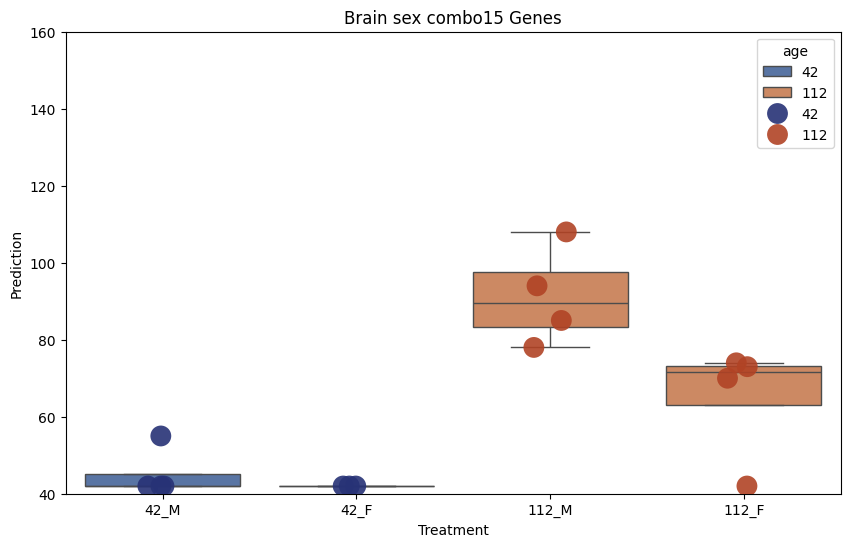

In [ ]:
ordered_x = [
    '42_M', '42_F',
    '112_M', '112_F'
]


# Create the box plot
plt.figure(figsize=(10, 6))
box = sns.boxplot(x='age_sex', y='prediction', hue='age', data=df_intervention_test_pred, palette='deep', showfliers = False,
    order = ordered_x)

# Add data points

custom_palette = ['#273276', '#B14325']  # Use desired hex color codes

# Add data points with custom colors
strip = sns.stripplot(
    x='age_sex',
    y='prediction',
    hue='age',
    data=df_intervention_test_pred,
    palette=custom_palette,  # Custom color palette
    dodge=False,
    alpha=0.9,
    jitter=True,
    size=15,
    order = ordered_x
)

# Remove the legend if not needed
#strip.legend_.remove()

# Customize the plot
plt.title("".join(['Brain sex combo', str(gene_number), ' Genes']))
plt.xlabel('Treatment')
plt.ylabel('Prediction')

# Set y-axis limits
plt.ylim(40, 160)

# Remove the grid
plt.grid(False)


# Show the plot
plt.show()

In [ ]:
df_intervention_test_pred.to_csv("./df_prediction_BayesAge_Xu_brain_sexcombo.csv", sep="\t")

##### Try several gene set sizes

In [ ]:
# Set up ordered x-axis for plots
ordered_x = [
    '42_M', '42_F',
    '112_M', '112_F'
]

# Custom color palette
custom_palette = ['#273276', '#B14325']

# Directory setup
os.makedirs("./predictions", exist_ok=True)
os.makedirs("./plots", exist_ok=True)

# Dictionary to store prediction DataFrames if needed later
all_predictions = {}

# Loop through gene numbers
for gene_number in range(5, 101, 5):
    print(f"Running prediction for top {gene_number} genes...")

    df_intervention_test_pred = pd.DataFrame(index=df_intervention_test.index, columns=["prediction"])

    for sample in df_intervention_test.index.tolist():
        reference_df = pd.read_csv(f"./brain/reference/killifish_brain_reference_sexcombo", sep="\t", index_col=0)
        top_genes = reference_df["spearman_rank"].abs().nlargest(gene_number).index.tolist()

        total_reads_sample = df_intervention_test_counts.loc[sample].sum()
        list_of_profile_probabilities_per_age = []

        for age in new_age_steps:
            log_probs = []
            for gene in top_genes:
                gene_frequency = reference_df.loc[gene, str(age)]
                gene_frequency = max(gene_frequency, 1e-10)  # Ensure >0

                expected = gene_frequency * total_reads_sample
                observed = df_intervention_test_counts.loc[sample, gene]

                poisson_prob = poisson.pmf(k=observed, mu=expected)
                poisson_prob = max(poisson_prob, 0.001)

                log_probs.append(np.log(poisson_prob))

            list_of_profile_probabilities_per_age.append(np.sum(log_probs))

        age_probability_df = pd.DataFrame({"Pr": list_of_profile_probabilities_per_age}, index=new_age_steps)
        max_probability_age = round(float(age_probability_df.idxmax().iloc[0]), 2)
        df_intervention_test_pred.loc[sample, "prediction"] = max_probability_age

    # Add metadata
    df_intervention_test_pred["age"] = df_intervention_test["age"].tolist()
    df_intervention_test_pred["sex"] = df_intervention_test["sex"].tolist()


    df_intervention_test_pred["age_sex"] = (
        df_intervention_test_pred["age"].astype(str) + "_" +
        df_intervention_test_pred["sex"].astype(str)
    )

    # Save predictions
    all_predictions[gene_number] = df_intervention_test_pred.copy()
    df_intervention_test_pred.to_csv(f"./predictions/age_preds_top_{gene_number}_genes.tsv", sep="\t")

    # --- Plot ---
    plt.figure(figsize=(10, 6))

    box = sns.boxplot(
        x='age_sex',
        y='prediction',
        hue='age',
        data=df_intervention_test_pred,
        palette='deep',
        showfliers=False,
        order=ordered_x
    )

    strip = sns.stripplot(
        x='age_sex',
        y='prediction',
        hue='age',
        data=df_intervention_test_pred,
        palette=custom_palette,
        dodge=False,
        alpha=0.9,
        jitter=True,
        size=15,
        order=ordered_x
    )

    # Remove duplicate legend
    strip.legend_.remove()

    plt.title(f"Brain sex combo {gene_number} Genes")
    plt.xlabel('Treatment')
    plt.ylabel('Prediction')
    plt.xticks(rotation=45, ha='right')
    plt.ylim(40, 160)
    plt.grid(False)

    # Save plot
    plt.savefig(f"./plots/xu_brain_sexcombo_top_{gene_number}_genes.svg", dpi=300, bbox_inches="tight")
    plt.close()

    print(f"Saved plot and prediction for {gene_number} genes.\n")


Running prediction for top 5 genes...
Saved plot and prediction for 5 genes.

Running prediction for top 10 genes...
Saved plot and prediction for 10 genes.

Running prediction for top 15 genes...
Saved plot and prediction for 15 genes.

Running prediction for top 20 genes...
Saved plot and prediction for 20 genes.

Running prediction for top 25 genes...
Saved plot and prediction for 25 genes.

Running prediction for top 30 genes...
Saved plot and prediction for 30 genes.

Running prediction for top 35 genes...
Saved plot and prediction for 35 genes.

Running prediction for top 40 genes...
Saved plot and prediction for 40 genes.

Running prediction for top 45 genes...
Saved plot and prediction for 45 genes.

Running prediction for top 50 genes...
Saved plot and prediction for 50 genes.

Running prediction for top 55 genes...
Saved plot and prediction for 55 genes.

Running prediction for top 60 genes...
Saved plot and prediction for 60 genes.

Running prediction for top 65 genes...
Sav

##### plot stability of preds

/tmp/ipython-input-1924167849.py:64: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
/tmp/ipython-input-1924167849.py:64: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
/tmp/ipython-input-1924167849.py:64: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
/tmp/ipython-input-1924167849.py:64: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


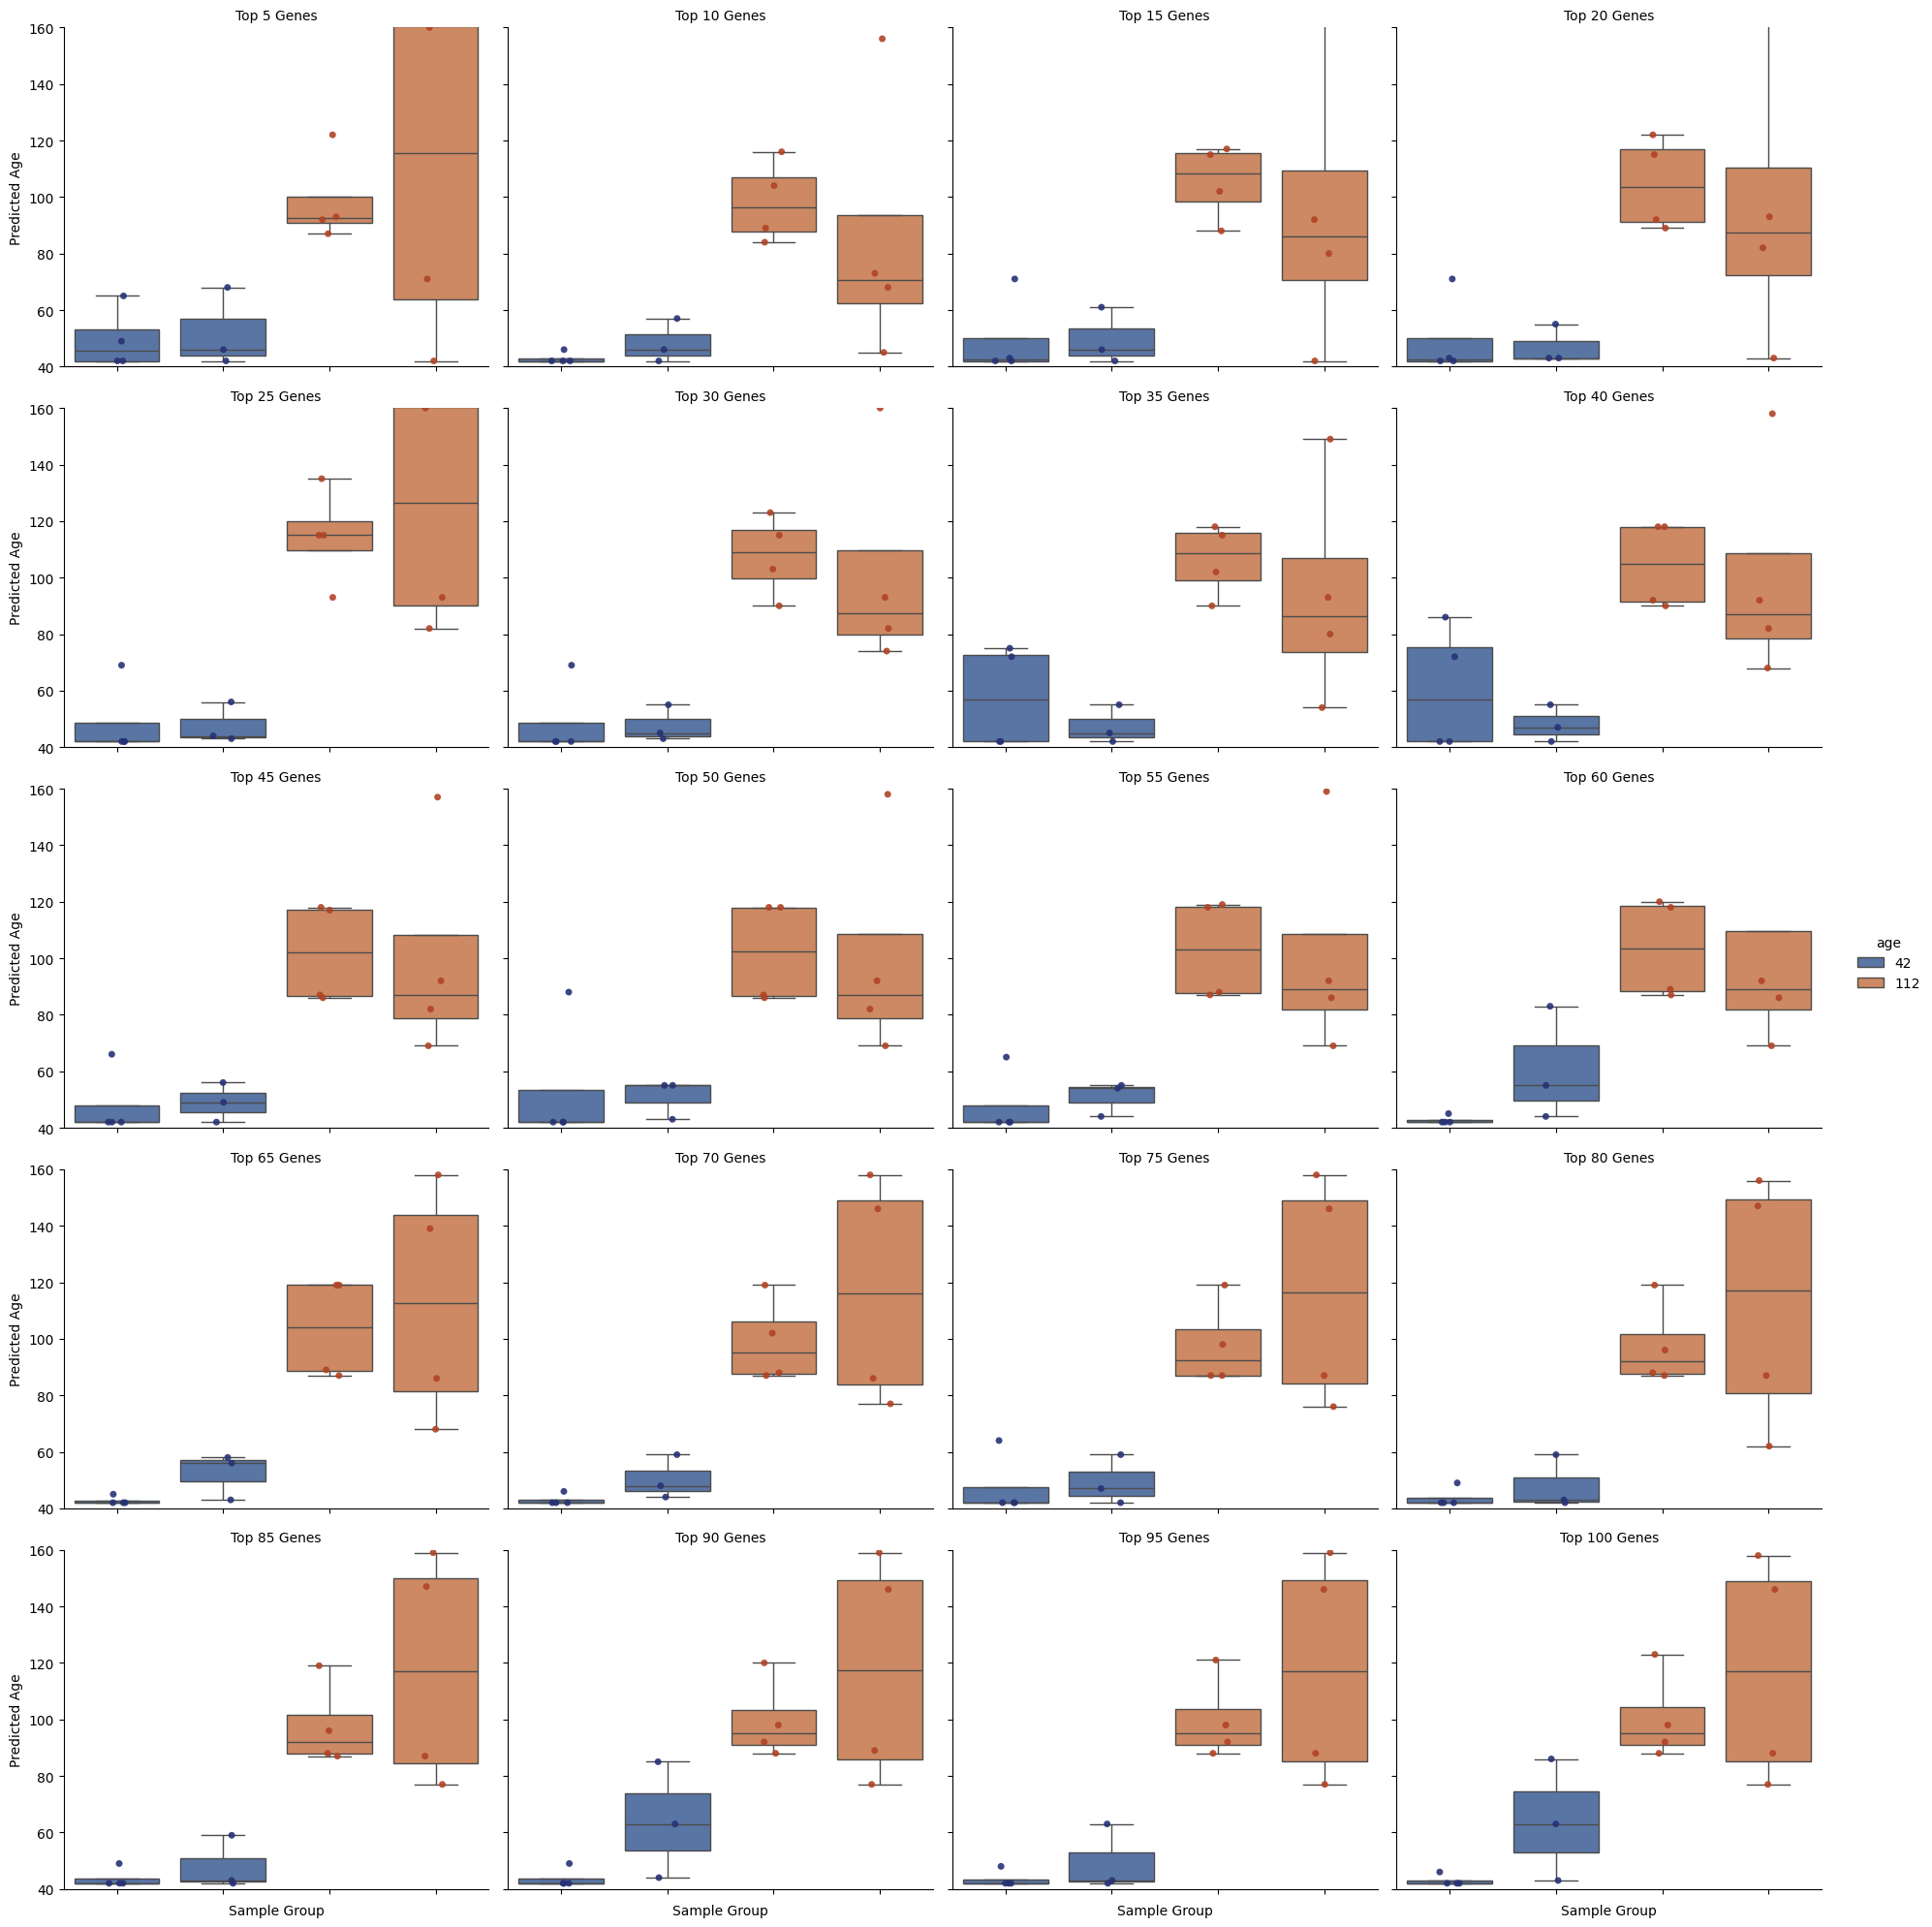

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import os

# Ordered x-axis
ordered_x = [
    '42_M', '42_F',
    '112_M', '112_F'
]

# Custom palette
custom_palette = ['#273276', '#B14325']

# Load all prediction files
all_predictions_list = []

for gene_number in range(5, 101, 5):
    file_path = f"./predictions/age_preds_top_{gene_number}_genes.tsv"
    if os.path.exists(file_path):
        df = pd.read_csv(file_path, sep="\t", index_col=0)
        df["gene_number"] = str(gene_number)  # for cleaner facet titles
        all_predictions_list.append(df)
    else:
        print(f"Warning: {file_path} not found. Skipping.")

# Concatenate into a single DataFrame
all_predictions_df = pd.concat(all_predictions_list, axis=0)

# Plot with seaborn FacetGrid (catplot)
g = sns.catplot(
    data=all_predictions_df,
    x="age_sex",
    y="prediction",
    hue="age",
    col="gene_number",
    col_wrap=4,
    kind="box",
    palette='deep',
    order=ordered_x,
    height=4,
    aspect=1.2,
    showfliers=False
)

# Overlay stripplot for better visualization
for ax, gene_number in zip(g.axes.flat, all_predictions_df["gene_number"].unique()):
    subset = all_predictions_df[all_predictions_df["gene_number"] == gene_number]
    sns.stripplot(
        x='age_sex',
        y='prediction',
        hue='age',
        data=subset,
        palette=custom_palette,
        dodge=False,
        alpha=0.9,
        jitter=True,
        size=5,
        order=ordered_x,
        ax=ax,
        legend=False
    )
    ax.set_title(f"Top {gene_number} Genes")
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
    ax.set_ylim(40, 160)

g.set_axis_labels("Sample Group", "Predicted Age")
g.set_titles("Top {col_name} Genes")
g.tight_layout()
plt.savefig("./plots/brain_sex_combo_faceted_predictions_by_gene_number.svg", dpi=300, bbox_inches="tight")
plt.show()


In [ ]:
# List of directories you want to create
dirs_to_create = [
    "./predictions_exhaustive/brain/",
    "./reference_exhaustive/brain/"
]


for d in dirs_to_create:
    os.makedirs(d, exist_ok=True)  # exist_ok=True won't raise an error if it already exists

In [ ]:
#------------------------------------------------------------
# Sample selection setup
#------------------------------------------------------------
#select two AL samples for calibration
all_samples = df_intervention_combo.index

# Separate the samples
young_samples = [s for s in all_samples if s in df_intervention_combo.index and df_intervention_combo.loc[s, 'age'] == 42]
old_samples = [s for s in all_samples if s in df_intervention_combo.index and df_intervention_combo.loc[s, 'age'] ==  112]

# Create all 2x2 combinations
young_combos = list(itertools.combinations(young_samples, 2))
old_combos = list(itertools.combinations(old_samples, 2))


#------------------------------------------------------------
# Loop through all young-old combinations
#------------------------------------------------------------
for y_combo in young_combos:
    for o_combo in old_combos:

        combo_id = f"{'_'.join(map(str, y_combo))}__{'_'.join(map(str, o_combo))}"
        print(f"\nRunning combo: {combo_id}")

        # Select samples for training
        select_train_samples = list(y_combo) + list(o_combo)
        df_intervention_train = df_intervention_combo.loc[select_train_samples]
        df_intervention_train = df_intervention_train[tissue_df_counts.columns]  # match columns

        # Combine with atlas
        atlas_plus_intervention = pd.concat([tissue_df_counts, df_intervention_train], axis=0)
        age_steps = sorted(atlas_plus_intervention["age"].value_counts().index.tolist())
        atlas_plus_intervention = atlas_plus_intervention.drop(atlas_plus_intervention.columns[[-2, -3]], axis=1)

        # Get test set
        test_samples = [s for s in df_intervention_combo.index if s not in select_train_samples]
        df_intervention_test = df_intervention_combo.loc[test_samples]
        df_intervention_test_counts = df_intervention_test.drop(
            df_intervention_test.columns[[-2, -3, -4, -5]], axis=1
        )

        #check cols ordered the same
        df_intervention_test_counts = df_intervention_test_counts[atlas_plus_intervention.columns]
        df_intervention_test_counts.head(2)

        # Save per-sample reference files
        for sample in atlas_plus_intervention.index:
            atlas_plus_intervention.drop(sample).to_csv(
                f"./brain/reference/brain_sample_{sample}_{combo_id}.csv", sep="\t"
            )

        new_age_steps = np.arange(min(age_steps), max(age_steps) + 1, 1)


        # Run transcriptome_reference (assuming it handles saving internally)
        transcriptome_reference(
            training_matrix=atlas_plus_intervention,
            reference_name=f"killifish_brain_ref_sexcombo_{combo_id}",
            output_path="./reference_exhaustive/brain/",
            age_prediction="list",
            age_list=new_age_steps,
            min_age=1,
            max_age=24,
            age_step=1,
            tau=0.7
        )


        # Run predictions for a single gene number or loop over multiple
        for gene_number in range(5, 51, 5):
            df_pred = pd.DataFrame(index=df_intervention_test.index, columns=["prediction"])
            reference_df = pd.read_csv(
                f"./reference_exhaustive/brain/killifish_brain_ref_sexcombo_{combo_id}", sep="\t", index_col=0
            )
            top_genes = reference_df["spearman_rank"].abs().nlargest(gene_number).index.tolist()

            for sample in df_intervention_test.index:
                total_reads = df_intervention_test_counts.loc[sample].sum()
                log_sums = []
                for age in new_age_steps:
                    logP = []
                    for gene in top_genes:
                        freq = max(reference_df.loc[gene, str(age)], 1e-10)
                        mu = freq * total_reads
                        obs = df_intervention_test_counts.loc[sample, gene]
                        p = max(poisson.pmf(obs, mu), 0.001)
                        logP.append(np.log(p))
                    log_sums.append(np.sum(logP))

                pred_age = round(float(new_age_steps[np.argmax(log_sums)]), 2)
                df_pred.loc[sample, "prediction"] = pred_age

            # Add metadata and save
            df_pred["age"] = df_intervention_test["age"]
            df_pred["sex"] = df_intervention_test["sex"]


            # Save prediction results
            df_pred.to_csv(
                f"./predictions_exhaustive/brain/brain_sexcombo_pred_top_{gene_number}_{combo_id}.tsv", sep="\t"
            )



Running combo: brain_10_brain_9__brain_20_brain_19


/tmp/ipython-input-2002720175.py:41: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho, p = spearmanr(age_training, gene_frequency)



Reference model dataset written to './reference_exhaustive/brain/killifish_brain_ref_sexcombo_brain_10_brain_9__brain_20_brain_19'
Report file generated at './reference_exhaustive/brain/killifish_brain_ref_sexcombo_brain_10_brain_9__brain_20_brain_19.report.txt'
-----------------------------------------------------



Time to run construct reference: 120.535 seconds

The reference is constructed and saved!

Running combo: brain_10_brain_9__brain_20_brain_18


/tmp/ipython-input-2002720175.py:41: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho, p = spearmanr(age_training, gene_frequency)



Reference model dataset written to './reference_exhaustive/brain/killifish_brain_ref_sexcombo_brain_10_brain_9__brain_20_brain_18'
Report file generated at './reference_exhaustive/brain/killifish_brain_ref_sexcombo_brain_10_brain_9__brain_20_brain_18.report.txt'
-----------------------------------------------------



Time to run construct reference: 118.397 seconds

The reference is constructed and saved!

Running combo: brain_10_brain_9__brain_20_brain_17


...


Reference model dataset written to './reference_exhaustive/brain/killifish_brain_ref_sexcombo_brain_10_brain_8__brain_15_brain_14'
Report file generated at './reference_exhaustive/brain/killifish_brain_ref_sexcombo_brain_10_brain_8__brain_15_brain_14.report.txt'
-----------------------------------------------------



Time to run construct reference: 113.351 seconds

The reference is constructed and saved!

Running combo: brain_10_brain_8__brain_15_brain_13


/tmp/ipython-input-2002720175.py:41: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho, p = spearmanr(age_training, gene_frequency)



Reference model dataset written to './reference_exhaustive/brain/killifish_brain_ref_sexcombo_brain_10_brain_8__brain_15_brain_13'
Report file generated at './reference_exhaustive/brain/killifish_brain_ref_sexcombo_brain_10_brain_8__brain_15_brain_13.report.txt'
-----------------------------------------------------



Time to run construct reference: 113.342 seconds

The reference is constructed and saved!

Running combo: brain_10_brain_8__brain_15_brain_12


/tmp/ipython-input-2002720175.py:41: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho, p = spearmanr(age_training, gene_frequency)



Reference model dataset written to './reference_exhaustive/brain/killifish_brain_ref_sexcombo_brain_10_brain_8__brain_15_brain_12'
Report file generated at './reference_exhaustive/brain/killifish_brain_ref_sexcombo_brain_10_brain_8__brain_15_brain_12.report.txt'
-----------------------------------------------------



Time to run construct reference: 115.343 seconds

The reference is constructed and saved!


### Male only

In [ ]:
df_intervention_combo.head(2)

,nadsyn1,dnaja3,f2r,LOC107382877,fezf1,srbd1,LOC107373267,LOC107384240,serp1,scarb2,...,umodl1,cryz,LOC107397181,pelo,mrpl35,tissue,AGE,sex,training,age
brain_10,59,200,66,148,29,175,0,0,67,388,...,10,30,898,95,37,Brain,6w,F,No,42
brain_9,120,236,78,146,28,225,4,0,167,492,...,4,38,1037,158,46,Brain,6w,F,No,42


In [ ]:
df_intervention_male = df_intervention_combo.loc[
    (df_intervention_combo.iloc[:, -3] == 'M')
]

In [ ]:
all_samples = df_intervention_male.index
all_samples

random.seed(123)

# Separate the samples
young_samples = [s for s in all_samples if s in df_intervention_male.index and df_intervention_male.loc[s, 'age'] == 42]
old_samples = [s for s in all_samples if s in df_intervention_male.index and df_intervention_male.loc[s, 'age'] ==  112]

# Randomly sample 2 from each
random_young = random.sample(young_samples, 2)
random_old = random.sample(old_samples, 2)

# Combine the result
random_subset = random_young + random_old

#select your training samples
select_train_samples = random_subset

# Select rows in df_intervention_age_counts_female where index is in female_samples
df_intervention_train = df_intervention_male.loc[
    df_intervention_male.index.isin(select_train_samples)
]

df_intervention_train

,nadsyn1,dnaja3,f2r,LOC107382877,fezf1,srbd1,LOC107373267,LOC107384240,serp1,scarb2,...,umodl1,cryz,LOC107397181,pelo,mrpl35,tissue,AGE,sex,training,age
brain_5,66,141,32,111,12,139,0,0,90,307,...,4,34,611,143,20,Brain,6w,M,No,42
brain_3,119,235,100,160,6,139,4,0,152,392,...,6,42,1091,118,50,Brain,6w,M,No,42
brain_15,107,142,64,126,22,134,0,0,92,409,...,10,16,843,125,30,Brain,16w,M,No,112
brain_12,81,144,50,89,23,144,2,0,106,392,...,4,8,852,120,48,Brain,16w,M,No,112


In [ ]:
# get your testing samples
#all not in select_train_samples
test_samples = [s for s in all_samples if s not in select_train_samples]
test_samples

['brain_4', 'brain_14', 'brain_13', 'brain_11', 'brain_2', 'brain_1']

In [ ]:
# Select rows in df_intervention_age_counts_female where index is in female_samples
df_intervention_test = df_intervention_male.loc[
    df_intervention_male.index.isin(test_samples)
]

df_intervention_test

,nadsyn1,dnaja3,f2r,LOC107382877,fezf1,srbd1,LOC107373267,LOC107384240,serp1,scarb2,...,umodl1,cryz,LOC107397181,pelo,mrpl35,tissue,AGE,sex,training,age
brain_4,145,288,106,188,36,233,0,2,163,594,...,8,49,863,175,52,Brain,6w,M,No,42
brain_14,100,180,84,148,20,166,2,0,79,494,...,0,12,1137,125,20,Brain,16w,M,No,112
brain_13,121,129,72,112,16,149,0,0,112,446,...,2,17,817,140,32,Brain,16w,M,No,112
brain_11,88,124,52,146,12,106,0,0,97,382,...,2,14,655,130,42,Brain,16w,M,No,112
brain_2,528,851,529,980,81,593,17,6,521,1901,...,93,154,4867,768,180,Brain,6w,M,No,42
brain_1,646,1131,439,885,92,935,8,0,763,2276,...,243,195,5656,737,232,Brain,6w,M,No,42


##### transcriptome reference

In [ ]:
# # Specify the path for the new directory for the tissue
# directory_path = "./brain/male/"

# # Create the directory
# os.mkdir(directory_path)

In [ ]:
tissue_df_counts.head(1)

,a1cf,aaas,aacs,aadat,aaed1,aagab,aak1,aamdc,aamp,aar2,...,zufsp,zw10,zwilch,zyg11b,zyx,zzef1,zzz3,sex,tissue,age
A21_2,97,929,895,571,266,1008,4422,601,898,771,...,396,1124,35,1873,1132,294,616,M,Brain,162


In [ ]:
#select raw counts
tissue_df_counts = combined_df.loc[
    (combined_df.iloc[:, -2] == select_tissue) &
     (combined_df.iloc[:, -3] == 'M')
]
tissue_df_counts.head(5)

,a1cf,aaas,aacs,aadat,aaed1,aagab,aak1,aamdc,aamp,aar2,...,zufsp,zw10,zwilch,zyg11b,zyx,zzef1,zzz3,sex,tissue,age
A21_2,97,929,895,571,266,1008,4422,601,898,771,...,396,1124,35,1873,1132,294,616,M,Brain,162
A22_2,97,804,995,643,176,887,4179,502,820,839,...,487,1142,39,2228,1671,338,820,M,Brain,152
A24_2,74,929,717,564,169,839,3392,532,556,719,...,386,981,40,1700,1317,268,711,M,Brain,103
B21_2,91,1142,1030,887,253,1051,4066,404,891,1066,...,532,1756,54,2382,2295,424,695,M,Brain,162
B22_2,87,1125,781,687,158,767,4102,540,730,696,...,360,1164,44,2457,1733,540,818,M,Brain,49


In [ ]:
df_intervention_train = df_intervention_train[tissue_df_counts.columns]
df_intervention_train.head(2)

,a1cf,aaas,aacs,aadat,aaed1,aagab,aak1,aamdc,aamp,aar2,...,zufsp,zw10,zwilch,zyg11b,zyx,zzef1,zzz3,sex,tissue,age
brain_10,18,105,209,76,8,170,444,61,127,56,...,55,106,15,416,172,640,514,F,Brain,42
brain_6,78,66,166,58,20,66,391,31,68,50,...,35,116,4,312,203,760,399,F,Brain,42


In [ ]:
atlas_plus_intervention = pd.concat([tissue_df_counts, df_intervention_train], axis=0)
atlas_plus_intervention.head(3)

,a1cf,aaas,aacs,aadat,aaed1,aagab,aak1,aamdc,aamp,aar2,...,zwilch,zyg11b,zyx,zzef1,zzz3,sex,tissue,age,AGE,training
A21_2,97,929,895,571,266,1008,4422,601,898,771,...,35,1873,1132,294,616,M,Brain,162,NaN,NaN
A22_2,97,804,995,643,176,887,4179,502,820,839,...,39,2228,1671,338,820,M,Brain,152,NaN,NaN
A24_2,74,929,717,564,169,839,3392,532,556,719,...,40,1700,1317,268,711,M,Brain,103,NaN,NaN


In [ ]:
# #check cols ordered the same
# df_intervention_test = df_intervention_test[tissue_df_counts.columns]
# df_intervention_test.head(2)

In [ ]:
tissue_age_days_value_counts = atlas_plus_intervention["age"].value_counts().index.tolist()

In [ ]:
age_steps = sorted(tissue_age_days_value_counts)

print(age_steps)

[42, 47, 49, 52, 75, 77, 78, 102, 103, 112, 133, 134, 147, 152, 161, 162]


In [ ]:
atlas_plus_intervention_age = atlas_plus_intervention.drop(atlas_plus_intervention.columns[[-1,-2, -4,-5]], axis=1)
atlas_plus_intervention_age.head(2)

,a1cf,aaas,aacs,aadat,aaed1,aagab,aak1,aamdc,aamp,aar2,...,zswim7,zswim8,zufsp,zw10,zwilch,zyg11b,zyx,zzef1,zzz3,age
A21_2,97,929,895,571,266,1008,4422,601,898,771,...,189,966,396,1124,35,1873,1132,294,616,162
A22_2,97,804,995,643,176,887,4179,502,820,839,...,118,1409,487,1142,39,2228,1671,338,820,152


In [ ]:
#sample generation
for sample in atlas_plus_intervention_age.index.tolist():

    new_df = atlas_plus_intervention_age.drop(sample)

    new_df.to_csv(f"./brain/male/brain_male_sample_{sample}.csv", sep="\t")

In [ ]:
new_age_steps = np.arange(min(age_steps), max(age_steps)+1, 1)

In [ ]:
# Specify the path for the new directory for the tissue
directory_path = "./brain/male/reference"

# Create the directory
os.mkdir(directory_path)

In [ ]:
transcriptome_reference(training_matrix= atlas_plus_intervention_age,
                            reference_name="killifish_brain_reference_male",
                            output_path="./brain/male/reference/",
                            age_prediction="list",
                            age_list=new_age_steps,
                            min_age=1,
                            max_age=24,
                            age_step=1,
                            tau=0.7)

/tmp/ipython-input-59-2002720175.py:41: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho, p = spearmanr(age_training, gene_frequency)



Reference model dataset written to './brain/male/reference/killifish_brain_reference_male'
Report file generated at './brain/male/reference/killifish_brain_reference_male.report.txt'
-----------------------------------------------------



Time to run construct reference: 125.271 seconds

The reference is constructed and saved!


,42,43,44,45,46,47,48,49,50,51,...,155,156,157,158,159,160,161,162,spearman_rank,p_value
Gene,,,,,,,,,,,,,,,,,,,,,
a1cf,0.000003,0.000003,0.000003,0.000003,0.000003,0.000003,0.000003,0.000003,0.000003,0.000003,...,0.000003,0.000003,0.000003,0.000003,0.000003,0.000003,0.000003,0.000003,-0.052924,0.762697
aaas,0.000030,0.000030,0.000030,0.000030,0.000030,0.000030,0.000030,0.000030,0.000030,0.000030,...,0.000027,0.000027,0.000027,0.000027,0.000027,0.000027,0.000027,0.000027,-0.155682,0.371835
aacs,0.000030,0.000030,0.000030,0.000030,0.000030,0.000029,0.000029,0.000029,0.000029,0.000029,...,0.000027,0.000027,0.000027,0.000027,0.000027,0.000027,0.000027,0.000027,-0.364850,0.031162
aadat,0.000018,0.000018,0.000018,0.000018,0.000018,0.000018,0.000018,0.000018,0.000018,0.000018,...,0.000018,0.000018,0.000018,0.000018,0.000018,0.000018,0.000018,0.000018,0.019513,0.911412
aaed1,0.000005,0.000005,0.000005,0.000005,0.000005,0.000005,0.000005,0.000005,0.000005,0.000005,...,0.000006,0.000006,0.000006,0.000006,0.000006,0.000006,0.000006,0.000006,0.314874,0.065425
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
zwilch,0.000002,0.000002,0.000002,0.000002,0.000002,0.000002,0.000002,0.000002,0.000002,0.000002,...,0.000001,0.000001,0.000001,0.000001,0.000001,0.000001,0.000001,0.000001,-0.429565,0.010016
zyg11b,0.000068,0.000068,0.000068,0.000068,0.000068,0.000067,0.000067,0.000067,0.000067,0.000067,...,0.000067,0.000067,0.000067,0.000067,0.000067,0.000067,0.000067,0.000067,-0.063873,0.715463
zyx,0.000046,0.000046,0.000046,0.000046,0.000046,0.000046,0.000046,0.000046,0.000046,0.000046,...,0.000046,0.000046,0.000046,0.000046,0.000046,0.000046,0.000046,0.000046,0.080438,0.645989


In [ ]:
df_intervention_test.head(1)

,nadsyn1,dnaja3,f2r,LOC107382877,fezf1,srbd1,LOC107373267,LOC107384240,serp1,scarb2,...,umodl1,cryz,LOC107397181,pelo,mrpl35,tissue,AGE,sex,training,age
brain_4,145,288,106,188,36,233,0,2,163,594,...,8,49,863,175,52,Brain,6w,M,No,42


In [ ]:
df_intervention_test_counts = df_intervention_test.drop(df_intervention_test.columns[[-2, -3,-4, -5]], axis=1)
df_intervention_test_counts.head(3)

,nadsyn1,dnaja3,f2r,LOC107382877,fezf1,srbd1,LOC107373267,LOC107384240,serp1,scarb2,...,plekhg1,LOC107373049,LOC107375201,LOC107384697,umodl1,cryz,LOC107397181,pelo,mrpl35,age
brain_4,145,288,106,188,36,233,0,2,163,594,...,947,2,8,22,8,49,863,175,52,42
brain_14,100,180,84,148,20,166,2,0,79,494,...,279,2,18,12,0,12,1137,125,20,112
brain_13,121,129,72,112,16,149,0,0,112,446,...,671,4,10,6,2,17,817,140,32,112


In [ ]:
gene_number = 15
df_intervention_test_pred = pd.DataFrame(index=df_intervention_test.index, columns=["prediction"])

for sample in df_intervention_test.index.tolist():

    reference_df = pd.read_csv(f"./brain/male/reference/killifish_brain_reference_male", sep="\t", index_col=0)

    # Get top genes based on spearman correlation
    top_abs_spearman_corr = reference_df["spearman_rank"].abs().nlargest(gene_number)

    #print(top_abs_spearman_corr)

    top_genes = top_abs_spearman_corr.index.tolist()

    # Save the DataFrame to a CSV file
    # df_top_genes = pd.DataFrame(top_genes, columns=["genes"])
    # gene_num = "".join([str(gene_number), "genes"])
    # out_file_prefix = 'Antebi_male_pred'
    # out_file_name = "_".join([out_file_prefix, gene_num])
    # output_path = './fat/gene_sets'
    # df_top_genes.to_csv(os.path.join(output_path, out_file_name), sep="\t")
    # print(f"List has been written to {out_file_name}")

    total_reads_sample = df_intervention_test_counts.loc[sample].sum()

    list_of_profile_probabilities_per_age = []

    for age in new_age_steps:

        probability_list_one_age = []

        genes_not_defined = []

        for gene in top_genes:

            gene_frequency = reference_df.loc[gene, f"{age}"]

            if gene_frequency < 0:
                gene_frequency = 10**-10

            sample_expected_counts = gene_frequency * total_reads_sample
            sample_observed_counts = df_intervention_test_counts.loc[sample, gene]

            poisson_probability = poisson.pmf(k=sample_observed_counts, mu=sample_expected_counts)

            # Replace NaN poisson probability with a small positive value and log it
            if np.isnan(poisson_probability):
                poisson_probability = 0.001
                genes_not_defined.append(gene)

            # Replace zero poisson probability with 0.001
            if poisson_probability == 0:
                poisson_probability = 0.001

            logP = np.log(poisson_probability)

            probability_list_one_age.append(logP)

        list_of_profile_probabilities_per_age.append(np.sum(probability_list_one_age))

    # Transform into dataframe with age steps
    age_probability_df = pd.DataFrame({"Pr": list_of_profile_probabilities_per_age}, index=new_age_steps)

    # Compute highest likelihood age among age steps
    max_probability_age = round(float(age_probability_df.idxmax().iloc[0]), 2)

    # Compute highest maximum probability
    max_probability = float(age_probability_df["Pr"].max())

    df_intervention_test_pred.loc[sample, "prediction"] = max_probability_age



print(df_intervention_test_pred)

         prediction
brain_4        96.0
brain_14      146.0
brain_13       59.0
brain_11      155.0
brain_2        50.0
brain_1        54.0


In [ ]:
df_intervention_test_pred["age"] = df_intervention_test["age"].tolist()
df_intervention_test_pred["sex"] = df_intervention_test["sex"].tolist()


df_intervention_test_pred["age_sex"] = (
    df_intervention_test_pred["age"].astype(str) + "_" +
    df_intervention_test_pred["sex"].astype(str)
)

df_intervention_test_pred

,prediction,age,sex,age_sex
brain_4,96.0,42,M,42_M
brain_14,146.0,112,M,112_M
brain_13,59.0,112,M,112_M
brain_11,155.0,112,M,112_M
brain_2,50.0,42,M,42_M
brain_1,54.0,42,M,42_M


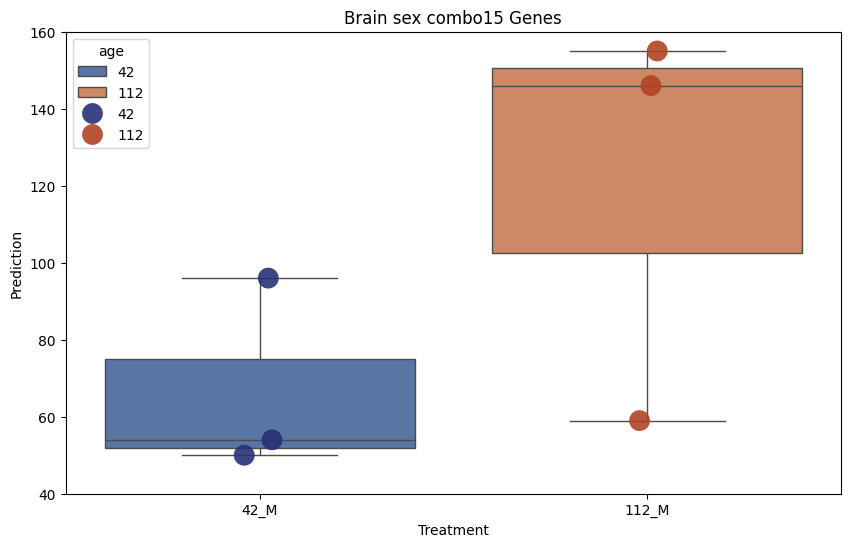

In [ ]:
ordered_x = [
    '42_M','112_M'
]


# Create the box plot
plt.figure(figsize=(10, 6))
box = sns.boxplot(x='age_sex', y='prediction', hue='age', data=df_intervention_test_pred, palette='deep', showfliers = False,
    order = ordered_x)

# Add data points

custom_palette = ['#273276', '#B14325']  # Use desired hex color codes

# Add data points with custom colors
strip = sns.stripplot(
    x='age_sex',
    y='prediction',
    hue='age',
    data=df_intervention_test_pred,
    palette=custom_palette,  # Custom color palette
    dodge=False,
    alpha=0.9,
    jitter=True,
    size=15,
    order = ordered_x
)

# Remove the legend if not needed
#strip.legend_.remove()

# Customize the plot
plt.title("".join(['Brain sex combo', str(gene_number), ' Genes']))
plt.xlabel('Treatment')
plt.ylabel('Prediction')

# Set y-axis limits
plt.ylim(40, 160)

# Remove the grid
plt.grid(False)

#plt.savefig("".join(["./plots/liver_CR_top_",str(gene_number),"_genes.svg"]), dpi=300, bbox_inches="tight")

# Show the plot
plt.show()

##### Try several gene set sizes

In [ ]:
# Set up ordered x-axis for plots
ordered_x = [
    '42_M',
    '112_M'
]

# Custom color palette
custom_palette = ['#273276', '#B14325']

# Directory setup
os.makedirs("./predictions", exist_ok=True)
os.makedirs("./plots", exist_ok=True)

# Dictionary to store prediction DataFrames if needed later
all_predictions = {}

# Loop through gene numbers
for gene_number in range(5, 101, 5):
    print(f"Running prediction for top {gene_number} genes...")

    df_intervention_test_pred = pd.DataFrame(index=df_intervention_test.index, columns=["prediction"])

    for sample in df_intervention_test.index.tolist():
        reference_df = pd.read_csv(f"./brain/male/reference/killifish_brain_reference_male", sep="\t", index_col=0)
        top_genes = reference_df["spearman_rank"].abs().nlargest(gene_number).index.tolist()

        total_reads_sample = df_intervention_test_counts.loc[sample].sum()
        list_of_profile_probabilities_per_age = []

        for age in new_age_steps:
            log_probs = []
            for gene in top_genes:
                gene_frequency = reference_df.loc[gene, str(age)]
                gene_frequency = max(gene_frequency, 1e-10)  # Ensure >0

                expected = gene_frequency * total_reads_sample
                observed = df_intervention_test_counts.loc[sample, gene]

                poisson_prob = poisson.pmf(k=observed, mu=expected)
                poisson_prob = max(poisson_prob, 0.001)

                log_probs.append(np.log(poisson_prob))

            list_of_profile_probabilities_per_age.append(np.sum(log_probs))

        age_probability_df = pd.DataFrame({"Pr": list_of_profile_probabilities_per_age}, index=new_age_steps)
        max_probability_age = round(float(age_probability_df.idxmax().iloc[0]), 2)
        df_intervention_test_pred.loc[sample, "prediction"] = max_probability_age

    # Add metadata
    df_intervention_test_pred["age"] = df_intervention_test["age"].tolist()
    df_intervention_test_pred["sex"] = df_intervention_test["sex"].tolist()


    df_intervention_test_pred["age_sex"] = (
        df_intervention_test_pred["age"].astype(str) + "_" +
        df_intervention_test_pred["sex"].astype(str)
    )

    # Save predictions
    all_predictions[gene_number] = df_intervention_test_pred.copy()
    df_intervention_test_pred.to_csv(f"./predictions/age_maleOnly_preds_top_{gene_number}_genes.tsv", sep="\t")

    # --- Plot ---
    plt.figure(figsize=(10, 6))

    box = sns.boxplot(
        x='age_sex',
        y='prediction',
        hue='age',
        data=df_intervention_test_pred,
        palette='deep',
        showfliers=False,
        order=ordered_x
    )

    strip = sns.stripplot(
        x='age_sex',
        y='prediction',
        hue='age',
        data=df_intervention_test_pred,
        palette=custom_palette,
        dodge=False,
        alpha=0.9,
        jitter=True,
        size=15,
        order=ordered_x
    )

    # Remove duplicate legend
    strip.legend_.remove()

    plt.title(f"Brain sex combo {gene_number} Genes")
    plt.xlabel('Treatment')
    plt.ylabel('Prediction')
    plt.xticks(rotation=45, ha='right')
    plt.ylim(40, 160)
    plt.grid(False)

    # Save plot
    plt.savefig(f"./plots/xu_brain_maleOnly_top_{gene_number}_genes.svg", dpi=300, bbox_inches="tight")
    plt.close()

    print(f"Saved plot and prediction for {gene_number} genes.\n")


Running prediction for top 5 genes...
Saved plot and prediction for 5 genes.

Running prediction for top 10 genes...
Saved plot and prediction for 10 genes.

Running prediction for top 15 genes...
Saved plot and prediction for 15 genes.

Running prediction for top 20 genes...
Saved plot and prediction for 20 genes.

Running prediction for top 25 genes...
Saved plot and prediction for 25 genes.

Running prediction for top 30 genes...
Saved plot and prediction for 30 genes.

Running prediction for top 35 genes...
Saved plot and prediction for 35 genes.

Running prediction for top 40 genes...
Saved plot and prediction for 40 genes.

Running prediction for top 45 genes...
Saved plot and prediction for 45 genes.

Running prediction for top 50 genes...
Saved plot and prediction for 50 genes.

Running prediction for top 55 genes...
Saved plot and prediction for 55 genes.

Running prediction for top 60 genes...
Saved plot and prediction for 60 genes.

Running prediction for top 65 genes...
Sav

##### plot stability of preds

/tmp/ipython-input-123-710426559.py:64: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
/tmp/ipython-input-123-710426559.py:64: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
/tmp/ipython-input-123-710426559.py:64: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
/tmp/ipython-input-123-710426559.py:64: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


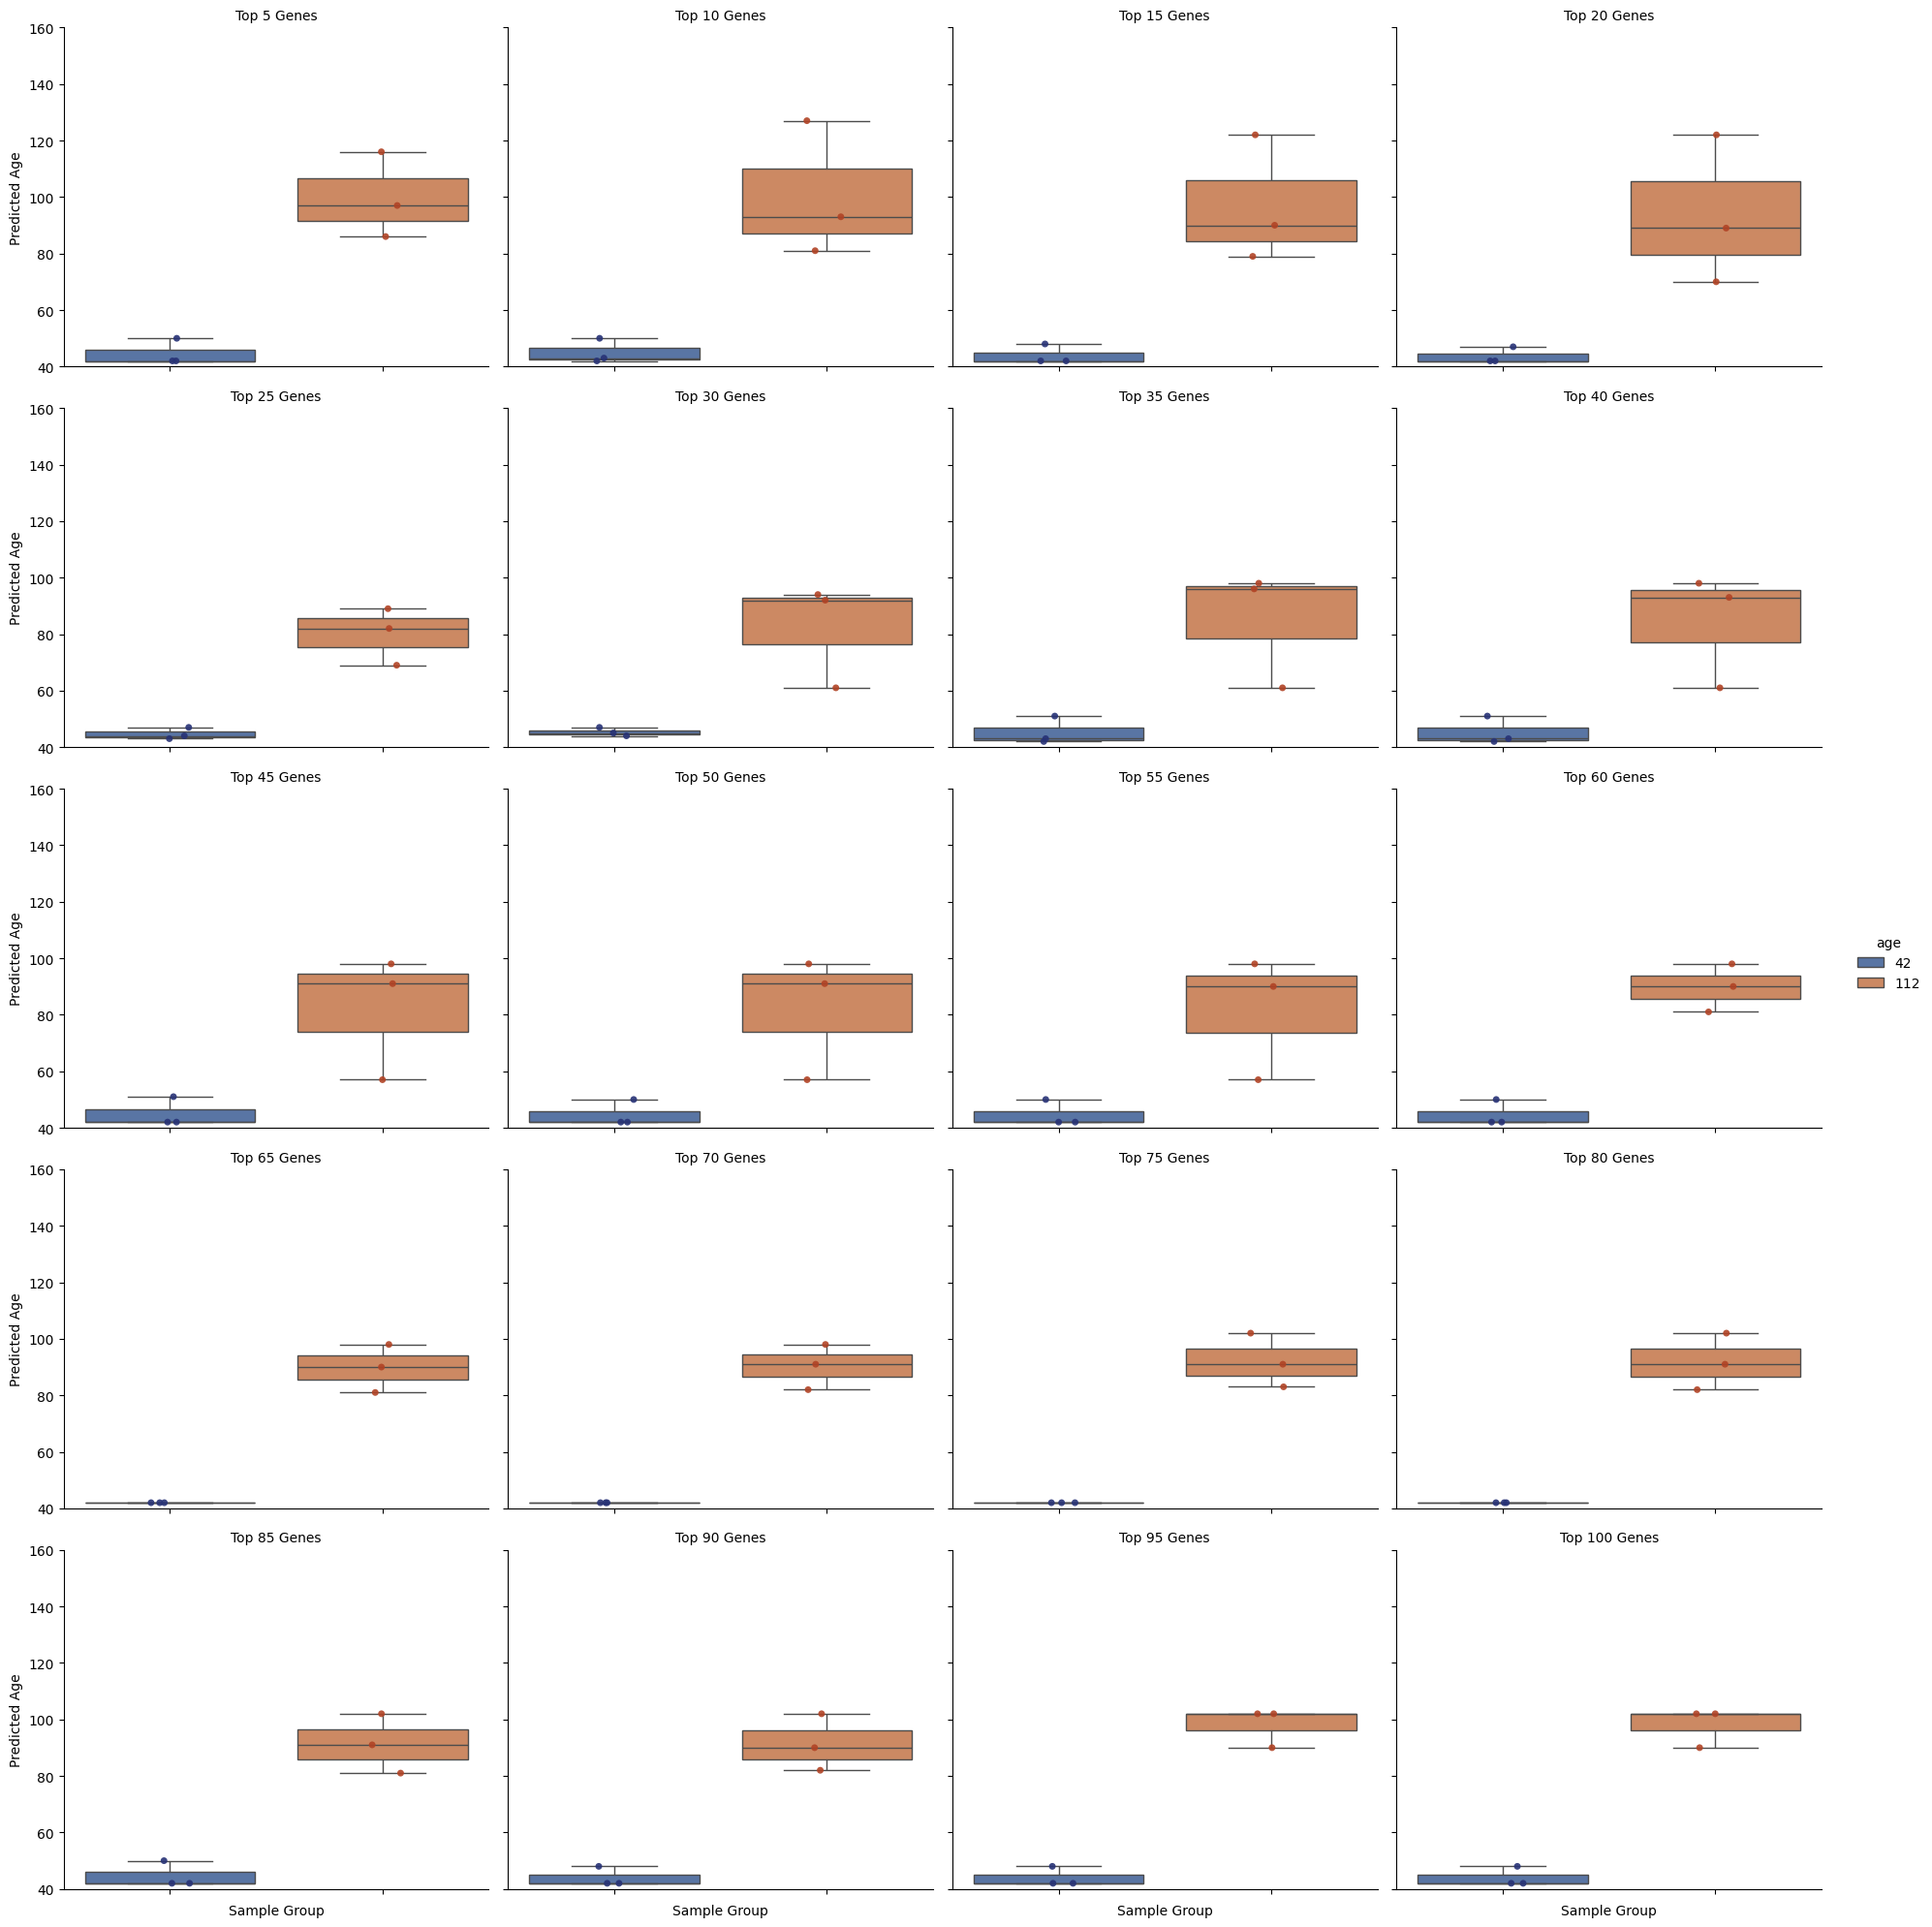

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import os

# Ordered x-axis
ordered_x = [
    '42_M',
    '112_M'
]

# Custom palette
custom_palette = ['#273276', '#B14325']

# Load all prediction files
all_predictions_list = []

for gene_number in range(5, 101, 5):
    file_path = f"./predictions/age_maleOnly_preds_top_{gene_number}_genes.tsv"
    if os.path.exists(file_path):
        df = pd.read_csv(file_path, sep="\t", index_col=0)
        df["gene_number"] = str(gene_number)  # for cleaner facet titles
        all_predictions_list.append(df)
    else:
        print(f"Warning: {file_path} not found. Skipping.")

# Concatenate into a single DataFrame
all_predictions_df = pd.concat(all_predictions_list, axis=0)

# Plot with seaborn FacetGrid (catplot)
g = sns.catplot(
    data=all_predictions_df,
    x="age_sex",
    y="prediction",
    hue="age",
    col="gene_number",
    col_wrap=4,
    kind="box",
    palette='deep',
    order=ordered_x,
    height=4,
    aspect=1.2,
    showfliers=False
)

# Overlay stripplot for better visualization
for ax, gene_number in zip(g.axes.flat, all_predictions_df["gene_number"].unique()):
    subset = all_predictions_df[all_predictions_df["gene_number"] == gene_number]
    sns.stripplot(
        x='age_sex',
        y='prediction',
        hue='age',
        data=subset,
        palette=custom_palette,
        dodge=False,
        alpha=0.9,
        jitter=True,
        size=5,
        order=ordered_x,
        ax=ax,
        legend=False
    )
    ax.set_title(f"Top {gene_number} Genes")
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
    ax.set_ylim(40, 160)

g.set_axis_labels("Sample Group", "Predicted Age")
g.set_titles("Top {col_name} Genes")
g.tight_layout()
plt.savefig("./plots/brain_maleOnly_faceted_predictions_by_gene_number.svg", dpi=300, bbox_inches="tight")
plt.show()


### Female only

In [ ]:
df_intervention_combo.head(2)

,nadsyn1,dnaja3,f2r,LOC107382877,fezf1,srbd1,LOC107373267,LOC107384240,serp1,scarb2,...,umodl1,cryz,LOC107397181,pelo,mrpl35,tissue,AGE,sex,training,age
brain_10,59,200,66,148,29,175,0,0,67,388,...,10,30,898,95,37,Brain,6w,F,No,42
brain_9,120,236,78,146,28,225,4,0,167,492,...,4,38,1037,158,46,Brain,6w,F,No,42


In [ ]:
df_intervention_female = df_intervention_combo.loc[
    (df_intervention_combo.iloc[:, -3] == 'F')
]

In [ ]:
all_samples = df_intervention_female.index
all_samples

random.seed(123)

# Separate the samples
young_samples = [s for s in all_samples if s in df_intervention_female.index and df_intervention_female.loc[s, 'age'] == 42]
old_samples = [s for s in all_samples if s in df_intervention_female.index and df_intervention_female.loc[s, 'age'] ==  112]

# Randomly sample 2 from each
random_young = random.sample(young_samples, 2)
random_old = random.sample(old_samples, 2)

# Combine the result
random_subset = random_young + random_old

#select your training samples
select_train_samples = random_subset

# Select rows in df_intervention_age_counts_female where index is in female_samples
df_intervention_train = df_intervention_female.loc[
    df_intervention_female.index.isin(select_train_samples)
]

df_intervention_train

,nadsyn1,dnaja3,f2r,LOC107382877,fezf1,srbd1,LOC107373267,LOC107384240,serp1,scarb2,...,umodl1,cryz,LOC107397181,pelo,mrpl35,tissue,AGE,sex,training,age
brain_10,59,200,66,148,29,175,0,0,67,388,...,10,30,898,95,37,Brain,6w,F,No,42
brain_9,120,236,78,146,28,225,4,0,167,492,...,4,38,1037,158,46,Brain,6w,F,No,42
brain_20,19,43,15,22,2,28,0,0,28,88,...,0,20,210,32,6,Brain,16w,F,No,112
brain_17,100,104,63,146,12,150,0,0,70,386,...,8,18,586,127,24,Brain,16w,F,No,112


In [ ]:
# get your testing samples
#all not in select_train_samples
test_samples = [s for s in all_samples if s not in select_train_samples]
test_samples

['brain_8', 'brain_7', 'brain_19', 'brain_18', 'brain_16']

In [ ]:
# Select rows in df_intervention_age_counts_female where index is in female_samples
df_intervention_test = df_intervention_female.loc[
    df_intervention_female.index.isin(test_samples)
]

df_intervention_test

,nadsyn1,dnaja3,f2r,LOC107382877,fezf1,srbd1,LOC107373267,LOC107384240,serp1,scarb2,...,umodl1,cryz,LOC107397181,pelo,mrpl35,tissue,AGE,sex,training,age
brain_8,96,208,70,150,24,179,4,0,116,326,...,10,32,1078,142,38,Brain,6w,F,No,42
brain_7,132,138,102,244,50,204,2,0,122,467,...,4,42,736,106,52,Brain,6w,F,No,42
brain_19,36,38,12,30,4,28,0,0,38,122,...,2,0,220,50,8,Brain,16w,F,No,112
brain_18,26,44,24,32,0,38,0,0,42,126,...,2,16,171,24,16,Brain,16w,F,No,112
brain_16,110,99,54,122,8,181,0,0,70,388,...,0,20,654,110,36,Brain,16w,F,No,112


##### transcriptome reference

In [ ]:
# # Specify the path for the new directory for the tissue
# directory_path = "./brain/female/"

# # Create the directory
# os.mkdir(directory_path)

In [ ]:
tissue_df_counts.head(1)

,a1cf,aaas,aacs,aadat,aaed1,aagab,aak1,aamdc,aamp,aar2,...,zufsp,zw10,zwilch,zyg11b,zyx,zzef1,zzz3,sex,tissue,age
A21_2,97,929,895,571,266,1008,4422,601,898,771,...,396,1124,35,1873,1132,294,616,M,Brain,162


In [ ]:
#select raw counts
tissue_df_counts = combined_df.loc[
    (combined_df.iloc[:, -2] == select_tissue) &
     (combined_df.iloc[:, -3] == 'F')
]
tissue_df_counts.head(5)

,a1cf,aaas,aacs,aadat,aaed1,aagab,aak1,aamdc,aamp,aar2,...,zufsp,zw10,zwilch,zyg11b,zyx,zzef1,zzz3,sex,tissue,age
A23_2,28,973,978,524,173,703,5011,386,584,614,...,350,840,51,2049,1226,422,735,F,Brain,78
C22_2,46,968,636,610,166,827,5104,695,653,622,...,561,817,13,2219,1476,260,775,F,Brain,103
C23_2,62,988,808,589,178,935,4878,341,873,774,...,365,1052,81,1976,1333,460,763,F,Brain,49
D23_2,100,1334,1248,851,232,1011,4240,527,1000,732,...,386,1517,79,2601,1945,584,1247,F,Brain,75
E21_2,241,1121,1117,806,228,829,5384,550,808,776,...,405,1158,97,2770,1850,665,889,F,Brain,102


In [ ]:
df_intervention_train = df_intervention_train[tissue_df_counts.columns]
df_intervention_train.head(2)

,a1cf,aaas,aacs,aadat,aaed1,aagab,aak1,aamdc,aamp,aar2,...,zufsp,zw10,zwilch,zyg11b,zyx,zzef1,zzz3,sex,tissue,age
brain_10,18,105,209,76,8,170,444,61,127,56,...,55,106,15,416,172,640,514,F,Brain,42
brain_9,14,164,250,48,14,144,495,66,128,84,...,90,130,8,380,230,874,640,F,Brain,42


In [ ]:
atlas_plus_intervention = pd.concat([tissue_df_counts, df_intervention_train], axis=0)
atlas_plus_intervention.head(3)

,a1cf,aaas,aacs,aadat,aaed1,aagab,aak1,aamdc,aamp,aar2,...,zufsp,zw10,zwilch,zyg11b,zyx,zzef1,zzz3,sex,tissue,age
A23_2,28,973,978,524,173,703,5011,386,584,614,...,350,840,51,2049,1226,422,735,F,Brain,78
C22_2,46,968,636,610,166,827,5104,695,653,622,...,561,817,13,2219,1476,260,775,F,Brain,103
C23_2,62,988,808,589,178,935,4878,341,873,774,...,365,1052,81,1976,1333,460,763,F,Brain,49


In [ ]:
# #check cols ordered the same
# df_intervention_test = df_intervention_test[tissue_df_counts.columns]
# df_intervention_test.head(2)

In [ ]:
tissue_age_days_value_counts = atlas_plus_intervention["age"].value_counts().index.tolist()

In [ ]:
age_steps = sorted(tissue_age_days_value_counts)

print(age_steps)

[42, 47, 49, 52, 75, 77, 78, 102, 103, 112, 133, 134, 147, 155]


In [ ]:
atlas_plus_intervention_age = atlas_plus_intervention.drop(atlas_plus_intervention.columns[[-2, -3]], axis=1)
atlas_plus_intervention_age.head(2)

,a1cf,aaas,aacs,aadat,aaed1,aagab,aak1,aamdc,aamp,aar2,...,zswim7,zswim8,zufsp,zw10,zwilch,zyg11b,zyx,zzef1,zzz3,age
A23_2,28,973,978,524,173,703,5011,386,584,614,...,108,1343,350,840,51,2049,1226,422,735,78
C22_2,46,968,636,610,166,827,5104,695,653,622,...,116,1438,561,817,13,2219,1476,260,775,103


In [ ]:
#sample generation
for sample in atlas_plus_intervention_age.index.tolist():

    new_df = atlas_plus_intervention_age.drop(sample)

    new_df.to_csv(f"./brain/female/brain_female_sample_{sample}.csv", sep="\t")

In [ ]:
new_age_steps = np.arange(min(age_steps), max(age_steps)+1, 1)

In [ ]:
# # Specify the path for the new directory for the tissue
# directory_path = "./brain/female/reference"

# # Create the directory
# os.mkdir(directory_path)

In [ ]:
transcriptome_reference(training_matrix= atlas_plus_intervention_age,
                            reference_name="killifish_brain_reference_female",
                            output_path="./brain/female/reference/",
                            age_prediction="list",
                            age_list=new_age_steps,
                            min_age=1,
                            max_age=24,
                            age_step=1,
                            tau=0.7)

/tmp/ipython-input-10-2002720175.py:41: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho, p = spearmanr(age_training, gene_frequency)



Reference model dataset written to './brain/female/reference/killifish_brain_reference_female'
Report file generated at './brain/female/reference/killifish_brain_reference_female.report.txt'
-----------------------------------------------------



Time to run construct reference: 99.509 seconds

The reference is constructed and saved!


,42,43,44,45,46,47,48,49,50,51,...,148,149,150,151,152,153,154,155,spearman_rank,p_value
Gene,,,,,,,,,,,,,,,,,,,,,
a1cf,0.000003,0.000003,0.000003,0.000003,0.000003,0.000003,0.000003,0.000003,0.000003,0.000003,...,1.929094e-06,1.905631e-06,1.882181e-06,1.858748e-06,1.835340e-06,1.811963e-06,1.788623e-06,1.765325e-06,-0.279248,0.158363
aaas,0.000031,0.000031,0.000031,0.000031,0.000031,0.000031,0.000031,0.000031,0.000031,0.000031,...,2.574016e-05,2.572563e-05,2.571188e-05,2.569886e-05,2.568656e-05,2.567493e-05,2.566396e-05,2.565363e-05,-0.387522,0.045808
aacs,0.000032,0.000032,0.000032,0.000032,0.000032,0.000032,0.000032,0.000032,0.000031,0.000031,...,2.745141e-05,2.739773e-05,2.734407e-05,2.729042e-05,2.723674e-05,2.718303e-05,2.712925e-05,2.707538e-05,-0.421778,0.028429
aadat,0.000019,0.000019,0.000019,0.000019,0.000019,0.000019,0.000019,0.000019,0.000019,0.000019,...,1.941918e-05,1.940945e-05,1.939881e-05,1.938724e-05,1.937472e-05,1.936123e-05,1.934675e-05,1.933128e-05,0.121120,0.547308
aaed1,0.000004,0.000004,0.000004,0.000004,0.000004,0.000004,0.000005,0.000005,0.000005,0.000005,...,4.830847e-06,4.840287e-06,4.849949e-06,4.859820e-06,4.869888e-06,4.880140e-06,4.890565e-06,4.901150e-06,-0.055972,0.781554
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
zwilch,0.000003,0.000003,0.000003,0.000003,0.000003,0.000003,0.000003,0.000003,0.000003,0.000003,...,7.724303e-07,7.527316e-07,7.329748e-07,7.131630e-07,6.932996e-07,6.733881e-07,6.534319e-07,6.334345e-07,-0.671970,0.000124
zyg11b,0.000070,0.000070,0.000070,0.000070,0.000070,0.000070,0.000070,0.000070,0.000070,0.000070,...,6.874242e-05,6.849334e-05,6.824155e-05,6.798701e-05,6.772969e-05,6.746956e-05,6.720661e-05,6.694080e-05,0.046185,0.819065
zyx,0.000048,0.000048,0.000048,0.000048,0.000048,0.000048,0.000048,0.000048,0.000048,0.000048,...,4.824721e-05,4.825312e-05,4.826055e-05,4.826950e-05,4.827996e-05,4.829193e-05,4.830541e-05,4.832037e-05,0.090840,0.652267


In [ ]:
df_intervention_test.head(1)

,nadsyn1,dnaja3,f2r,LOC107382877,fezf1,srbd1,LOC107373267,LOC107384240,serp1,scarb2,...,umodl1,cryz,LOC107397181,pelo,mrpl35,tissue,AGE,sex,training,age
brain_8,96,208,70,150,24,179,4,0,116,326,...,10,32,1078,142,38,Brain,6w,F,No,42


In [ ]:
df_intervention_test_counts = df_intervention_test.drop(df_intervention_test.columns[[-2, -3,-4, -5]], axis=1)
df_intervention_test_counts.head(3)

,nadsyn1,dnaja3,f2r,LOC107382877,fezf1,srbd1,LOC107373267,LOC107384240,serp1,scarb2,...,plekhg1,LOC107373049,LOC107375201,LOC107384697,umodl1,cryz,LOC107397181,pelo,mrpl35,age
brain_8,96,208,70,150,24,179,4,0,116,326,...,1187,0,8,8,10,32,1078,142,38,42
brain_7,132,138,102,244,50,204,2,0,122,467,...,282,0,18,7,4,42,736,106,52,42
brain_19,36,38,12,30,4,28,0,0,38,122,...,186,0,4,8,2,0,220,50,8,112


In [ ]:
gene_number = 15
df_intervention_test_pred = pd.DataFrame(index=df_intervention_test.index, columns=["prediction"])

for sample in df_intervention_test.index.tolist():

    reference_df = pd.read_csv(f"./brain/female/reference/killifish_brain_reference_female", sep="\t", index_col=0)

    # Get top genes based on spearman correlation
    top_abs_spearman_corr = reference_df["spearman_rank"].abs().nlargest(gene_number)

    #print(top_abs_spearman_corr)

    top_genes = top_abs_spearman_corr.index.tolist()

    # Save the DataFrame to a CSV file
    # df_top_genes = pd.DataFrame(top_genes, columns=["genes"])
    # gene_num = "".join([str(gene_number), "genes"])
    # out_file_prefix = 'Antebi_male_pred'
    # out_file_name = "_".join([out_file_prefix, gene_num])
    # output_path = './fat/gene_sets'
    # df_top_genes.to_csv(os.path.join(output_path, out_file_name), sep="\t")
    # print(f"List has been written to {out_file_name}")

    total_reads_sample = df_intervention_test_counts.loc[sample].sum()

    list_of_profile_probabilities_per_age = []

    for age in new_age_steps:

        probability_list_one_age = []

        genes_not_defined = []

        for gene in top_genes:

            gene_frequency = reference_df.loc[gene, f"{age}"]

            if gene_frequency < 0:
                gene_frequency = 10**-10

            sample_expected_counts = gene_frequency * total_reads_sample
            sample_observed_counts = df_intervention_test_counts.loc[sample, gene]

            poisson_probability = poisson.pmf(k=sample_observed_counts, mu=sample_expected_counts)

            # Replace NaN poisson probability with a small positive value and log it
            if np.isnan(poisson_probability):
                poisson_probability = 0.001
                genes_not_defined.append(gene)

            # Replace zero poisson probability with 0.001
            if poisson_probability == 0:
                poisson_probability = 0.001

            logP = np.log(poisson_probability)

            probability_list_one_age.append(logP)

        list_of_profile_probabilities_per_age.append(np.sum(probability_list_one_age))

    # Transform into dataframe with age steps
    age_probability_df = pd.DataFrame({"Pr": list_of_profile_probabilities_per_age}, index=new_age_steps)

    # Compute highest likelihood age among age steps
    max_probability_age = round(float(age_probability_df.idxmax().iloc[0]), 2)

    # Compute highest maximum probability
    max_probability = float(age_probability_df["Pr"].max())

    df_intervention_test_pred.loc[sample, "prediction"] = max_probability_age



print(df_intervention_test_pred)

         prediction
brain_8        42.0
brain_7        42.0
brain_19       69.0
brain_18       72.0
brain_16       93.0


In [ ]:
df_intervention_test_pred["age"] = df_intervention_test["age"].tolist()
df_intervention_test_pred["sex"] = df_intervention_test["sex"].tolist()


df_intervention_test_pred["age_sex"] = (
    df_intervention_test_pred["age"].astype(str) + "_" +
    df_intervention_test_pred["sex"].astype(str)
)

df_intervention_test_pred

,prediction,age,sex,age_sex
brain_8,42.0,42,F,42_F
brain_7,42.0,42,F,42_F
brain_19,69.0,112,F,112_F
brain_18,72.0,112,F,112_F
brain_16,93.0,112,F,112_F


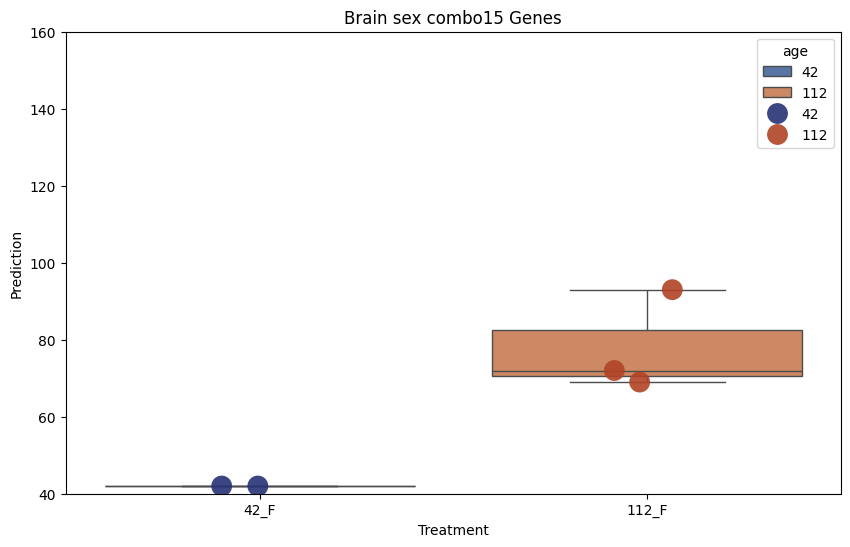

In [ ]:
ordered_x = [
'42_F',
 '112_F'
]


# Create the box plot
plt.figure(figsize=(10, 6))
box = sns.boxplot(x='age_sex', y='prediction', hue='age', data=df_intervention_test_pred, palette='deep', showfliers = False,
    order = ordered_x)

# Add data points

custom_palette = ['#273276', '#B14325']  # Use desired hex color codes

# Add data points with custom colors
strip = sns.stripplot(
    x='age_sex',
    y='prediction',
    hue='age',
    data=df_intervention_test_pred,
    palette=custom_palette,  # Custom color palette
    dodge=False,
    alpha=0.9,
    jitter=True,
    size=15,
    order = ordered_x
)

# Remove the legend if not needed
#strip.legend_.remove()

# Customize the plot
plt.title("".join(['Brain sex combo', str(gene_number), ' Genes']))
plt.xlabel('Treatment')
plt.ylabel('Prediction')

# Set y-axis limits
plt.ylim(40, 160)

# Remove the grid
plt.grid(False)

#plt.savefig("".join(["./plots/liver_CR_top_",str(gene_number),"_genes.svg"]), dpi=300, bbox_inches="tight")

# Show the plot
plt.show()

##### Try several gene set sizes

In [ ]:
# Set up ordered x-axis for plots
ordered_x = [
'42_F',
'112_F'
]

# Custom color palette
custom_palette = ['#273276', '#B14325']

# Directory setup
os.makedirs("./predictions", exist_ok=True)
os.makedirs("./plots", exist_ok=True)

# Dictionary to store prediction DataFrames if needed later
all_predictions = {}

# Loop through gene numbers
for gene_number in range(5, 101, 5):
    print(f"Running prediction for top {gene_number} genes...")

    df_intervention_test_pred = pd.DataFrame(index=df_intervention_test.index, columns=["prediction"])

    for sample in df_intervention_test.index.tolist():
        reference_df = pd.read_csv(f"./brain/female/reference/killifish_brain_reference_female", sep="\t", index_col=0)
        top_genes = reference_df["spearman_rank"].abs().nlargest(gene_number).index.tolist()

        total_reads_sample = df_intervention_test_counts.loc[sample].sum()
        list_of_profile_probabilities_per_age = []

        for age in new_age_steps:
            log_probs = []
            for gene in top_genes:
                gene_frequency = reference_df.loc[gene, str(age)]
                gene_frequency = max(gene_frequency, 1e-10)  # Ensure >0

                expected = gene_frequency * total_reads_sample
                observed = df_intervention_test_counts.loc[sample, gene]

                poisson_prob = poisson.pmf(k=observed, mu=expected)
                poisson_prob = max(poisson_prob, 0.001)

                log_probs.append(np.log(poisson_prob))

            list_of_profile_probabilities_per_age.append(np.sum(log_probs))

        age_probability_df = pd.DataFrame({"Pr": list_of_profile_probabilities_per_age}, index=new_age_steps)
        max_probability_age = round(float(age_probability_df.idxmax().iloc[0]), 2)
        df_intervention_test_pred.loc[sample, "prediction"] = max_probability_age

    # Add metadata
    df_intervention_test_pred["age"] = df_intervention_test["age"].tolist()
    df_intervention_test_pred["sex"] = df_intervention_test["sex"].tolist()


    df_intervention_test_pred["age_sex"] = (
        df_intervention_test_pred["age"].astype(str) + "_" +
        df_intervention_test_pred["sex"].astype(str)
    )

    # Save predictions
    all_predictions[gene_number] = df_intervention_test_pred.copy()
    df_intervention_test_pred.to_csv(f"./predictions/{select_tissue}_age_femaleOnly_preds_top_{gene_number}_genes.tsv", sep="\t")

    # --- Plot ---
    plt.figure(figsize=(10, 6))

    box = sns.boxplot(
        x='age_sex',
        y='prediction',
        hue='age',
        data=df_intervention_test_pred,
        palette='deep',
        showfliers=False,
        order=ordered_x
    )

    strip = sns.stripplot(
        x='age_sex',
        y='prediction',
        hue='age',
        data=df_intervention_test_pred,
        palette=custom_palette,
        dodge=False,
        alpha=0.9,
        jitter=True,
        size=15,
        order=ordered_x
    )

    # Remove duplicate legend
    strip.legend_.remove()

    plt.title(f"{select_tissue } female {gene_number} Genes")
    plt.xlabel('Treatment')
    plt.ylabel('Prediction')
    plt.xticks(rotation=45, ha='right')
    plt.ylim(40, 160)
    plt.grid(False)

    # Save plot
    plt.savefig(f"./plots/xu_{select_tissue}_female_top_{gene_number}_genes.svg", dpi=300, bbox_inches="tight")
    plt.close()

    print(f"Saved plot and prediction for {gene_number} genes.\n")


Running prediction for top 5 genes...
Saved plot and prediction for 5 genes.

Running prediction for top 10 genes...
Saved plot and prediction for 10 genes.

Running prediction for top 15 genes...
Saved plot and prediction for 15 genes.

Running prediction for top 20 genes...
Saved plot and prediction for 20 genes.

Running prediction for top 25 genes...
Saved plot and prediction for 25 genes.

Running prediction for top 30 genes...
Saved plot and prediction for 30 genes.

Running prediction for top 35 genes...
Saved plot and prediction for 35 genes.

Running prediction for top 40 genes...
Saved plot and prediction for 40 genes.

Running prediction for top 45 genes...
Saved plot and prediction for 45 genes.

Running prediction for top 50 genes...
Saved plot and prediction for 50 genes.

Running prediction for top 55 genes...
Saved plot and prediction for 55 genes.

Running prediction for top 60 genes...
Saved plot and prediction for 60 genes.

Running prediction for top 65 genes...
Sav

##### plot stability of preds

/tmp/ipython-input-169-1805454751.py:64: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
/tmp/ipython-input-169-1805454751.py:64: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
/tmp/ipython-input-169-1805454751.py:64: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
/tmp/ipython-input-169-1805454751.py:64: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


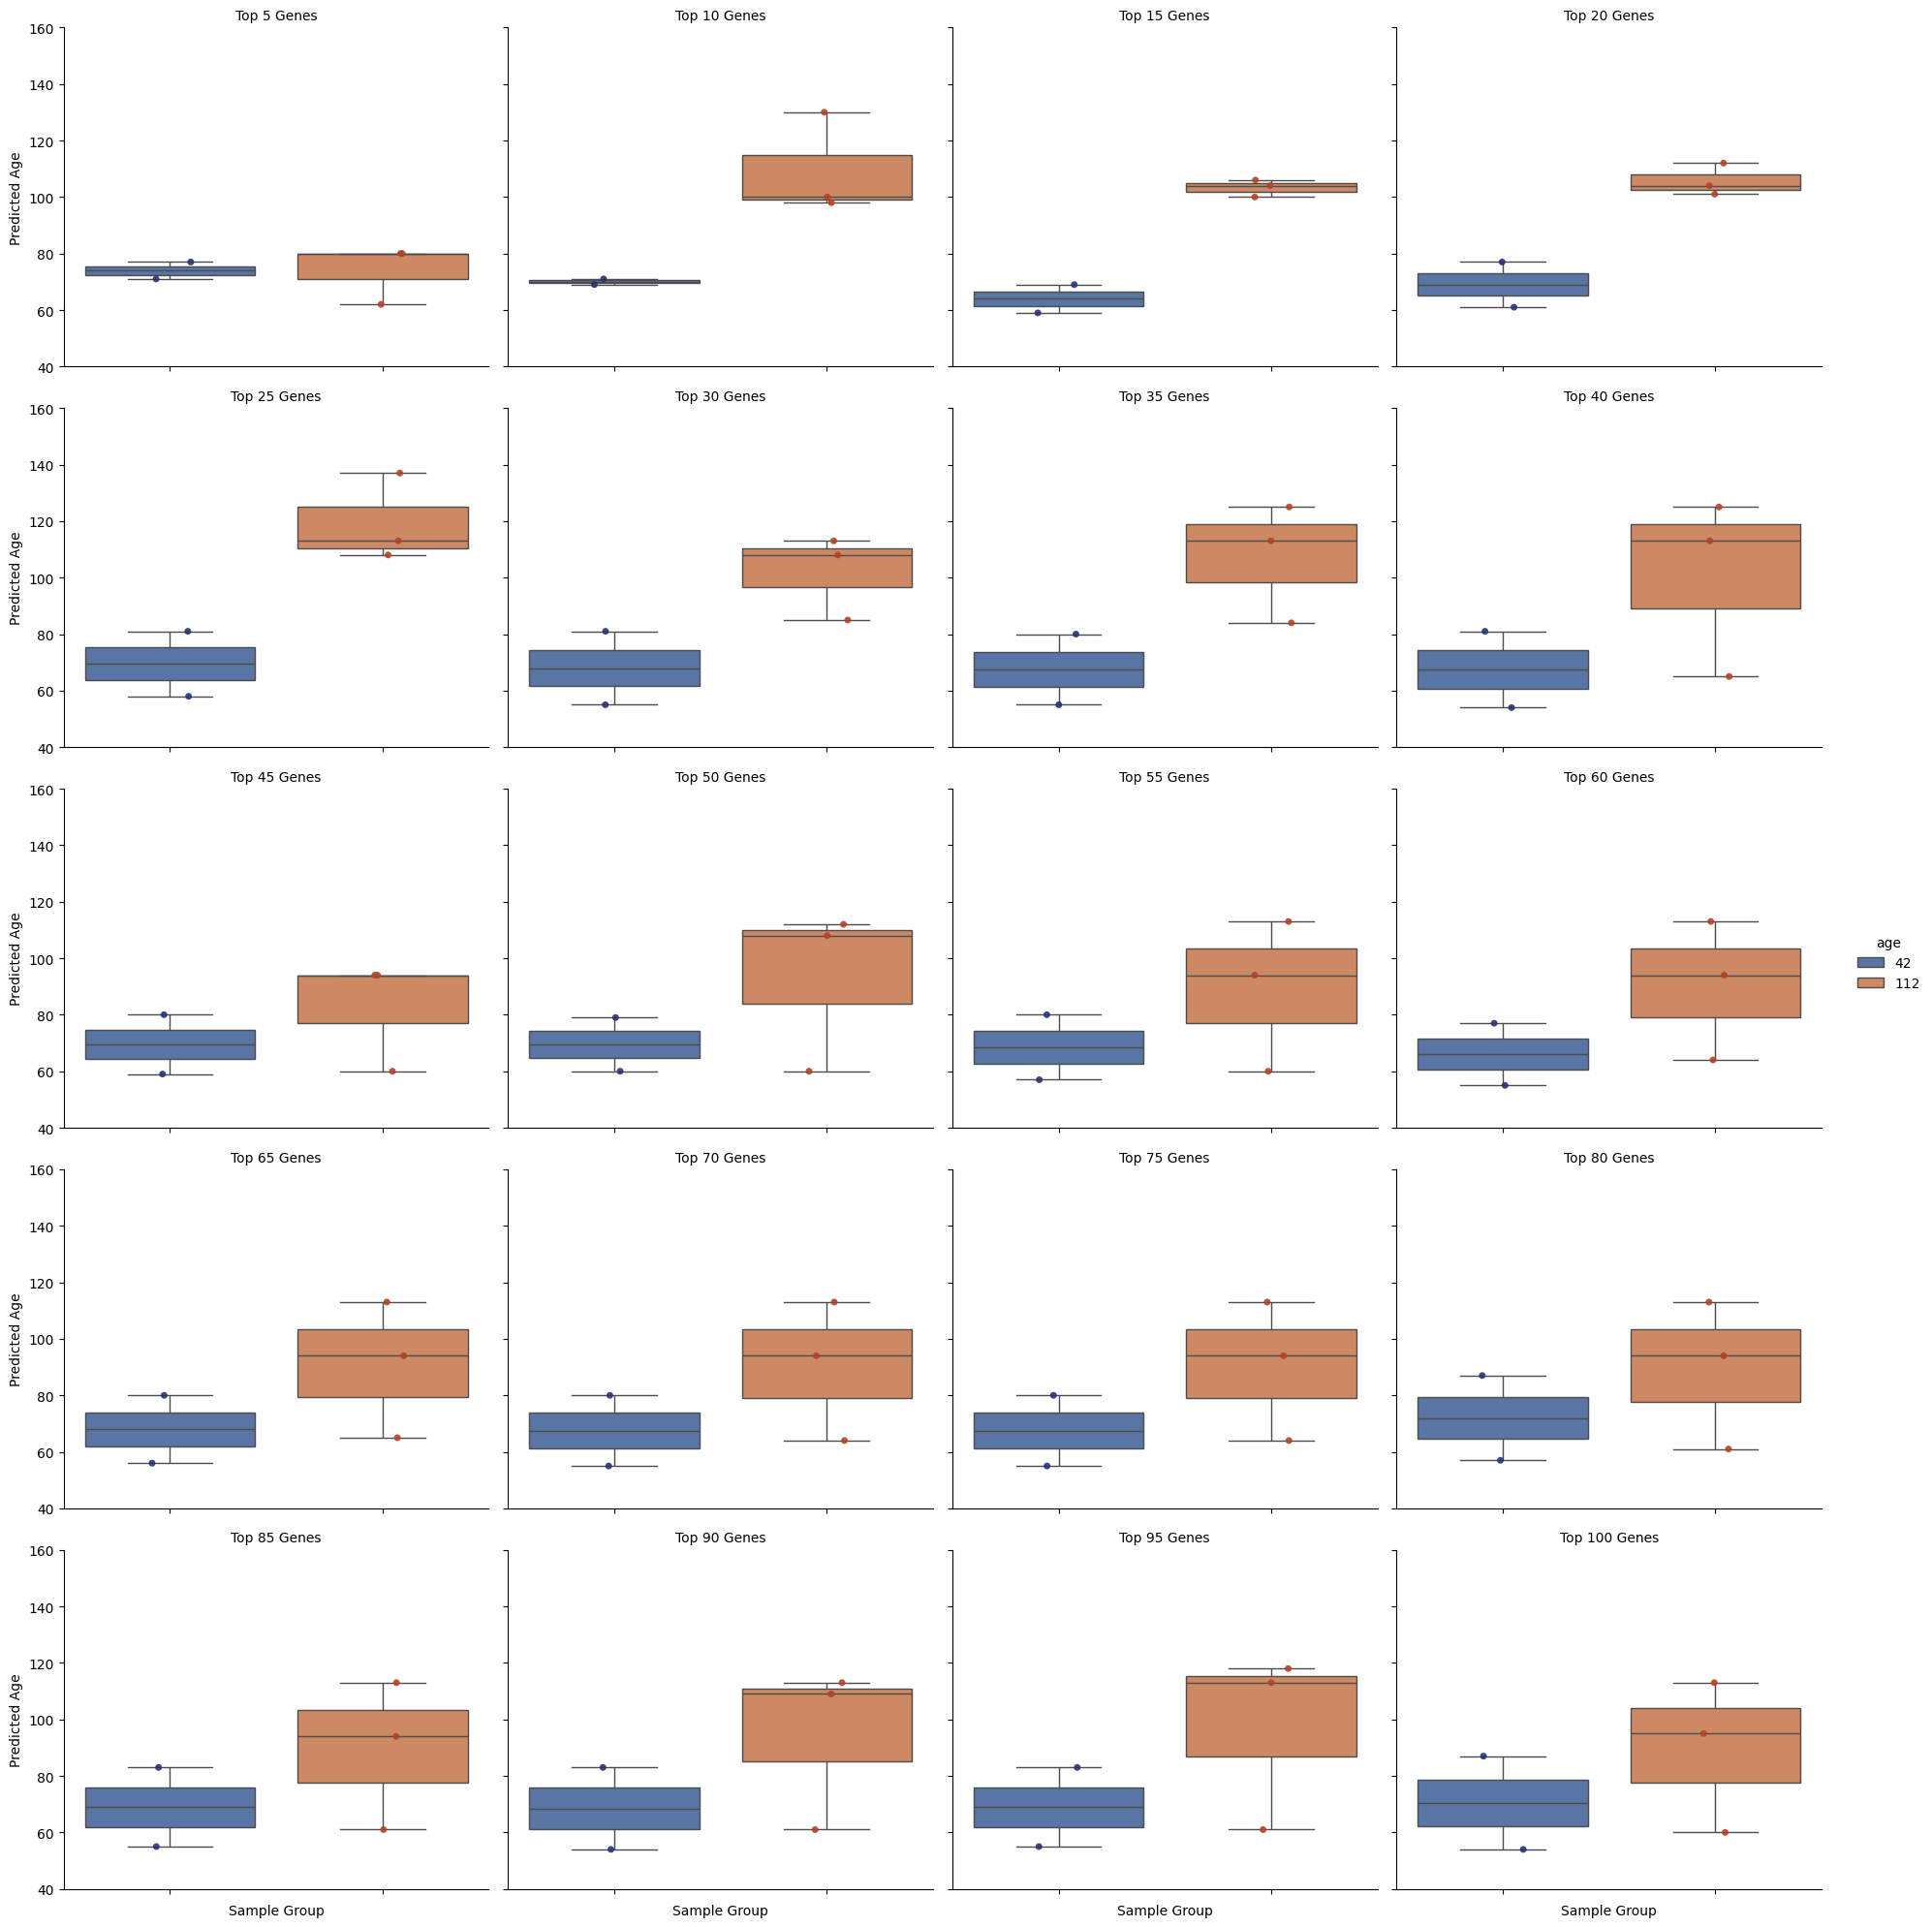

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import os

# Ordered x-axis
ordered_x = [
    '42_F',
'112_F'
]

# Custom palette
custom_palette = ['#273276', '#B14325']

# Load all prediction files
all_predictions_list = []

for gene_number in range(5, 101, 5):
    file_path = f"./predictions/{select_tissue}_age_femaleOnly_preds_top_{gene_number}_genes.tsv"
    if os.path.exists(file_path):
        df = pd.read_csv(file_path, sep="\t", index_col=0)
        df["gene_number"] = str(gene_number)  # for cleaner facet titles
        all_predictions_list.append(df)
    else:
        print(f"Warning: {file_path} not found. Skipping.")

# Concatenate into a single DataFrame
all_predictions_df = pd.concat(all_predictions_list, axis=0)

# Plot with seaborn FacetGrid (catplot)
g = sns.catplot(
    data=all_predictions_df,
    x="age_sex",
    y="prediction",
    hue="age",
    col="gene_number",
    col_wrap=4,
    kind="box",
    palette='deep',
    order=ordered_x,
    height=4,
    aspect=1.2,
    showfliers=False
)

# Overlay stripplot for better visualization
for ax, gene_number in zip(g.axes.flat, all_predictions_df["gene_number"].unique()):
    subset = all_predictions_df[all_predictions_df["gene_number"] == gene_number]
    sns.stripplot(
        x='age_sex',
        y='prediction',
        hue='age',
        data=subset,
        palette=custom_palette,
        dodge=False,
        alpha=0.9,
        jitter=True,
        size=5,
        order=ordered_x,
        ax=ax,
        legend=False
    )
    ax.set_title(f"Top {gene_number} Genes")
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
    ax.set_ylim(40, 160)

g.set_axis_labels("Sample Group", "Predicted Age")
g.set_titles("Top {col_name} Genes")
g.tight_layout()
plt.savefig(f"./plots/{select_tissue}_femaleOnly_faceted_predictions_by_gene_number.svg", dpi=300, bbox_inches="tight")
plt.show()


#Spleen

In [ ]:
select_tissue = 'Spleen'

### Sex combo

In [ ]:
df_intervention_combo = df_intervention.loc[
    (df_intervention.iloc[:, -5] == select_tissue)
]

In [ ]:
# remove outliers
df_intervention_combo = df_intervention_combo.drop('spleen_6')
df_intervention_combo = df_intervention_combo.drop('spleen_2')
#df_intervention_metadata = df_intervention_metadata.drop('brain_6')
df_intervention_combo.head(3)

,nadsyn1,dnaja3,f2r,LOC107382877,fezf1,srbd1,LOC107373267,LOC107384240,serp1,scarb2,...,umodl1,cryz,LOC107397181,pelo,mrpl35,tissue,AGE,sex,training,age
spleen_19,506,666,754,50,0,283,0,0,904,1282,...,26,74,2797,208,56,Spleen,16w,F,No,112
spleen_18,282,300,703,18,0,172,0,0,324,694,...,0,0,1198,172,24,Spleen,16w,F,No,112
spleen_17,758,650,1018,48,0,278,0,0,715,1010,...,16,72,2381,440,66,Spleen,16w,F,No,112


In [ ]:
all_samples = df_intervention_combo.index
all_samples

random.seed(123)

# Separate the samples
young_samples = [s for s in all_samples if s in df_intervention_combo.index and df_intervention_combo.loc[s, 'age'] == 42]
old_samples = [s for s in all_samples if s in df_intervention_combo.index and df_intervention_combo.loc[s, 'age'] ==  112]

# Randomly sample 2 from each
random_young = random.sample(young_samples, 2)
random_old = random.sample(old_samples, 2)

# Combine the result
random_subset = random_young + random_old

#select your training samples
select_train_samples = random_subset

# Select rows in df_intervention_age_counts_female where index is in female_samples
df_intervention_train = df_intervention_combo.loc[
    df_intervention_combo.index.isin(select_train_samples)
]

df_intervention_train

,nadsyn1,dnaja3,f2r,LOC107382877,fezf1,srbd1,LOC107373267,LOC107384240,serp1,scarb2,...,umodl1,cryz,LOC107397181,pelo,mrpl35,tissue,AGE,sex,training,age
spleen_18,282,300,703,18,0,172,0,0,324,694,...,0,0,1198,172,24,Spleen,16w,F,No,112
spleen_13,330,264,741,32,0,290,0,0,521,1480,...,0,66,3929,133,20,Spleen,16w,M,No,112
spleen_9,492,289,212,12,0,238,0,0,486,700,...,0,44,3183,197,46,Spleen,6w,F,No,42
spleen_7,629,476,301,18,0,245,0,0,594,798,...,0,40,1253,350,16,Spleen,6w,F,No,42


In [ ]:
# get your testing samples
#all not in select_train_samples
test_samples = [s for s in all_samples if s not in select_train_samples]
test_samples

['spleen_19',
 'spleen_17',
 'spleen_16',
 'spleen_15',
 'spleen_14',
 'spleen_12',
 'spleen_11',
 'spleen_10',
 'spleen_8',
 'spleen_5',
 'spleen_4',
 'spleen_3',
 'spleen_1']

In [ ]:
# Select rows in df_intervention_age_counts_female where index is in female_samples
df_intervention_test = df_intervention_combo.loc[
    df_intervention_combo.index.isin(test_samples)
]

df_intervention_test.head(2)

,nadsyn1,dnaja3,f2r,LOC107382877,fezf1,srbd1,LOC107373267,LOC107384240,serp1,scarb2,...,umodl1,cryz,LOC107397181,pelo,mrpl35,tissue,AGE,sex,training,age
spleen_19,506,666,754,50,0,283,0,0,904,1282,...,26,74,2797,208,56,Spleen,16w,F,No,112
spleen_17,758,650,1018,48,0,278,0,0,715,1010,...,16,72,2381,440,66,Spleen,16w,F,No,112


##### transcriptome reference

In [ ]:
# Specify the path for the new directory for the tissue
directory_path = f"./{select_tissue}/"

# Create the directory
os.mkdir(directory_path)

In [ ]:
#select raw counts
tissue_df_counts = combined_df.loc[
    (combined_df.iloc[:, -2] == select_tissue)
]
tissue_df_counts.head(5)

,a1cf,aaas,aacs,aadat,aaed1,aagab,aak1,aamdc,aamp,aar2,...,zufsp,zw10,zwilch,zyg11b,zyx,zzef1,zzz3,sex,tissue,age
A17_2,705,860,359,508,1635,1087,1879,1122,1136,1021,...,242,2250,116,683,2290,152,580,F,Spleen,78
A18_2,184,815,128,647,588,997,3422,1386,815,1152,...,252,1499,24,914,6078,571,714,M,Spleen,152
A19_2,11,650,168,372,599,580,1650,804,360,533,...,203,1100,40,491,3200,231,549,F,Spleen,155
A20_2,291,840,136,402,654,906,1414,729,716,1088,...,150,1835,207,492,2984,196,437,M,Spleen,47
B17_2,165,1017,158,308,703,969,2398,918,875,1099,...,379,1461,114,744,14961,721,590,M,Spleen,102


In [ ]:
df_intervention_train = df_intervention_train[tissue_df_counts.columns]
df_intervention_train.head(2)

,a1cf,aaas,aacs,aadat,aaed1,aagab,aak1,aamdc,aamp,aar2,...,zufsp,zw10,zwilch,zyg11b,zyx,zzef1,zzz3,sex,tissue,age
spleen_18,18,241,156,0,18,468,238,120,96,182,...,32,226,0,768,1068,1476,992,F,Spleen,112
spleen_13,74,93,62,115,285,296,688,338,299,76,...,126,395,0,748,1075,1188,1304,M,Spleen,112


In [ ]:
atlas_plus_intervention = pd.concat([tissue_df_counts, df_intervention_train], axis=0)
atlas_plus_intervention.head(3)

,a1cf,aaas,aacs,aadat,aaed1,aagab,aak1,aamdc,aamp,aar2,...,zufsp,zw10,zwilch,zyg11b,zyx,zzef1,zzz3,sex,tissue,age
A17_2,705,860,359,508,1635,1087,1879,1122,1136,1021,...,242,2250,116,683,2290,152,580,F,Spleen,78
A18_2,184,815,128,647,588,997,3422,1386,815,1152,...,252,1499,24,914,6078,571,714,M,Spleen,152
A19_2,11,650,168,372,599,580,1650,804,360,533,...,203,1100,40,491,3200,231,549,F,Spleen,155


In [ ]:
# #check cols ordered the same
# df_intervention_test = df_intervention_test[tissue_df_counts.columns]
# df_intervention_test.head(2)

In [ ]:
tissue_age_days_value_counts = atlas_plus_intervention["age"].value_counts().index.tolist()

In [ ]:
age_steps = sorted(tissue_age_days_value_counts)

print(age_steps)

[42, 47, 49, 52, 75, 77, 78, 102, 103, 112, 133, 134, 147, 152, 155, 161, 162]


In [ ]:
atlas_plus_intervention_age = atlas_plus_intervention.drop(atlas_plus_intervention.columns[[-2,-3]], axis=1)
atlas_plus_intervention_age.head(2)

,a1cf,aaas,aacs,aadat,aaed1,aagab,aak1,aamdc,aamp,aar2,...,zswim7,zswim8,zufsp,zw10,zwilch,zyg11b,zyx,zzef1,zzz3,age
A17_2,705,860,359,508,1635,1087,1879,1122,1136,1021,...,193,1754,242,2250,116,683,2290,152,580,78
A18_2,184,815,128,647,588,997,3422,1386,815,1152,...,206,2023,252,1499,24,914,6078,571,714,152


In [ ]:
#sample generation
for sample in atlas_plus_intervention_age.index.tolist():

    new_df = atlas_plus_intervention_age.drop(sample)

    new_df.to_csv(f"./{select_tissue}/{select_tissue}_sample_{sample}.csv", sep="\t")

In [ ]:
new_age_steps = np.arange(min(age_steps), max(age_steps)+1, 1)

In [ ]:
# Specify the path for the new directory for the tissue
directory_path = f"./{select_tissue}/reference"

# Create the directory
os.mkdir(directory_path)

In [ ]:
transcriptome_reference(training_matrix= atlas_plus_intervention_age,
                            reference_name=f"killifish_{select_tissue}_reference_sexcombo",
                            output_path=f"./{select_tissue}/reference/",
                            age_prediction="list",
                            age_list=new_age_steps,
                            min_age=1,
                            max_age=24,
                            age_step=1,
                            tau=0.7)

/tmp/ipython-input-10-2002720175.py:41: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho, p = spearmanr(age_training, gene_frequency)



Reference model dataset written to './Spleen/reference/killifish_Spleen_reference_sexcombo'
Report file generated at './Spleen/reference/killifish_Spleen_reference_sexcombo.report.txt'
-----------------------------------------------------



Time to run construct reference: 110.089 seconds

The reference is constructed and saved!


,42,43,44,45,46,47,48,49,50,51,...,155,156,157,158,159,160,161,162,spearman_rank,p_value
Gene,,,,,,,,,,,,,,,,,,,,,
a1cf,0.000002,0.000002,0.000002,0.000002,0.000002,0.000002,0.000002,0.000002,0.000002,0.000002,...,9.691799e-07,9.630455e-07,9.569742e-07,9.509499e-07,9.449567e-07,9.389791e-07,9.330018e-07,9.270112e-07,-0.210069,0.110283
aaas,0.000028,0.000028,0.000028,0.000028,0.000028,0.000028,0.000028,0.000028,0.000028,0.000027,...,2.745571e-05,2.754750e-05,2.763965e-05,2.773217e-05,2.782505e-05,2.791828e-05,2.801184e-05,2.810575e-05,0.053415,0.687835
aacs,0.000009,0.000009,0.000009,0.000009,0.000008,0.000008,0.000008,0.000008,0.000008,0.000008,...,6.923500e-06,6.957335e-06,6.990971e-06,7.024414e-06,7.057668e-06,7.090736e-06,7.123623e-06,7.156330e-06,-0.200100,0.128630
aadat,0.000016,0.000016,0.000016,0.000016,0.000016,0.000016,0.000016,0.000016,0.000016,0.000016,...,1.629109e-05,1.628935e-05,1.628714e-05,1.628440e-05,1.628112e-05,1.627726e-05,1.627280e-05,1.626771e-05,0.030104,0.820937
aaed1,0.000031,0.000031,0.000031,0.000031,0.000031,0.000031,0.000031,0.000031,0.000030,0.000030,...,2.910238e-05,2.927691e-05,2.945102e-05,2.962473e-05,2.979807e-05,2.997108e-05,3.014377e-05,3.031618e-05,-0.084134,0.526379
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
zwilch,0.000007,0.000007,0.000007,0.000007,0.000006,0.000006,0.000006,0.000006,0.000006,0.000006,...,2.333341e-06,2.350767e-06,2.368316e-06,2.385980e-06,2.403752e-06,2.421625e-06,2.439593e-06,2.457652e-06,-0.468820,0.000180
zyg11b,0.000023,0.000023,0.000023,0.000023,0.000023,0.000023,0.000023,0.000023,0.000023,0.000023,...,2.468291e-05,2.474774e-05,2.481290e-05,2.487838e-05,2.494416e-05,2.501025e-05,2.507662e-05,2.514327e-05,0.064279,0.628617
zyx,0.000093,0.000094,0.000094,0.000095,0.000095,0.000096,0.000097,0.000097,0.000098,0.000099,...,1.407527e-04,1.410137e-04,1.412754e-04,1.415374e-04,1.417994e-04,1.420609e-04,1.423217e-04,1.425813e-04,0.427610,0.000730


In [ ]:
df_intervention_test.head(1)

,nadsyn1,dnaja3,f2r,LOC107382877,fezf1,srbd1,LOC107373267,LOC107384240,serp1,scarb2,...,umodl1,cryz,LOC107397181,pelo,mrpl35,tissue,AGE,sex,training,age
spleen_19,506,666,754,50,0,283,0,0,904,1282,...,26,74,2797,208,56,Spleen,16w,F,No,112


In [ ]:
df_intervention_test_counts = df_intervention_test.drop(df_intervention_test.columns[[-2, -3,-4, -5]], axis=1)
df_intervention_test_counts.head(3)

,nadsyn1,dnaja3,f2r,LOC107382877,fezf1,srbd1,LOC107373267,LOC107384240,serp1,scarb2,...,plekhg1,LOC107373049,LOC107375201,LOC107384697,umodl1,cryz,LOC107397181,pelo,mrpl35,age
spleen_19,506,666,754,50,0,283,0,0,904,1282,...,1502,0,444,0,26,74,2797,208,56,112
spleen_17,758,650,1018,48,0,278,0,0,715,1010,...,1239,0,341,0,16,72,2381,440,66,112
spleen_16,416,329,563,198,0,183,0,0,380,699,...,683,0,360,0,0,16,1140,170,40,112


In [ ]:
gene_number = 15
df_intervention_test_pred = pd.DataFrame(index=df_intervention_test.index, columns=["prediction"])

for sample in df_intervention_test.index.tolist():

    reference_df = pd.read_csv(f"./{select_tissue}/reference/killifish_{select_tissue}_reference_sexcombo", sep="\t", index_col=0)

    # Get top genes based on spearman correlation
    top_abs_spearman_corr = reference_df["spearman_rank"].abs().nlargest(gene_number)

    #print(top_abs_spearman_corr)

    top_genes = top_abs_spearman_corr.index.tolist()

    # Save the DataFrame to a CSV file
    # df_top_genes = pd.DataFrame(top_genes, columns=["genes"])
    # gene_num = "".join([str(gene_number), "genes"])
    # out_file_prefix = 'Antebi_male_pred'
    # out_file_name = "_".join([out_file_prefix, gene_num])
    # output_path = './fat/gene_sets'
    # df_top_genes.to_csv(os.path.join(output_path, out_file_name), sep="\t")
    # print(f"List has been written to {out_file_name}")

    total_reads_sample = df_intervention_test_counts.loc[sample].sum()

    list_of_profile_probabilities_per_age = []

    for age in new_age_steps:

        probability_list_one_age = []

        genes_not_defined = []

        for gene in top_genes:

            gene_frequency = reference_df.loc[gene, f"{age}"]

            if gene_frequency < 0:
                gene_frequency = 10**-10

            sample_expected_counts = gene_frequency * total_reads_sample
            sample_observed_counts = df_intervention_test_counts.loc[sample, gene]

            poisson_probability = poisson.pmf(k=sample_observed_counts, mu=sample_expected_counts)

            # Replace NaN poisson probability with a small positive value and log it
            if np.isnan(poisson_probability):
                poisson_probability = 0.001
                genes_not_defined.append(gene)

            # Replace zero poisson probability with 0.001
            if poisson_probability == 0:
                poisson_probability = 0.001

            logP = np.log(poisson_probability)

            probability_list_one_age.append(logP)

        list_of_profile_probabilities_per_age.append(np.sum(probability_list_one_age))

    # Transform into dataframe with age steps
    age_probability_df = pd.DataFrame({"Pr": list_of_profile_probabilities_per_age}, index=new_age_steps)

    # Compute highest likelihood age among age steps
    max_probability_age = round(float(age_probability_df.idxmax().iloc[0]), 2)

    # Compute highest maximum probability
    max_probability = float(age_probability_df["Pr"].max())

    df_intervention_test_pred.loc[sample, "prediction"] = max_probability_age



print(df_intervention_test_pred)

          prediction
spleen_19       84.0
spleen_17       87.0
spleen_16       85.0
spleen_15       65.0
spleen_14       89.0
spleen_12       91.0
spleen_11       94.0
spleen_10       67.0
spleen_8        68.0
spleen_5        78.0
spleen_4        45.0
spleen_3        42.0
spleen_1        63.0


In [ ]:
df_intervention_test_pred["age"] = df_intervention_test["age"].tolist()
df_intervention_test_pred["sex"] = df_intervention_test["sex"].tolist()


df_intervention_test_pred["age_sex"] = (
    df_intervention_test_pred["age"].astype(str) + "_" +
    df_intervention_test_pred["sex"].astype(str)
)

df_intervention_test_pred

,prediction,age,sex,age_sex
spleen_19,84.0,112,F,112_F
spleen_17,87.0,112,F,112_F
spleen_16,85.0,112,F,112_F
spleen_15,65.0,112,F,112_F
spleen_14,89.0,112,M,112_M
spleen_12,91.0,112,M,112_M
spleen_11,94.0,112,M,112_M
spleen_10,67.0,112,M,112_M
spleen_8,68.0,42,F,42_F
spleen_5,78.0,42,M,42_M


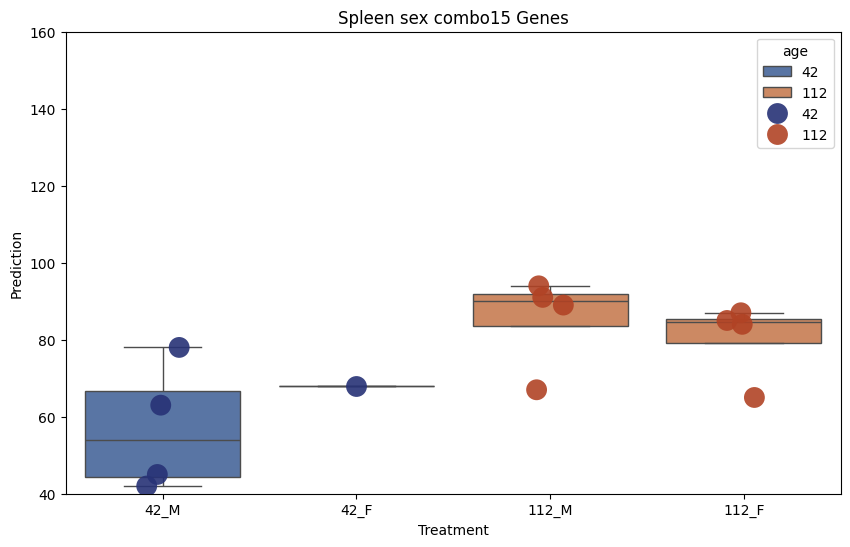

In [ ]:
ordered_x = [
    '42_M', '42_F',
    '112_M', '112_F'
]


# Create the box plot
plt.figure(figsize=(10, 6))
box = sns.boxplot(x='age_sex', y='prediction', hue='age', data=df_intervention_test_pred, palette='deep', showfliers = False,
    order = ordered_x)

# Add data points

custom_palette = ['#273276', '#B14325']  # Use desired hex color codes

# Add data points with custom colors
strip = sns.stripplot(
    x='age_sex',
    y='prediction',
    hue='age',
    data=df_intervention_test_pred,
    palette=custom_palette,  # Custom color palette
    dodge=False,
    alpha=0.9,
    jitter=True,
    size=15,
    order = ordered_x
)

# Remove the legend if not needed
#strip.legend_.remove()

# Customize the plot
plt.title("".join([f'{select_tissue} sex combo', str(gene_number), ' Genes']))
plt.xlabel('Treatment')
plt.ylabel('Prediction')

# Set y-axis limits
plt.ylim(40, 160)

# Remove the grid
plt.grid(False)

# Show the plot
plt.show()

##### Try several gene set sizes

In [ ]:
# Set up ordered x-axis for plots
ordered_x = [
    '42_M', '42_F',
    '112_M', '112_F'
]

# Custom color palette
custom_palette = ['#273276', '#B14325']

# Directory setup
os.makedirs("./predictions", exist_ok=True)
os.makedirs("./plots", exist_ok=True)

# Dictionary to store prediction DataFrames if needed later
all_predictions = {}

# Loop through gene numbers
for gene_number in range(5, 101, 5):
    print(f"Running prediction for top {gene_number} genes...")

    df_intervention_test_pred = pd.DataFrame(index=df_intervention_test.index, columns=["prediction"])

    for sample in df_intervention_test.index.tolist():
        reference_df = pd.read_csv(f"./{select_tissue}/reference/killifish_{select_tissue}_reference_sexcombo", sep="\t", index_col=0)
        top_genes = reference_df["spearman_rank"].abs().nlargest(gene_number).index.tolist()

        total_reads_sample = df_intervention_test_counts.loc[sample].sum()
        list_of_profile_probabilities_per_age = []

        for age in new_age_steps:
            log_probs = []
            for gene in top_genes:
                gene_frequency = reference_df.loc[gene, str(age)]
                gene_frequency = max(gene_frequency, 1e-10)  # Ensure >0

                expected = gene_frequency * total_reads_sample
                observed = df_intervention_test_counts.loc[sample, gene]

                poisson_prob = poisson.pmf(k=observed, mu=expected)
                poisson_prob = max(poisson_prob, 0.001)

                log_probs.append(np.log(poisson_prob))

            list_of_profile_probabilities_per_age.append(np.sum(log_probs))

        age_probability_df = pd.DataFrame({"Pr": list_of_profile_probabilities_per_age}, index=new_age_steps)
        max_probability_age = round(float(age_probability_df.idxmax().iloc[0]), 2)
        df_intervention_test_pred.loc[sample, "prediction"] = max_probability_age

    # Add metadata
    df_intervention_test_pred["age"] = df_intervention_test["age"].tolist()
    df_intervention_test_pred["sex"] = df_intervention_test["sex"].tolist()


    df_intervention_test_pred["age_sex"] = (
        df_intervention_test_pred["age"].astype(str) + "_" +
        df_intervention_test_pred["sex"].astype(str)
    )

    # Save predictions
    all_predictions[gene_number] = df_intervention_test_pred.copy()
    df_intervention_test_pred.to_csv(f"./predictions/{select_tissue}_sexcombo_age_preds_top_{gene_number}_genes.tsv", sep="\t")

    # --- Plot ---
    plt.figure(figsize=(10, 6))

    box = sns.boxplot(
        x='age_sex',
        y='prediction',
        hue='age',
        data=df_intervention_test_pred,
        palette='deep',
        showfliers=False,
        order=ordered_x
    )

    strip = sns.stripplot(
        x='age_sex',
        y='prediction',
        hue='age',
        data=df_intervention_test_pred,
        palette=custom_palette,
        dodge=False,
        alpha=0.9,
        jitter=True,
        size=15,
        order=ordered_x
    )

    # Remove duplicate legend
    strip.legend_.remove()

    plt.title(f"Brain sex combo {gene_number} Genes")
    plt.xlabel('Treatment')
    plt.ylabel('Prediction')
    plt.xticks(rotation=45, ha='right')
    plt.ylim(40, 160)
    plt.grid(False)

    # Save plot
    plt.savefig(f"./plots/xu_{select_tissue}_sexcombo_top_{gene_number}_genes.svg", dpi=300, bbox_inches="tight")
    plt.close()

    print(f"Saved plot and prediction for {gene_number} genes.\n")


Running prediction for top 5 genes...
Saved plot and prediction for 5 genes.

Running prediction for top 10 genes...
Saved plot and prediction for 10 genes.

Running prediction for top 15 genes...
Saved plot and prediction for 15 genes.

Running prediction for top 20 genes...
Saved plot and prediction for 20 genes.

Running prediction for top 25 genes...
Saved plot and prediction for 25 genes.

Running prediction for top 30 genes...
Saved plot and prediction for 30 genes.

Running prediction for top 35 genes...
Saved plot and prediction for 35 genes.

Running prediction for top 40 genes...
Saved plot and prediction for 40 genes.

Running prediction for top 45 genes...
Saved plot and prediction for 45 genes.

Running prediction for top 50 genes...
Saved plot and prediction for 50 genes.

Running prediction for top 55 genes...
Saved plot and prediction for 55 genes.

Running prediction for top 60 genes...
Saved plot and prediction for 60 genes.

Running prediction for top 65 genes...
Sav

##### plot stability of preds

/tmp/ipython-input-194-3290434677.py:64: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
/tmp/ipython-input-194-3290434677.py:64: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
/tmp/ipython-input-194-3290434677.py:64: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
/tmp/ipython-input-194-3290434677.py:64: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


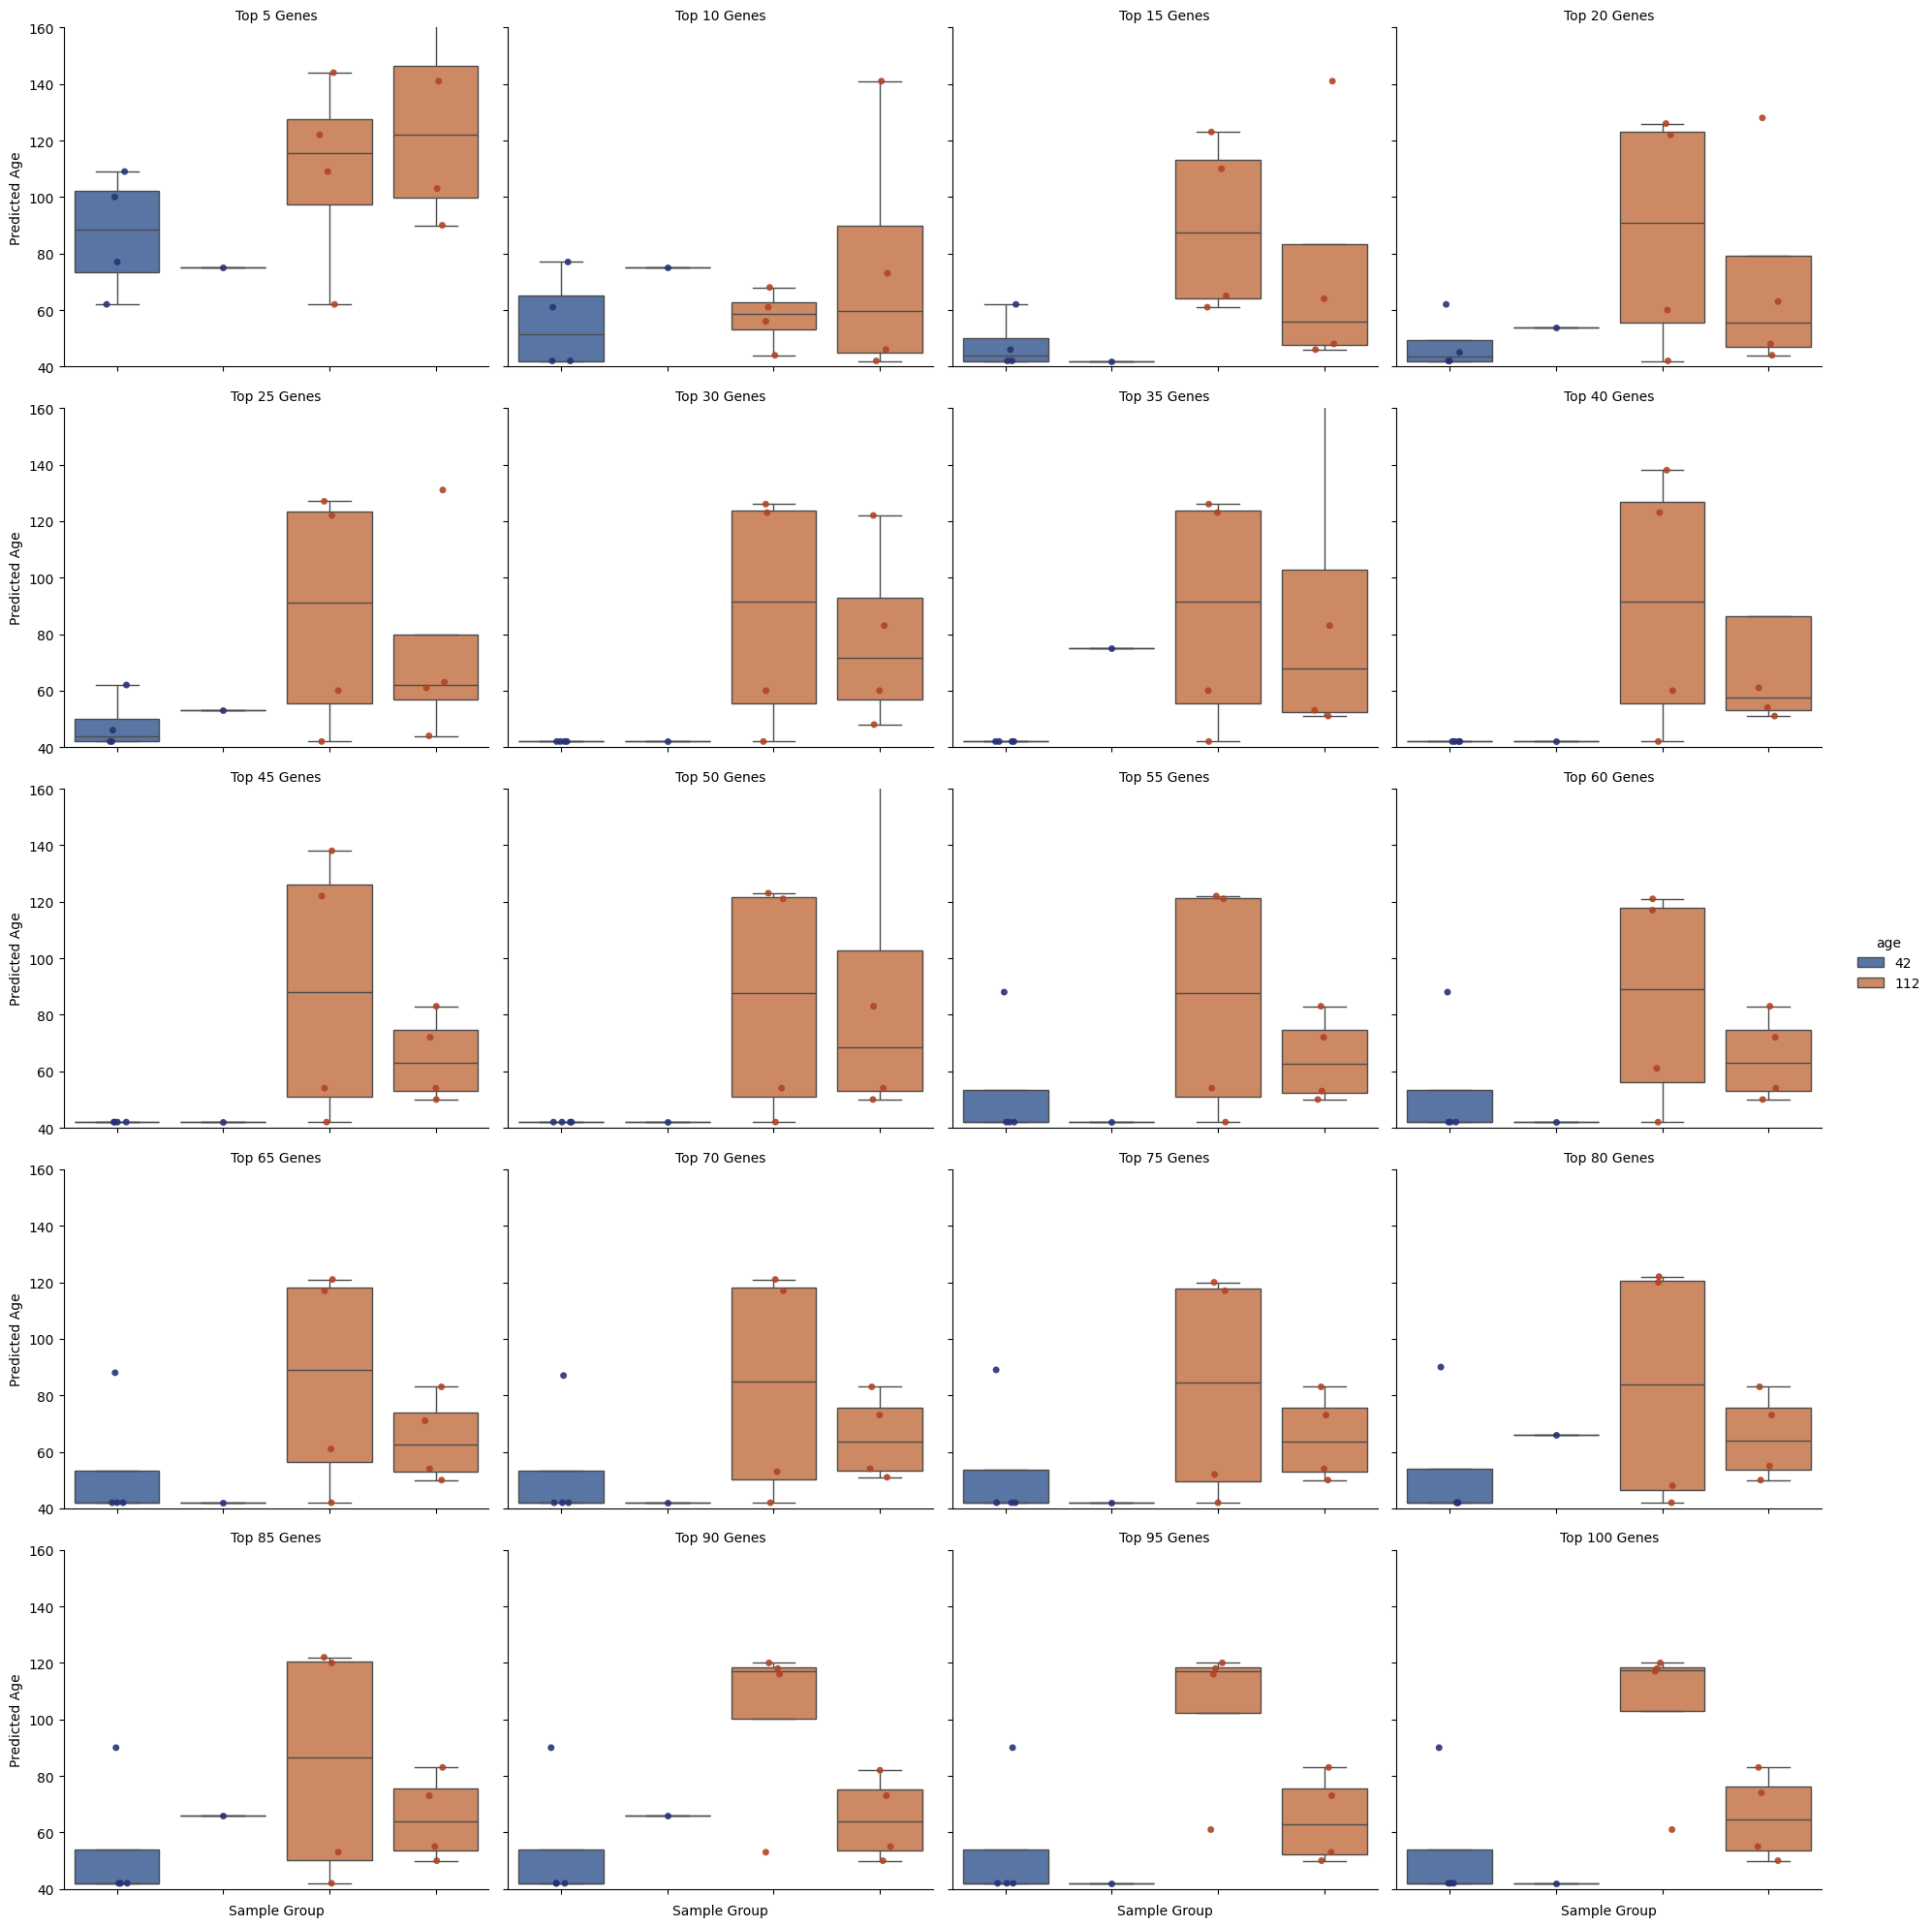

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import os

# Ordered x-axis
ordered_x = [
    '42_M', '42_F',
    '112_M', '112_F'
]

# Custom palette
custom_palette = ['#273276', '#B14325']

# Load all prediction files
all_predictions_list = []

for gene_number in range(5, 101, 5):
    file_path = f"./predictions/{select_tissue}_sexcombo_age_preds_top_{gene_number}_genes.tsv"
    if os.path.exists(file_path):
        df = pd.read_csv(file_path, sep="\t", index_col=0)
        df["gene_number"] = str(gene_number)  # for cleaner facet titles
        all_predictions_list.append(df)
    else:
        print(f"Warning: {file_path} not found. Skipping.")

# Concatenate into a single DataFrame
all_predictions_df = pd.concat(all_predictions_list, axis=0)

# Plot with seaborn FacetGrid (catplot)
g = sns.catplot(
    data=all_predictions_df,
    x="age_sex",
    y="prediction",
    hue="age",
    col="gene_number",
    col_wrap=4,
    kind="box",
    palette='deep',
    order=ordered_x,
    height=4,
    aspect=1.2,
    showfliers=False
)

# Overlay stripplot for better visualization
for ax, gene_number in zip(g.axes.flat, all_predictions_df["gene_number"].unique()):
    subset = all_predictions_df[all_predictions_df["gene_number"] == gene_number]
    sns.stripplot(
        x='age_sex',
        y='prediction',
        hue='age',
        data=subset,
        palette=custom_palette,
        dodge=False,
        alpha=0.9,
        jitter=True,
        size=5,
        order=ordered_x,
        ax=ax,
        legend=False
    )
    ax.set_title(f"Top {gene_number} Genes")
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
    ax.set_ylim(40, 160)

g.set_axis_labels("Sample Group", "Predicted Age")
g.set_titles("Top {col_name} Genes")
g.tight_layout()
plt.savefig(f"./plots/{select_tissue}_sex_combo_faceted_predictions_by_gene_number.svg", dpi=300, bbox_inches="tight")
plt.show()


### Male only

In [ ]:
df_intervention_combo.head(2)

,nadsyn1,dnaja3,f2r,LOC107382877,fezf1,srbd1,LOC107373267,LOC107384240,serp1,scarb2,...,umodl1,cryz,LOC107397181,pelo,mrpl35,tissue,AGE,sex,training,age
spleen_19,506,666,754,50,0,283,0,0,904,1282,...,26,74,2797,208,56,Spleen,16w,F,No,112
spleen_18,282,300,703,18,0,172,0,0,324,694,...,0,0,1198,172,24,Spleen,16w,F,No,112


In [ ]:
df_intervention_male = df_intervention_combo.loc[
    (df_intervention_combo.iloc[:, -3] == 'M')
]

In [ ]:
all_samples = df_intervention_male.index
all_samples

random.seed(123)

# Separate the samples
young_samples = [s for s in all_samples if s in df_intervention_male.index and df_intervention_male.loc[s, 'age'] == 42]
old_samples = [s for s in all_samples if s in df_intervention_male.index and df_intervention_male.loc[s, 'age'] ==  112]

# Randomly sample 2 from each
random_young = random.sample(young_samples, 2)
random_old = random.sample(old_samples, 2)

# Combine the result
random_subset = random_young + random_old

#select your training samples
select_train_samples = random_subset

# Select rows in df_intervention_age_counts_female where index is in female_samples
df_intervention_train = df_intervention_male.loc[
    df_intervention_male.index.isin(select_train_samples)
]

df_intervention_train

,nadsyn1,dnaja3,f2r,LOC107382877,fezf1,srbd1,LOC107373267,LOC107384240,serp1,scarb2,...,umodl1,cryz,LOC107397181,pelo,mrpl35,tissue,AGE,sex,training,age
spleen_14,415,372,682,40,26,380,0,0,457,1198,...,0,45,1618,188,28,Spleen,16w,M,No,112
spleen_11,434,572,528,73,0,460,0,0,604,1249,...,0,44,972,309,20,Spleen,16w,M,No,112
spleen_5,107,192,320,10,0,426,0,0,328,758,...,0,10,2194,244,28,Spleen,6w,M,No,42
spleen_4,301,218,226,108,0,199,0,0,698,657,...,0,72,1734,300,30,Spleen,6w,M,No,42


In [ ]:
# get your testing samples
#all not in select_train_samples
test_samples = [s for s in all_samples if s not in select_train_samples]
test_samples

['spleen_13', 'spleen_12', 'spleen_10', 'spleen_3', 'spleen_1']

In [ ]:
# Select rows in df_intervention_age_counts_female where index is in female_samples
df_intervention_test = df_intervention_male.loc[
    df_intervention_male.index.isin(test_samples)
]

df_intervention_test

,nadsyn1,dnaja3,f2r,LOC107382877,fezf1,srbd1,LOC107373267,LOC107384240,serp1,scarb2,...,umodl1,cryz,LOC107397181,pelo,mrpl35,tissue,AGE,sex,training,age
spleen_13,330,264,741,32,0,290,0,0,521,1480,...,0,66,3929,133,20,Spleen,16w,M,No,112
spleen_12,582,261,1083,105,0,342,28,0,661,1207,...,6,34,2137,340,73,Spleen,16w,M,No,112
spleen_10,578,394,822,32,0,534,0,0,397,1171,...,0,48,2001,230,19,Spleen,16w,M,No,112
spleen_3,232,274,282,260,0,210,0,0,422,612,...,0,44,2161,465,26,Spleen,6w,M,No,42
spleen_1,300,444,182,450,0,160,0,6,736,220,...,22,136,1261,668,24,Spleen,6w,M,No,42


##### transcriptome reference

In [ ]:
# Specify the path for the new directory for the tissue
directory_path = f"./{select_tissue}/male/"

# Create the directory
os.mkdir(directory_path)

In [ ]:
tissue_df_counts.head(1)

,a1cf,aaas,aacs,aadat,aaed1,aagab,aak1,aamdc,aamp,aar2,...,zufsp,zw10,zwilch,zyg11b,zyx,zzef1,zzz3,sex,tissue,age
A17_2,705,860,359,508,1635,1087,1879,1122,1136,1021,...,242,2250,116,683,2290,152,580,F,Spleen,78


In [ ]:
#select raw counts
tissue_df_counts = combined_df.loc[
    (combined_df.iloc[:, -2] == select_tissue) &
     (combined_df.iloc[:, -3] == 'M')
]
tissue_df_counts.head(5)

,a1cf,aaas,aacs,aadat,aaed1,aagab,aak1,aamdc,aamp,aar2,...,zufsp,zw10,zwilch,zyg11b,zyx,zzef1,zzz3,sex,tissue,age
A18_2,184,815,128,647,588,997,3422,1386,815,1152,...,252,1499,24,914,6078,571,714,M,Spleen,152
A20_2,291,840,136,402,654,906,1414,729,716,1088,...,150,1835,207,492,2984,196,437,M,Spleen,47
B17_2,165,1017,158,308,703,969,2398,918,875,1099,...,379,1461,114,744,14961,721,590,M,Spleen,102
B19_2,128,1193,405,820,1561,1436,2968,2085,1385,1738,...,347,2802,139,1193,6287,446,1153,M,Spleen,78
B20_2,0,801,242,494,1049,737,1888,1089,851,1101,...,262,1565,40,713,4343,367,654,M,Spleen,161


In [ ]:
df_intervention_train = df_intervention_train[tissue_df_counts.columns]
df_intervention_train.head(2)

,a1cf,aaas,aacs,aadat,aaed1,aagab,aak1,aamdc,aamp,aar2,...,zufsp,zw10,zwilch,zyg11b,zyx,zzef1,zzz3,sex,tissue,age
spleen_14,26,105,153,142,111,526,688,549,380,270,...,77,496,0,710,1203,2167,1399,M,Spleen,112
spleen_11,198,166,270,153,176,684,1010,354,341,54,...,66,806,0,802,1073,2929,1793,M,Spleen,112


In [ ]:
atlas_plus_intervention = pd.concat([tissue_df_counts, df_intervention_train], axis=0)
atlas_plus_intervention.head(3)

,a1cf,aaas,aacs,aadat,aaed1,aagab,aak1,aamdc,aamp,aar2,...,zufsp,zw10,zwilch,zyg11b,zyx,zzef1,zzz3,sex,tissue,age
A18_2,184,815,128,647,588,997,3422,1386,815,1152,...,252,1499,24,914,6078,571,714,M,Spleen,152
A20_2,291,840,136,402,654,906,1414,729,716,1088,...,150,1835,207,492,2984,196,437,M,Spleen,47
B17_2,165,1017,158,308,703,969,2398,918,875,1099,...,379,1461,114,744,14961,721,590,M,Spleen,102


In [ ]:
# #check cols ordered the same
# df_intervention_test = df_intervention_test[tissue_df_counts.columns]
# df_intervention_test.head(2)

In [ ]:
tissue_age_days_value_counts = atlas_plus_intervention["age"].value_counts().index.tolist()

In [ ]:
age_steps = sorted(tissue_age_days_value_counts)

print(age_steps)

[42, 47, 49, 52, 75, 77, 78, 102, 103, 112, 133, 134, 147, 152, 161, 162]


In [ ]:
atlas_plus_intervention_age = atlas_plus_intervention.drop(atlas_plus_intervention.columns[[-2, -3]], axis=1)
atlas_plus_intervention_age.head(2)

,a1cf,aaas,aacs,aadat,aaed1,aagab,aak1,aamdc,aamp,aar2,...,zswim7,zswim8,zufsp,zw10,zwilch,zyg11b,zyx,zzef1,zzz3,age
A18_2,184,815,128,647,588,997,3422,1386,815,1152,...,206,2023,252,1499,24,914,6078,571,714,152
A20_2,291,840,136,402,654,906,1414,729,716,1088,...,109,1490,150,1835,207,492,2984,196,437,47


In [ ]:
#sample generation
for sample in atlas_plus_intervention_age.index.tolist():

    new_df = atlas_plus_intervention_age.drop(sample)

    new_df.to_csv(f"./{select_tissue}/male/{select_tissue}_male_sample_{sample}.csv", sep="\t")

In [ ]:
new_age_steps = np.arange(min(age_steps), max(age_steps)+1, 1)

In [ ]:
# Specify the path for the new directory for the tissue
directory_path = f"./{select_tissue}/male/reference"

# Create the directory
os.mkdir(directory_path)

In [ ]:
transcriptome_reference(training_matrix= atlas_plus_intervention_age,
                            reference_name=f"killifish_{select_tissue}_reference_male",
                            output_path=f"./{select_tissue}/male/reference/",
                            age_prediction="list",
                            age_list=new_age_steps,
                            min_age=1,
                            max_age=24,
                            age_step=1,
                            tau=0.7)

/tmp/ipython-input-10-2002720175.py:41: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho, p = spearmanr(age_training, gene_frequency)



Reference model dataset written to './Spleen/male/reference/killifish_Spleen_reference_male'
Report file generated at './Spleen/male/reference/killifish_Spleen_reference_male.report.txt'
-----------------------------------------------------



Time to run construct reference: 105.677 seconds

The reference is constructed and saved!


,42,43,44,45,46,47,48,49,50,51,...,155,156,157,158,159,160,161,162,spearman_rank,p_value
Gene,,,,,,,,,,,,,,,,,,,,,
a1cf,0.000004,0.000004,0.000004,0.000004,0.000004,0.000004,0.000004,0.000004,0.000004,0.000004,...,0.000001,0.000001,0.000001,0.000001,0.000001,0.000001,0.000001,0.000001,-0.314738,0.061538
aaas,0.000026,0.000026,0.000026,0.000026,0.000026,0.000026,0.000026,0.000026,0.000026,0.000026,...,0.000026,0.000027,0.000027,0.000027,0.000027,0.000027,0.000027,0.000027,0.124597,0.469048
aacs,0.000007,0.000007,0.000007,0.000007,0.000007,0.000007,0.000007,0.000007,0.000007,0.000007,...,0.000007,0.000007,0.000007,0.000007,0.000007,0.000007,0.000007,0.000007,-0.102928,0.550264
aadat,0.000012,0.000013,0.000013,0.000013,0.000013,0.000013,0.000013,0.000013,0.000013,0.000013,...,0.000015,0.000015,0.000015,0.000015,0.000015,0.000015,0.000015,0.000015,0.210500,0.217841
aaed1,0.000026,0.000026,0.000026,0.000025,0.000025,0.000025,0.000025,0.000025,0.000025,0.000025,...,0.000029,0.000029,0.000029,0.000030,0.000030,0.000030,0.000031,0.000031,0.174642,0.308331
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
zwilch,0.000006,0.000006,0.000006,0.000006,0.000006,0.000006,0.000006,0.000006,0.000006,0.000006,...,0.000002,0.000002,0.000002,0.000002,0.000002,0.000002,0.000002,0.000002,-0.331313,0.048397
zyg11b,0.000020,0.000020,0.000020,0.000020,0.000020,0.000020,0.000020,0.000020,0.000020,0.000020,...,0.000025,0.000025,0.000025,0.000025,0.000025,0.000025,0.000025,0.000025,0.154005,0.369832
zyx,0.000099,0.000100,0.000101,0.000102,0.000102,0.000103,0.000104,0.000104,0.000105,0.000106,...,0.000141,0.000141,0.000141,0.000141,0.000141,0.000141,0.000141,0.000141,0.315234,0.061108


In [ ]:
df_intervention_test.head(1)

,nadsyn1,dnaja3,f2r,LOC107382877,fezf1,srbd1,LOC107373267,LOC107384240,serp1,scarb2,...,umodl1,cryz,LOC107397181,pelo,mrpl35,tissue,AGE,sex,training,age
spleen_13,330,264,741,32,0,290,0,0,521,1480,...,0,66,3929,133,20,Spleen,16w,M,No,112


In [ ]:
df_intervention_test_counts = df_intervention_test.drop(df_intervention_test.columns[[-2, -3,-4, -5]], axis=1)
df_intervention_test_counts.head(3)

,nadsyn1,dnaja3,f2r,LOC107382877,fezf1,srbd1,LOC107373267,LOC107384240,serp1,scarb2,...,plekhg1,LOC107373049,LOC107375201,LOC107384697,umodl1,cryz,LOC107397181,pelo,mrpl35,age
spleen_13,330,264,741,32,0,290,0,0,521,1480,...,725,0,327,0,0,66,3929,133,20,112
spleen_12,582,261,1083,105,0,342,28,0,661,1207,...,844,0,540,0,6,34,2137,340,73,112
spleen_10,578,394,822,32,0,534,0,0,397,1171,...,908,0,651,4,0,48,2001,230,19,112


In [ ]:
gene_number = 15
df_intervention_test_pred = pd.DataFrame(index=df_intervention_test.index, columns=["prediction"])

for sample in df_intervention_test.index.tolist():

    reference_df = pd.read_csv(f"./{select_tissue}/male/reference/killifish_{select_tissue}_reference_male", sep="\t", index_col=0)

    # Get top genes based on spearman correlation
    top_abs_spearman_corr = reference_df["spearman_rank"].abs().nlargest(gene_number)

    #print(top_abs_spearman_corr)

    top_genes = top_abs_spearman_corr.index.tolist()

    # Save the DataFrame to a CSV file
    # df_top_genes = pd.DataFrame(top_genes, columns=["genes"])
    # gene_num = "".join([str(gene_number), "genes"])
    # out_file_prefix = 'Antebi_male_pred'
    # out_file_name = "_".join([out_file_prefix, gene_num])
    # output_path = './fat/gene_sets'
    # df_top_genes.to_csv(os.path.join(output_path, out_file_name), sep="\t")
    # print(f"List has been written to {out_file_name}")

    total_reads_sample = df_intervention_test_counts.loc[sample].sum()

    list_of_profile_probabilities_per_age = []

    for age in new_age_steps:

        probability_list_one_age = []

        genes_not_defined = []

        for gene in top_genes:

            gene_frequency = reference_df.loc[gene, f"{age}"]

            if gene_frequency < 0:
                gene_frequency = 10**-10

            sample_expected_counts = gene_frequency * total_reads_sample
            sample_observed_counts = df_intervention_test_counts.loc[sample, gene]

            poisson_probability = poisson.pmf(k=sample_observed_counts, mu=sample_expected_counts)

            # Replace NaN poisson probability with a small positive value and log it
            if np.isnan(poisson_probability):
                poisson_probability = 0.001
                genes_not_defined.append(gene)

            # Replace zero poisson probability with 0.001
            if poisson_probability == 0:
                poisson_probability = 0.001

            logP = np.log(poisson_probability)

            probability_list_one_age.append(logP)

        list_of_profile_probabilities_per_age.append(np.sum(probability_list_one_age))

    # Transform into dataframe with age steps
    age_probability_df = pd.DataFrame({"Pr": list_of_profile_probabilities_per_age}, index=new_age_steps)

    # Compute highest likelihood age among age steps
    max_probability_age = round(float(age_probability_df.idxmax().iloc[0]), 2)

    # Compute highest maximum probability
    max_probability = float(age_probability_df["Pr"].max())

    df_intervention_test_pred.loc[sample, "prediction"] = max_probability_age



print(df_intervention_test_pred)

          prediction
spleen_13      131.0
spleen_12      124.0
spleen_10      124.0
spleen_3        59.0
spleen_1        91.0


In [ ]:
df_intervention_test_pred["age"] = df_intervention_test["age"].tolist()
df_intervention_test_pred["sex"] = df_intervention_test["sex"].tolist()


df_intervention_test_pred["age_sex"] = (
    df_intervention_test_pred["age"].astype(str) + "_" +
    df_intervention_test_pred["sex"].astype(str)
)

df_intervention_test_pred

,prediction,age,sex,age_sex
spleen_13,131.0,112,M,112_M
spleen_12,124.0,112,M,112_M
spleen_10,124.0,112,M,112_M
spleen_3,59.0,42,M,42_M
spleen_1,91.0,42,M,42_M


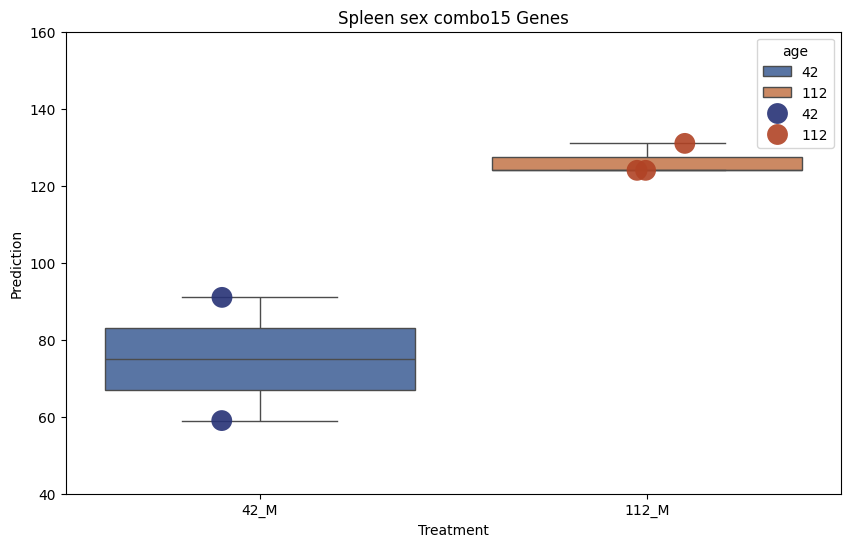

In [ ]:
ordered_x = [
    '42_M','112_M'
]


# Create the box plot
plt.figure(figsize=(10, 6))
box = sns.boxplot(x='age_sex', y='prediction', hue='age', data=df_intervention_test_pred, palette='deep', showfliers = False,
    order = ordered_x)

# Add data points

custom_palette = ['#273276', '#B14325']  # Use desired hex color codes

# Add data points with custom colors
strip = sns.stripplot(
    x='age_sex',
    y='prediction',
    hue='age',
    data=df_intervention_test_pred,
    palette=custom_palette,  # Custom color palette
    dodge=False,
    alpha=0.9,
    jitter=True,
    size=15,
    order = ordered_x
)

# Remove the legend if not needed
#strip.legend_.remove()

# Customize the plot
plt.title("".join([f'{select_tissue} sex combo', str(gene_number), ' Genes']))
plt.xlabel('Treatment')
plt.ylabel('Prediction')

# Set y-axis limits
plt.ylim(40, 160)

# Remove the grid
plt.grid(False)

# Show the plot
plt.show()

##### Try several gene set sizes

In [ ]:
# Set up ordered x-axis for plots
ordered_x = [
    '42_M',
    '112_M'
]

# Custom color palette
custom_palette = ['#273276', '#B14325']

# Directory setup
os.makedirs("./predictions", exist_ok=True)
os.makedirs("./plots", exist_ok=True)

# Dictionary to store prediction DataFrames if needed later
all_predictions = {}

# Loop through gene numbers
for gene_number in range(5, 101, 5):
    print(f"Running prediction for top {gene_number} genes...")

    df_intervention_test_pred = pd.DataFrame(index=df_intervention_test.index, columns=["prediction"])

    for sample in df_intervention_test.index.tolist():
        reference_df = pd.read_csv(f"./{select_tissue}/male/reference/killifish_{select_tissue}_reference_male", sep="\t", index_col=0)
        top_genes = reference_df["spearman_rank"].abs().nlargest(gene_number).index.tolist()

        total_reads_sample = df_intervention_test_counts.loc[sample].sum()
        list_of_profile_probabilities_per_age = []

        for age in new_age_steps:
            log_probs = []
            for gene in top_genes:
                gene_frequency = reference_df.loc[gene, str(age)]
                gene_frequency = max(gene_frequency, 1e-10)  # Ensure >0

                expected = gene_frequency * total_reads_sample
                observed = df_intervention_test_counts.loc[sample, gene]

                poisson_prob = poisson.pmf(k=observed, mu=expected)
                poisson_prob = max(poisson_prob, 0.001)

                log_probs.append(np.log(poisson_prob))

            list_of_profile_probabilities_per_age.append(np.sum(log_probs))

        age_probability_df = pd.DataFrame({"Pr": list_of_profile_probabilities_per_age}, index=new_age_steps)
        max_probability_age = round(float(age_probability_df.idxmax().iloc[0]), 2)
        df_intervention_test_pred.loc[sample, "prediction"] = max_probability_age

    # Add metadata
    df_intervention_test_pred["age"] = df_intervention_test["age"].tolist()
    df_intervention_test_pred["sex"] = df_intervention_test["sex"].tolist()


    df_intervention_test_pred["age_sex"] = (
        df_intervention_test_pred["age"].astype(str) + "_" +
        df_intervention_test_pred["sex"].astype(str)
    )

    # Save predictions
    all_predictions[gene_number] = df_intervention_test_pred.copy()
    df_intervention_test_pred.to_csv(f"./predictions/{select_tissue}_age_maleOnly_preds_top_{gene_number}_genes.tsv", sep="\t")

    # --- Plot ---
    plt.figure(figsize=(10, 6))

    box = sns.boxplot(
        x='age_sex',
        y='prediction',
        hue='age',
        data=df_intervention_test_pred,
        palette='deep',
        showfliers=False,
        order=ordered_x
    )

    strip = sns.stripplot(
        x='age_sex',
        y='prediction',
        hue='age',
        data=df_intervention_test_pred,
        palette=custom_palette,
        dodge=False,
        alpha=0.9,
        jitter=True,
        size=15,
        order=ordered_x
    )

    # Remove duplicate legend
    strip.legend_.remove()

    plt.title(f"{select_tissue}sex combo {gene_number} Genes")
    plt.xlabel('Treatment')
    plt.ylabel('Prediction')
    plt.xticks(rotation=45, ha='right')
    plt.ylim(40, 160)
    plt.grid(False)

    # Save plot
    plt.savefig(f"./plots/xu_{select_tissue}_maleOnly_top_{gene_number}_genes.svg", dpi=300, bbox_inches="tight")
    plt.close()

    print(f"Saved plot and prediction for {gene_number} genes.\n")


Running prediction for top 5 genes...
Saved plot and prediction for 5 genes.

Running prediction for top 10 genes...
Saved plot and prediction for 10 genes.

Running prediction for top 15 genes...
Saved plot and prediction for 15 genes.

Running prediction for top 20 genes...
Saved plot and prediction for 20 genes.

Running prediction for top 25 genes...
Saved plot and prediction for 25 genes.

Running prediction for top 30 genes...
Saved plot and prediction for 30 genes.

Running prediction for top 35 genes...
Saved plot and prediction for 35 genes.

Running prediction for top 40 genes...
Saved plot and prediction for 40 genes.

Running prediction for top 45 genes...
Saved plot and prediction for 45 genes.

Running prediction for top 50 genes...
Saved plot and prediction for 50 genes.

Running prediction for top 55 genes...
Saved plot and prediction for 55 genes.

Running prediction for top 60 genes...
Saved plot and prediction for 60 genes.

Running prediction for top 65 genes...
Sav

##### plot stability of preds

/tmp/ipython-input-223-523614965.py:64: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
/tmp/ipython-input-223-523614965.py:64: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
/tmp/ipython-input-223-523614965.py:64: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
/tmp/ipython-input-223-523614965.py:64: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


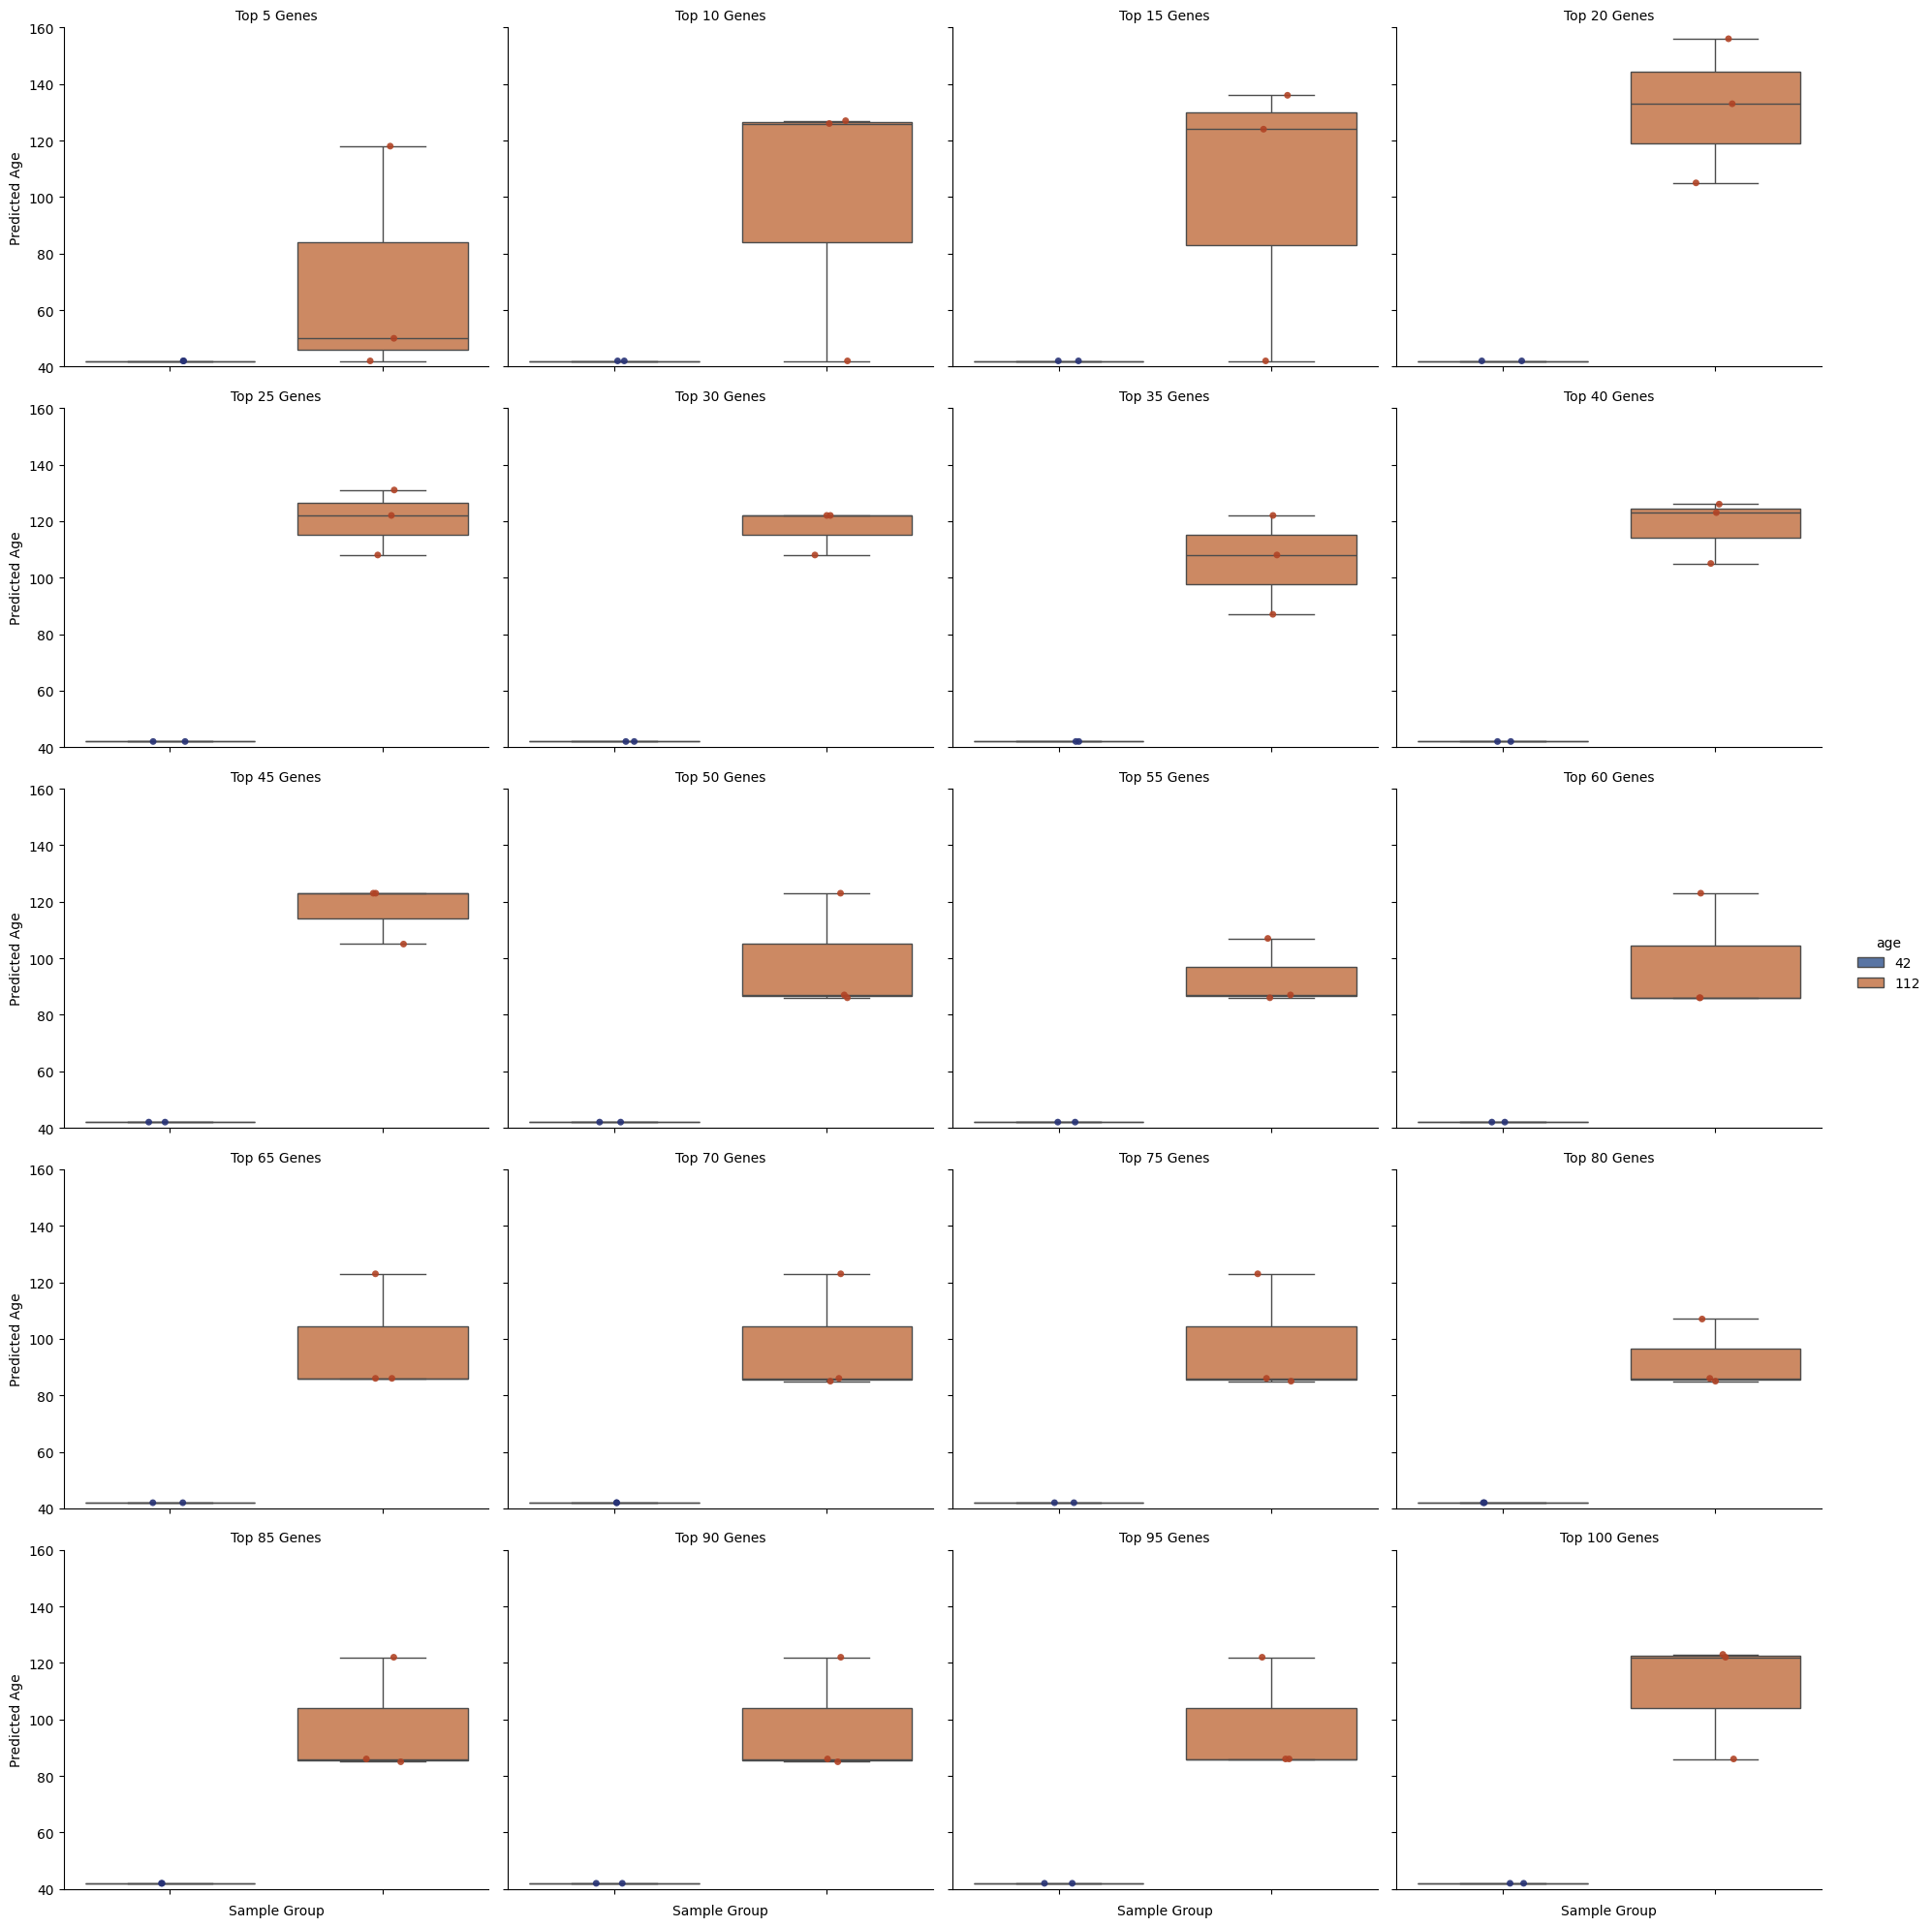

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import os

# Ordered x-axis
ordered_x = [
    '42_M',
    '112_M'
]

# Custom palette
custom_palette = ['#273276', '#B14325']

# Load all prediction files
all_predictions_list = []

for gene_number in range(5, 101, 5):
    file_path = f"./predictions/{select_tissue}_age_maleOnly_preds_top_{gene_number}_genes.tsv"
    if os.path.exists(file_path):
        df = pd.read_csv(file_path, sep="\t", index_col=0)
        df["gene_number"] = str(gene_number)  # for cleaner facet titles
        all_predictions_list.append(df)
    else:
        print(f"Warning: {file_path} not found. Skipping.")

# Concatenate into a single DataFrame
all_predictions_df = pd.concat(all_predictions_list, axis=0)

# Plot with seaborn FacetGrid (catplot)
g = sns.catplot(
    data=all_predictions_df,
    x="age_sex",
    y="prediction",
    hue="age",
    col="gene_number",
    col_wrap=4,
    kind="box",
    palette='deep',
    order=ordered_x,
    height=4,
    aspect=1.2,
    showfliers=False
)

# Overlay stripplot for better visualization
for ax, gene_number in zip(g.axes.flat, all_predictions_df["gene_number"].unique()):
    subset = all_predictions_df[all_predictions_df["gene_number"] == gene_number]
    sns.stripplot(
        x='age_sex',
        y='prediction',
        hue='age',
        data=subset,
        palette=custom_palette,
        dodge=False,
        alpha=0.9,
        jitter=True,
        size=5,
        order=ordered_x,
        ax=ax,
        legend=False
    )
    ax.set_title(f"Top {gene_number} Genes")
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
    ax.set_ylim(40, 160)

g.set_axis_labels("Sample Group", "Predicted Age")
g.set_titles("Top {col_name} Genes")
g.tight_layout()
plt.savefig(f"./plots/{select_tissue}_maleOnly_faceted_predictions_by_gene_number.svg", dpi=300, bbox_inches="tight")
plt.show()


### Female only

In [ ]:
df_intervention_combo.head(2)

,nadsyn1,dnaja3,f2r,LOC107382877,fezf1,srbd1,LOC107373267,LOC107384240,serp1,scarb2,...,umodl1,cryz,LOC107397181,pelo,mrpl35,tissue,AGE,sex,training,age
spleen_19,506,666,754,50,0,283,0,0,904,1282,...,26,74,2797,208,56,Spleen,16w,F,No,112
spleen_18,282,300,703,18,0,172,0,0,324,694,...,0,0,1198,172,24,Spleen,16w,F,No,112


In [ ]:
df_intervention_female = df_intervention_combo.loc[
    (df_intervention_combo.iloc[:, -3] == 'F')
]

In [ ]:
all_samples = df_intervention_female.index
all_samples

random.seed(123)

# Separate the samples
young_samples = [s for s in all_samples if s in df_intervention_female.index and df_intervention_female.loc[s, 'age'] == 42]
old_samples = [s for s in all_samples if s in df_intervention_female.index and df_intervention_female.loc[s, 'age'] ==  112]

# Randomly sample 2 from each
random_young = random.sample(young_samples, 2)
random_old = random.sample(old_samples, 2)

# Combine the result
random_subset = random_young + random_old

#select your training samples
select_train_samples = random_subset

# Select rows in df_intervention_age_counts_female where index is in female_samples
df_intervention_train = df_intervention_female.loc[
    df_intervention_female.index.isin(select_train_samples)
]

df_intervention_train

,nadsyn1,dnaja3,f2r,LOC107382877,fezf1,srbd1,LOC107373267,LOC107384240,serp1,scarb2,...,umodl1,cryz,LOC107397181,pelo,mrpl35,tissue,AGE,sex,training,age
spleen_19,506,666,754,50,0,283,0,0,904,1282,...,26,74,2797,208,56,Spleen,16w,F,No,112
spleen_16,416,329,563,198,0,183,0,0,380,699,...,0,16,1140,170,40,Spleen,16w,F,No,112
spleen_9,492,289,212,12,0,238,0,0,486,700,...,0,44,3183,197,46,Spleen,6w,F,No,42
spleen_8,437,264,283,158,0,157,0,0,972,842,...,14,60,1102,428,47,Spleen,6w,F,No,42


In [ ]:
# get your testing samples
#all not in select_train_samples
test_samples = [s for s in all_samples if s not in select_train_samples]
test_samples

['spleen_18', 'spleen_17', 'spleen_15', 'spleen_7']

In [ ]:
# Select rows in df_intervention_age_counts_female where index is in female_samples
df_intervention_test = df_intervention_female.loc[
    df_intervention_female.index.isin(test_samples)
]

df_intervention_test

,nadsyn1,dnaja3,f2r,LOC107382877,fezf1,srbd1,LOC107373267,LOC107384240,serp1,scarb2,...,umodl1,cryz,LOC107397181,pelo,mrpl35,tissue,AGE,sex,training,age
spleen_18,282,300,703,18,0,172,0,0,324,694,...,0,0,1198,172,24,Spleen,16w,F,No,112
spleen_17,758,650,1018,48,0,278,0,0,715,1010,...,16,72,2381,440,66,Spleen,16w,F,No,112
spleen_15,236,457,635,112,2,202,16,0,393,596,...,0,28,1490,86,62,Spleen,16w,F,No,112
spleen_7,629,476,301,18,0,245,0,0,594,798,...,0,40,1253,350,16,Spleen,6w,F,No,42


##### transcriptome reference

In [ ]:
# Specify the path for the new directory for the tissue
directory_path = f"./{select_tissue}/female/"

# Create the directory
os.mkdir(directory_path)

In [ ]:
tissue_df_counts.head(1)

,a1cf,aaas,aacs,aadat,aaed1,aagab,aak1,aamdc,aamp,aar2,...,zufsp,zw10,zwilch,zyg11b,zyx,zzef1,zzz3,sex,tissue,age
A18_2,184,815,128,647,588,997,3422,1386,815,1152,...,252,1499,24,914,6078,571,714,M,Spleen,152


In [ ]:
#select raw counts
tissue_df_counts = combined_df.loc[
    (combined_df.iloc[:, -2] == select_tissue) &
     (combined_df.iloc[:, -3] == 'F')
]
tissue_df_counts.head(5)

,a1cf,aaas,aacs,aadat,aaed1,aagab,aak1,aamdc,aamp,aar2,...,zufsp,zw10,zwilch,zyg11b,zyx,zzef1,zzz3,sex,tissue,age
A17_2,705,860,359,508,1635,1087,1879,1122,1136,1021,...,242,2250,116,683,2290,152,580,F,Spleen,78
A19_2,11,650,168,372,599,580,1650,804,360,533,...,203,1100,40,491,3200,231,549,F,Spleen,155
B18_2,46,1273,385,583,1574,1138,2220,1101,1204,1495,...,291,2257,116,1087,4863,367,902,F,Spleen,75
C18_2,6,814,259,585,1395,896,2150,1615,692,1033,...,299,1622,51,1271,3441,298,975,F,Spleen,75
C19_2,37,1789,298,1108,1035,1450,3102,1112,1532,1983,...,369,2552,219,1201,7552,779,970,F,Spleen,155


In [ ]:
df_intervention_train = df_intervention_train[tissue_df_counts.columns]
df_intervention_train.head(2)

,a1cf,aaas,aacs,aadat,aaed1,aagab,aak1,aamdc,aamp,aar2,...,zufsp,zw10,zwilch,zyg11b,zyx,zzef1,zzz3,sex,tissue,age
spleen_19,12,296,311,315,152,460,884,543,306,368,...,157,604,0,898,1443,2007,2441,F,Spleen,112
spleen_16,0,118,147,78,92,241,491,253,166,120,...,36,386,0,573,975,1981,1708,F,Spleen,112


In [ ]:
atlas_plus_intervention = pd.concat([tissue_df_counts, df_intervention_train], axis=0)
atlas_plus_intervention.head(3)

,a1cf,aaas,aacs,aadat,aaed1,aagab,aak1,aamdc,aamp,aar2,...,zufsp,zw10,zwilch,zyg11b,zyx,zzef1,zzz3,sex,tissue,age
A17_2,705,860,359,508,1635,1087,1879,1122,1136,1021,...,242,2250,116,683,2290,152,580,F,Spleen,78
A19_2,11,650,168,372,599,580,1650,804,360,533,...,203,1100,40,491,3200,231,549,F,Spleen,155
B18_2,46,1273,385,583,1574,1138,2220,1101,1204,1495,...,291,2257,116,1087,4863,367,902,F,Spleen,75


In [ ]:
# #check cols ordered the same
# df_intervention_test = df_intervention_test[tissue_df_counts.columns]
# df_intervention_test.head(2)

In [ ]:
tissue_age_days_value_counts = atlas_plus_intervention["age"].value_counts().index.tolist()

In [ ]:
age_steps = sorted(tissue_age_days_value_counts)

print(age_steps)

[42, 47, 49, 52, 75, 77, 78, 102, 103, 112, 133, 134, 147, 155]


In [ ]:
atlas_plus_intervention_age = atlas_plus_intervention.drop(atlas_plus_intervention.columns[[-2, -3]], axis=1)
atlas_plus_intervention_age.head(2)

,a1cf,aaas,aacs,aadat,aaed1,aagab,aak1,aamdc,aamp,aar2,...,zswim7,zswim8,zufsp,zw10,zwilch,zyg11b,zyx,zzef1,zzz3,age
A17_2,705,860,359,508,1635,1087,1879,1122,1136,1021,...,193,1754,242,2250,116,683,2290,152,580,78
A19_2,11,650,168,372,599,580,1650,804,360,533,...,87,1231,203,1100,40,491,3200,231,549,155


In [ ]:
#sample generation
for sample in atlas_plus_intervention_age.index.tolist():

    new_df = atlas_plus_intervention_age.drop(sample)

    new_df.to_csv(f"./{select_tissue}/female/{select_tissue}_female_sample_{sample}.csv", sep="\t")

In [ ]:
new_age_steps = np.arange(min(age_steps), max(age_steps)+1, 1)

In [ ]:
# Specify the path for the new directory for the tissue
directory_path = f"./{select_tissue}/female/reference"

# Create the directory
os.mkdir(directory_path)

In [ ]:
transcriptome_reference(training_matrix= atlas_plus_intervention_age,
                            reference_name=f"killifish_{select_tissue}_reference_female",
                            output_path=f"./{select_tissue}/female/reference/",
                            age_prediction="list",
                            age_list=new_age_steps,
                            min_age=1,
                            max_age=24,
                            age_step=1,
                            tau=0.7)

/tmp/ipython-input-10-2002720175.py:41: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho, p = spearmanr(age_training, gene_frequency)



Reference model dataset written to './Spleen/female/reference/killifish_Spleen_reference_female'
Report file generated at './Spleen/female/reference/killifish_Spleen_reference_female.report.txt'
-----------------------------------------------------



Time to run construct reference: 99.799 seconds

The reference is constructed and saved!


,42,43,44,45,46,47,48,49,50,51,...,148,149,150,151,152,153,154,155,spearman_rank,p_value
Gene,,,,,,,,,,,,,,,,,,,,,
a1cf,0.000004,0.000004,0.000003,0.000003,0.000003,0.000003,0.000003,0.000003,0.000003,0.000003,...,9.173509e-07,9.266210e-07,9.357285e-07,9.446650e-07,9.534227e-07,9.619941e-07,9.703722e-07,9.785505e-07,-0.276495,0.162678
aaas,0.000025,0.000025,0.000025,0.000025,0.000026,0.000026,0.000026,0.000026,0.000026,0.000026,...,3.164088e-05,3.195982e-05,3.228084e-05,3.260391e-05,3.292901e-05,3.325610e-05,3.358516e-05,3.391615e-05,0.148341,0.460253
aacs,0.000010,0.000010,0.000010,0.000010,0.000010,0.000010,0.000010,0.000010,0.000010,0.000010,...,6.543107e-06,6.551532e-06,6.559917e-06,6.568304e-06,6.576731e-06,6.585237e-06,6.593858e-06,6.602629e-06,-0.449305,0.018717
aadat,0.000017,0.000017,0.000017,0.000017,0.000017,0.000017,0.000017,0.000017,0.000017,0.000017,...,2.004633e-05,2.013593e-05,2.022570e-05,2.031565e-05,2.040579e-05,2.049614e-05,2.058670e-05,2.067749e-05,0.325739,0.097303
aaed1,0.000033,0.000034,0.000034,0.000034,0.000034,0.000034,0.000035,0.000035,0.000035,0.000035,...,2.886920e-05,2.905828e-05,2.924574e-05,2.943146e-05,2.961527e-05,2.979707e-05,2.997671e-05,3.015410e-05,-0.295764,0.134170
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
zwilch,0.000006,0.000005,0.000005,0.000005,0.000005,0.000005,0.000005,0.000005,0.000005,0.000005,...,2.716593e-06,2.776494e-06,2.837070e-06,2.898303e-06,2.960175e-06,3.022669e-06,3.085766e-06,3.149448e-06,-0.336801,0.085823
zyg11b,0.000026,0.000026,0.000026,0.000026,0.000026,0.000026,0.000026,0.000025,0.000025,0.000025,...,2.394327e-05,2.398581e-05,2.402885e-05,2.407241e-05,2.411651e-05,2.416119e-05,2.420647e-05,2.425237e-05,-0.200031,0.317133
zyx,0.000082,0.000083,0.000083,0.000084,0.000085,0.000085,0.000086,0.000087,0.000088,0.000088,...,1.378137e-04,1.389256e-04,1.400515e-04,1.411916e-04,1.423461e-04,1.435151e-04,1.446986e-04,1.458968e-04,0.471939,0.012942


In [ ]:
df_intervention_test.head(1)

,nadsyn1,dnaja3,f2r,LOC107382877,fezf1,srbd1,LOC107373267,LOC107384240,serp1,scarb2,...,umodl1,cryz,LOC107397181,pelo,mrpl35,tissue,AGE,sex,training,age
spleen_18,282,300,703,18,0,172,0,0,324,694,...,0,0,1198,172,24,Spleen,16w,F,No,112


In [ ]:
df_intervention_test_counts = df_intervention_test.drop(df_intervention_test.columns[[-2, -3,-4, -5]], axis=1)
df_intervention_test_counts.head(3)

,nadsyn1,dnaja3,f2r,LOC107382877,fezf1,srbd1,LOC107373267,LOC107384240,serp1,scarb2,...,plekhg1,LOC107373049,LOC107375201,LOC107384697,umodl1,cryz,LOC107397181,pelo,mrpl35,age
spleen_18,282,300,703,18,0,172,0,0,324,694,...,370,0,159,0,0,0,1198,172,24,112
spleen_17,758,650,1018,48,0,278,0,0,715,1010,...,1239,0,341,0,16,72,2381,440,66,112
spleen_15,236,457,635,112,2,202,16,0,393,596,...,539,0,345,0,0,28,1490,86,62,112


In [ ]:
gene_number = 15
df_intervention_test_pred = pd.DataFrame(index=df_intervention_test.index, columns=["prediction"])

for sample in df_intervention_test.index.tolist():

    reference_df = pd.read_csv(f"./{select_tissue}/female/reference/killifish_{select_tissue}_reference_female", sep="\t", index_col=0)

    # Get top genes based on spearman correlation
    top_abs_spearman_corr = reference_df["spearman_rank"].abs().nlargest(gene_number)

    #print(top_abs_spearman_corr)

    top_genes = top_abs_spearman_corr.index.tolist()

    # Save the DataFrame to a CSV file
    # df_top_genes = pd.DataFrame(top_genes, columns=["genes"])
    # gene_num = "".join([str(gene_number), "genes"])
    # out_file_prefix = 'Antebi_male_pred'
    # out_file_name = "_".join([out_file_prefix, gene_num])
    # output_path = './fat/gene_sets'
    # df_top_genes.to_csv(os.path.join(output_path, out_file_name), sep="\t")
    # print(f"List has been written to {out_file_name}")

    total_reads_sample = df_intervention_test_counts.loc[sample].sum()

    list_of_profile_probabilities_per_age = []

    for age in new_age_steps:

        probability_list_one_age = []

        genes_not_defined = []

        for gene in top_genes:

            gene_frequency = reference_df.loc[gene, f"{age}"]

            if gene_frequency < 0:
                gene_frequency = 10**-10

            sample_expected_counts = gene_frequency * total_reads_sample
            sample_observed_counts = df_intervention_test_counts.loc[sample, gene]

            poisson_probability = poisson.pmf(k=sample_observed_counts, mu=sample_expected_counts)

            # Replace NaN poisson probability with a small positive value and log it
            if np.isnan(poisson_probability):
                poisson_probability = 0.001
                genes_not_defined.append(gene)

            # Replace zero poisson probability with 0.001
            if poisson_probability == 0:
                poisson_probability = 0.001

            logP = np.log(poisson_probability)

            probability_list_one_age.append(logP)

        list_of_profile_probabilities_per_age.append(np.sum(probability_list_one_age))

    # Transform into dataframe with age steps
    age_probability_df = pd.DataFrame({"Pr": list_of_profile_probabilities_per_age}, index=new_age_steps)

    # Compute highest likelihood age among age steps
    max_probability_age = round(float(age_probability_df.idxmax().iloc[0]), 2)

    # Compute highest maximum probability
    max_probability = float(age_probability_df["Pr"].max())

    df_intervention_test_pred.loc[sample, "prediction"] = max_probability_age



print(df_intervention_test_pred)

          prediction
spleen_18       75.0
spleen_17      114.0
spleen_15       75.0
spleen_7        62.0


In [ ]:
df_intervention_test_pred["age"] = df_intervention_test["age"].tolist()
df_intervention_test_pred["sex"] = df_intervention_test["sex"].tolist()


df_intervention_test_pred["age_sex"] = (
    df_intervention_test_pred["age"].astype(str) + "_" +
    df_intervention_test_pred["sex"].astype(str)
)

df_intervention_test_pred

,prediction,age,sex,age_sex
spleen_18,75.0,112,F,112_F
spleen_17,114.0,112,F,112_F
spleen_15,75.0,112,F,112_F
spleen_7,62.0,42,F,42_F


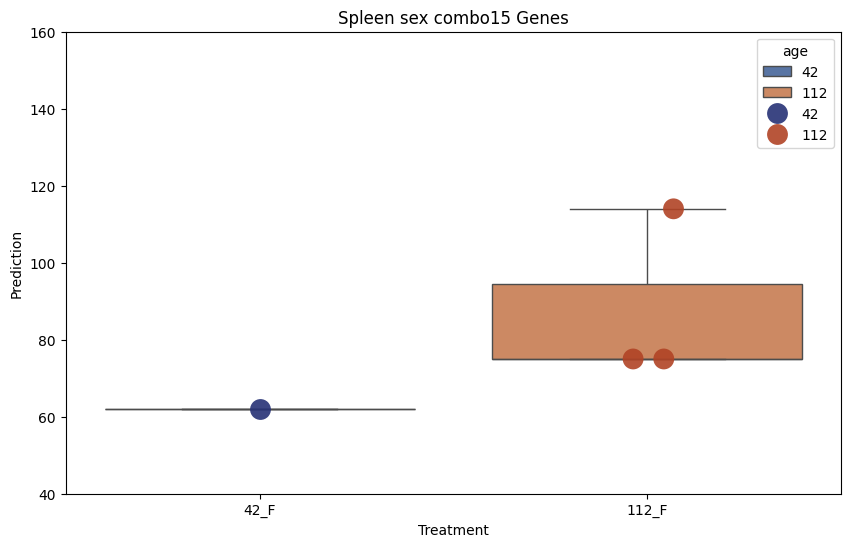

In [ ]:
ordered_x = [
'42_F',
 '112_F'
]


# Create the box plot
plt.figure(figsize=(10, 6))
box = sns.boxplot(x='age_sex', y='prediction', hue='age', data=df_intervention_test_pred, palette='deep', showfliers = False,
    order = ordered_x)

# Add data points

custom_palette = ['#273276', '#B14325']  # Use desired hex color codes

# Add data points with custom colors
strip = sns.stripplot(
    x='age_sex',
    y='prediction',
    hue='age',
    data=df_intervention_test_pred,
    palette=custom_palette,  # Custom color palette
    dodge=False,
    alpha=0.9,
    jitter=True,
    size=15,
    order = ordered_x
)

# Remove the legend if not needed
#strip.legend_.remove()

# Customize the plot
plt.title("".join([f'{select_tissue} sex combo', str(gene_number), ' Genes']))
plt.xlabel('Treatment')
plt.ylabel('Prediction')

# Set y-axis limits
plt.ylim(40, 160)

# Remove the grid
plt.grid(False)


# Show the plot
plt.show()

##### Try several gene set sizes

In [ ]:
# Set up ordered x-axis for plots
ordered_x = [
'42_F',
'112_F'
]

# Custom color palette
custom_palette = ['#273276', '#B14325']

# Directory setup
os.makedirs("./predictions", exist_ok=True)
os.makedirs("./plots", exist_ok=True)

# Dictionary to store prediction DataFrames if needed later
all_predictions = {}

# Loop through gene numbers
for gene_number in range(5, 101, 5):
    print(f"Running prediction for top {gene_number} genes...")

    df_intervention_test_pred = pd.DataFrame(index=df_intervention_test.index, columns=["prediction"])

    for sample in df_intervention_test.index.tolist():
        reference_df = pd.read_csv(f"./{select_tissue}/female/reference/killifish_{select_tissue}_reference_female", sep="\t", index_col=0)
        top_genes = reference_df["spearman_rank"].abs().nlargest(gene_number).index.tolist()

        total_reads_sample = df_intervention_test_counts.loc[sample].sum()
        list_of_profile_probabilities_per_age = []

        for age in new_age_steps:
            log_probs = []
            for gene in top_genes:
                gene_frequency = reference_df.loc[gene, str(age)]
                gene_frequency = max(gene_frequency, 1e-10)  # Ensure >0

                expected = gene_frequency * total_reads_sample
                observed = df_intervention_test_counts.loc[sample, gene]

                poisson_prob = poisson.pmf(k=observed, mu=expected)
                poisson_prob = max(poisson_prob, 0.001)

                log_probs.append(np.log(poisson_prob))

            list_of_profile_probabilities_per_age.append(np.sum(log_probs))

        age_probability_df = pd.DataFrame({"Pr": list_of_profile_probabilities_per_age}, index=new_age_steps)
        max_probability_age = round(float(age_probability_df.idxmax().iloc[0]), 2)
        df_intervention_test_pred.loc[sample, "prediction"] = max_probability_age

    # Add metadata
    df_intervention_test_pred["age"] = df_intervention_test["age"].tolist()
    df_intervention_test_pred["sex"] = df_intervention_test["sex"].tolist()


    df_intervention_test_pred["age_sex"] = (
        df_intervention_test_pred["age"].astype(str) + "_" +
        df_intervention_test_pred["sex"].astype(str)
    )

    # Save predictions
    all_predictions[gene_number] = df_intervention_test_pred.copy()
    df_intervention_test_pred.to_csv(f"./predictions/{select_tissue}_age_femaleOnly_preds_top_{gene_number}_genes.tsv", sep="\t")

    # --- Plot ---
    plt.figure(figsize=(10, 6))

    box = sns.boxplot(
        x='age_sex',
        y='prediction',
        hue='age',
        data=df_intervention_test_pred,
        palette='deep',
        showfliers=False,
        order=ordered_x
    )

    strip = sns.stripplot(
        x='age_sex',
        y='prediction',
        hue='age',
        data=df_intervention_test_pred,
        palette=custom_palette,
        dodge=False,
        alpha=0.9,
        jitter=True,
        size=15,
        order=ordered_x
    )

    # Remove duplicate legend
    strip.legend_.remove()

    plt.title(f"{select_tissue } female {gene_number} Genes")
    plt.xlabel('Treatment')
    plt.ylabel('Prediction')
    plt.xticks(rotation=45, ha='right')
    plt.ylim(40, 160)
    plt.grid(False)

    # Save plot
    plt.savefig(f"./plots/xu_{select_tissue}_female_top_{gene_number}_genes.svg", dpi=300, bbox_inches="tight")
    plt.close()

    print(f"Saved plot and prediction for {gene_number} genes.\n")


Running prediction for top 5 genes...
Saved plot and prediction for 5 genes.

Running prediction for top 10 genes...
Saved plot and prediction for 10 genes.

Running prediction for top 15 genes...
Saved plot and prediction for 15 genes.

Running prediction for top 20 genes...
Saved plot and prediction for 20 genes.

Running prediction for top 25 genes...
Saved plot and prediction for 25 genes.

Running prediction for top 30 genes...
Saved plot and prediction for 30 genes.

Running prediction for top 35 genes...
Saved plot and prediction for 35 genes.

Running prediction for top 40 genes...
Saved plot and prediction for 40 genes.

Running prediction for top 45 genes...
Saved plot and prediction for 45 genes.

Running prediction for top 50 genes...
Saved plot and prediction for 50 genes.

Running prediction for top 55 genes...
Saved plot and prediction for 55 genes.

Running prediction for top 60 genes...
Saved plot and prediction for 60 genes.

Running prediction for top 65 genes...
Sav

##### plot stability of preds

/tmp/ipython-input-248-1805454751.py:64: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
/tmp/ipython-input-248-1805454751.py:64: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
/tmp/ipython-input-248-1805454751.py:64: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
/tmp/ipython-input-248-1805454751.py:64: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


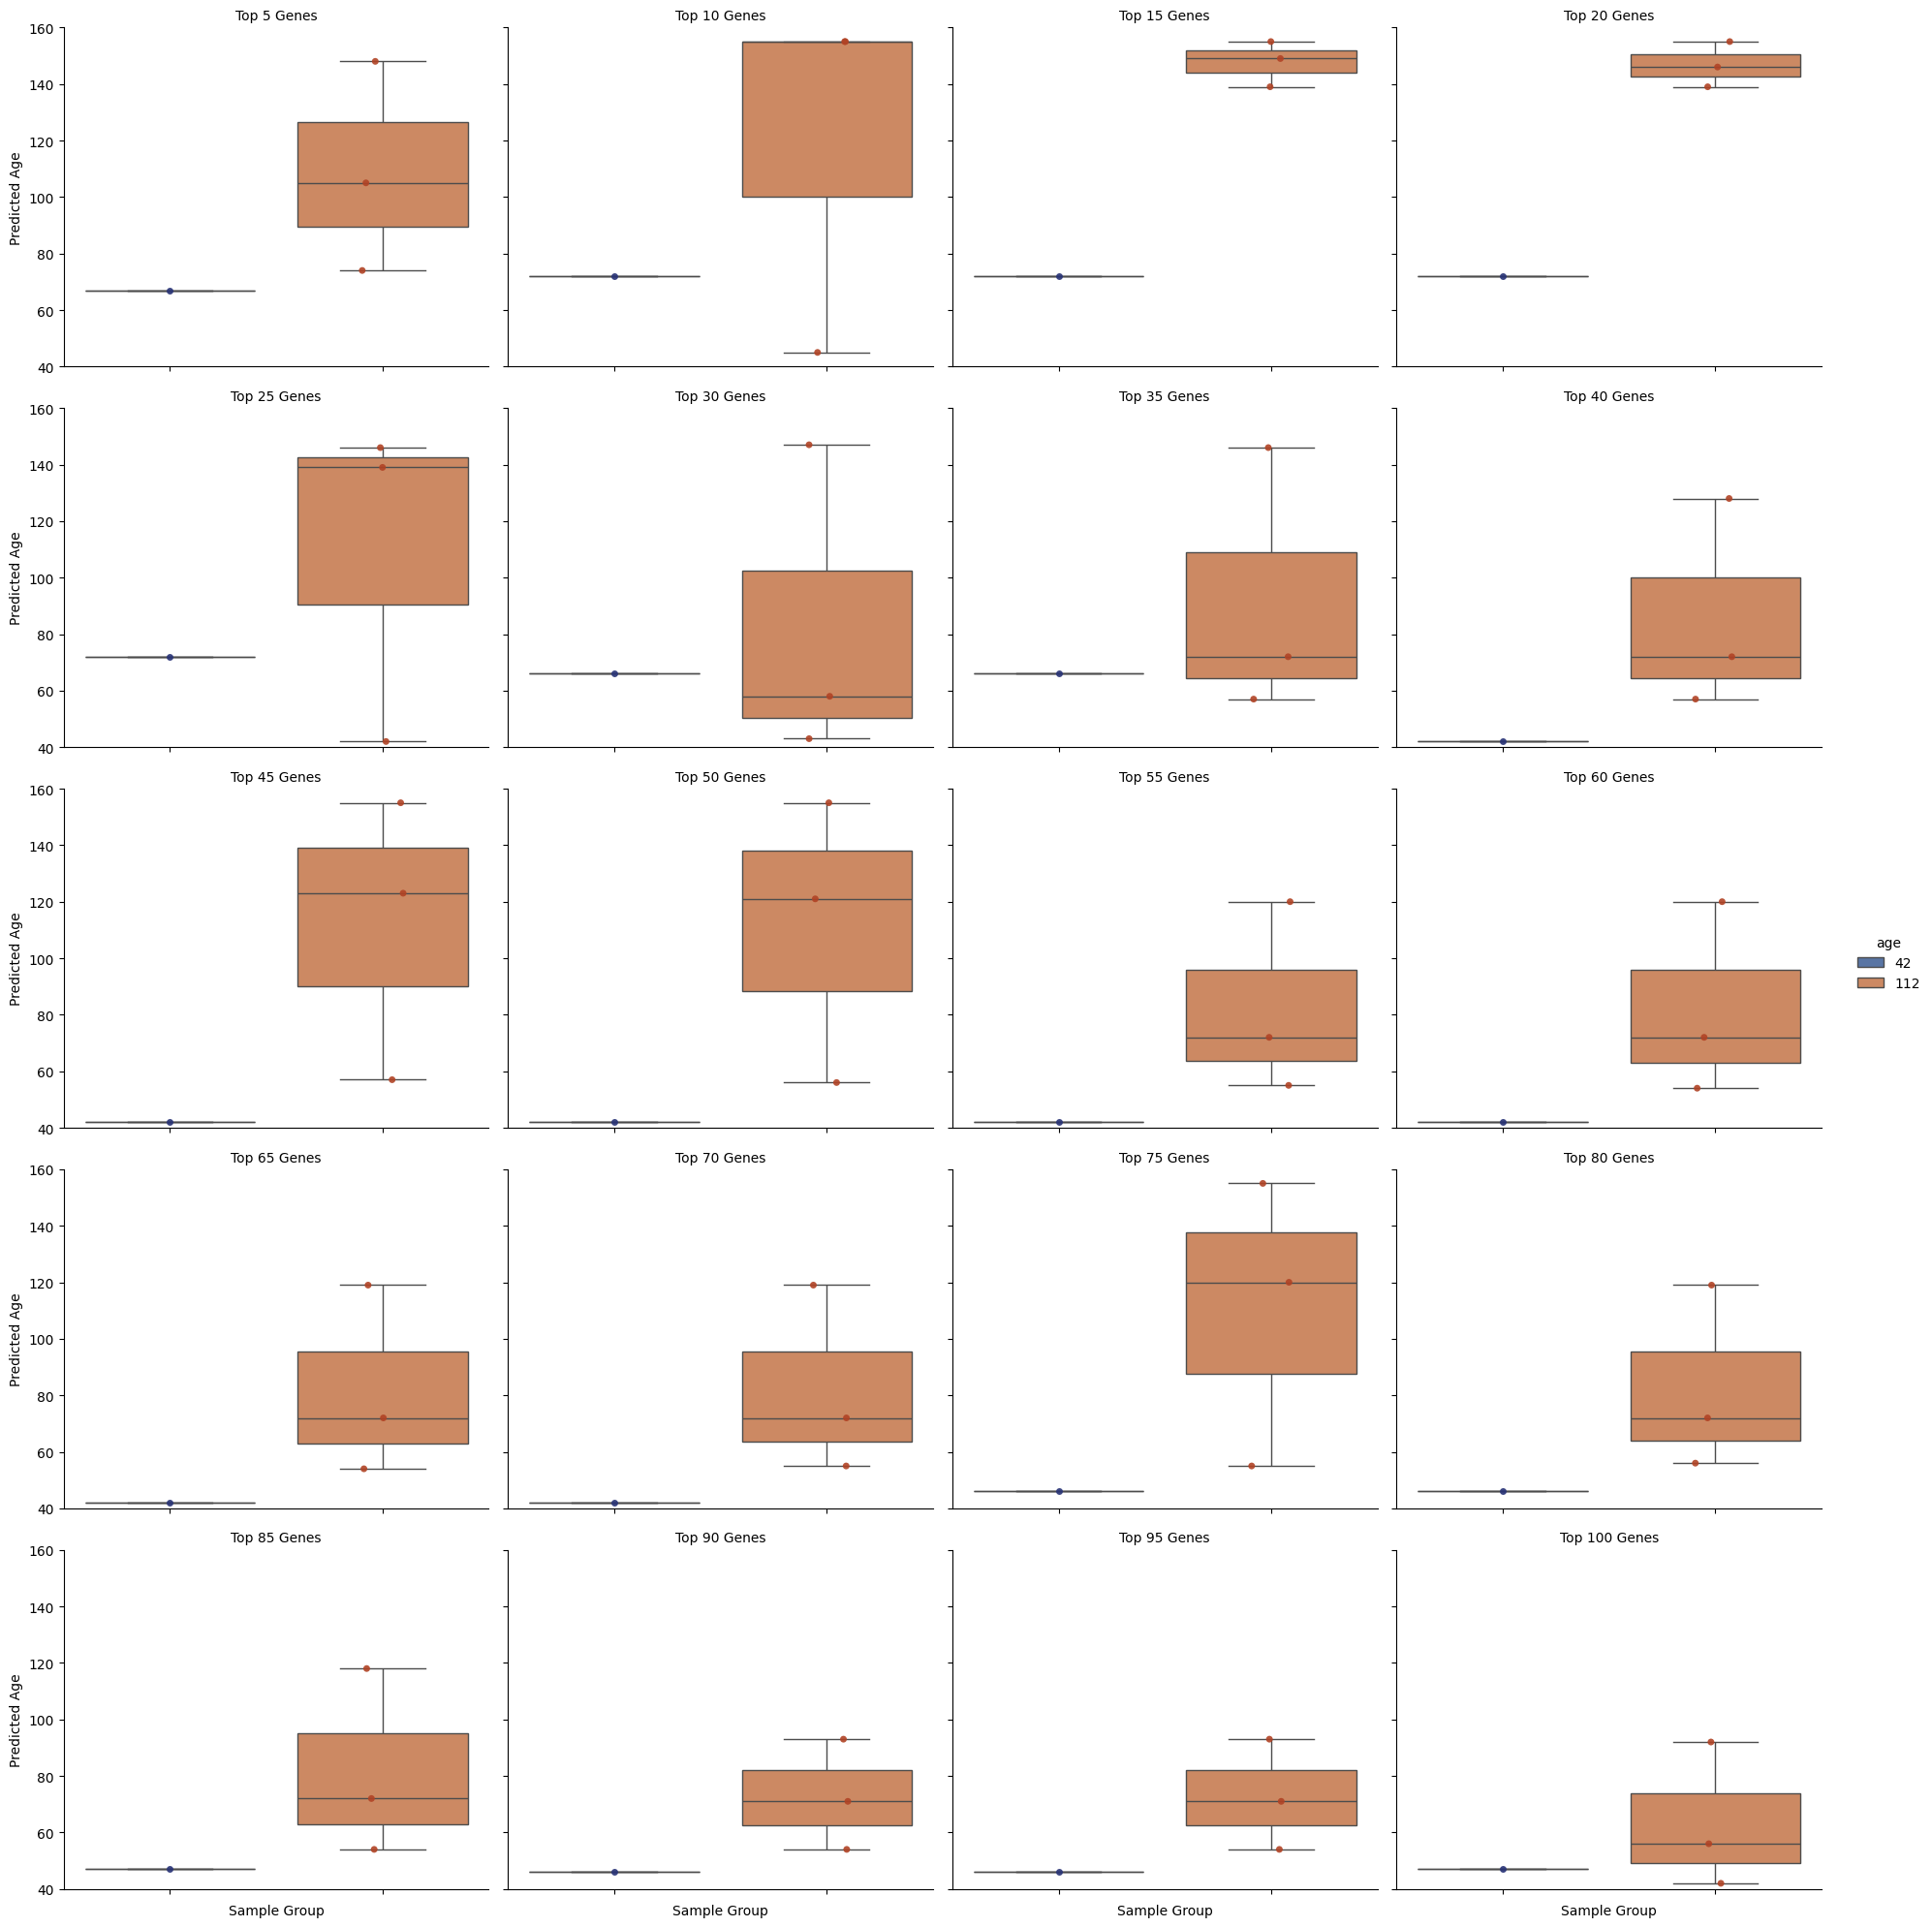

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import os

# Ordered x-axis
ordered_x = [
    '42_F',
'112_F'
]

# Custom palette
custom_palette = ['#273276', '#B14325']

# Load all prediction files
all_predictions_list = []

for gene_number in range(5, 101, 5):
    file_path = f"./predictions/{select_tissue}_age_femaleOnly_preds_top_{gene_number}_genes.tsv"
    if os.path.exists(file_path):
        df = pd.read_csv(file_path, sep="\t", index_col=0)
        df["gene_number"] = str(gene_number)  # for cleaner facet titles
        all_predictions_list.append(df)
    else:
        print(f"Warning: {file_path} not found. Skipping.")

# Concatenate into a single DataFrame
all_predictions_df = pd.concat(all_predictions_list, axis=0)

# Plot with seaborn FacetGrid (catplot)
g = sns.catplot(
    data=all_predictions_df,
    x="age_sex",
    y="prediction",
    hue="age",
    col="gene_number",
    col_wrap=4,
    kind="box",
    palette='deep',
    order=ordered_x,
    height=4,
    aspect=1.2,
    showfliers=False
)

# Overlay stripplot for better visualization
for ax, gene_number in zip(g.axes.flat, all_predictions_df["gene_number"].unique()):
    subset = all_predictions_df[all_predictions_df["gene_number"] == gene_number]
    sns.stripplot(
        x='age_sex',
        y='prediction',
        hue='age',
        data=subset,
        palette=custom_palette,
        dodge=False,
        alpha=0.9,
        jitter=True,
        size=5,
        order=ordered_x,
        ax=ax,
        legend=False
    )
    ax.set_title(f"Top {gene_number} Genes")
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
    ax.set_ylim(40, 160)

g.set_axis_labels("Sample Group", "Predicted Age")
g.set_titles("Top {col_name} Genes")
g.tight_layout()
plt.savefig(f"./plots/{select_tissue}_femaleOnly_faceted_predictions_by_gene_number.svg", dpi=300, bbox_inches="tight")
plt.show()


#Muscle

In [ ]:
select_tissue = 'Muscle'

### Sex combo

In [ ]:
df_intervention_combo = df_intervention.loc[
    (df_intervention.iloc[:, -5] == select_tissue)
]

In [ ]:
all_samples = df_intervention_combo.index
all_samples

random.seed(123)

# Separate the samples
young_samples = [s for s in all_samples if s in df_intervention_combo.index and df_intervention_combo.loc[s, 'age'] == 42]
old_samples = [s for s in all_samples if s in df_intervention_combo.index and df_intervention_combo.loc[s, 'age'] ==  112]

# Randomly sample 2 from each
random_young = random.sample(young_samples, 2)
random_old = random.sample(old_samples, 2)

# Combine the result
random_subset = random_young + random_old

#select your training samples
select_train_samples = random_subset

# Select rows in df_intervention_age_counts_female where index is in female_samples
df_intervention_train = df_intervention_combo.loc[
    df_intervention_combo.index.isin(select_train_samples)
]

df_intervention_train

,nadsyn1,dnaja3,f2r,LOC107382877,fezf1,srbd1,LOC107373267,LOC107384240,serp1,scarb2,...,umodl1,cryz,LOC107397181,pelo,mrpl35,tissue,AGE,sex,training,age
muscle_18,120,422,16,20,4,36,0,0,76,194,...,113,48,1355,547,54,Muscle,16w,F,No,112
muscle_13,54,262,8,2,0,22,0,0,62,152,...,38,46,1229,485,30,Muscle,16w,M,No,112
muscle_9,143,447,6,42,0,67,0,0,125,96,...,22,7,1671,540,90,Muscle,6w,F,No,42
muscle_5,97,172,8,42,0,60,0,0,178,216,...,12,36,1274,434,36,Muscle,6w,M,No,42


In [ ]:
# get your testing samples
#all not in select_train_samples
test_samples = [s for s in all_samples if s not in select_train_samples]
test_samples

['muscle_19',
 'muscle_17',
 'muscle_16',
 'muscle_15',
 'muscle_14',
 'muscle_12',
 'muscle_11',
 'muscle_10',
 'muscle_8',
 'muscle_7',
 'muscle_6',
 'muscle_4',
 'muscle_3',
 'muscle_2',
 'muscle_1']

In [ ]:
# Select rows in df_intervention_age_counts_female where index is in female_samples
df_intervention_test = df_intervention_combo.loc[
    df_intervention_combo.index.isin(test_samples)
]

df_intervention_test.head(2)

,nadsyn1,dnaja3,f2r,LOC107382877,fezf1,srbd1,LOC107373267,LOC107384240,serp1,scarb2,...,umodl1,cryz,LOC107397181,pelo,mrpl35,tissue,AGE,sex,training,age
muscle_19,70,372,8,18,8,32,0,0,64,187,...,54,36,1493,425,42,Muscle,16w,F,No,112
muscle_17,72,341,10,4,0,20,0,0,76,95,...,58,24,961,350,42,Muscle,16w,F,No,112


##### transcriptome reference

In [ ]:
# Specify the path for the new directory for the tissue
directory_path = f"./{select_tissue}/"

# Create the directory
os.mkdir(directory_path)

In [ ]:
#select raw counts
tissue_df_counts = combined_df.loc[
    (combined_df.iloc[:, -2] == select_tissue)
]
tissue_df_counts.head(5)

,a1cf,aaas,aacs,aadat,aaed1,aagab,aak1,aamdc,aamp,aar2,...,zufsp,zw10,zwilch,zyg11b,zyx,zzef1,zzz3,sex,tissue,age
A13_1,0,192,56,302,204,435,376,1219,322,298,...,40,375,5,547,654,126,147,M,Muscle,134
A14_1,0,173,92,333,196,448,419,1127,368,354,...,30,472,6,613,841,241,182,M,Muscle,147
A15_1,0,104,34,194,98,233,131,592,210,122,...,38,228,2,273,370,58,82,M,Muscle,52
A16_1,0,295,51,556,222,578,542,1368,793,459,...,84,376,4,588,765,65,268,F,Muscle,103
B13_1,0,284,55,465,270,571,563,1390,553,447,...,69,385,4,691,966,145,200,F,Muscle,155


In [ ]:
df_intervention_train = df_intervention_train[tissue_df_counts.columns]
df_intervention_train.head(2)

,a1cf,aaas,aacs,aadat,aaed1,aagab,aak1,aamdc,aamp,aar2,...,zufsp,zw10,zwilch,zyg11b,zyx,zzef1,zzz3,sex,tissue,age
muscle_18,13,54,30,129,20,168,178,134,154,26,...,20,78,0,221,126,645,296,F,Muscle,112
muscle_13,12,56,2,50,24,118,144,137,102,34,...,12,84,0,182,169,555,152,M,Muscle,112


In [ ]:
atlas_plus_intervention = pd.concat([tissue_df_counts, df_intervention_train], axis=0)
atlas_plus_intervention.head(3)

,a1cf,aaas,aacs,aadat,aaed1,aagab,aak1,aamdc,aamp,aar2,...,zufsp,zw10,zwilch,zyg11b,zyx,zzef1,zzz3,sex,tissue,age
A13_1,0,192,56,302,204,435,376,1219,322,298,...,40,375,5,547,654,126,147,M,Muscle,134
A14_1,0,173,92,333,196,448,419,1127,368,354,...,30,472,6,613,841,241,182,M,Muscle,147
A15_1,0,104,34,194,98,233,131,592,210,122,...,38,228,2,273,370,58,82,M,Muscle,52


In [ ]:
# #check cols ordered the same
# df_intervention_test = df_intervention_test[tissue_df_counts.columns]
# df_intervention_test.head(2)

In [ ]:
tissue_age_days_value_counts = atlas_plus_intervention["age"].value_counts().index.tolist()

In [ ]:
age_steps = sorted(tissue_age_days_value_counts)

print(age_steps)

[42, 47, 49, 52, 75, 77, 78, 102, 103, 112, 133, 134, 147, 152, 155, 161, 162]


In [ ]:
atlas_plus_intervention_age = atlas_plus_intervention.drop(atlas_plus_intervention.columns[[-2,-3]], axis=1)
atlas_plus_intervention_age.head(2)

,a1cf,aaas,aacs,aadat,aaed1,aagab,aak1,aamdc,aamp,aar2,...,zswim7,zswim8,zufsp,zw10,zwilch,zyg11b,zyx,zzef1,zzz3,age
A13_1,0,192,56,302,204,435,376,1219,322,298,...,21,440,40,375,5,547,654,126,147,134
A14_1,0,173,92,333,196,448,419,1127,368,354,...,22,510,30,472,6,613,841,241,182,147


In [ ]:
#sample generation
for sample in atlas_plus_intervention_age.index.tolist():

    new_df = atlas_plus_intervention_age.drop(sample)

    new_df.to_csv(f"./{select_tissue}/{select_tissue}_sample_{sample}.csv", sep="\t")

In [ ]:
new_age_steps = np.arange(min(age_steps), max(age_steps)+1, 1)

In [ ]:
# Specify the path for the new directory for the tissue
directory_path = f"./{select_tissue}/reference"

# Create the directory
os.mkdir(directory_path)

In [ ]:
transcriptome_reference(training_matrix= atlas_plus_intervention_age,
                            reference_name=f"killifish_{select_tissue}_reference_sexcombo",
                            output_path=f"./{select_tissue}/reference/",
                            age_prediction="list",
                            age_list=new_age_steps,
                            min_age=1,
                            max_age=24,
                            age_step=1,
                            tau=0.7)

/tmp/ipython-input-10-2002720175.py:41: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho, p = spearmanr(age_training, gene_frequency)



Reference model dataset written to './Muscle/reference/killifish_Muscle_reference_sexcombo'
Report file generated at './Muscle/reference/killifish_Muscle_reference_sexcombo.report.txt'
-----------------------------------------------------



Time to run construct reference: 111.265 seconds

The reference is constructed and saved!


,42,43,44,45,46,47,48,49,50,51,...,155,156,157,158,159,160,161,162,spearman_rank,p_value
Gene,,,,,,,,,,,,,,,,,,,,,
a1cf,2.175886e-08,2.251661e-08,2.327962e-08,2.404820e-08,2.482269e-08,2.560343e-08,2.639070e-08,2.718461e-08,2.798514e-08,2.879191e-08,...,2.549613e-08,2.450825e-08,2.352336e-08,2.254162e-08,2.156315e-08,2.058811e-08,1.961665e-08,1.864896e-08,-0.028047,0.832991
aaas,5.945753e-06,5.962978e-06,5.980124e-06,5.997192e-06,6.014182e-06,6.031096e-06,6.047932e-06,6.064679e-06,6.081328e-06,6.097874e-06,...,7.174630e-06,7.180927e-06,7.187116e-06,7.193200e-06,7.199180e-06,7.205059e-06,7.210838e-06,7.216521e-06,0.221946,0.091130
aacs,2.092062e-06,2.090639e-06,2.089277e-06,2.087973e-06,2.086719e-06,2.085513e-06,2.084345e-06,2.083204e-06,2.082075e-06,2.080952e-06,...,1.737192e-06,1.736515e-06,1.735987e-06,1.735612e-06,1.735392e-06,1.735330e-06,1.735428e-06,1.735686e-06,-0.175853,0.182776
aadat,9.372475e-06,9.403154e-06,9.433786e-06,9.464368e-06,9.494898e-06,9.525372e-06,9.555785e-06,9.586119e-06,9.616360e-06,9.646510e-06,...,1.203311e-05,1.205841e-05,1.208372e-05,1.210907e-05,1.213444e-05,1.215985e-05,1.218531e-05,1.221082e-05,0.391327,0.002178
aaed1,4.859515e-06,4.910779e-06,4.961940e-06,5.012993e-06,5.063934e-06,5.114758e-06,5.165454e-06,5.215993e-06,5.266342e-06,5.316476e-06,...,7.214016e-06,7.232796e-06,7.252047e-06,7.271781e-06,7.292008e-06,7.312739e-06,7.333983e-06,7.355751e-06,0.341778,0.008064
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
zwilch,4.335161e-07,4.280407e-07,4.226099e-07,4.172255e-07,4.118892e-07,4.066030e-07,4.013683e-07,3.961855e-07,3.910545e-07,3.859745e-07,...,1.467117e-07,1.459632e-07,1.452328e-07,1.445207e-07,1.438268e-07,1.431511e-07,1.424938e-07,1.418549e-07,-0.330747,0.010509
zyg11b,1.328115e-05,1.335608e-05,1.343113e-05,1.350628e-05,1.358152e-05,1.365681e-05,1.373213e-05,1.380744e-05,1.388267e-05,1.395780e-05,...,1.913647e-05,1.915889e-05,1.918120e-05,1.920343e-05,1.922560e-05,1.924772e-05,1.926982e-05,1.929191e-05,0.523809,0.000021
zyx,2.006112e-05,2.019856e-05,2.033605e-05,2.047362e-05,2.061128e-05,2.074905e-05,2.088692e-05,2.102483e-05,2.116267e-05,2.130042e-05,...,2.792397e-05,2.793554e-05,2.794710e-05,2.795868e-05,2.797030e-05,2.798197e-05,2.799372e-05,2.800556e-05,0.329742,0.010761


In [ ]:
df_intervention_test.head(1)

,nadsyn1,dnaja3,f2r,LOC107382877,fezf1,srbd1,LOC107373267,LOC107384240,serp1,scarb2,...,umodl1,cryz,LOC107397181,pelo,mrpl35,tissue,AGE,sex,training,age
muscle_19,70,372,8,18,8,32,0,0,64,187,...,54,36,1493,425,42,Muscle,16w,F,No,112


In [ ]:
df_intervention_test_counts = df_intervention_test.drop(df_intervention_test.columns[[-2, -3,-4, -5]], axis=1)
df_intervention_test_counts.head(3)

,nadsyn1,dnaja3,f2r,LOC107382877,fezf1,srbd1,LOC107373267,LOC107384240,serp1,scarb2,...,plekhg1,LOC107373049,LOC107375201,LOC107384697,umodl1,cryz,LOC107397181,pelo,mrpl35,age
muscle_19,70,372,8,18,8,32,0,0,64,187,...,188,0,4,2,54,36,1493,425,42,112
muscle_17,72,341,10,4,0,20,0,0,76,95,...,216,0,8,0,58,24,961,350,42,112
muscle_16,105,384,20,10,2,21,0,0,62,151,...,266,0,4,0,66,36,1153,486,52,112


In [ ]:
gene_number = 15
df_intervention_test_pred = pd.DataFrame(index=df_intervention_test.index, columns=["prediction"])

for sample in df_intervention_test.index.tolist():

    reference_df = pd.read_csv(f"./{select_tissue}/reference/killifish_{select_tissue}_reference_sexcombo", sep="\t", index_col=0)

    # Get top genes based on spearman correlation
    top_abs_spearman_corr = reference_df["spearman_rank"].abs().nlargest(gene_number)

    #print(top_abs_spearman_corr)

    top_genes = top_abs_spearman_corr.index.tolist()

    # Save the DataFrame to a CSV file
    # df_top_genes = pd.DataFrame(top_genes, columns=["genes"])
    # gene_num = "".join([str(gene_number), "genes"])
    # out_file_prefix = 'Antebi_male_pred'
    # out_file_name = "_".join([out_file_prefix, gene_num])
    # output_path = './fat/gene_sets'
    # df_top_genes.to_csv(os.path.join(output_path, out_file_name), sep="\t")
    # print(f"List has been written to {out_file_name}")

    total_reads_sample = df_intervention_test_counts.loc[sample].sum()

    list_of_profile_probabilities_per_age = []

    for age in new_age_steps:

        probability_list_one_age = []

        genes_not_defined = []

        for gene in top_genes:

            gene_frequency = reference_df.loc[gene, f"{age}"]

            if gene_frequency < 0:
                gene_frequency = 10**-10

            sample_expected_counts = gene_frequency * total_reads_sample
            sample_observed_counts = df_intervention_test_counts.loc[sample, gene]

            poisson_probability = poisson.pmf(k=sample_observed_counts, mu=sample_expected_counts)

            # Replace NaN poisson probability with a small positive value and log it
            if np.isnan(poisson_probability):
                poisson_probability = 0.001
                genes_not_defined.append(gene)

            # Replace zero poisson probability with 0.001
            if poisson_probability == 0:
                poisson_probability = 0.001

            logP = np.log(poisson_probability)

            probability_list_one_age.append(logP)

        list_of_profile_probabilities_per_age.append(np.sum(probability_list_one_age))

    # Transform into dataframe with age steps
    age_probability_df = pd.DataFrame({"Pr": list_of_profile_probabilities_per_age}, index=new_age_steps)

    # Compute highest likelihood age among age steps
    max_probability_age = round(float(age_probability_df.idxmax().iloc[0]), 2)

    # Compute highest maximum probability
    max_probability = float(age_probability_df["Pr"].max())

    df_intervention_test_pred.loc[sample, "prediction"] = max_probability_age



print(df_intervention_test_pred)

          prediction
muscle_19       71.0
muscle_17       61.0
muscle_16       65.0
muscle_15       57.0
muscle_14       78.0
muscle_12      102.0
muscle_11       83.0
muscle_10      114.0
muscle_8        44.0
muscle_7        42.0
muscle_6        42.0
muscle_4        42.0
muscle_3        42.0
muscle_2        42.0
muscle_1        42.0


In [ ]:
df_intervention_test_pred["age"] = df_intervention_test["age"].tolist()
df_intervention_test_pred["sex"] = df_intervention_test["sex"].tolist()


df_intervention_test_pred["age_sex"] = (
    df_intervention_test_pred["age"].astype(str) + "_" +
    df_intervention_test_pred["sex"].astype(str)
)

df_intervention_test_pred

,prediction,age,sex,age_sex
muscle_19,71.0,112,F,112_F
muscle_17,61.0,112,F,112_F
muscle_16,65.0,112,F,112_F
muscle_15,57.0,112,F,112_F
muscle_14,78.0,112,M,112_M
muscle_12,102.0,112,M,112_M
muscle_11,83.0,112,M,112_M
muscle_10,114.0,112,M,112_M
muscle_8,44.0,42,F,42_F
muscle_7,42.0,42,F,42_F


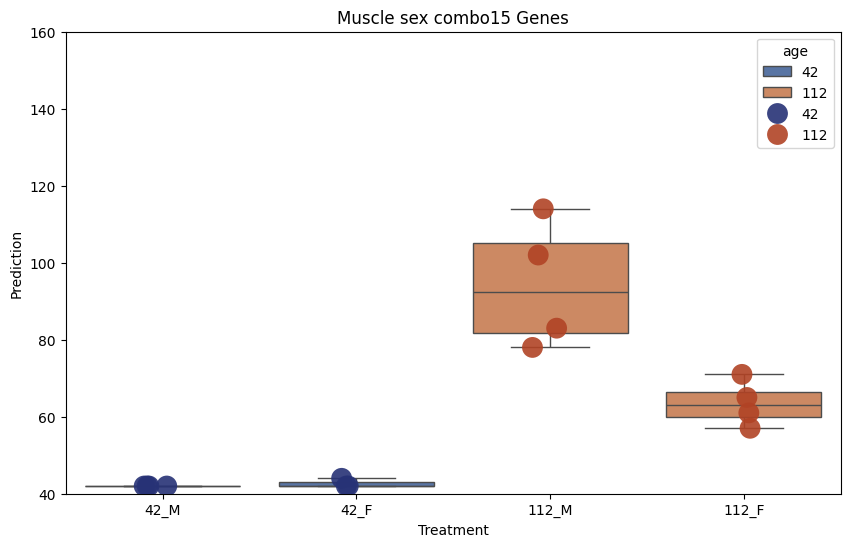

In [ ]:
ordered_x = [
    '42_M', '42_F',
    '112_M', '112_F'
]


# Create the box plot
plt.figure(figsize=(10, 6))
box = sns.boxplot(x='age_sex', y='prediction', hue='age', data=df_intervention_test_pred, palette='deep', showfliers = False,
    order = ordered_x)

# Add data points

custom_palette = ['#273276', '#B14325']  # Use desired hex color codes

# Add data points with custom colors
strip = sns.stripplot(
    x='age_sex',
    y='prediction',
    hue='age',
    data=df_intervention_test_pred,
    palette=custom_palette,  # Custom color palette
    dodge=False,
    alpha=0.9,
    jitter=True,
    size=15,
    order = ordered_x
)

# Remove the legend if not needed
#strip.legend_.remove()

# Customize the plot
plt.title("".join([f'{select_tissue} sex combo', str(gene_number), ' Genes']))
plt.xlabel('Treatment')
plt.ylabel('Prediction')

# Set y-axis limits
plt.ylim(40, 160)

# Remove the grid
plt.grid(False)

# Show the plot
plt.show()

##### Try several gene set sizes

In [ ]:
# Set up ordered x-axis for plots
ordered_x = [
    '42_M', '42_F',
    '112_M', '112_F'
]

# Custom color palette
custom_palette = ['#273276', '#B14325']

# Directory setup
os.makedirs("./predictions", exist_ok=True)
os.makedirs("./plots", exist_ok=True)

# Dictionary to store prediction DataFrames if needed later
all_predictions = {}

# Loop through gene numbers
for gene_number in range(5, 101, 5):
    print(f"Running prediction for top {gene_number} genes...")

    df_intervention_test_pred = pd.DataFrame(index=df_intervention_test.index, columns=["prediction"])

    for sample in df_intervention_test.index.tolist():
        reference_df = pd.read_csv(f"./{select_tissue}/reference/killifish_{select_tissue}_reference_sexcombo", sep="\t", index_col=0)
        top_genes = reference_df["spearman_rank"].abs().nlargest(gene_number).index.tolist()

        total_reads_sample = df_intervention_test_counts.loc[sample].sum()
        list_of_profile_probabilities_per_age = []

        for age in new_age_steps:
            log_probs = []
            for gene in top_genes:
                gene_frequency = reference_df.loc[gene, str(age)]
                gene_frequency = max(gene_frequency, 1e-10)  # Ensure >0

                expected = gene_frequency * total_reads_sample
                observed = df_intervention_test_counts.loc[sample, gene]

                poisson_prob = poisson.pmf(k=observed, mu=expected)
                poisson_prob = max(poisson_prob, 0.001)

                log_probs.append(np.log(poisson_prob))

            list_of_profile_probabilities_per_age.append(np.sum(log_probs))

        age_probability_df = pd.DataFrame({"Pr": list_of_profile_probabilities_per_age}, index=new_age_steps)
        max_probability_age = round(float(age_probability_df.idxmax().iloc[0]), 2)
        df_intervention_test_pred.loc[sample, "prediction"] = max_probability_age

    # Add metadata
    df_intervention_test_pred["age"] = df_intervention_test["age"].tolist()
    df_intervention_test_pred["sex"] = df_intervention_test["sex"].tolist()


    df_intervention_test_pred["age_sex"] = (
        df_intervention_test_pred["age"].astype(str) + "_" +
        df_intervention_test_pred["sex"].astype(str)
    )

    # Save predictions
    all_predictions[gene_number] = df_intervention_test_pred.copy()
    df_intervention_test_pred.to_csv(f"./predictions/{select_tissue}_sexcombo_age_preds_top_{gene_number}_genes.tsv", sep="\t")

    # --- Plot ---
    plt.figure(figsize=(10, 6))

    box = sns.boxplot(
        x='age_sex',
        y='prediction',
        hue='age',
        data=df_intervention_test_pred,
        palette='deep',
        showfliers=False,
        order=ordered_x
    )

    strip = sns.stripplot(
        x='age_sex',
        y='prediction',
        hue='age',
        data=df_intervention_test_pred,
        palette=custom_palette,
        dodge=False,
        alpha=0.9,
        jitter=True,
        size=15,
        order=ordered_x
    )

    # Remove duplicate legend
    strip.legend_.remove()

    plt.title(f"Brain sex combo {gene_number} Genes")
    plt.xlabel('Treatment')
    plt.ylabel('Prediction')
    plt.xticks(rotation=45, ha='right')
    plt.ylim(40, 160)
    plt.grid(False)

    # Save plot
    plt.savefig(f"./plots/xu_{select_tissue}_sexcombo_top_{gene_number}_genes.svg", dpi=300, bbox_inches="tight")
    plt.close()

    print(f"Saved plot and prediction for {gene_number} genes.\n")


Running prediction for top 5 genes...
Saved plot and prediction for 5 genes.

Running prediction for top 10 genes...
Saved plot and prediction for 10 genes.

Running prediction for top 15 genes...
Saved plot and prediction for 15 genes.

Running prediction for top 20 genes...
Saved plot and prediction for 20 genes.

Running prediction for top 25 genes...
Saved plot and prediction for 25 genes.

Running prediction for top 30 genes...
Saved plot and prediction for 30 genes.

Running prediction for top 35 genes...
Saved plot and prediction for 35 genes.

Running prediction for top 40 genes...
Saved plot and prediction for 40 genes.

Running prediction for top 45 genes...
Saved plot and prediction for 45 genes.

Running prediction for top 50 genes...
Saved plot and prediction for 50 genes.

Running prediction for top 55 genes...
Saved plot and prediction for 55 genes.

Running prediction for top 60 genes...
Saved plot and prediction for 60 genes.

Running prediction for top 65 genes...
Sav

##### plot stability of preds

/tmp/ipython-input-272-3290434677.py:64: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
/tmp/ipython-input-272-3290434677.py:64: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
/tmp/ipython-input-272-3290434677.py:64: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
/tmp/ipython-input-272-3290434677.py:64: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


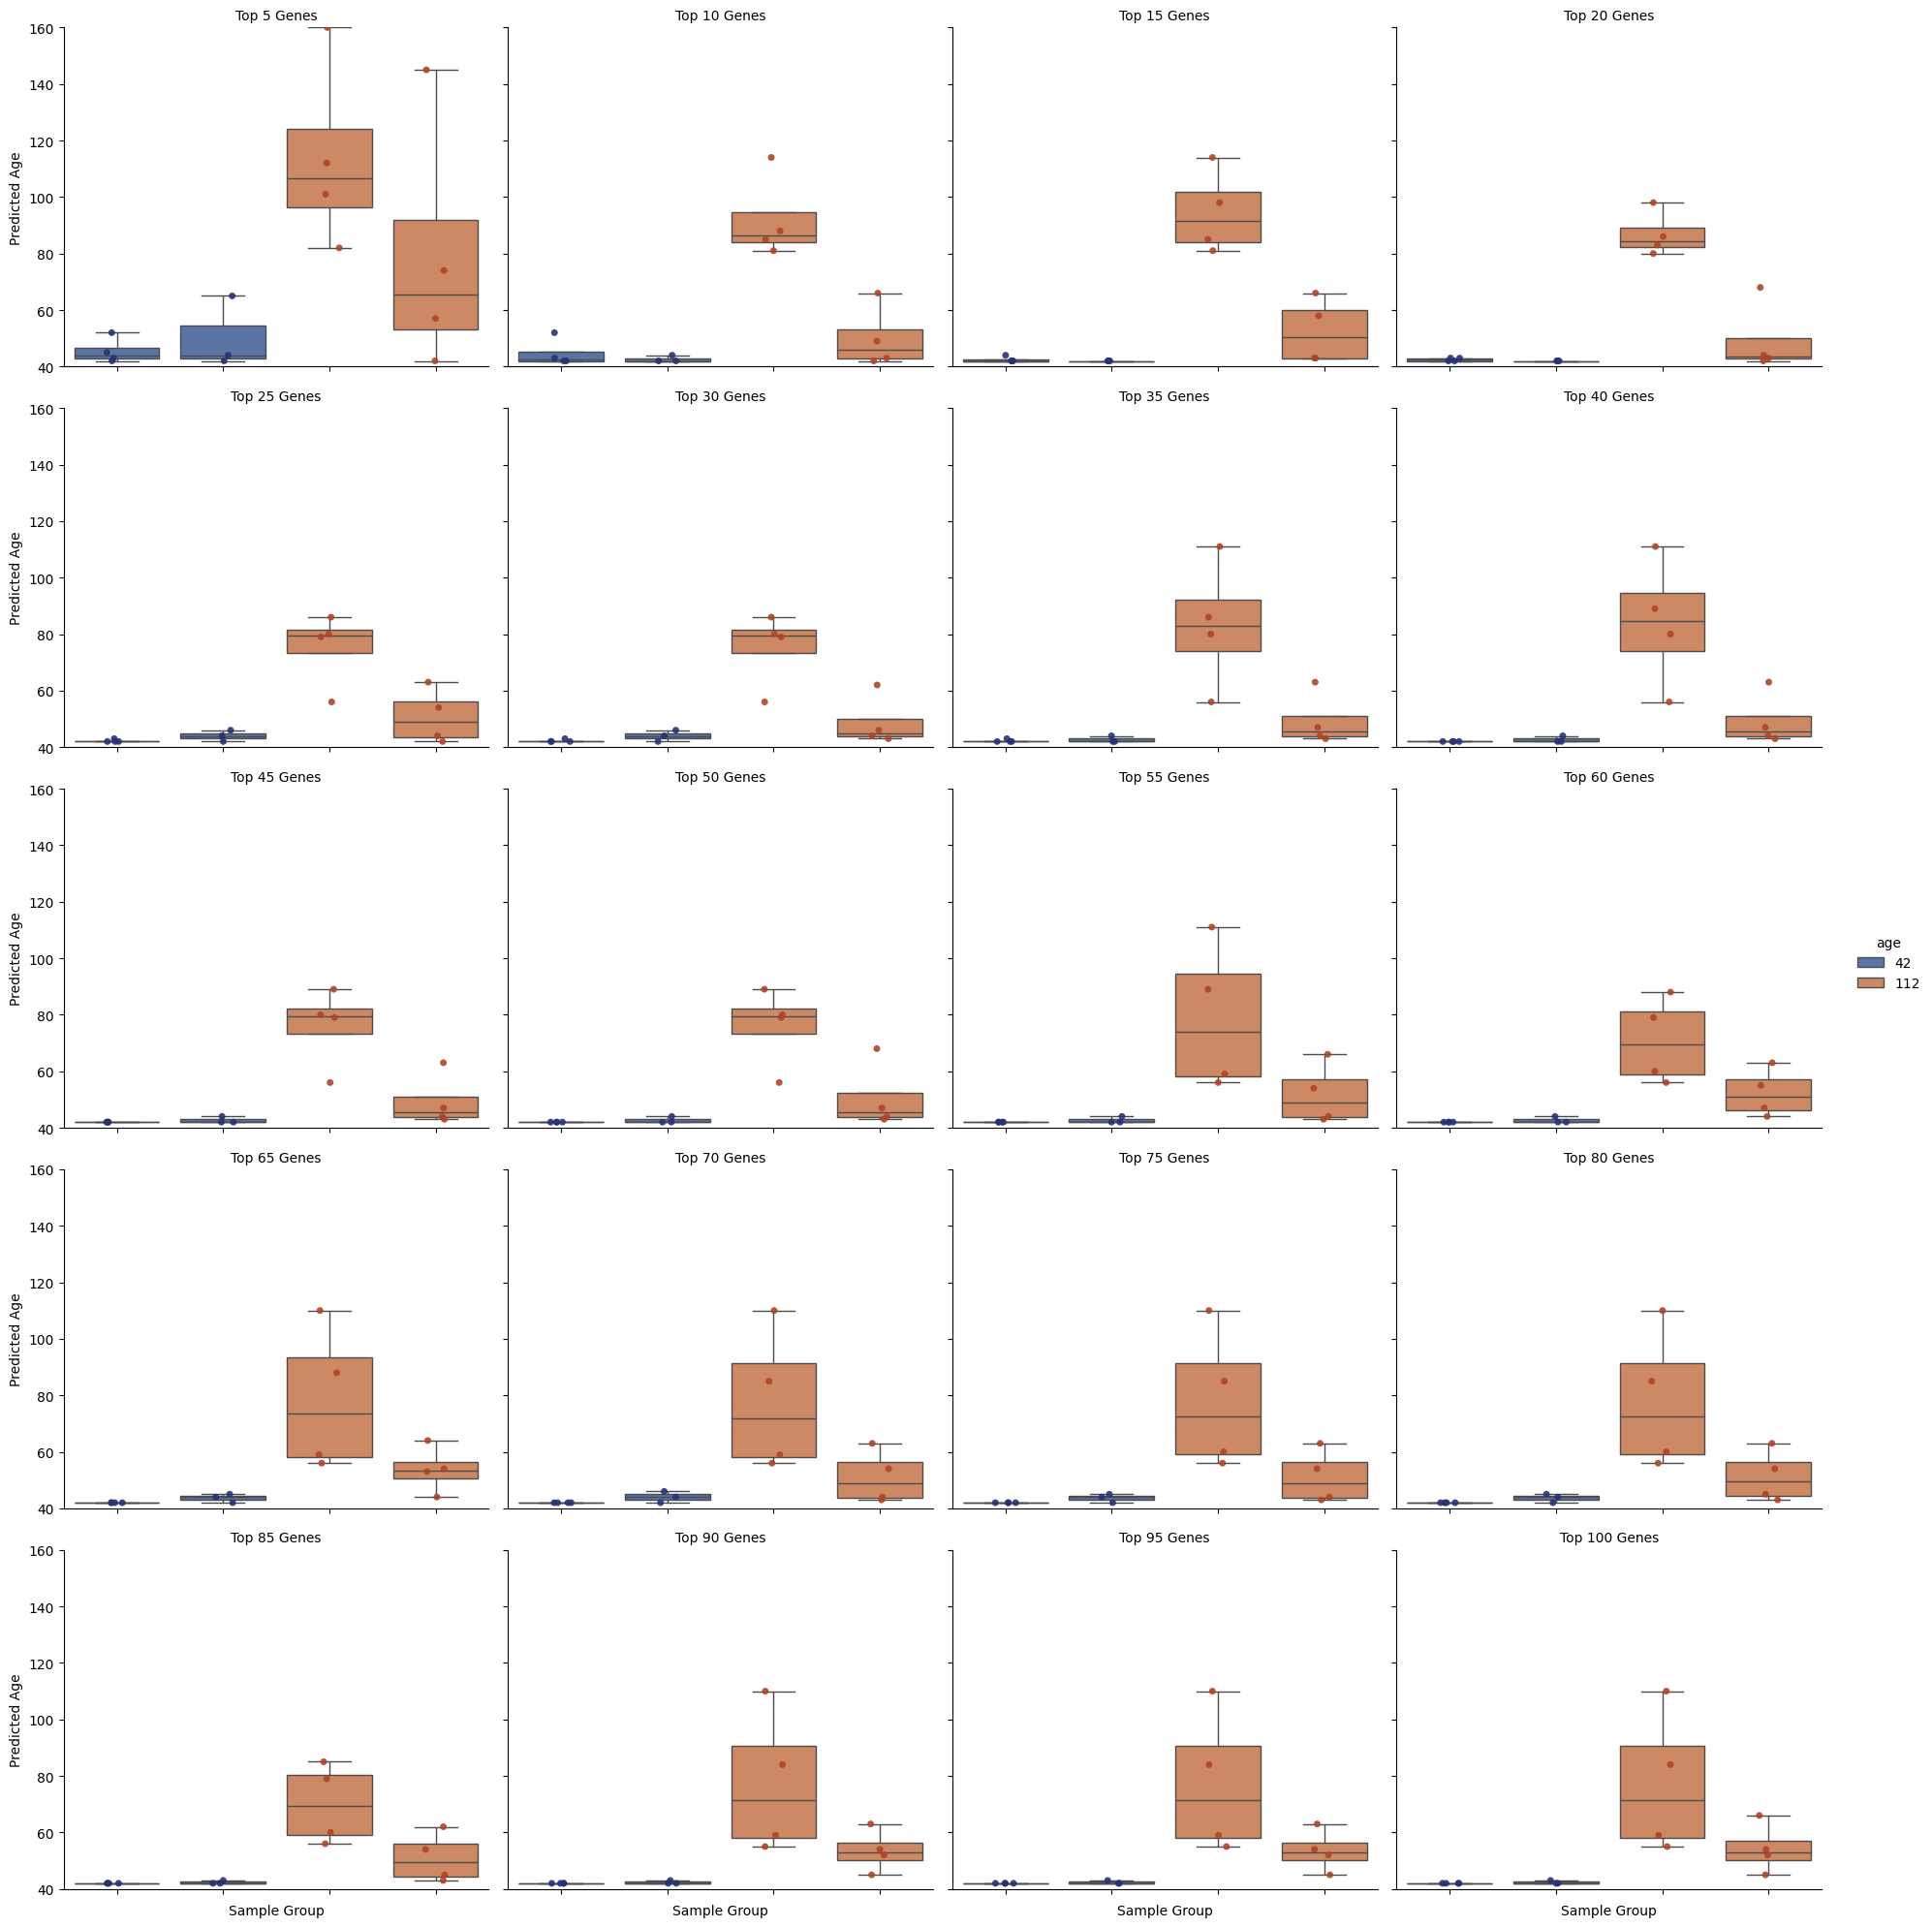

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import os

# Ordered x-axis
ordered_x = [
    '42_M', '42_F',
    '112_M', '112_F'
]

# Custom palette
custom_palette = ['#273276', '#B14325']

# Load all prediction files
all_predictions_list = []

for gene_number in range(5, 101, 5):
    file_path = f"./predictions/{select_tissue}_sexcombo_age_preds_top_{gene_number}_genes.tsv"
    if os.path.exists(file_path):
        df = pd.read_csv(file_path, sep="\t", index_col=0)
        df["gene_number"] = str(gene_number)  # for cleaner facet titles
        all_predictions_list.append(df)
    else:
        print(f"Warning: {file_path} not found. Skipping.")

# Concatenate into a single DataFrame
all_predictions_df = pd.concat(all_predictions_list, axis=0)

# Plot with seaborn FacetGrid (catplot)
g = sns.catplot(
    data=all_predictions_df,
    x="age_sex",
    y="prediction",
    hue="age",
    col="gene_number",
    col_wrap=4,
    kind="box",
    palette='deep',
    order=ordered_x,
    height=4,
    aspect=1.2,
    showfliers=False
)

# Overlay stripplot for better visualization
for ax, gene_number in zip(g.axes.flat, all_predictions_df["gene_number"].unique()):
    subset = all_predictions_df[all_predictions_df["gene_number"] == gene_number]
    sns.stripplot(
        x='age_sex',
        y='prediction',
        hue='age',
        data=subset,
        palette=custom_palette,
        dodge=False,
        alpha=0.9,
        jitter=True,
        size=5,
        order=ordered_x,
        ax=ax,
        legend=False
    )
    ax.set_title(f"Top {gene_number} Genes")
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
    ax.set_ylim(40, 160)

g.set_axis_labels("Sample Group", "Predicted Age")
g.set_titles("Top {col_name} Genes")
g.tight_layout()
plt.savefig(f"./plots/{select_tissue}_sex_combo_faceted_predictions_by_gene_number.svg", dpi=300, bbox_inches="tight")
plt.show()


### Male only

In [ ]:
df_intervention_combo.head(2)

,nadsyn1,dnaja3,f2r,LOC107382877,fezf1,srbd1,LOC107373267,LOC107384240,serp1,scarb2,...,umodl1,cryz,LOC107397181,pelo,mrpl35,tissue,AGE,sex,training,age
muscle_19,70,372,8,18,8,32,0,0,64,187,...,54,36,1493,425,42,Muscle,16w,F,No,112
muscle_18,120,422,16,20,4,36,0,0,76,194,...,113,48,1355,547,54,Muscle,16w,F,No,112


In [ ]:
df_intervention_male = df_intervention_combo.loc[
    (df_intervention_combo.iloc[:, -3] == 'M')
]

In [ ]:
all_samples = df_intervention_male.index
all_samples

random.seed(123)

# Separate the samples
young_samples = [s for s in all_samples if s in df_intervention_male.index and df_intervention_male.loc[s, 'age'] == 42]
old_samples = [s for s in all_samples if s in df_intervention_male.index and df_intervention_male.loc[s, 'age'] ==  112]

# Randomly sample 2 from each
random_young = random.sample(young_samples, 2)
random_old = random.sample(old_samples, 2)

# Combine the result
random_subset = random_young + random_old

#select your training samples
select_train_samples = random_subset

# Select rows in df_intervention_age_counts_female where index is in female_samples
df_intervention_train = df_intervention_male.loc[
    df_intervention_male.index.isin(select_train_samples)
]

df_intervention_train

,nadsyn1,dnaja3,f2r,LOC107382877,fezf1,srbd1,LOC107373267,LOC107384240,serp1,scarb2,...,umodl1,cryz,LOC107397181,pelo,mrpl35,tissue,AGE,sex,training,age
muscle_14,121,516,18,4,0,26,0,0,128,183,...,40,60,1567,438,99,Muscle,16w,M,No,112
muscle_11,79,354,20,18,0,34,6,0,90,158,...,34,48,977,320,56,Muscle,16w,M,No,112
muscle_5,97,172,8,42,0,60,0,0,178,216,...,12,36,1274,434,36,Muscle,6w,M,No,42
muscle_3,110,460,13,10,2,24,0,0,98,134,...,8,42,1559,604,52,Muscle,6w,M,No,42


In [ ]:
# get your testing samples
#all not in select_train_samples
test_samples = [s for s in all_samples if s not in select_train_samples]
test_samples

['muscle_13', 'muscle_12', 'muscle_10', 'muscle_4', 'muscle_2', 'muscle_1']

In [ ]:
# Select rows in df_intervention_age_counts_female where index is in female_samples
df_intervention_test = df_intervention_male.loc[
    df_intervention_male.index.isin(test_samples)
]

df_intervention_test

,nadsyn1,dnaja3,f2r,LOC107382877,fezf1,srbd1,LOC107373267,LOC107384240,serp1,scarb2,...,umodl1,cryz,LOC107397181,pelo,mrpl35,tissue,AGE,sex,training,age
muscle_13,54,262,8,2,0,22,0,0,62,152,...,38,46,1229,485,30,Muscle,16w,M,No,112
muscle_12,97,474,12,2,0,30,0,0,108,194,...,38,50,1826,561,106,Muscle,16w,M,No,112
muscle_10,90,284,34,4,0,32,0,0,66,155,...,28,42,1026,398,80,Muscle,16w,M,No,112
muscle_4,128,290,6,4,0,53,0,0,80,110,...,8,14,1153,549,39,Muscle,6w,M,No,42
muscle_2,98,320,2,8,0,36,0,0,92,105,...,10,36,1203,511,64,Muscle,6w,M,No,42
muscle_1,98,389,18,14,2,37,1,0,146,123,...,33,20,1541,679,42,Muscle,6w,M,No,42


##### transcriptome reference

In [ ]:
# Specify the path for the new directory for the tissue
directory_path = f"./{select_tissue}/male/"

# Create the directory
os.mkdir(directory_path)

In [ ]:
tissue_df_counts.head(1)

,a1cf,aaas,aacs,aadat,aaed1,aagab,aak1,aamdc,aamp,aar2,...,zufsp,zw10,zwilch,zyg11b,zyx,zzef1,zzz3,sex,tissue,age
A13_1,0,192,56,302,204,435,376,1219,322,298,...,40,375,5,547,654,126,147,M,Muscle,134


In [ ]:
#select raw counts
tissue_df_counts = combined_df.loc[
    (combined_df.iloc[:, -2] == select_tissue) &
     (combined_df.iloc[:, -3] == 'M')
]
tissue_df_counts.head(5)

,a1cf,aaas,aacs,aadat,aaed1,aagab,aak1,aamdc,aamp,aar2,...,zufsp,zw10,zwilch,zyg11b,zyx,zzef1,zzz3,sex,tissue,age
A13_1,0,192,56,302,204,435,376,1219,322,298,...,40,375,5,547,654,126,147,M,Muscle,134
A14_1,0,173,92,333,196,448,419,1127,368,354,...,30,472,6,613,841,241,182,M,Muscle,147
A15_1,0,104,34,194,98,233,131,592,210,122,...,38,228,2,273,370,58,82,M,Muscle,52
B15_1,6,382,58,728,262,845,1160,1016,2509,1373,...,318,679,14,517,1338,183,181,M,Muscle,102
B16_1,0,230,32,343,110,608,393,760,836,448,...,56,308,8,355,633,68,119,M,Muscle,133


In [ ]:
df_intervention_train = df_intervention_train[tissue_df_counts.columns]
df_intervention_train.head(2)

,a1cf,aaas,aacs,aadat,aaed1,aagab,aak1,aamdc,aamp,aar2,...,zufsp,zw10,zwilch,zyg11b,zyx,zzef1,zzz3,sex,tissue,age
muscle_14,2,42,19,44,38,188,202,197,122,52,...,20,105,0,298,171,1057,305,M,Muscle,112
muscle_11,42,34,26,78,31,176,158,167,146,30,...,28,126,2,184,152,478,324,M,Muscle,112


In [ ]:
atlas_plus_intervention = pd.concat([tissue_df_counts, df_intervention_train], axis=0)
atlas_plus_intervention.head(3)

,a1cf,aaas,aacs,aadat,aaed1,aagab,aak1,aamdc,aamp,aar2,...,zufsp,zw10,zwilch,zyg11b,zyx,zzef1,zzz3,sex,tissue,age
A13_1,0,192,56,302,204,435,376,1219,322,298,...,40,375,5,547,654,126,147,M,Muscle,134
A14_1,0,173,92,333,196,448,419,1127,368,354,...,30,472,6,613,841,241,182,M,Muscle,147
A15_1,0,104,34,194,98,233,131,592,210,122,...,38,228,2,273,370,58,82,M,Muscle,52


In [ ]:
# #check cols ordered the same
# df_intervention_test = df_intervention_test[tissue_df_counts.columns]
# df_intervention_test.head(2)

In [ ]:
tissue_age_days_value_counts = atlas_plus_intervention["age"].value_counts().index.tolist()

In [ ]:
age_steps = sorted(tissue_age_days_value_counts)

print(age_steps)

[42, 47, 49, 52, 75, 77, 78, 102, 103, 112, 133, 134, 147, 152, 161, 162]


In [ ]:
atlas_plus_intervention_age = atlas_plus_intervention.drop(atlas_plus_intervention.columns[[-2, -3,-4,-5]], axis=1)
atlas_plus_intervention_age.head(2)

,a1cf,aaas,aacs,aadat,aaed1,aagab,aak1,aamdc,aamp,aar2,...,zswim5,zswim6,zswim7,zswim8,zufsp,zw10,zwilch,zyg11b,zyx,age
A13_1,0,192,56,302,204,435,376,1219,322,298,...,725,297,21,440,40,375,5,547,654,134
A14_1,0,173,92,333,196,448,419,1127,368,354,...,950,401,22,510,30,472,6,613,841,147


In [ ]:
#sample generation
for sample in atlas_plus_intervention_age.index.tolist():

    new_df = atlas_plus_intervention_age.drop(sample)

    new_df.to_csv(f"./{select_tissue}/male/{select_tissue}_male_sample_{sample}.csv", sep="\t")

In [ ]:
new_age_steps = np.arange(min(age_steps), max(age_steps)+1, 1)

In [ ]:
# # Specify the path for the new directory for the tissue
# directory_path = f"./{select_tissue}/male/reference"

# # Create the directory
# os.mkdir(directory_path)

FileExistsError: [Errno 17] File exists: './Muscle/male/reference'

In [ ]:
transcriptome_reference(training_matrix= atlas_plus_intervention_age,
                            reference_name=f"killifish_{select_tissue}_reference_male",
                            output_path=f"./{select_tissue}/male/reference/",
                            age_prediction="list",
                            age_list=new_age_steps,
                            min_age=1,
                            max_age=24,
                            age_step=1,
                            tau=0.7)

/tmp/ipython-input-10-2002720175.py:41: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho, p = spearmanr(age_training, gene_frequency)



Reference model dataset written to './Muscle/male/reference/killifish_Muscle_reference_male'
Report file generated at './Muscle/male/reference/killifish_Muscle_reference_male.report.txt'
-----------------------------------------------------



Time to run construct reference: 129.696 seconds

The reference is constructed and saved!


,42,43,44,45,46,47,48,49,50,51,...,155,156,157,158,159,160,161,162,spearman_rank,p_value
Gene,,,,,,,,,,,,,,,,,,,,,
a1cf,5.948006e-08,5.953354e-08,5.960450e-08,5.969162e-08,5.979356e-08,5.990892e-08,6.003633e-08,6.017447e-08,6.032207e-08,6.047807e-08,...,4.414879e-08,4.262570e-08,4.109427e-08,3.955485e-08,3.800782e-08,3.645351e-08,3.489230e-08,3.332462e-08,-0.134047,0.435730
aaas,5.685341e-06,5.702171e-06,5.718942e-06,5.735651e-06,5.752292e-06,5.768859e-06,5.785344e-06,5.801729e-06,5.817992e-06,5.834117e-06,...,6.810076e-06,6.823222e-06,6.836363e-06,6.849509e-06,6.862670e-06,6.875859e-06,6.889084e-06,6.902356e-06,0.170773,0.319339
aacs,2.054170e-06,2.051360e-06,2.048663e-06,2.046073e-06,2.043586e-06,2.041197e-06,2.038899e-06,2.036678e-06,2.034517e-06,2.032404e-06,...,1.687025e-06,1.685275e-06,1.683672e-06,1.682223e-06,1.680934e-06,1.679809e-06,1.678855e-06,1.678074e-06,-0.166388,0.332108
aadat,9.728257e-06,9.753061e-06,9.777671e-06,9.802096e-06,9.826345e-06,9.850430e-06,9.874354e-06,9.898101e-06,9.921652e-06,9.945001e-06,...,1.177452e-05,1.180887e-05,1.184333e-05,1.187793e-05,1.191268e-05,1.194759e-05,1.198269e-05,1.201798e-05,0.302593,0.072845
aaed1,4.351914e-06,4.407392e-06,4.462686e-06,4.517790e-06,4.572698e-06,4.627404e-06,4.681896e-06,4.736144e-06,4.790116e-06,4.843792e-06,...,7.384053e-06,7.415333e-06,7.447003e-06,7.479075e-06,7.511559e-06,7.544466e-06,7.577805e-06,7.611587e-06,0.438799,0.007425
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
zufsp,1.253438e-06,1.264145e-06,1.274793e-06,1.285378e-06,1.295895e-06,1.306342e-06,1.316713e-06,1.327008e-06,1.337229e-06,1.347379e-06,...,1.708404e-06,1.706548e-06,1.704697e-06,1.702857e-06,1.701033e-06,1.699232e-06,1.697457e-06,1.695715e-06,0.164582,0.337456
zw10,1.164618e-05,1.164776e-05,1.164984e-05,1.165242e-05,1.165549e-05,1.165903e-05,1.166304e-05,1.166746e-05,1.167225e-05,1.167737e-05,...,1.562239e-05,1.567359e-05,1.572461e-05,1.577545e-05,1.582611e-05,1.587659e-05,1.592690e-05,1.597703e-05,0.446280,0.006367
zwilch,4.543620e-07,4.475356e-07,4.407902e-07,4.341288e-07,4.275543e-07,4.210697e-07,4.146774e-07,4.083777e-07,4.021697e-07,3.960513e-07,...,1.595239e-07,1.592472e-07,1.590098e-07,1.588107e-07,1.586488e-07,1.585232e-07,1.584327e-07,1.583764e-07,-0.253584,0.135614


In [ ]:
df_intervention_test.head(1)

,nadsyn1,dnaja3,f2r,LOC107382877,fezf1,srbd1,LOC107373267,LOC107384240,serp1,scarb2,...,umodl1,cryz,LOC107397181,pelo,mrpl35,tissue,AGE,sex,training,age
muscle_13,54,262,8,2,0,22,0,0,62,152,...,38,46,1229,485,30,Muscle,16w,M,No,112


In [ ]:
df_intervention_test_counts = df_intervention_test.drop(df_intervention_test.columns[[-2, -3,-4, -5]], axis=1)
df_intervention_test_counts.head(3)

,nadsyn1,dnaja3,f2r,LOC107382877,fezf1,srbd1,LOC107373267,LOC107384240,serp1,scarb2,...,plekhg1,LOC107373049,LOC107375201,LOC107384697,umodl1,cryz,LOC107397181,pelo,mrpl35,age
muscle_13,54,262,8,2,0,22,0,0,62,152,...,148,0,4,0,38,46,1229,485,30,112
muscle_12,97,474,12,2,0,30,0,0,108,194,...,248,0,134,0,38,50,1826,561,106,112
muscle_10,90,284,34,4,0,32,0,0,66,155,...,264,0,0,0,28,42,1026,398,80,112


In [ ]:
gene_number = 15
df_intervention_test_pred = pd.DataFrame(index=df_intervention_test.index, columns=["prediction"])

for sample in df_intervention_test.index.tolist():

    reference_df = pd.read_csv(f"./{select_tissue}/male/reference/killifish_{select_tissue}_reference_male", sep="\t", index_col=0)

    # Get top genes based on spearman correlation
    top_abs_spearman_corr = reference_df["spearman_rank"].abs().nlargest(gene_number)

    #print(top_abs_spearman_corr)

    top_genes = top_abs_spearman_corr.index.tolist()

    # Save the DataFrame to a CSV file
    # df_top_genes = pd.DataFrame(top_genes, columns=["genes"])
    # gene_num = "".join([str(gene_number), "genes"])
    # out_file_prefix = 'Antebi_male_pred'
    # out_file_name = "_".join([out_file_prefix, gene_num])
    # output_path = './fat/gene_sets'
    # df_top_genes.to_csv(os.path.join(output_path, out_file_name), sep="\t")
    # print(f"List has been written to {out_file_name}")

    total_reads_sample = df_intervention_test_counts.loc[sample].sum()

    list_of_profile_probabilities_per_age = []

    for age in new_age_steps:

        probability_list_one_age = []

        genes_not_defined = []

        for gene in top_genes:

            gene_frequency = reference_df.loc[gene, f"{age}"]

            if gene_frequency < 0:
                gene_frequency = 10**-10

            sample_expected_counts = gene_frequency * total_reads_sample
            sample_observed_counts = df_intervention_test_counts.loc[sample, gene]

            poisson_probability = poisson.pmf(k=sample_observed_counts, mu=sample_expected_counts)

            # Replace NaN poisson probability with a small positive value and log it
            if np.isnan(poisson_probability):
                poisson_probability = 0.001
                genes_not_defined.append(gene)

            # Replace zero poisson probability with 0.001
            if poisson_probability == 0:
                poisson_probability = 0.001

            logP = np.log(poisson_probability)

            probability_list_one_age.append(logP)

        list_of_profile_probabilities_per_age.append(np.sum(probability_list_one_age))

    # Transform into dataframe with age steps
    age_probability_df = pd.DataFrame({"Pr": list_of_profile_probabilities_per_age}, index=new_age_steps)

    # Compute highest likelihood age among age steps
    max_probability_age = round(float(age_probability_df.idxmax().iloc[0]), 2)

    # Compute highest maximum probability
    max_probability = float(age_probability_df["Pr"].max())

    df_intervention_test_pred.loc[sample, "prediction"] = max_probability_age



print(df_intervention_test_pred)

          prediction
muscle_13       71.0
muscle_12       85.0
muscle_10      104.0
muscle_4        46.0
muscle_2        44.0
muscle_1        48.0


In [ ]:
df_intervention_test_pred["age"] = df_intervention_test["age"].tolist()
df_intervention_test_pred["sex"] = df_intervention_test["sex"].tolist()


df_intervention_test_pred["age_sex"] = (
    df_intervention_test_pred["age"].astype(str) + "_" +
    df_intervention_test_pred["sex"].astype(str)
)

df_intervention_test_pred

,prediction,age,sex,age_sex
muscle_13,71.0,112,M,112_M
muscle_12,85.0,112,M,112_M
muscle_10,104.0,112,M,112_M
muscle_4,46.0,42,M,42_M
muscle_2,44.0,42,M,42_M
muscle_1,48.0,42,M,42_M


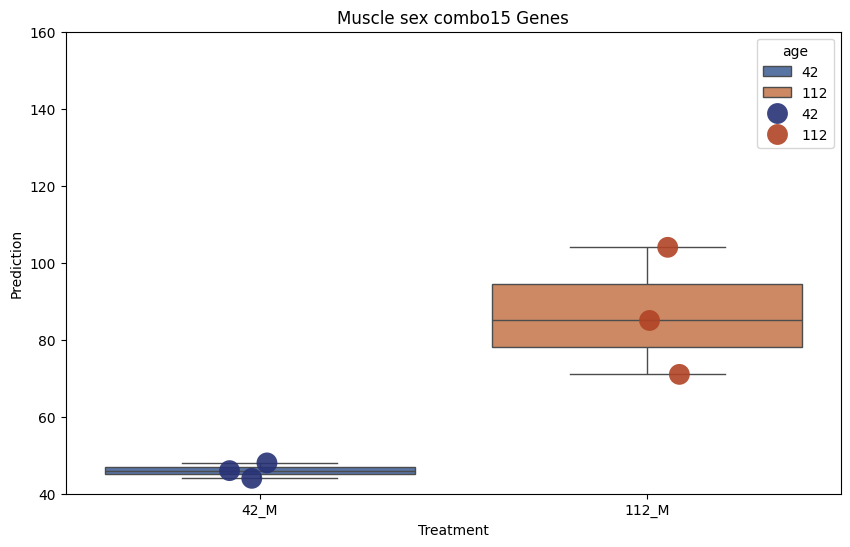

In [ ]:
ordered_x = [
    '42_M','112_M'
]


# Create the box plot
plt.figure(figsize=(10, 6))
box = sns.boxplot(x='age_sex', y='prediction', hue='age', data=df_intervention_test_pred, palette='deep', showfliers = False,
    order = ordered_x)

# Add data points

custom_palette = ['#273276', '#B14325']  # Use desired hex color codes

# Add data points with custom colors
strip = sns.stripplot(
    x='age_sex',
    y='prediction',
    hue='age',
    data=df_intervention_test_pred,
    palette=custom_palette,  # Custom color palette
    dodge=False,
    alpha=0.9,
    jitter=True,
    size=15,
    order = ordered_x
)

# Remove the legend if not needed
#strip.legend_.remove()

# Customize the plot
plt.title("".join([f'{select_tissue} sex combo', str(gene_number), ' Genes']))
plt.xlabel('Treatment')
plt.ylabel('Prediction')

# Set y-axis limits
plt.ylim(40, 160)

# Remove the grid
plt.grid(False)

# Show the plot
plt.show()

##### Try several gene set sizes

In [ ]:
# Set up ordered x-axis for plots
ordered_x = [
    '42_M',
    '112_M'
]

# Custom color palette
custom_palette = ['#273276', '#B14325']

# Directory setup
os.makedirs("./predictions", exist_ok=True)
os.makedirs("./plots", exist_ok=True)

# Dictionary to store prediction DataFrames if needed later
all_predictions = {}

# Loop through gene numbers
for gene_number in range(5, 101, 5):
    print(f"Running prediction for top {gene_number} genes...")

    df_intervention_test_pred = pd.DataFrame(index=df_intervention_test.index, columns=["prediction"])

    for sample in df_intervention_test.index.tolist():
        reference_df = pd.read_csv(f"./{select_tissue}/male/reference/killifish_{select_tissue}_reference_male", sep="\t", index_col=0)
        top_genes = reference_df["spearman_rank"].abs().nlargest(gene_number).index.tolist()

        total_reads_sample = df_intervention_test_counts.loc[sample].sum()
        list_of_profile_probabilities_per_age = []

        for age in new_age_steps:
            log_probs = []
            for gene in top_genes:
                gene_frequency = reference_df.loc[gene, str(age)]
                gene_frequency = max(gene_frequency, 1e-10)  # Ensure >0

                expected = gene_frequency * total_reads_sample
                observed = df_intervention_test_counts.loc[sample, gene]

                poisson_prob = poisson.pmf(k=observed, mu=expected)
                poisson_prob = max(poisson_prob, 0.001)

                log_probs.append(np.log(poisson_prob))

            list_of_profile_probabilities_per_age.append(np.sum(log_probs))

        age_probability_df = pd.DataFrame({"Pr": list_of_profile_probabilities_per_age}, index=new_age_steps)
        max_probability_age = round(float(age_probability_df.idxmax().iloc[0]), 2)
        df_intervention_test_pred.loc[sample, "prediction"] = max_probability_age

    # Add metadata
    df_intervention_test_pred["age"] = df_intervention_test["age"].tolist()
    df_intervention_test_pred["sex"] = df_intervention_test["sex"].tolist()


    df_intervention_test_pred["age_sex"] = (
        df_intervention_test_pred["age"].astype(str) + "_" +
        df_intervention_test_pred["sex"].astype(str)
    )

    # Save predictions
    all_predictions[gene_number] = df_intervention_test_pred.copy()
    df_intervention_test_pred.to_csv(f"./predictions/{select_tissue}_age_maleOnly_preds_top_{gene_number}_genes.tsv", sep="\t")

    # --- Plot ---
    plt.figure(figsize=(10, 6))

    box = sns.boxplot(
        x='age_sex',
        y='prediction',
        hue='age',
        data=df_intervention_test_pred,
        palette='deep',
        showfliers=False,
        order=ordered_x
    )

    strip = sns.stripplot(
        x='age_sex',
        y='prediction',
        hue='age',
        data=df_intervention_test_pred,
        palette=custom_palette,
        dodge=False,
        alpha=0.9,
        jitter=True,
        size=15,
        order=ordered_x
    )

    # Remove duplicate legend
    strip.legend_.remove()

    plt.title(f"{select_tissue}sex combo {gene_number} Genes")
    plt.xlabel('Treatment')
    plt.ylabel('Prediction')
    plt.xticks(rotation=45, ha='right')
    plt.ylim(40, 160)
    plt.grid(False)

    # Save plot
    plt.savefig(f"./plots/xu_{select_tissue}_maleOnly_top_{gene_number}_genes.svg", dpi=300, bbox_inches="tight")
    plt.close()

    print(f"Saved plot and prediction for {gene_number} genes.\n")


Running prediction for top 5 genes...
Saved plot and prediction for 5 genes.

Running prediction for top 10 genes...
Saved plot and prediction for 10 genes.

Running prediction for top 15 genes...
Saved plot and prediction for 15 genes.

Running prediction for top 20 genes...
Saved plot and prediction for 20 genes.

Running prediction for top 25 genes...
Saved plot and prediction for 25 genes.

Running prediction for top 30 genes...
Saved plot and prediction for 30 genes.

Running prediction for top 35 genes...
Saved plot and prediction for 35 genes.

Running prediction for top 40 genes...
Saved plot and prediction for 40 genes.

Running prediction for top 45 genes...
Saved plot and prediction for 45 genes.

Running prediction for top 50 genes...
Saved plot and prediction for 50 genes.

Running prediction for top 55 genes...
Saved plot and prediction for 55 genes.

Running prediction for top 60 genes...
Saved plot and prediction for 60 genes.

Running prediction for top 65 genes...
Sav

##### plot stability of preds

/tmp/ipython-input-302-523614965.py:64: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
/tmp/ipython-input-302-523614965.py:64: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
/tmp/ipython-input-302-523614965.py:64: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
/tmp/ipython-input-302-523614965.py:64: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


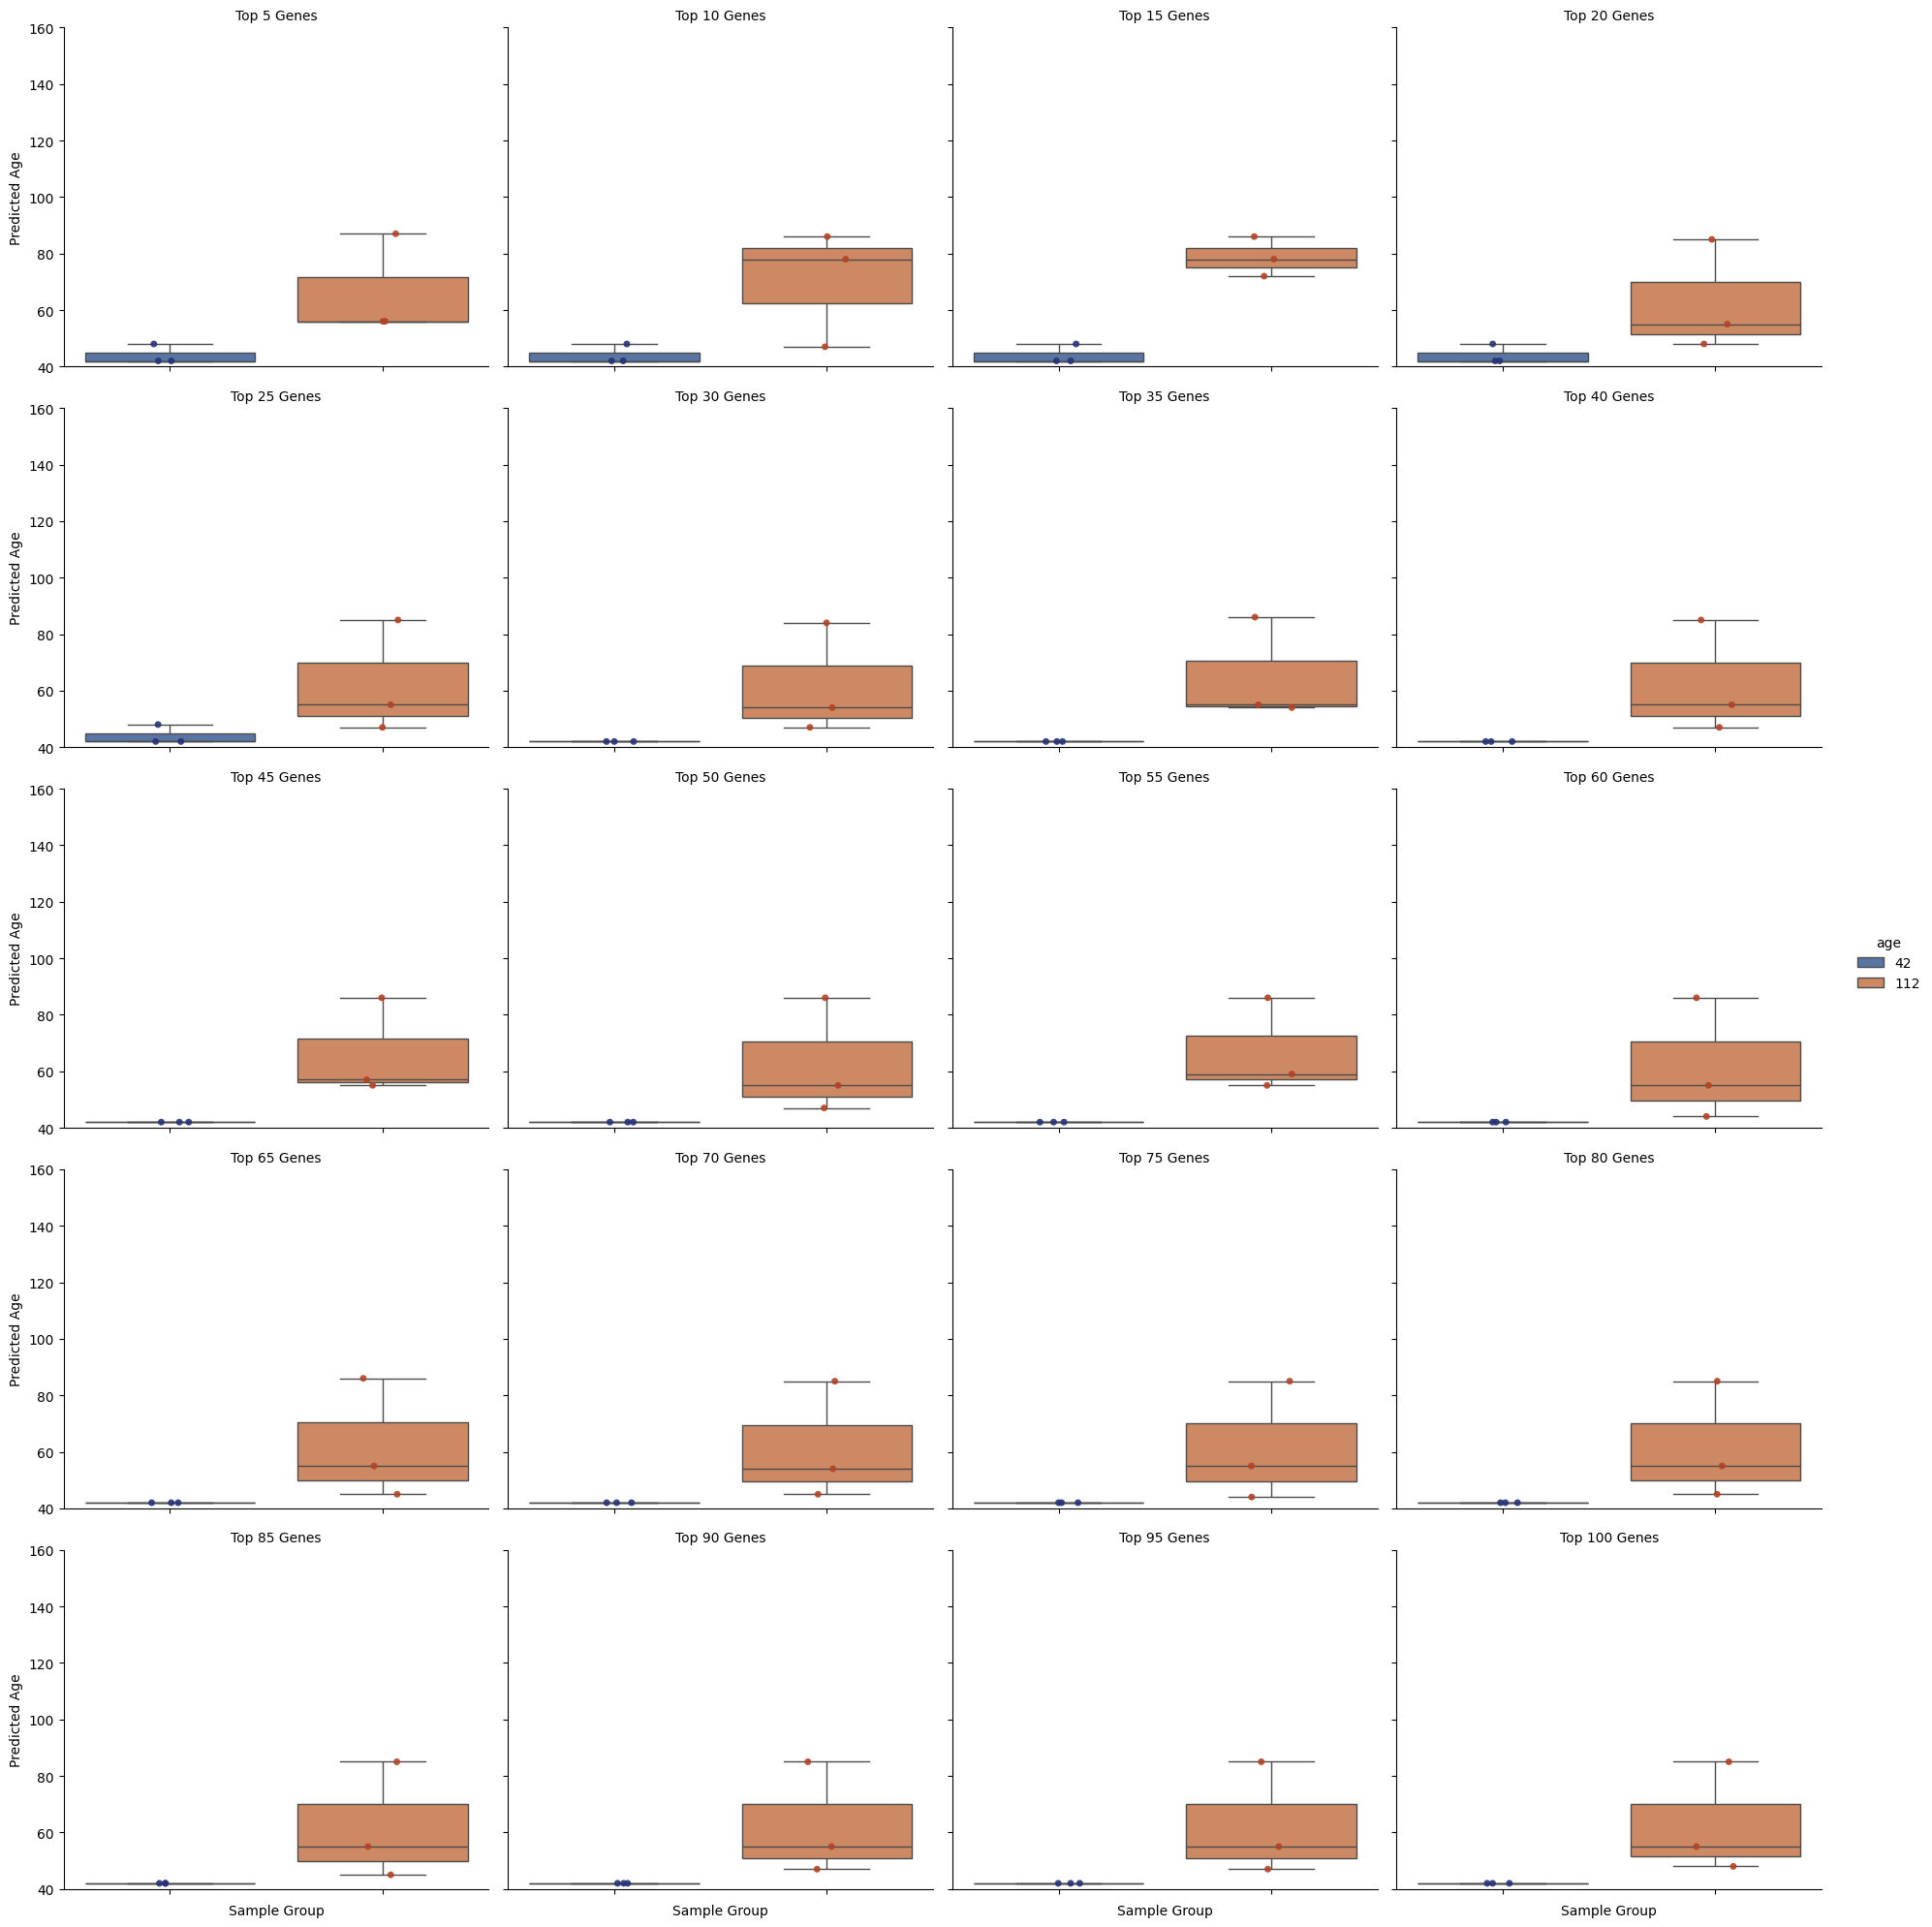

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import os

# Ordered x-axis
ordered_x = [
    '42_M',
    '112_M'
]

# Custom palette
custom_palette = ['#273276', '#B14325']

# Load all prediction files
all_predictions_list = []

for gene_number in range(5, 101, 5):
    file_path = f"./predictions/{select_tissue}_age_maleOnly_preds_top_{gene_number}_genes.tsv"
    if os.path.exists(file_path):
        df = pd.read_csv(file_path, sep="\t", index_col=0)
        df["gene_number"] = str(gene_number)  # for cleaner facet titles
        all_predictions_list.append(df)
    else:
        print(f"Warning: {file_path} not found. Skipping.")

# Concatenate into a single DataFrame
all_predictions_df = pd.concat(all_predictions_list, axis=0)

# Plot with seaborn FacetGrid (catplot)
g = sns.catplot(
    data=all_predictions_df,
    x="age_sex",
    y="prediction",
    hue="age",
    col="gene_number",
    col_wrap=4,
    kind="box",
    palette='deep',
    order=ordered_x,
    height=4,
    aspect=1.2,
    showfliers=False
)

# Overlay stripplot for better visualization
for ax, gene_number in zip(g.axes.flat, all_predictions_df["gene_number"].unique()):
    subset = all_predictions_df[all_predictions_df["gene_number"] == gene_number]
    sns.stripplot(
        x='age_sex',
        y='prediction',
        hue='age',
        data=subset,
        palette=custom_palette,
        dodge=False,
        alpha=0.9,
        jitter=True,
        size=5,
        order=ordered_x,
        ax=ax,
        legend=False
    )
    ax.set_title(f"Top {gene_number} Genes")
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
    ax.set_ylim(40, 160)

g.set_axis_labels("Sample Group", "Predicted Age")
g.set_titles("Top {col_name} Genes")
g.tight_layout()
plt.savefig(f"./plots/{select_tissue}_maleOnly_faceted_predictions_by_gene_number.svg", dpi=300, bbox_inches="tight")
plt.show()


### Female only

In [ ]:
df_intervention_combo.head(2)

,nadsyn1,dnaja3,f2r,LOC107382877,fezf1,srbd1,LOC107373267,LOC107384240,serp1,scarb2,...,umodl1,cryz,LOC107397181,pelo,mrpl35,tissue,AGE,sex,training,age
muscle_19,70,372,8,18,8,32,0,0,64,187,...,54,36,1493,425,42,Muscle,16w,F,No,112
muscle_18,120,422,16,20,4,36,0,0,76,194,...,113,48,1355,547,54,Muscle,16w,F,No,112


In [ ]:
df_intervention_female = df_intervention_combo.loc[
    (df_intervention_combo.iloc[:, -3] == 'F')
]

In [ ]:
all_samples = df_intervention_female.index
all_samples

random.seed(123)

# Separate the samples
young_samples = [s for s in all_samples if s in df_intervention_female.index and df_intervention_female.loc[s, 'age'] == 42]
old_samples = [s for s in all_samples if s in df_intervention_female.index and df_intervention_female.loc[s, 'age'] ==  112]

# Randomly sample 2 from each
random_young = random.sample(young_samples, 2)
random_old = random.sample(old_samples, 2)

# Combine the result
random_subset = random_young + random_old

#select your training samples
select_train_samples = random_subset

# Select rows in df_intervention_age_counts_female where index is in female_samples
df_intervention_train = df_intervention_female.loc[
    df_intervention_female.index.isin(select_train_samples)
]

df_intervention_train

,nadsyn1,dnaja3,f2r,LOC107382877,fezf1,srbd1,LOC107373267,LOC107384240,serp1,scarb2,...,umodl1,cryz,LOC107397181,pelo,mrpl35,tissue,AGE,sex,training,age
muscle_19,70,372,8,18,8,32,0,0,64,187,...,54,36,1493,425,42,Muscle,16w,F,No,112
muscle_16,105,384,20,10,2,21,0,0,62,151,...,66,36,1153,486,52,Muscle,16w,F,No,112
muscle_9,143,447,6,42,0,67,0,0,125,96,...,22,7,1671,540,90,Muscle,6w,F,No,42
muscle_8,86,301,10,8,0,18,0,0,114,102,...,4,20,1403,509,88,Muscle,6w,F,No,42


In [ ]:
# get your testing samples
#all not in select_train_samples
test_samples = [s for s in all_samples if s not in select_train_samples]
test_samples

['muscle_18', 'muscle_17', 'muscle_15', 'muscle_7', 'muscle_6']

In [ ]:
# Select rows in df_intervention_age_counts_female where index is in female_samples
df_intervention_test = df_intervention_female.loc[
    df_intervention_female.index.isin(test_samples)
]

df_intervention_test

,nadsyn1,dnaja3,f2r,LOC107382877,fezf1,srbd1,LOC107373267,LOC107384240,serp1,scarb2,...,umodl1,cryz,LOC107397181,pelo,mrpl35,tissue,AGE,sex,training,age
muscle_18,120,422,16,20,4,36,0,0,76,194,...,113,48,1355,547,54,Muscle,16w,F,No,112
muscle_17,72,341,10,4,0,20,0,0,76,95,...,58,24,961,350,42,Muscle,16w,F,No,112
muscle_15,76,332,12,6,2,30,0,0,88,132,...,46,30,1194,430,82,Muscle,16w,F,No,112
muscle_7,135,504,8,0,0,23,0,0,128,116,...,0,28,1471,504,57,Muscle,6w,F,No,42
muscle_6,75,222,0,10,0,18,0,0,36,74,...,28,2,612,178,10,Muscle,6w,F,No,42


##### transcriptome reference

In [ ]:
# Specify the path for the new directory for the tissue
directory_path = f"./{select_tissue}/female/"

# Create the directory
os.mkdir(directory_path)

In [ ]:
tissue_df_counts.head(1)

,a1cf,aaas,aacs,aadat,aaed1,aagab,aak1,aamdc,aamp,aar2,...,zufsp,zw10,zwilch,zyg11b,zyx,zzef1,zzz3,sex,tissue,age
A13_1,0,192,56,302,204,435,376,1219,322,298,...,40,375,5,547,654,126,147,M,Muscle,134


In [ ]:
#select raw counts
tissue_df_counts = combined_df.loc[
    (combined_df.iloc[:, -2] == select_tissue) &
     (combined_df.iloc[:, -3] == 'F')
]
tissue_df_counts.head(5)

,a1cf,aaas,aacs,aadat,aaed1,aagab,aak1,aamdc,aamp,aar2,...,zufsp,zw10,zwilch,zyg11b,zyx,zzef1,zzz3,sex,tissue,age
A16_1,0,295,51,556,222,578,542,1368,793,459,...,84,376,4,588,765,65,268,F,Muscle,103
B13_1,0,284,55,465,270,571,563,1390,553,447,...,69,385,4,691,966,145,200,F,Muscle,155
B14_1,4,234,113,235,187,455,335,713,401,188,...,38,422,29,394,675,176,165,F,Muscle,77
C15_1,0,165,40,256,116,428,249,667,459,252,...,46,245,10,498,700,129,128,F,Muscle,134
D13_1,43,156,74,336,203,336,378,966,419,269,...,57,323,12,356,687,154,151,F,Muscle,102


In [ ]:
df_intervention_train = df_intervention_train[tissue_df_counts.columns]
df_intervention_train.head(2)

,a1cf,aaas,aacs,aadat,aaed1,aagab,aak1,aamdc,aamp,aar2,...,zufsp,zw10,zwilch,zyg11b,zyx,zzef1,zzz3,sex,tissue,age
muscle_19,4,42,4,76,22,164,186,62,126,32,...,41,70,2,265,196,980,254,F,Muscle,112
muscle_16,0,46,50,80,44,238,155,154,123,64,...,18,146,2,291,98,619,262,F,Muscle,112


In [ ]:
atlas_plus_intervention = pd.concat([tissue_df_counts, df_intervention_train], axis=0)
atlas_plus_intervention.head(3)

,a1cf,aaas,aacs,aadat,aaed1,aagab,aak1,aamdc,aamp,aar2,...,zufsp,zw10,zwilch,zyg11b,zyx,zzef1,zzz3,sex,tissue,age
A16_1,0,295,51,556,222,578,542,1368,793,459,...,84,376,4,588,765,65,268,F,Muscle,103
B13_1,0,284,55,465,270,571,563,1390,553,447,...,69,385,4,691,966,145,200,F,Muscle,155
B14_1,4,234,113,235,187,455,335,713,401,188,...,38,422,29,394,675,176,165,F,Muscle,77


In [ ]:
# #check cols ordered the same
# df_intervention_test = df_intervention_test[tissue_df_counts.columns]
# df_intervention_test.head(2)

In [ ]:
tissue_age_days_value_counts = atlas_plus_intervention["age"].value_counts().index.tolist()

In [ ]:
age_steps = sorted(tissue_age_days_value_counts)

print(age_steps)

[42, 47, 49, 52, 75, 77, 78, 102, 103, 112, 133, 134, 147, 155]


In [ ]:
atlas_plus_intervention_age = atlas_plus_intervention.drop(atlas_plus_intervention.columns[[-2, -3]], axis=1)
atlas_plus_intervention_age.head(2)

,a1cf,aaas,aacs,aadat,aaed1,aagab,aak1,aamdc,aamp,aar2,...,zswim7,zswim8,zufsp,zw10,zwilch,zyg11b,zyx,zzef1,zzz3,age
A16_1,0,295,51,556,222,578,542,1368,793,459,...,24,373,84,376,4,588,765,65,268,103
B13_1,0,284,55,465,270,571,563,1390,553,447,...,46,465,69,385,4,691,966,145,200,155


In [ ]:
#sample generation
for sample in atlas_plus_intervention_age.index.tolist():

    new_df = atlas_plus_intervention_age.drop(sample)

    new_df.to_csv(f"./{select_tissue}/female/{select_tissue}_female_sample_{sample}.csv", sep="\t")

In [ ]:
new_age_steps = np.arange(min(age_steps), max(age_steps)+1, 1)

In [ ]:
# Specify the path for the new directory for the tissue
directory_path = f"./{select_tissue}/female/reference"

# Create the directory
os.mkdir(directory_path)

In [ ]:
transcriptome_reference(training_matrix= atlas_plus_intervention_age,
                            reference_name=f"killifish_{select_tissue}_reference_female",
                            output_path=f"./{select_tissue}/female/reference/",
                            age_prediction="list",
                            age_list=new_age_steps,
                            min_age=1,
                            max_age=24,
                            age_step=1,
                            tau=0.7)

/tmp/ipython-input-10-2002720175.py:41: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho, p = spearmanr(age_training, gene_frequency)



Reference model dataset written to './Muscle/female/reference/killifish_Muscle_reference_female'
Report file generated at './Muscle/female/reference/killifish_Muscle_reference_female.report.txt'
-----------------------------------------------------



Time to run construct reference: 106.259 seconds

The reference is constructed and saved!


,42,43,44,45,46,47,48,49,50,51,...,148,149,150,151,152,153,154,155,spearman_rank,p_value
Gene,,,,,,,,,,,,,,,,,,,,,
a1cf,2.063113e-08,2.087740e-08,2.112084e-08,2.136229e-08,2.160264e-08,2.184277e-08,2.208347e-08,2.232498e-08,2.256722e-08,2.280950e-08,...,9.033172e-09,9.226794e-09,9.423261e-09,9.621940e-09,9.822204e-09,1.002343e-08,1.022502e-08,1.042637e-08,0.053760,0.789993
aaas,5.737301e-06,5.777112e-06,5.816464e-06,5.855388e-06,5.893915e-06,5.932077e-06,5.969903e-06,6.007401e-06,6.044580e-06,6.081464e-06,...,7.817278e-06,7.872112e-06,7.926789e-06,7.981284e-06,8.035577e-06,8.089649e-06,8.143480e-06,8.197052e-06,0.309834,0.115777
aacs,2.109644e-06,2.114341e-06,2.119084e-06,2.123858e-06,2.128650e-06,2.133444e-06,2.138224e-06,2.142966e-06,2.147654e-06,2.152287e-06,...,1.796035e-06,1.788075e-06,1.780170e-06,1.772334e-06,1.764578e-06,1.756913e-06,1.749352e-06,1.741905e-06,-0.175562,0.381077
aadat,9.645350e-06,9.659013e-06,9.673029e-06,9.687328e-06,9.701839e-06,9.716486e-06,9.731197e-06,9.745915e-06,9.760601e-06,9.775286e-06,...,1.268352e-05,1.276325e-05,1.284309e-05,1.292298e-05,1.300285e-05,1.308263e-05,1.316227e-05,1.324171e-05,0.358771,0.066100
aaed1,5.137314e-06,5.192737e-06,5.248268e-06,5.303900e-06,5.359630e-06,5.415450e-06,5.471343e-06,5.527260e-06,5.583139e-06,5.638930e-06,...,6.743058e-06,6.760602e-06,6.778508e-06,6.796788e-06,6.815451e-06,6.834506e-06,6.853962e-06,6.873828e-06,0.180150,0.368556
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
zwilch,6.761840e-07,6.637875e-07,6.514758e-07,6.392404e-07,6.270726e-07,6.149632e-07,6.029026e-07,5.908798e-07,5.788847e-07,5.669134e-07,...,1.269078e-07,1.242058e-07,1.214765e-07,1.187185e-07,1.159305e-07,1.131115e-07,1.102603e-07,1.073761e-07,-0.557052,0.002543
zyg11b,1.404771e-05,1.411742e-05,1.418737e-05,1.425752e-05,1.432781e-05,1.439819e-05,1.446860e-05,1.453894e-05,1.460914e-05,1.467915e-05,...,1.806582e-05,1.801341e-05,1.796018e-05,1.790617e-05,1.785141e-05,1.779593e-05,1.773975e-05,1.768289e-05,0.523629,0.005062
zyx,1.741902e-05,1.763725e-05,1.785444e-05,1.807069e-05,1.828611e-05,1.850083e-05,1.871495e-05,1.892844e-05,1.914129e-05,1.935350e-05,...,2.676437e-05,2.682518e-05,2.688526e-05,2.694451e-05,2.700284e-05,2.706017e-05,2.711642e-05,2.717152e-05,0.259367,0.191406


In [ ]:
df_intervention_test.head(1)

,nadsyn1,dnaja3,f2r,LOC107382877,fezf1,srbd1,LOC107373267,LOC107384240,serp1,scarb2,...,umodl1,cryz,LOC107397181,pelo,mrpl35,tissue,AGE,sex,training,age
muscle_18,120,422,16,20,4,36,0,0,76,194,...,113,48,1355,547,54,Muscle,16w,F,No,112


In [ ]:
df_intervention_test_counts = df_intervention_test.drop(df_intervention_test.columns[[-2, -3,-4, -5]], axis=1)
df_intervention_test_counts.head(3)

,nadsyn1,dnaja3,f2r,LOC107382877,fezf1,srbd1,LOC107373267,LOC107384240,serp1,scarb2,...,plekhg1,LOC107373049,LOC107375201,LOC107384697,umodl1,cryz,LOC107397181,pelo,mrpl35,age
muscle_18,120,422,16,20,4,36,0,0,76,194,...,268,0,4,0,113,48,1355,547,54,112
muscle_17,72,341,10,4,0,20,0,0,76,95,...,216,0,8,0,58,24,961,350,42,112
muscle_15,76,332,12,6,2,30,0,0,88,132,...,224,0,4,0,46,30,1194,430,82,112


In [ ]:
gene_number = 15
df_intervention_test_pred = pd.DataFrame(index=df_intervention_test.index, columns=["prediction"])

for sample in df_intervention_test.index.tolist():

    reference_df = pd.read_csv(f"./{select_tissue}/female/reference/killifish_{select_tissue}_reference_female", sep="\t", index_col=0)

    # Get top genes based on spearman correlation
    top_abs_spearman_corr = reference_df["spearman_rank"].abs().nlargest(gene_number)

    #print(top_abs_spearman_corr)

    top_genes = top_abs_spearman_corr.index.tolist()

    # Save the DataFrame to a CSV file
    # df_top_genes = pd.DataFrame(top_genes, columns=["genes"])
    # gene_num = "".join([str(gene_number), "genes"])
    # out_file_prefix = 'Antebi_male_pred'
    # out_file_name = "_".join([out_file_prefix, gene_num])
    # output_path = './fat/gene_sets'
    # df_top_genes.to_csv(os.path.join(output_path, out_file_name), sep="\t")
    # print(f"List has been written to {out_file_name}")

    total_reads_sample = df_intervention_test_counts.loc[sample].sum()

    list_of_profile_probabilities_per_age = []

    for age in new_age_steps:

        probability_list_one_age = []

        genes_not_defined = []

        for gene in top_genes:

            gene_frequency = reference_df.loc[gene, f"{age}"]

            if gene_frequency < 0:
                gene_frequency = 10**-10

            sample_expected_counts = gene_frequency * total_reads_sample
            sample_observed_counts = df_intervention_test_counts.loc[sample, gene]

            poisson_probability = poisson.pmf(k=sample_observed_counts, mu=sample_expected_counts)

            # Replace NaN poisson probability with a small positive value and log it
            if np.isnan(poisson_probability):
                poisson_probability = 0.001
                genes_not_defined.append(gene)

            # Replace zero poisson probability with 0.001
            if poisson_probability == 0:
                poisson_probability = 0.001

            logP = np.log(poisson_probability)

            probability_list_one_age.append(logP)

        list_of_profile_probabilities_per_age.append(np.sum(probability_list_one_age))

    # Transform into dataframe with age steps
    age_probability_df = pd.DataFrame({"Pr": list_of_profile_probabilities_per_age}, index=new_age_steps)

    # Compute highest likelihood age among age steps
    max_probability_age = round(float(age_probability_df.idxmax().iloc[0]), 2)

    # Compute highest maximum probability
    max_probability = float(age_probability_df["Pr"].max())

    df_intervention_test_pred.loc[sample, "prediction"] = max_probability_age



print(df_intervention_test_pred)

          prediction
muscle_18       91.0
muscle_17       53.0
muscle_15      105.0
muscle_7        50.0
muscle_6        46.0


In [ ]:
df_intervention_test_pred["age"] = df_intervention_test["age"].tolist()
df_intervention_test_pred["sex"] = df_intervention_test["sex"].tolist()


df_intervention_test_pred["age_sex"] = (
    df_intervention_test_pred["age"].astype(str) + "_" +
    df_intervention_test_pred["sex"].astype(str)
)

df_intervention_test_pred

,prediction,age,sex,age_sex
muscle_18,91.0,112,F,112_F
muscle_17,53.0,112,F,112_F
muscle_15,105.0,112,F,112_F
muscle_7,50.0,42,F,42_F
muscle_6,46.0,42,F,42_F


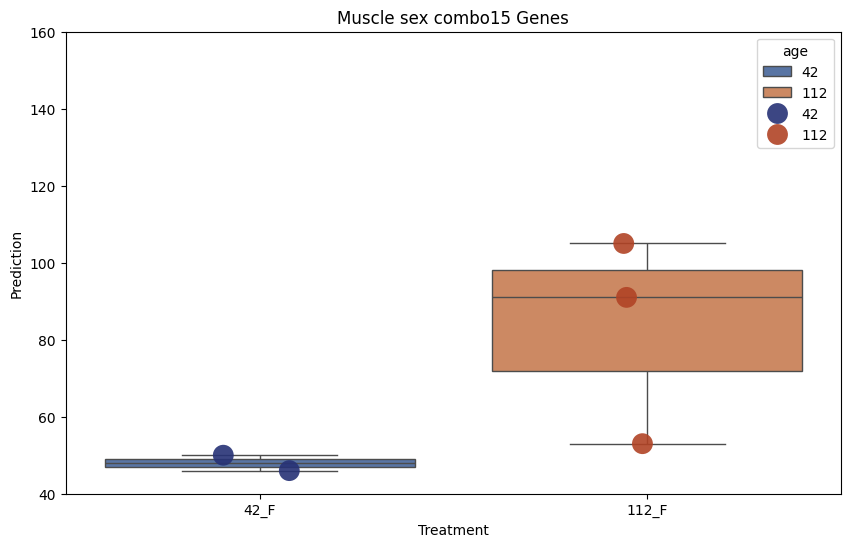

In [ ]:
ordered_x = [
'42_F',
 '112_F'
]


# Create the box plot
plt.figure(figsize=(10, 6))
box = sns.boxplot(x='age_sex', y='prediction', hue='age', data=df_intervention_test_pred, palette='deep', showfliers = False,
    order = ordered_x)

# Add data points

custom_palette = ['#273276', '#B14325']  # Use desired hex color codes

# Add data points with custom colors
strip = sns.stripplot(
    x='age_sex',
    y='prediction',
    hue='age',
    data=df_intervention_test_pred,
    palette=custom_palette,  # Custom color palette
    dodge=False,
    alpha=0.9,
    jitter=True,
    size=15,
    order = ordered_x
)

# Remove the legend if not needed
#strip.legend_.remove()

# Customize the plot
plt.title("".join([f'{select_tissue} sex combo', str(gene_number), ' Genes']))
plt.xlabel('Treatment')
plt.ylabel('Prediction')

# Set y-axis limits
plt.ylim(40, 160)

# Remove the grid
plt.grid(False)


# Show the plot
plt.show()

##### Try several gene set sizes

In [ ]:
# Set up ordered x-axis for plots
ordered_x = [
'42_F',
'112_F'
]

# Custom color palette
custom_palette = ['#273276', '#B14325']

# Directory setup
os.makedirs("./predictions", exist_ok=True)
os.makedirs("./plots", exist_ok=True)

# Dictionary to store prediction DataFrames if needed later
all_predictions = {}

# Loop through gene numbers
for gene_number in range(5, 101, 5):
    print(f"Running prediction for top {gene_number} genes...")

    df_intervention_test_pred = pd.DataFrame(index=df_intervention_test.index, columns=["prediction"])

    for sample in df_intervention_test.index.tolist():
        reference_df = pd.read_csv(f"./{select_tissue}/female/reference/killifish_{select_tissue}_reference_female", sep="\t", index_col=0)
        top_genes = reference_df["spearman_rank"].abs().nlargest(gene_number).index.tolist()

        total_reads_sample = df_intervention_test_counts.loc[sample].sum()
        list_of_profile_probabilities_per_age = []

        for age in new_age_steps:
            log_probs = []
            for gene in top_genes:
                gene_frequency = reference_df.loc[gene, str(age)]
                gene_frequency = max(gene_frequency, 1e-10)  # Ensure >0

                expected = gene_frequency * total_reads_sample
                observed = df_intervention_test_counts.loc[sample, gene]

                poisson_prob = poisson.pmf(k=observed, mu=expected)
                poisson_prob = max(poisson_prob, 0.001)

                log_probs.append(np.log(poisson_prob))

            list_of_profile_probabilities_per_age.append(np.sum(log_probs))

        age_probability_df = pd.DataFrame({"Pr": list_of_profile_probabilities_per_age}, index=new_age_steps)
        max_probability_age = round(float(age_probability_df.idxmax().iloc[0]), 2)
        df_intervention_test_pred.loc[sample, "prediction"] = max_probability_age

    # Add metadata
    df_intervention_test_pred["age"] = df_intervention_test["age"].tolist()
    df_intervention_test_pred["sex"] = df_intervention_test["sex"].tolist()


    df_intervention_test_pred["age_sex"] = (
        df_intervention_test_pred["age"].astype(str) + "_" +
        df_intervention_test_pred["sex"].astype(str)
    )

    # Save predictions
    all_predictions[gene_number] = df_intervention_test_pred.copy()
    df_intervention_test_pred.to_csv(f"./predictions/{select_tissue}_age_femaleOnly_preds_top_{gene_number}_genes.tsv", sep="\t")

    # --- Plot ---
    plt.figure(figsize=(10, 6))

    box = sns.boxplot(
        x='age_sex',
        y='prediction',
        hue='age',
        data=df_intervention_test_pred,
        palette='deep',
        showfliers=False,
        order=ordered_x
    )

    strip = sns.stripplot(
        x='age_sex',
        y='prediction',
        hue='age',
        data=df_intervention_test_pred,
        palette=custom_palette,
        dodge=False,
        alpha=0.9,
        jitter=True,
        size=15,
        order=ordered_x
    )

    # Remove duplicate legend
    strip.legend_.remove()

    plt.title(f"{select_tissue } female {gene_number} Genes")
    plt.xlabel('Treatment')
    plt.ylabel('Prediction')
    plt.xticks(rotation=45, ha='right')
    plt.ylim(40, 160)
    plt.grid(False)

    # Save plot
    plt.savefig(f"./plots/xu_{select_tissue}_female_top_{gene_number}_genes.svg", dpi=300, bbox_inches="tight")
    plt.close()

    print(f"Saved plot and prediction for {gene_number} genes.\n")


Running prediction for top 5 genes...
Saved plot and prediction for 5 genes.

Running prediction for top 10 genes...
Saved plot and prediction for 10 genes.

Running prediction for top 15 genes...
Saved plot and prediction for 15 genes.

Running prediction for top 20 genes...
Saved plot and prediction for 20 genes.

Running prediction for top 25 genes...
Saved plot and prediction for 25 genes.

Running prediction for top 30 genes...
Saved plot and prediction for 30 genes.

Running prediction for top 35 genes...
Saved plot and prediction for 35 genes.

Running prediction for top 40 genes...
Saved plot and prediction for 40 genes.

Running prediction for top 45 genes...
Saved plot and prediction for 45 genes.

Running prediction for top 50 genes...
Saved plot and prediction for 50 genes.

Running prediction for top 55 genes...
Saved plot and prediction for 55 genes.

Running prediction for top 60 genes...
Saved plot and prediction for 60 genes.

Running prediction for top 65 genes...
Sav

##### plot stability of preds

/tmp/ipython-input-327-1805454751.py:64: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
/tmp/ipython-input-327-1805454751.py:64: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
/tmp/ipython-input-327-1805454751.py:64: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
/tmp/ipython-input-327-1805454751.py:64: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


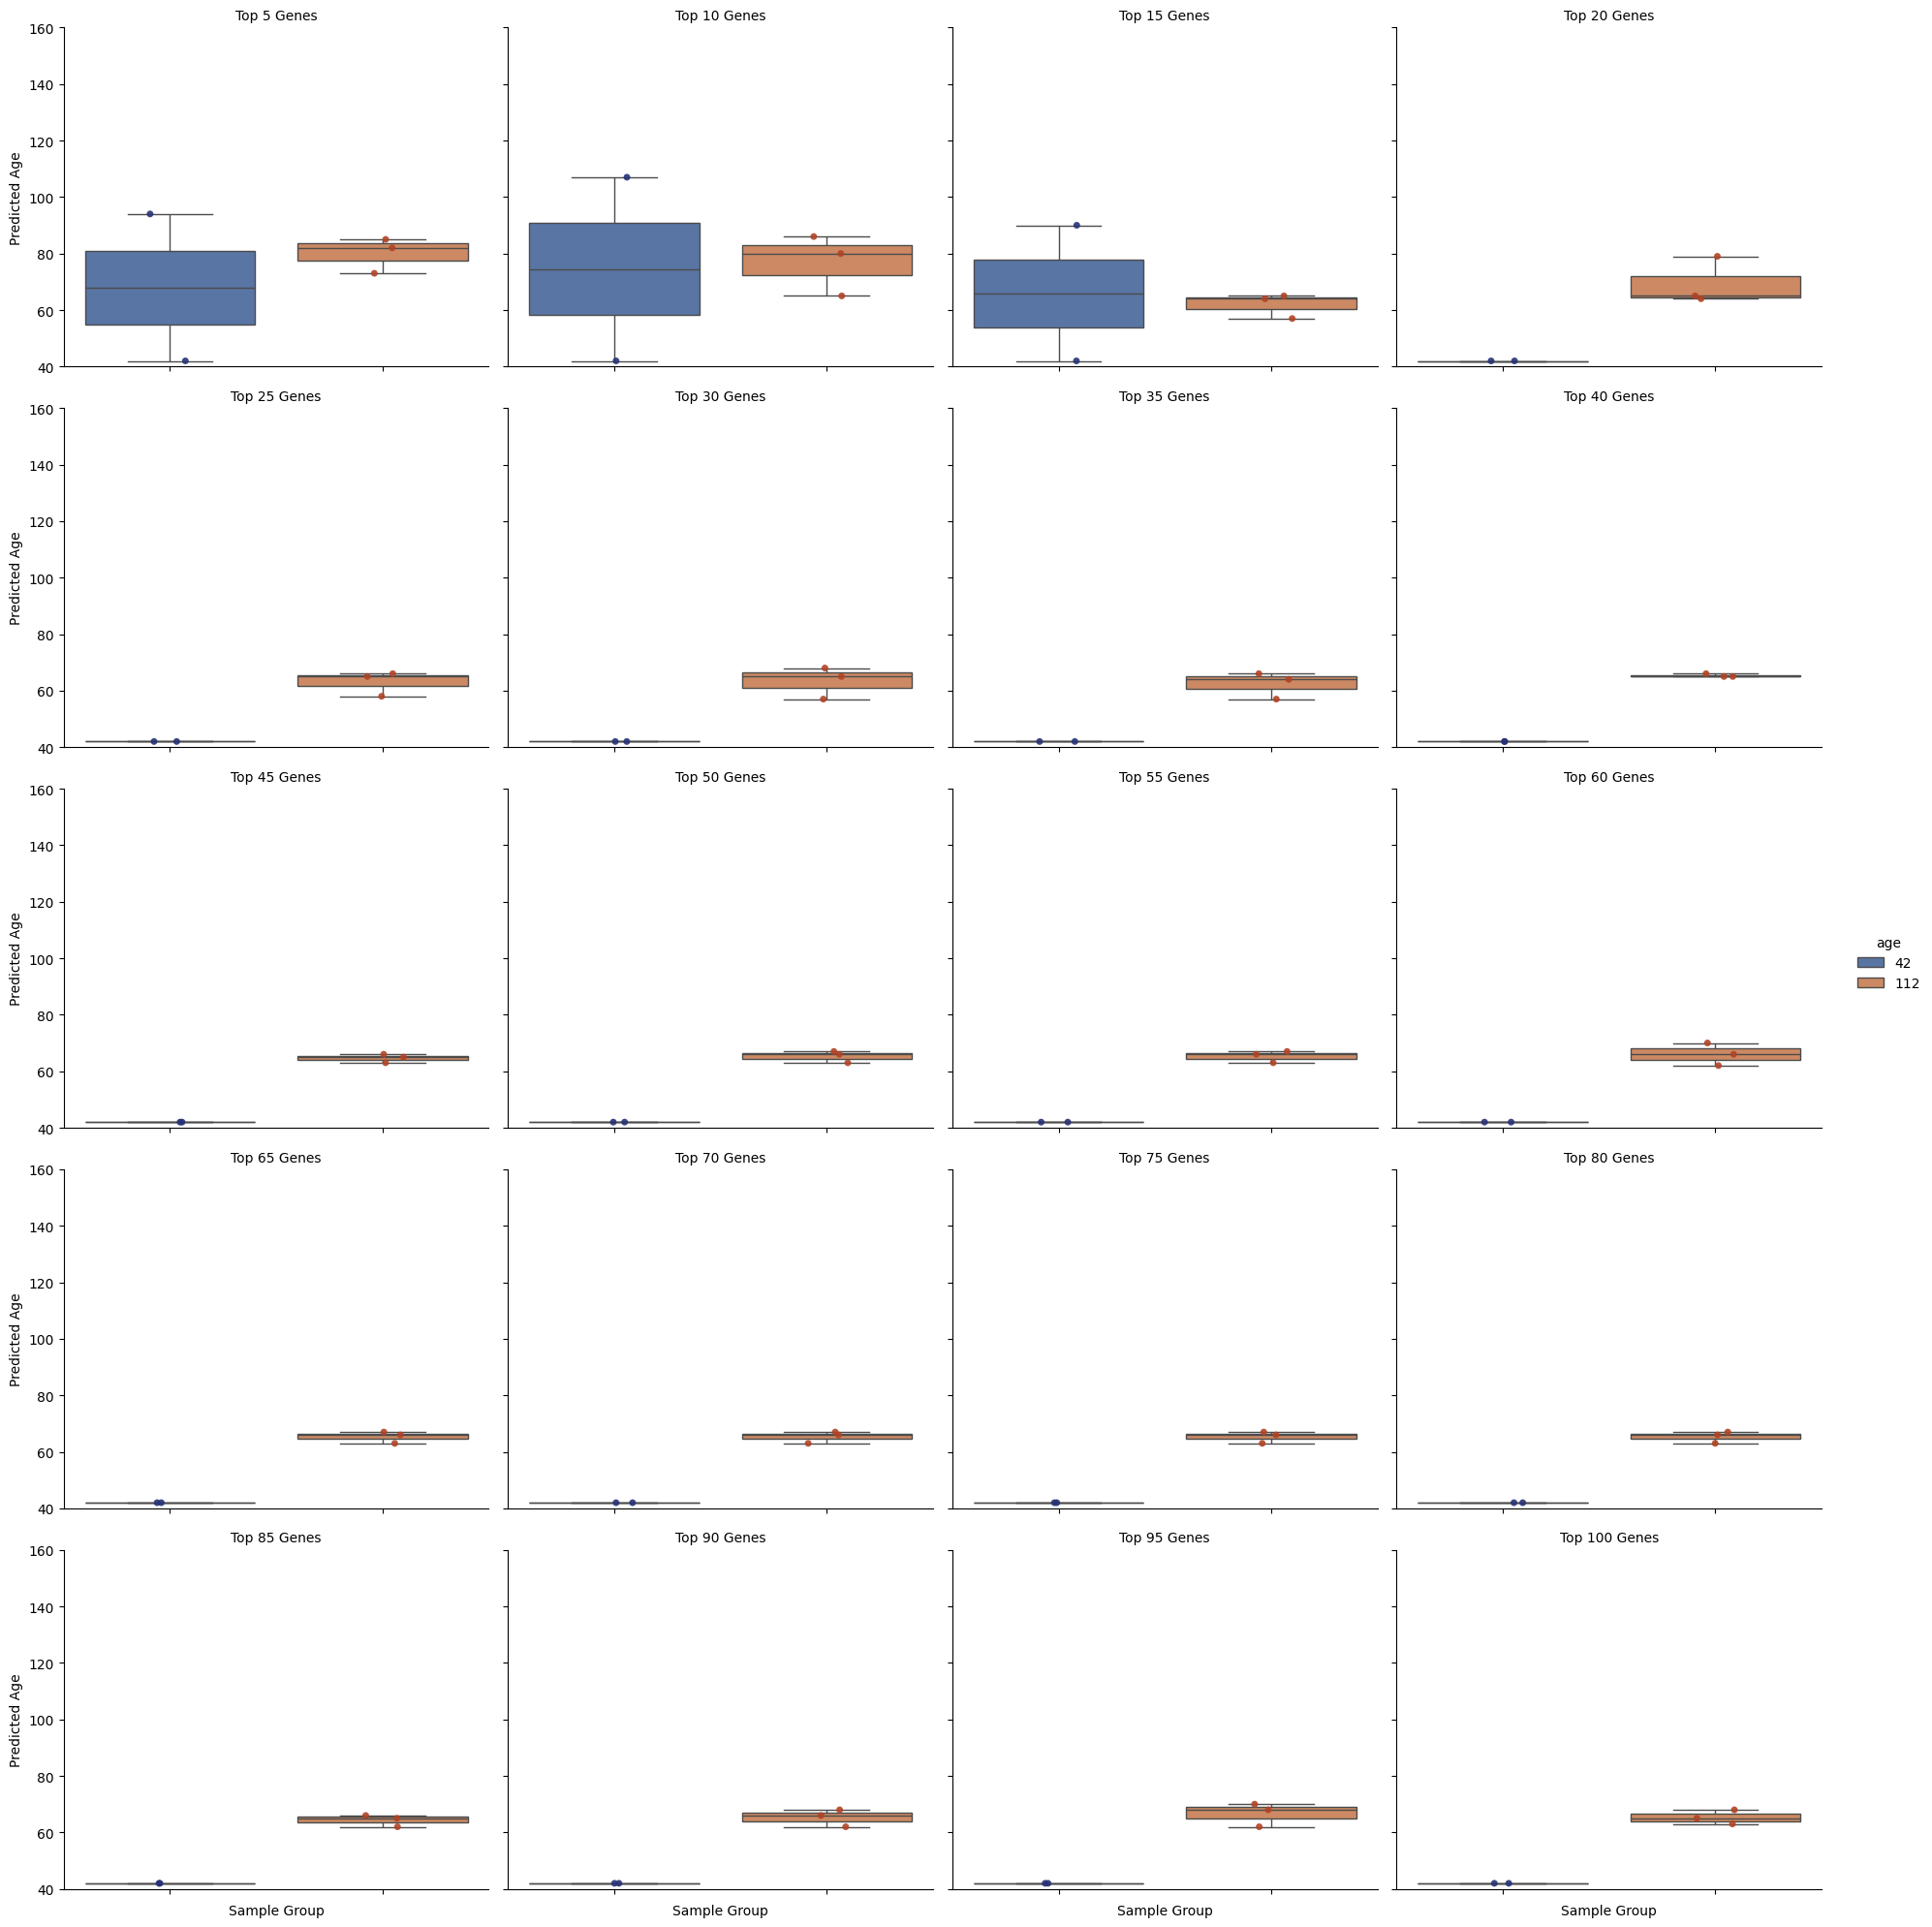

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import os

# Ordered x-axis
ordered_x = [
    '42_F',
'112_F'
]

# Custom palette
custom_palette = ['#273276', '#B14325']

# Load all prediction files
all_predictions_list = []

for gene_number in range(5, 101, 5):
    file_path = f"./predictions/{select_tissue}_age_femaleOnly_preds_top_{gene_number}_genes.tsv"
    if os.path.exists(file_path):
        df = pd.read_csv(file_path, sep="\t", index_col=0)
        df["gene_number"] = str(gene_number)  # for cleaner facet titles
        all_predictions_list.append(df)
    else:
        print(f"Warning: {file_path} not found. Skipping.")

# Concatenate into a single DataFrame
all_predictions_df = pd.concat(all_predictions_list, axis=0)

# Plot with seaborn FacetGrid (catplot)
g = sns.catplot(
    data=all_predictions_df,
    x="age_sex",
    y="prediction",
    hue="age",
    col="gene_number",
    col_wrap=4,
    kind="box",
    palette='deep',
    order=ordered_x,
    height=4,
    aspect=1.2,
    showfliers=False
)

# Overlay stripplot for better visualization
for ax, gene_number in zip(g.axes.flat, all_predictions_df["gene_number"].unique()):
    subset = all_predictions_df[all_predictions_df["gene_number"] == gene_number]
    sns.stripplot(
        x='age_sex',
        y='prediction',
        hue='age',
        data=subset,
        palette=custom_palette,
        dodge=False,
        alpha=0.9,
        jitter=True,
        size=5,
        order=ordered_x,
        ax=ax,
        legend=False
    )
    ax.set_title(f"Top {gene_number} Genes")
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
    ax.set_ylim(40, 160)

g.set_axis_labels("Sample Group", "Predicted Age")
g.set_titles("Top {col_name} Genes")
g.tight_layout()
plt.savefig(f"./plots/{select_tissue}_femaleOnly_faceted_predictions_by_gene_number.svg", dpi=300, bbox_inches="tight")
plt.show()


#Heart

In [ ]:
select_tissue = 'Heart'

### Sex combo

In [ ]:
df_intervention_combo = df_intervention.loc[
    (df_intervention.iloc[:, -5] == select_tissue)
]

In [ ]:
all_samples = df_intervention_combo.index
all_samples

random.seed(123)

# Separate the samples
young_samples = [s for s in all_samples if s in df_intervention_combo.index and df_intervention_combo.loc[s, 'age'] == 42]
old_samples = [s for s in all_samples if s in df_intervention_combo.index and df_intervention_combo.loc[s, 'age'] ==  112]

# Randomly sample 2 from each
random_young = random.sample(young_samples, 2)
random_old = random.sample(old_samples, 2)

# Combine the result
random_subset = random_young + random_old

#select your training samples
select_train_samples = random_subset

# Select rows in df_intervention_age_counts_female where index is in female_samples
df_intervention_train = df_intervention_combo.loc[
    df_intervention_combo.index.isin(select_train_samples)
]

df_intervention_train

,nadsyn1,dnaja3,f2r,LOC107382877,fezf1,srbd1,LOC107373267,LOC107384240,serp1,scarb2,...,umodl1,cryz,LOC107397181,pelo,mrpl35,tissue,AGE,sex,training,age
Heart_19,201,448,153,158,0,72,2,0,298,470,...,6,38,2149,152,100,Heart,16w,F,No,112
Heart_14,185,602,184,136,2,71,0,0,276,574,...,12,46,3706,368,96,Heart,16w,M,No,112
Heart_10,212,426,56,126,0,112,0,0,376,591,...,4,54,2582,372,100,Heart,6w,F,No,42
Heart_6,159,416,30,102,8,66,0,0,272,406,...,14,46,2068,236,72,Heart,6w,F,No,42


In [ ]:
# get your testing samples
#all not in select_train_samples
test_samples = [s for s in all_samples if s not in select_train_samples]
test_samples

['Heart_20',
 'Heart_18',
 'Heart_17',
 'Heart_16',
 'Heart_15',
 'Heart_13',
 'Heart_12',
 'Heart_11',
 'Heart_9',
 'Heart_8',
 'Heart_7',
 'Heart_5',
 'Heart_4',
 'Heart_3',
 'Heart_2',
 'Heart_1']

In [ ]:
# Select rows in df_intervention_age_counts_female where index is in female_samples
df_intervention_test = df_intervention_combo.loc[
    df_intervention_combo.index.isin(test_samples)
]

df_intervention_test.head(2)

,nadsyn1,dnaja3,f2r,LOC107382877,fezf1,srbd1,LOC107373267,LOC107384240,serp1,scarb2,...,umodl1,cryz,LOC107397181,pelo,mrpl35,tissue,AGE,sex,training,age
Heart_20,131,274,111,126,0,79,0,4,156,475,...,4,40,1966,197,60,Heart,16w,F,No,112
Heart_18,187,416,193,192,0,96,0,4,187,567,...,16,42,2441,249,85,Heart,16w,F,No,112


##### transcriptome reference

In [ ]:
# Specify the path for the new directory for the tissue
directory_path = f"./{select_tissue}/"

# Create the directory
os.mkdir(directory_path)

In [ ]:
#select raw counts
tissue_df_counts = combined_df.loc[
    (combined_df.iloc[:, -2] == select_tissue)
]
tissue_df_counts.head(5)

,a1cf,aaas,aacs,aadat,aaed1,aagab,aak1,aamdc,aamp,aar2,...,zufsp,zw10,zwilch,zyg11b,zyx,zzef1,zzz3,sex,tissue,age
A13_2,30,591,227,627,749,896,1293,1167,781,617,...,249,1493,10,965,4511,265,630,M,Heart,162
A14_2,2,695,245,613,499,833,1037,1386,706,646,...,100,1299,28,715,5683,219,444,M,Heart,103
A15_2,0,712,268,539,435,754,1479,1006,732,584,...,180,1690,94,1296,7531,334,454,M,Heart,103
B13_2,16,474,176,394,360,562,739,1450,435,524,...,154,1187,42,666,3405,184,367,M,Heart,134
B14_2,118,985,353,692,816,932,1622,1390,863,928,...,262,2512,167,1303,7114,466,630,M,Heart,47


In [ ]:
df_intervention_train = df_intervention_train[tissue_df_counts.columns]
df_intervention_train.head(2)

,a1cf,aaas,aacs,aadat,aaed1,aagab,aak1,aamdc,aamp,aar2,...,zufsp,zw10,zwilch,zyg11b,zyx,zzef1,zzz3,sex,tissue,age
Heart_19,4,117,80,82,74,228,282,209,138,48,...,18,208,2,363,671,811,598,F,Heart,112
Heart_14,4,113,90,93,56,184,470,146,152,64,...,45,170,13,336,3966,1126,402,M,Heart,112


In [ ]:
atlas_plus_intervention = pd.concat([tissue_df_counts, df_intervention_train], axis=0)
atlas_plus_intervention.head(3)

,a1cf,aaas,aacs,aadat,aaed1,aagab,aak1,aamdc,aamp,aar2,...,zufsp,zw10,zwilch,zyg11b,zyx,zzef1,zzz3,sex,tissue,age
A13_2,30,591,227,627,749,896,1293,1167,781,617,...,249,1493,10,965,4511,265,630,M,Heart,162
A14_2,2,695,245,613,499,833,1037,1386,706,646,...,100,1299,28,715,5683,219,444,M,Heart,103
A15_2,0,712,268,539,435,754,1479,1006,732,584,...,180,1690,94,1296,7531,334,454,M,Heart,103


In [ ]:
# #check cols ordered the same
# df_intervention_test = df_intervention_test[tissue_df_counts.columns]
# df_intervention_test.head(2)

In [ ]:
tissue_age_days_value_counts = atlas_plus_intervention["age"].value_counts().index.tolist()

In [ ]:
age_steps = sorted(tissue_age_days_value_counts)

print(age_steps)

[42, 47, 49, 52, 75, 77, 78, 102, 103, 112, 133, 134, 147, 152, 155, 161, 162]


In [ ]:
atlas_plus_intervention_age = atlas_plus_intervention.drop(atlas_plus_intervention.columns[[-2,-3]], axis=1)
atlas_plus_intervention_age.head(2)

,a1cf,aaas,aacs,aadat,aaed1,aagab,aak1,aamdc,aamp,aar2,...,zswim7,zswim8,zufsp,zw10,zwilch,zyg11b,zyx,zzef1,zzz3,age
A13_2,30,591,227,627,749,896,1293,1167,781,617,...,79,1736,249,1493,10,965,4511,265,630,162
A14_2,2,695,245,613,499,833,1037,1386,706,646,...,104,1456,100,1299,28,715,5683,219,444,103


In [ ]:
#sample generation
for sample in atlas_plus_intervention_age.index.tolist():

    new_df = atlas_plus_intervention_age.drop(sample)

    new_df.to_csv(f"./{select_tissue}/{select_tissue}_sample_{sample}.csv", sep="\t")

In [ ]:
new_age_steps = np.arange(min(age_steps), max(age_steps)+1, 1)

In [ ]:
# Specify the path for the new directory for the tissue
directory_path = f"./{select_tissue}/reference"

# Create the directory
os.mkdir(directory_path)

In [ ]:
transcriptome_reference(training_matrix= atlas_plus_intervention_age,
                            reference_name=f"killifish_{select_tissue}_reference_sexcombo",
                            output_path=f"./{select_tissue}/reference/",
                            age_prediction="list",
                            age_list=new_age_steps,
                            min_age=1,
                            max_age=24,
                            age_step=1,
                            tau=0.7)

/tmp/ipython-input-10-2002720175.py:41: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho, p = spearmanr(age_training, gene_frequency)



Reference model dataset written to './Heart/reference/killifish_Heart_reference_sexcombo'
Report file generated at './Heart/reference/killifish_Heart_reference_sexcombo.report.txt'
-----------------------------------------------------



Time to run construct reference: 111.638 seconds

The reference is constructed and saved!


,42,43,44,45,46,47,48,49,50,51,...,155,156,157,158,159,160,161,162,spearman_rank,p_value
Gene,,,,,,,,,,,,,,,,,,,,,
a1cf,3.883917e-07,3.893619e-07,3.902545e-07,3.910667e-07,3.917959e-07,3.924393e-07,3.929936e-07,3.934544e-07,3.938176e-07,3.940800e-07,...,4.080762e-07,4.151472e-07,4.222770e-07,4.294752e-07,4.367512e-07,4.441140e-07,4.515725e-07,4.591356e-07,-0.025947,0.846694
aaas,2.811615e-05,2.802470e-05,2.793267e-05,2.784009e-05,2.774700e-05,2.765343e-05,2.755942e-05,2.746508e-05,2.737050e-05,2.727577e-05,...,2.079880e-05,2.077760e-05,2.075617e-05,2.073450e-05,2.071257e-05,2.069038e-05,2.066791e-05,2.064517e-05,-0.427837,0.000808
aacs,1.003908e-05,1.001093e-05,9.982652e-06,9.954231e-06,9.925662e-06,9.896936e-06,9.868047e-06,9.839003e-06,9.809811e-06,9.780482e-06,...,7.509946e-06,7.517343e-06,7.525200e-06,7.533537e-06,7.542376e-06,7.551735e-06,7.561633e-06,7.572085e-06,-0.489212,0.000097
aadat,1.778859e-05,1.779506e-05,1.780148e-05,1.780789e-05,1.781432e-05,1.782081e-05,1.782739e-05,1.783410e-05,1.784096e-05,1.784797e-05,...,1.809712e-05,1.810119e-05,1.810548e-05,1.811003e-05,1.811483e-05,1.811991e-05,1.812526e-05,1.813091e-05,0.055795,0.677410
aaed1,2.333798e-05,2.325749e-05,2.317686e-05,2.309611e-05,2.301524e-05,2.293427e-05,2.285322e-05,2.277212e-05,2.269100e-05,2.260985e-05,...,1.851838e-05,1.852827e-05,1.853824e-05,1.854829e-05,1.855844e-05,1.856869e-05,1.857905e-05,1.858953e-05,-0.323891,0.013129
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
zwilch,4.329243e-06,4.284369e-06,4.239340e-06,4.194177e-06,4.148901e-06,4.103536e-06,4.058108e-06,4.012661e-06,3.967238e-06,3.921880e-06,...,1.139952e-06,1.136412e-06,1.132989e-06,1.129689e-06,1.126517e-06,1.123479e-06,1.120581e-06,1.117830e-06,-0.547998,0.000008
zyg11b,2.920360e-05,2.919348e-05,2.918395e-05,2.917497e-05,2.916654e-05,2.915863e-05,2.915123e-05,2.914431e-05,2.913786e-05,2.913185e-05,...,2.797182e-05,2.793151e-05,2.789141e-05,2.785157e-05,2.781205e-05,2.777291e-05,2.773419e-05,2.769596e-05,-0.069328,0.605075
zyx,1.764642e-04,1.770304e-04,1.776020e-04,1.781793e-04,1.787623e-04,1.793511e-04,1.799460e-04,1.805466e-04,1.811529e-04,1.817645e-04,...,1.852814e-04,1.848739e-04,1.844745e-04,1.840823e-04,1.836966e-04,1.833165e-04,1.829414e-04,1.825705e-04,0.081813,0.541512


In [ ]:
df_intervention_test.head(1)

,nadsyn1,dnaja3,f2r,LOC107382877,fezf1,srbd1,LOC107373267,LOC107384240,serp1,scarb2,...,umodl1,cryz,LOC107397181,pelo,mrpl35,tissue,AGE,sex,training,age
Heart_20,131,274,111,126,0,79,0,4,156,475,...,4,40,1966,197,60,Heart,16w,F,No,112


In [ ]:
df_intervention_test_counts = df_intervention_test.drop(df_intervention_test.columns[[-2, -3,-4, -5]], axis=1)
df_intervention_test_counts.head(3)

,nadsyn1,dnaja3,f2r,LOC107382877,fezf1,srbd1,LOC107373267,LOC107384240,serp1,scarb2,...,plekhg1,LOC107373049,LOC107375201,LOC107384697,umodl1,cryz,LOC107397181,pelo,mrpl35,age
Heart_20,131,274,111,126,0,79,0,4,156,475,...,1002,0,2,4,4,40,1966,197,60,112
Heart_18,187,416,193,192,0,96,0,4,187,567,...,1230,0,0,0,16,42,2441,249,85,112
Heart_17,159,334,86,118,0,90,0,0,340,473,...,974,0,0,6,6,34,1734,166,88,112


In [ ]:
gene_number = 15
df_intervention_test_pred = pd.DataFrame(index=df_intervention_test.index, columns=["prediction"])

for sample in df_intervention_test.index.tolist():

    reference_df = pd.read_csv(f"./{select_tissue}/reference/killifish_{select_tissue}_reference_sexcombo", sep="\t", index_col=0)

    # Get top genes based on spearman correlation
    top_abs_spearman_corr = reference_df["spearman_rank"].abs().nlargest(gene_number)

    #print(top_abs_spearman_corr)

    top_genes = top_abs_spearman_corr.index.tolist()

    # Save the DataFrame to a CSV file
    # df_top_genes = pd.DataFrame(top_genes, columns=["genes"])
    # gene_num = "".join([str(gene_number), "genes"])
    # out_file_prefix = 'Antebi_male_pred'
    # out_file_name = "_".join([out_file_prefix, gene_num])
    # output_path = './fat/gene_sets'
    # df_top_genes.to_csv(os.path.join(output_path, out_file_name), sep="\t")
    # print(f"List has been written to {out_file_name}")

    total_reads_sample = df_intervention_test_counts.loc[sample].sum()

    list_of_profile_probabilities_per_age = []

    for age in new_age_steps:

        probability_list_one_age = []

        genes_not_defined = []

        for gene in top_genes:

            gene_frequency = reference_df.loc[gene, f"{age}"]

            if gene_frequency < 0:
                gene_frequency = 10**-10

            sample_expected_counts = gene_frequency * total_reads_sample
            sample_observed_counts = df_intervention_test_counts.loc[sample, gene]

            poisson_probability = poisson.pmf(k=sample_observed_counts, mu=sample_expected_counts)

            # Replace NaN poisson probability with a small positive value and log it
            if np.isnan(poisson_probability):
                poisson_probability = 0.001
                genes_not_defined.append(gene)

            # Replace zero poisson probability with 0.001
            if poisson_probability == 0:
                poisson_probability = 0.001

            logP = np.log(poisson_probability)

            probability_list_one_age.append(logP)

        list_of_profile_probabilities_per_age.append(np.sum(probability_list_one_age))

    # Transform into dataframe with age steps
    age_probability_df = pd.DataFrame({"Pr": list_of_profile_probabilities_per_age}, index=new_age_steps)

    # Compute highest likelihood age among age steps
    max_probability_age = round(float(age_probability_df.idxmax().iloc[0]), 2)

    # Compute highest maximum probability
    max_probability = float(age_probability_df["Pr"].max())

    df_intervention_test_pred.loc[sample, "prediction"] = max_probability_age



print(df_intervention_test_pred)

         prediction
Heart_20       78.0
Heart_18       68.0
Heart_17       69.0
Heart_16       80.0
Heart_15       92.0
Heart_13       62.0
Heart_12       92.0
Heart_11      117.0
Heart_9        42.0
Heart_8        42.0
Heart_7        45.0
Heart_5        42.0
Heart_4        42.0
Heart_3        42.0
Heart_2        42.0
Heart_1        42.0


In [ ]:
df_intervention_test_pred["age"] = df_intervention_test["age"].tolist()
df_intervention_test_pred["sex"] = df_intervention_test["sex"].tolist()


df_intervention_test_pred["age_sex"] = (
    df_intervention_test_pred["age"].astype(str) + "_" +
    df_intervention_test_pred["sex"].astype(str)
)

df_intervention_test_pred

,prediction,age,sex,age_sex
Heart_20,78.0,112,F,112_F
Heart_18,68.0,112,F,112_F
Heart_17,69.0,112,F,112_F
Heart_16,80.0,112,F,112_F
Heart_15,92.0,112,M,112_M
Heart_13,62.0,112,M,112_M
Heart_12,92.0,112,M,112_M
Heart_11,117.0,112,M,112_M
Heart_9,42.0,42,F,42_F
Heart_8,42.0,42,F,42_F


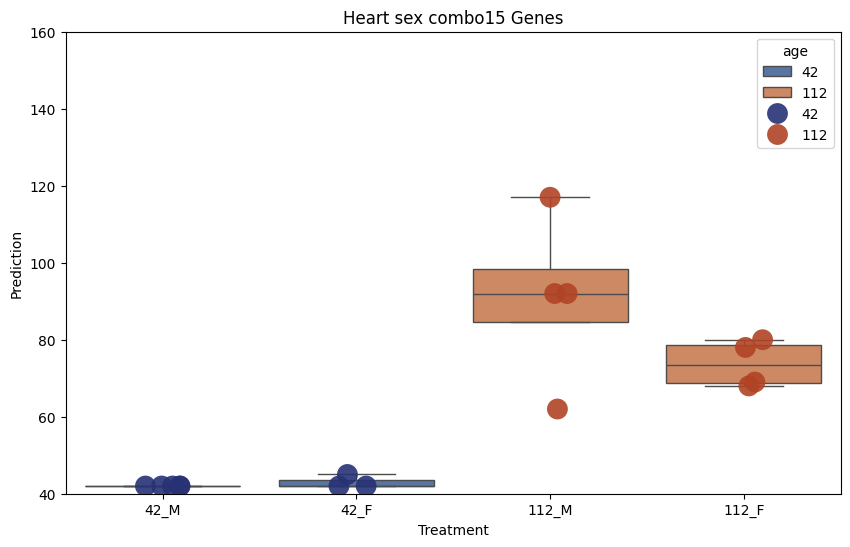

In [ ]:
ordered_x = [
    '42_M', '42_F',
    '112_M', '112_F'
]


# Create the box plot
plt.figure(figsize=(10, 6))
box = sns.boxplot(x='age_sex', y='prediction', hue='age', data=df_intervention_test_pred, palette='deep', showfliers = False,
    order = ordered_x)

# Add data points

custom_palette = ['#273276', '#B14325']  # Use desired hex color codes

# Add data points with custom colors
strip = sns.stripplot(
    x='age_sex',
    y='prediction',
    hue='age',
    data=df_intervention_test_pred,
    palette=custom_palette,  # Custom color palette
    dodge=False,
    alpha=0.9,
    jitter=True,
    size=15,
    order = ordered_x
)

# Remove the legend if not needed
#strip.legend_.remove()

# Customize the plot
plt.title("".join([f'{select_tissue} sex combo', str(gene_number), ' Genes']))
plt.xlabel('Treatment')
plt.ylabel('Prediction')

# Set y-axis limits
plt.ylim(40, 160)

# Remove the grid
plt.grid(False)

# Show the plot
plt.show()

##### Try several gene set sizes

In [ ]:
# Set up ordered x-axis for plots
ordered_x = [
    '42_M', '42_F',
    '112_M', '112_F'
]

# Custom color palette
custom_palette = ['#273276', '#B14325']

# Directory setup
os.makedirs("./predictions", exist_ok=True)
os.makedirs("./plots", exist_ok=True)

# Dictionary to store prediction DataFrames if needed later
all_predictions = {}

# Loop through gene numbers
for gene_number in range(5, 101, 5):
    print(f"Running prediction for top {gene_number} genes...")

    df_intervention_test_pred = pd.DataFrame(index=df_intervention_test.index, columns=["prediction"])

    for sample in df_intervention_test.index.tolist():
        reference_df = pd.read_csv(f"./{select_tissue}/reference/killifish_{select_tissue}_reference_sexcombo", sep="\t", index_col=0)
        top_genes = reference_df["spearman_rank"].abs().nlargest(gene_number).index.tolist()

        total_reads_sample = df_intervention_test_counts.loc[sample].sum()
        list_of_profile_probabilities_per_age = []

        for age in new_age_steps:
            log_probs = []
            for gene in top_genes:
                gene_frequency = reference_df.loc[gene, str(age)]
                gene_frequency = max(gene_frequency, 1e-10)  # Ensure >0

                expected = gene_frequency * total_reads_sample
                observed = df_intervention_test_counts.loc[sample, gene]

                poisson_prob = poisson.pmf(k=observed, mu=expected)
                poisson_prob = max(poisson_prob, 0.001)

                log_probs.append(np.log(poisson_prob))

            list_of_profile_probabilities_per_age.append(np.sum(log_probs))

        age_probability_df = pd.DataFrame({"Pr": list_of_profile_probabilities_per_age}, index=new_age_steps)
        max_probability_age = round(float(age_probability_df.idxmax().iloc[0]), 2)
        df_intervention_test_pred.loc[sample, "prediction"] = max_probability_age

    # Add metadata
    df_intervention_test_pred["age"] = df_intervention_test["age"].tolist()
    df_intervention_test_pred["sex"] = df_intervention_test["sex"].tolist()


    df_intervention_test_pred["age_sex"] = (
        df_intervention_test_pred["age"].astype(str) + "_" +
        df_intervention_test_pred["sex"].astype(str)
    )

    # Save predictions
    all_predictions[gene_number] = df_intervention_test_pred.copy()
    df_intervention_test_pred.to_csv(f"./predictions/{select_tissue}_sexcombo_age_preds_top_{gene_number}_genes.tsv", sep="\t")

    # --- Plot ---
    plt.figure(figsize=(10, 6))

    box = sns.boxplot(
        x='age_sex',
        y='prediction',
        hue='age',
        data=df_intervention_test_pred,
        palette='deep',
        showfliers=False,
        order=ordered_x
    )

    strip = sns.stripplot(
        x='age_sex',
        y='prediction',
        hue='age',
        data=df_intervention_test_pred,
        palette=custom_palette,
        dodge=False,
        alpha=0.9,
        jitter=True,
        size=15,
        order=ordered_x
    )

    # Remove duplicate legend
    strip.legend_.remove()

    plt.title(f"Brain sex combo {gene_number} Genes")
    plt.xlabel('Treatment')
    plt.ylabel('Prediction')
    plt.xticks(rotation=45, ha='right')
    plt.ylim(40, 160)
    plt.grid(False)

    # Save plot
    plt.savefig(f"./plots/xu_{select_tissue}_sexcombo_top_{gene_number}_genes.svg", dpi=300, bbox_inches="tight")
    plt.close()

    print(f"Saved plot and prediction for {gene_number} genes.\n")


Running prediction for top 5 genes...
Saved plot and prediction for 5 genes.

Running prediction for top 10 genes...
Saved plot and prediction for 10 genes.

Running prediction for top 15 genes...
Saved plot and prediction for 15 genes.

Running prediction for top 20 genes...
Saved plot and prediction for 20 genes.

Running prediction for top 25 genes...
Saved plot and prediction for 25 genes.

Running prediction for top 30 genes...
Saved plot and prediction for 30 genes.

Running prediction for top 35 genes...
Saved plot and prediction for 35 genes.

Running prediction for top 40 genes...
Saved plot and prediction for 40 genes.

Running prediction for top 45 genes...
Saved plot and prediction for 45 genes.

Running prediction for top 50 genes...
Saved plot and prediction for 50 genes.

Running prediction for top 55 genes...
Saved plot and prediction for 55 genes.

Running prediction for top 60 genes...
Saved plot and prediction for 60 genes.

Running prediction for top 65 genes...
Sav

##### plot stability of preds

/tmp/ipython-input-351-3290434677.py:64: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
/tmp/ipython-input-351-3290434677.py:64: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
/tmp/ipython-input-351-3290434677.py:64: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
/tmp/ipython-input-351-3290434677.py:64: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


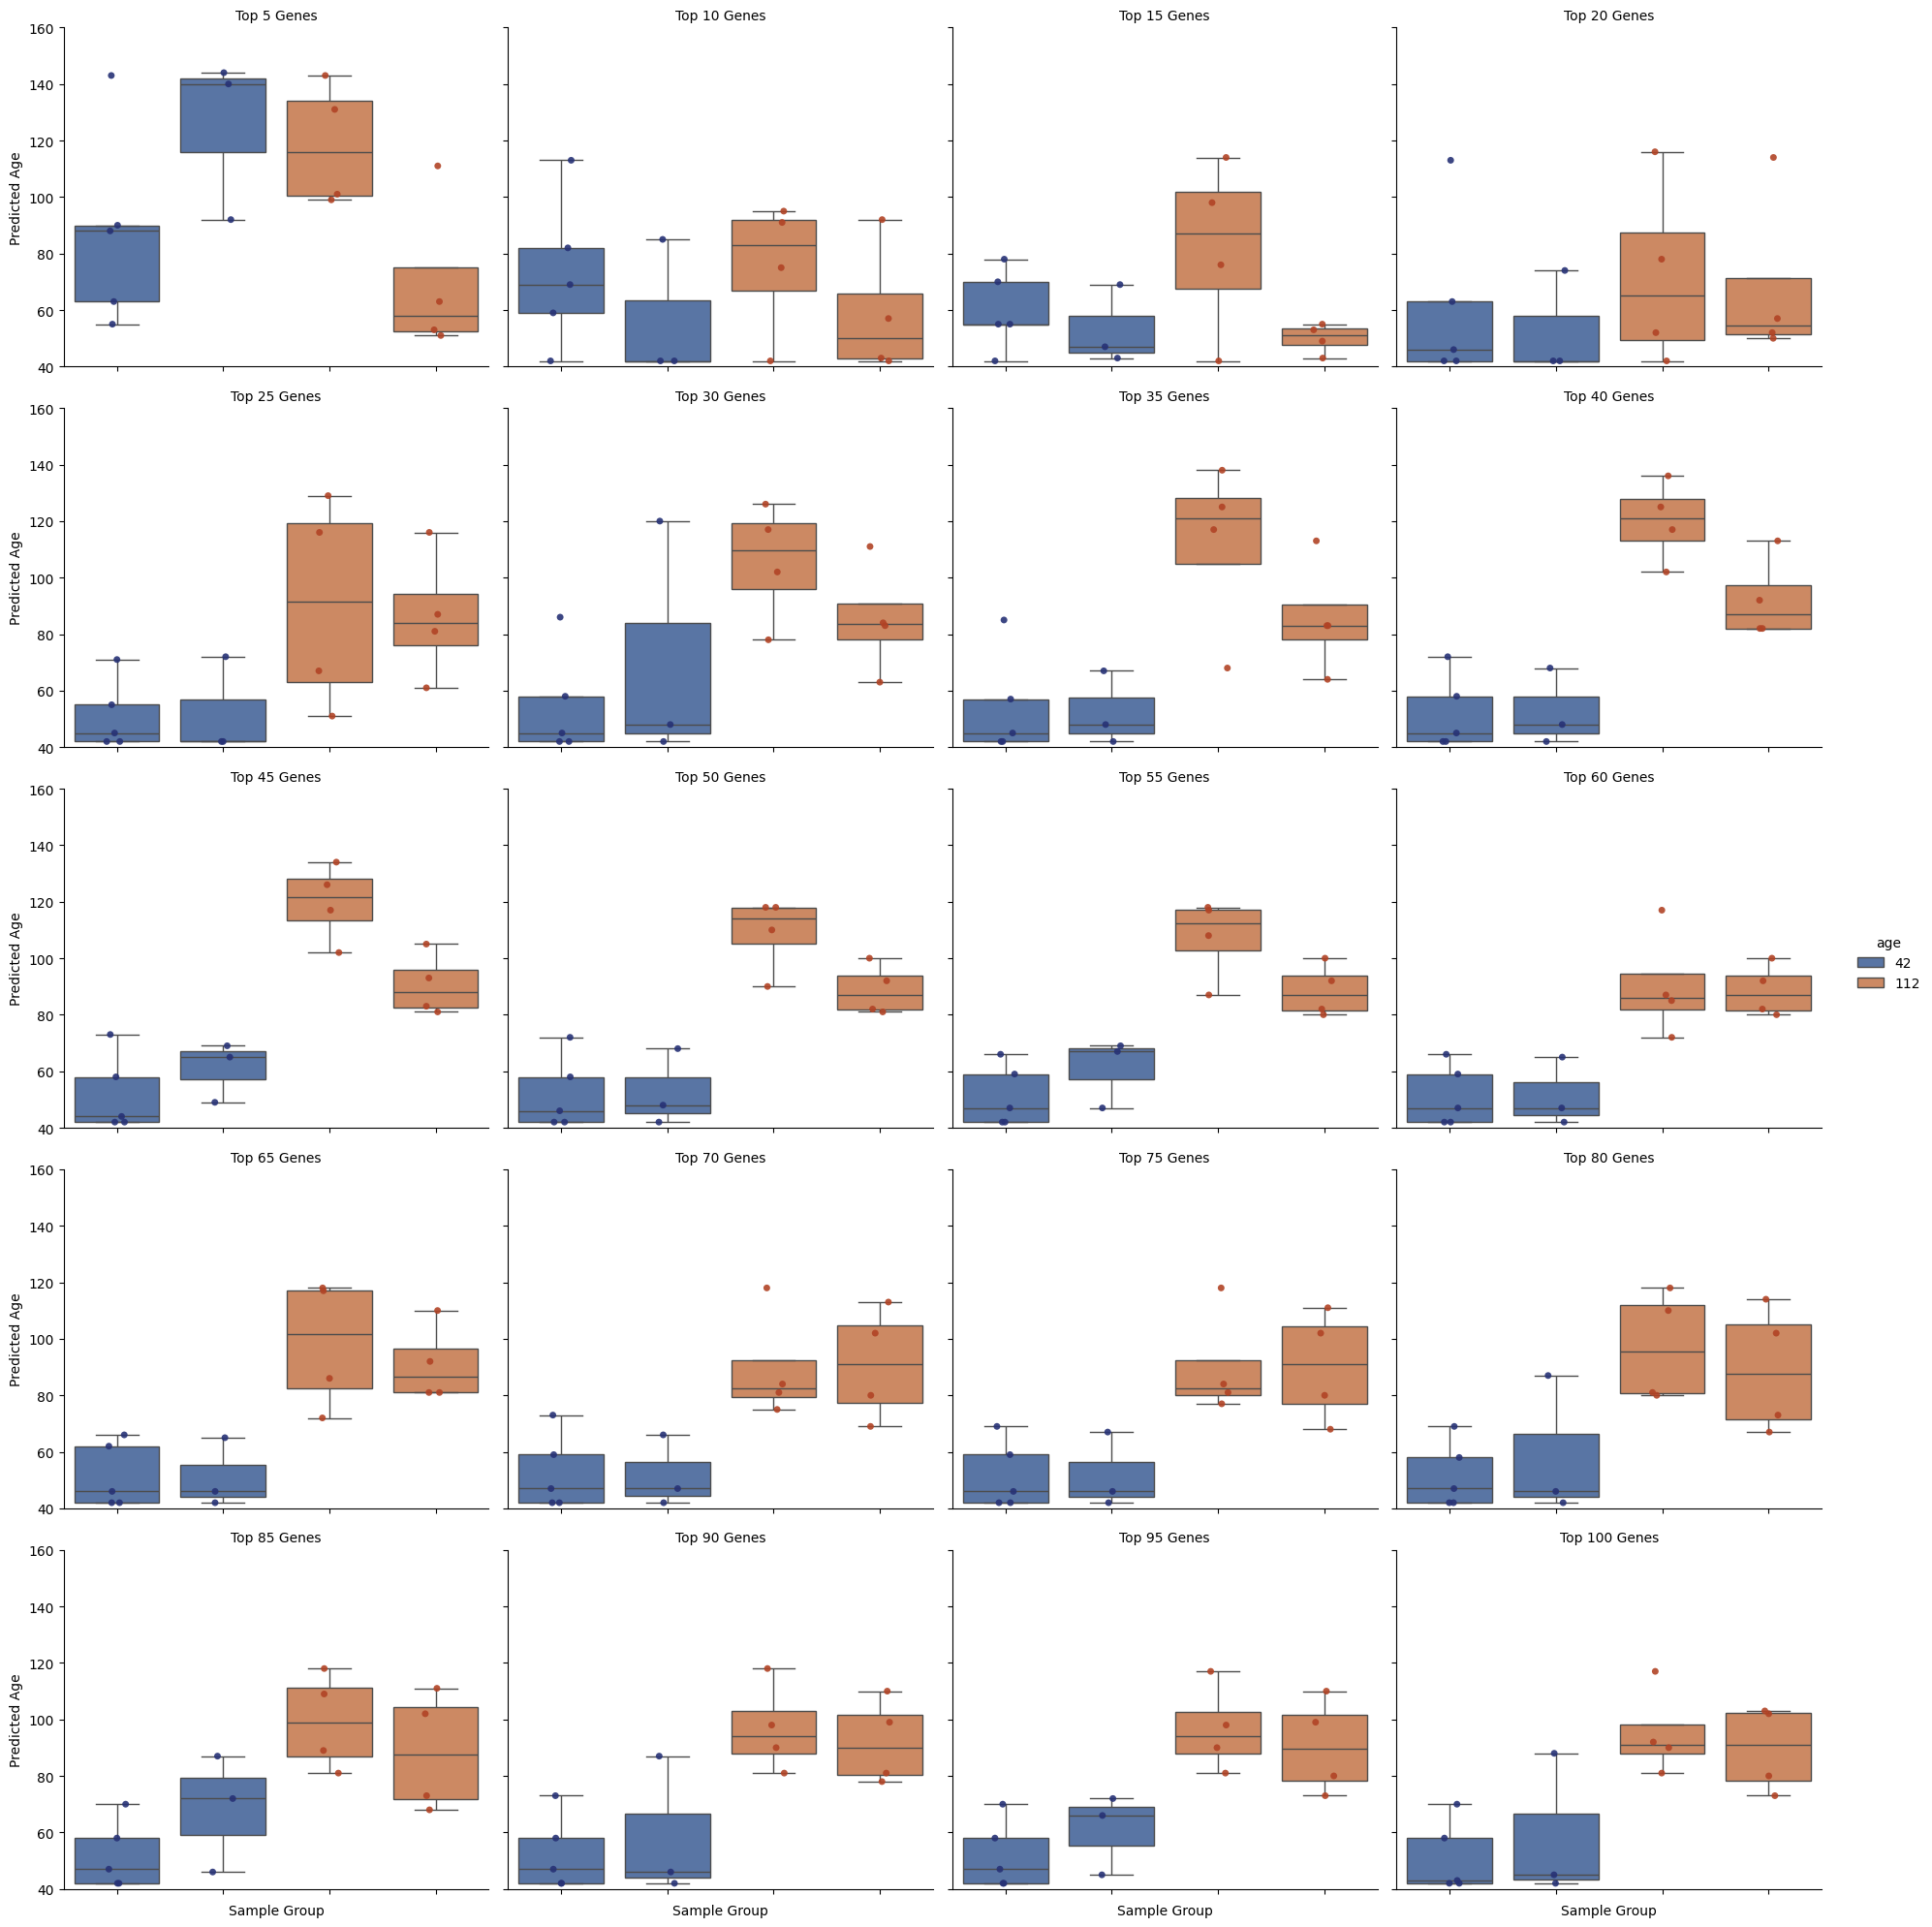

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import os

# Ordered x-axis
ordered_x = [
    '42_M', '42_F',
    '112_M', '112_F'
]

# Custom palette
custom_palette = ['#273276', '#B14325']

# Load all prediction files
all_predictions_list = []

for gene_number in range(5, 101, 5):
    file_path = f"./predictions/{select_tissue}_sexcombo_age_preds_top_{gene_number}_genes.tsv"
    if os.path.exists(file_path):
        df = pd.read_csv(file_path, sep="\t", index_col=0)
        df["gene_number"] = str(gene_number)  # for cleaner facet titles
        all_predictions_list.append(df)
    else:
        print(f"Warning: {file_path} not found. Skipping.")

# Concatenate into a single DataFrame
all_predictions_df = pd.concat(all_predictions_list, axis=0)

# Plot with seaborn FacetGrid (catplot)
g = sns.catplot(
    data=all_predictions_df,
    x="age_sex",
    y="prediction",
    hue="age",
    col="gene_number",
    col_wrap=4,
    kind="box",
    palette='deep',
    order=ordered_x,
    height=4,
    aspect=1.2,
    showfliers=False
)

# Overlay stripplot for better visualization
for ax, gene_number in zip(g.axes.flat, all_predictions_df["gene_number"].unique()):
    subset = all_predictions_df[all_predictions_df["gene_number"] == gene_number]
    sns.stripplot(
        x='age_sex',
        y='prediction',
        hue='age',
        data=subset,
        palette=custom_palette,
        dodge=False,
        alpha=0.9,
        jitter=True,
        size=5,
        order=ordered_x,
        ax=ax,
        legend=False
    )
    ax.set_title(f"Top {gene_number} Genes")
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
    ax.set_ylim(40, 160)

g.set_axis_labels("Sample Group", "Predicted Age")
g.set_titles("Top {col_name} Genes")
g.tight_layout()
plt.savefig(f"./plots/{select_tissue}_sex_combo_faceted_predictions_by_gene_number.svg", dpi=300, bbox_inches="tight")
plt.show()


### Male only

In [ ]:
df_intervention_combo.head(2)

,nadsyn1,dnaja3,f2r,LOC107382877,fezf1,srbd1,LOC107373267,LOC107384240,serp1,scarb2,...,umodl1,cryz,LOC107397181,pelo,mrpl35,tissue,AGE,sex,training,age
Heart_20,131,274,111,126,0,79,0,4,156,475,...,4,40,1966,197,60,Heart,16w,F,No,112
Heart_19,201,448,153,158,0,72,2,0,298,470,...,6,38,2149,152,100,Heart,16w,F,No,112


In [ ]:
df_intervention_male = df_intervention_combo.loc[
    (df_intervention_combo.iloc[:, -3] == 'M')
]

In [ ]:
all_samples = df_intervention_male.index
all_samples

random.seed(123)

# Separate the samples
young_samples = [s for s in all_samples if s in df_intervention_male.index and df_intervention_male.loc[s, 'age'] == 42]
old_samples = [s for s in all_samples if s in df_intervention_male.index and df_intervention_male.loc[s, 'age'] ==  112]

# Randomly sample 2 from each
random_young = random.sample(young_samples, 2)
random_old = random.sample(old_samples, 2)

# Combine the result
random_subset = random_young + random_old

#select your training samples
select_train_samples = random_subset

# Select rows in df_intervention_age_counts_female where index is in female_samples
df_intervention_train = df_intervention_male.loc[
    df_intervention_male.index.isin(select_train_samples)
]

df_intervention_train

,nadsyn1,dnaja3,f2r,LOC107382877,fezf1,srbd1,LOC107373267,LOC107384240,serp1,scarb2,...,umodl1,cryz,LOC107397181,pelo,mrpl35,tissue,AGE,sex,training,age
Heart_15,173,508,142,158,0,112,2,0,516,464,...,14,34,2399,206,111,Heart,16w,M,No,112
Heart_12,217,441,77,189,2,113,0,0,284,557,...,12,34,2338,226,130,Heart,16w,M,No,112
Heart_5,186,383,62,88,2,114,0,0,334,541,...,8,62,2550,254,75,Heart,6w,M,No,42
Heart_3,136,523,72,88,4,84,0,0,354,378,...,2,56,2278,320,79,Heart,6w,M,No,42


In [ ]:
# get your testing samples
#all not in select_train_samples
test_samples = [s for s in all_samples if s not in select_train_samples]
test_samples

['Heart_14', 'Heart_13', 'Heart_11', 'Heart_4', 'Heart_2', 'Heart_1']

In [ ]:
# Select rows in df_intervention_age_counts_female where index is in female_samples
df_intervention_test = df_intervention_male.loc[
    df_intervention_male.index.isin(test_samples)
]

df_intervention_test

,nadsyn1,dnaja3,f2r,LOC107382877,fezf1,srbd1,LOC107373267,LOC107384240,serp1,scarb2,...,umodl1,cryz,LOC107397181,pelo,mrpl35,tissue,AGE,sex,training,age
Heart_14,185,602,184,136,2,71,0,0,276,574,...,12,46,3706,368,96,Heart,16w,M,No,112
Heart_13,150,388,222,158,2,74,0,0,226,471,...,2,30,2462,134,70,Heart,16w,M,No,112
Heart_11,174,466,118,110,6,113,4,0,340,495,...,8,44,1534,246,136,Heart,16w,M,No,112
Heart_4,193,489,54,82,8,86,0,0,552,449,...,4,74,2165,355,138,Heart,6w,M,No,42
Heart_2,218,524,48,148,6,78,0,0,436,440,...,6,60,2436,282,90,Heart,6w,M,No,42
Heart_1,155,390,42,48,4,51,0,0,288,246,...,8,46,1662,200,60,Heart,6w,M,No,42


##### transcriptome reference

In [ ]:
# Specify the path for the new directory for the tissue
directory_path = f"./{select_tissue}/male/"

# Create the directory
os.mkdir(directory_path)

In [ ]:
tissue_df_counts.head(1)

,a1cf,aaas,aacs,aadat,aaed1,aagab,aak1,aamdc,aamp,aar2,...,zufsp,zw10,zwilch,zyg11b,zyx,zzef1,zzz3,sex,tissue,age
A13_2,30,591,227,627,749,896,1293,1167,781,617,...,249,1493,10,965,4511,265,630,M,Heart,162


In [ ]:
#select raw counts
tissue_df_counts = combined_df.loc[
    (combined_df.iloc[:, -2] == select_tissue) &
     (combined_df.iloc[:, -3] == 'M')
]
tissue_df_counts.head(5)

,a1cf,aaas,aacs,aadat,aaed1,aagab,aak1,aamdc,aamp,aar2,...,zufsp,zw10,zwilch,zyg11b,zyx,zzef1,zzz3,sex,tissue,age
A13_2,30,591,227,627,749,896,1293,1167,781,617,...,249,1493,10,965,4511,265,630,M,Heart,162
A14_2,2,695,245,613,499,833,1037,1386,706,646,...,100,1299,28,715,5683,219,444,M,Heart,103
A15_2,0,712,268,539,435,754,1479,1006,732,584,...,180,1690,94,1296,7531,334,454,M,Heart,103
B13_2,16,474,176,394,360,562,739,1450,435,524,...,154,1187,42,666,3405,184,367,M,Heart,134
B14_2,118,985,353,692,816,932,1622,1390,863,928,...,262,2512,167,1303,7114,466,630,M,Heart,47


In [ ]:
df_intervention_train = df_intervention_train[tissue_df_counts.columns]
df_intervention_train.head(2)

,a1cf,aaas,aacs,aadat,aaed1,aagab,aak1,aamdc,aamp,aar2,...,zufsp,zw10,zwilch,zyg11b,zyx,zzef1,zzz3,sex,tissue,age
Heart_15,0,78,64,70,92,212,326,265,116,40,...,57,180,4,434,1346,868,660,M,Heart,112
Heart_12,4,92,123,72,90,210,265,190,104,54,...,39,264,12,376,738,651,615,M,Heart,112


In [ ]:
atlas_plus_intervention = pd.concat([tissue_df_counts, df_intervention_train], axis=0)
atlas_plus_intervention.head(3)

,a1cf,aaas,aacs,aadat,aaed1,aagab,aak1,aamdc,aamp,aar2,...,zufsp,zw10,zwilch,zyg11b,zyx,zzef1,zzz3,sex,tissue,age
A13_2,30,591,227,627,749,896,1293,1167,781,617,...,249,1493,10,965,4511,265,630,M,Heart,162
A14_2,2,695,245,613,499,833,1037,1386,706,646,...,100,1299,28,715,5683,219,444,M,Heart,103
A15_2,0,712,268,539,435,754,1479,1006,732,584,...,180,1690,94,1296,7531,334,454,M,Heart,103


In [ ]:
# #check cols ordered the same
# df_intervention_test = df_intervention_test[tissue_df_counts.columns]
# df_intervention_test.head(2)

In [ ]:
tissue_age_days_value_counts = atlas_plus_intervention["age"].value_counts().index.tolist()

In [ ]:
age_steps = sorted(tissue_age_days_value_counts)

print(age_steps)

[42, 47, 49, 52, 75, 77, 78, 102, 103, 112, 133, 134, 147, 152, 161, 162]


In [ ]:
atlas_plus_intervention_age = atlas_plus_intervention.drop(atlas_plus_intervention.columns[[-2, -3,-4,-5]], axis=1)
atlas_plus_intervention_age.head(2)

,a1cf,aaas,aacs,aadat,aaed1,aagab,aak1,aamdc,aamp,aar2,...,zswim5,zswim6,zswim7,zswim8,zufsp,zw10,zwilch,zyg11b,zyx,age
A13_2,30,591,227,627,749,896,1293,1167,781,617,...,1333,980,79,1736,249,1493,10,965,4511,162
A14_2,2,695,245,613,499,833,1037,1386,706,646,...,904,970,104,1456,100,1299,28,715,5683,103


In [ ]:
#sample generation
for sample in atlas_plus_intervention_age.index.tolist():

    new_df = atlas_plus_intervention_age.drop(sample)

    new_df.to_csv(f"./{select_tissue}/male/{select_tissue}_male_sample_{sample}.csv", sep="\t")

In [ ]:
new_age_steps = np.arange(min(age_steps), max(age_steps)+1, 1)

In [ ]:
# Specify the path for the new directory for the tissue
directory_path = f"./{select_tissue}/male/reference"

# Create the directory
os.mkdir(directory_path)

In [ ]:
transcriptome_reference(training_matrix= atlas_plus_intervention_age,
                            reference_name=f"killifish_{select_tissue}_reference_male",
                            output_path=f"./{select_tissue}/male/reference/",
                            age_prediction="list",
                            age_list=new_age_steps,
                            min_age=1,
                            max_age=24,
                            age_step=1,
                            tau=0.7)

/tmp/ipython-input-10-2002720175.py:41: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho, p = spearmanr(age_training, gene_frequency)



Reference model dataset written to './Heart/male/reference/killifish_Heart_reference_male'
Report file generated at './Heart/male/reference/killifish_Heart_reference_male.report.txt'
-----------------------------------------------------



Time to run construct reference: 109.562 seconds

The reference is constructed and saved!


,42,43,44,45,46,47,48,49,50,51,...,155,156,157,158,159,160,161,162,spearman_rank,p_value
Gene,,,,,,,,,,,,,,,,,,,,,
a1cf,7.342414e-07,7.272456e-07,7.202300e-07,7.131821e-07,7.060886e-07,6.989360e-07,6.917102e-07,6.843964e-07,6.769805e-07,6.694528e-07,...,5.351359e-07,5.476330e-07,5.602192e-07,5.729030e-07,5.856923e-07,5.985947e-07,6.116174e-07,6.247685e-07,-0.084036,0.626056
aaas,2.648003e-05,2.638656e-05,2.629315e-05,2.619985e-05,2.610674e-05,2.601387e-05,2.592131e-05,2.582910e-05,2.573731e-05,2.564600e-05,...,1.982738e-05,1.978796e-05,1.974851e-05,1.970906e-05,1.966961e-05,1.963018e-05,1.959078e-05,1.955143e-05,-0.443442,0.006752
aacs,9.961769e-06,9.939371e-06,9.916694e-06,9.893735e-06,9.870489e-06,9.846953e-06,9.823123e-06,9.799003e-06,9.774599e-06,9.749923e-06,...,7.970072e-06,7.993875e-06,8.018144e-06,8.042885e-06,8.068103e-06,8.093803e-06,8.119989e-06,8.146663e-06,-0.328132,0.050727
aadat,1.797674e-05,1.797319e-05,1.796963e-05,1.796610e-05,1.796266e-05,1.795936e-05,1.795626e-05,1.795339e-05,1.795080e-05,1.794848e-05,...,1.806970e-05,1.809412e-05,1.811907e-05,1.814458e-05,1.817064e-05,1.819725e-05,1.822442e-05,1.825215e-05,0.075584,0.661295
aaed1,2.247902e-05,2.238179e-05,2.228442e-05,2.218691e-05,2.208926e-05,2.199147e-05,2.189354e-05,2.179549e-05,2.169736e-05,2.159913e-05,...,1.815062e-05,1.821297e-05,1.827553e-05,1.833832e-05,1.840133e-05,1.846458e-05,1.852805e-05,1.859175e-05,-0.120986,0.482128
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
zufsp,5.788358e-06,5.769989e-06,5.751602e-06,5.733212e-06,5.714833e-06,5.696481e-06,5.678172e-06,5.659922e-06,5.641744e-06,5.623647e-06,...,4.787167e-06,4.789672e-06,4.792281e-06,4.795013e-06,4.797888e-06,4.800923e-06,4.804136e-06,4.807544e-06,-0.200181,0.241762
zw10,5.756252e-05,5.731552e-05,5.706805e-05,5.682032e-05,5.657254e-05,5.632495e-05,5.607776e-05,5.583118e-05,5.558538e-05,5.534048e-05,...,4.769500e-05,4.776288e-05,4.783007e-05,4.789668e-05,4.796285e-05,4.802869e-05,4.809433e-05,4.815988e-05,-0.155553,0.364983
zwilch,5.201540e-06,5.134300e-06,5.067190e-06,5.000219e-06,4.933393e-06,4.866720e-06,4.800209e-06,4.733883e-06,4.667766e-06,4.601884e-06,...,1.231853e-06,1.228051e-06,1.224324e-06,1.220677e-06,1.217116e-06,1.213648e-06,1.210278e-06,1.207013e-06,-0.611894,0.000073


In [ ]:
df_intervention_test.head(1)

,nadsyn1,dnaja3,f2r,LOC107382877,fezf1,srbd1,LOC107373267,LOC107384240,serp1,scarb2,...,umodl1,cryz,LOC107397181,pelo,mrpl35,tissue,AGE,sex,training,age
Heart_14,185,602,184,136,2,71,0,0,276,574,...,12,46,3706,368,96,Heart,16w,M,No,112


In [ ]:
df_intervention_test_counts = df_intervention_test.drop(df_intervention_test.columns[[-2, -3,-4, -5]], axis=1)
df_intervention_test_counts.head(3)

,nadsyn1,dnaja3,f2r,LOC107382877,fezf1,srbd1,LOC107373267,LOC107384240,serp1,scarb2,...,plekhg1,LOC107373049,LOC107375201,LOC107384697,umodl1,cryz,LOC107397181,pelo,mrpl35,age
Heart_14,185,602,184,136,2,71,0,0,276,574,...,1018,0,4,4,12,46,3706,368,96,112
Heart_13,150,388,222,158,2,74,0,0,226,471,...,1006,2,12,8,2,30,2462,134,70,112
Heart_11,174,466,118,110,6,113,4,0,340,495,...,1057,0,0,8,8,44,1534,246,136,112


In [ ]:
gene_number = 15
df_intervention_test_pred = pd.DataFrame(index=df_intervention_test.index, columns=["prediction"])

for sample in df_intervention_test.index.tolist():

    reference_df = pd.read_csv(f"./{select_tissue}/male/reference/killifish_{select_tissue}_reference_male", sep="\t", index_col=0)

    # Get top genes based on spearman correlation
    top_abs_spearman_corr = reference_df["spearman_rank"].abs().nlargest(gene_number)

    #print(top_abs_spearman_corr)

    top_genes = top_abs_spearman_corr.index.tolist()

    # Save the DataFrame to a CSV file
    # df_top_genes = pd.DataFrame(top_genes, columns=["genes"])
    # gene_num = "".join([str(gene_number), "genes"])
    # out_file_prefix = 'Antebi_male_pred'
    # out_file_name = "_".join([out_file_prefix, gene_num])
    # output_path = './fat/gene_sets'
    # df_top_genes.to_csv(os.path.join(output_path, out_file_name), sep="\t")
    # print(f"List has been written to {out_file_name}")

    total_reads_sample = df_intervention_test_counts.loc[sample].sum()

    list_of_profile_probabilities_per_age = []

    for age in new_age_steps:

        probability_list_one_age = []

        genes_not_defined = []

        for gene in top_genes:

            gene_frequency = reference_df.loc[gene, f"{age}"]

            if gene_frequency < 0:
                gene_frequency = 10**-10

            sample_expected_counts = gene_frequency * total_reads_sample
            sample_observed_counts = df_intervention_test_counts.loc[sample, gene]

            poisson_probability = poisson.pmf(k=sample_observed_counts, mu=sample_expected_counts)

            # Replace NaN poisson probability with a small positive value and log it
            if np.isnan(poisson_probability):
                poisson_probability = 0.001
                genes_not_defined.append(gene)

            # Replace zero poisson probability with 0.001
            if poisson_probability == 0:
                poisson_probability = 0.001

            logP = np.log(poisson_probability)

            probability_list_one_age.append(logP)

        list_of_profile_probabilities_per_age.append(np.sum(probability_list_one_age))

    # Transform into dataframe with age steps
    age_probability_df = pd.DataFrame({"Pr": list_of_profile_probabilities_per_age}, index=new_age_steps)

    # Compute highest likelihood age among age steps
    max_probability_age = round(float(age_probability_df.idxmax().iloc[0]), 2)

    # Compute highest maximum probability
    max_probability = float(age_probability_df["Pr"].max())

    df_intervention_test_pred.loc[sample, "prediction"] = max_probability_age



print(df_intervention_test_pred)

         prediction
Heart_14       47.0
Heart_13       91.0
Heart_11       52.0
Heart_4        54.0
Heart_2        42.0
Heart_1        49.0


In [ ]:
df_intervention_test_pred["age"] = df_intervention_test["age"].tolist()
df_intervention_test_pred["sex"] = df_intervention_test["sex"].tolist()


df_intervention_test_pred["age_sex"] = (
    df_intervention_test_pred["age"].astype(str) + "_" +
    df_intervention_test_pred["sex"].astype(str)
)

df_intervention_test_pred

,prediction,age,sex,age_sex
Heart_14,47.0,112,M,112_M
Heart_13,91.0,112,M,112_M
Heart_11,52.0,112,M,112_M
Heart_4,54.0,42,M,42_M
Heart_2,42.0,42,M,42_M
Heart_1,49.0,42,M,42_M


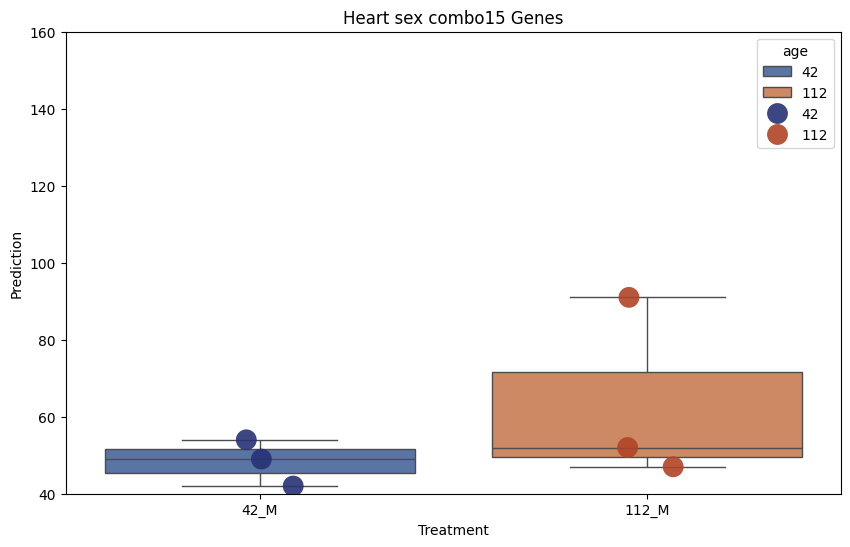

In [ ]:
ordered_x = [
    '42_M','112_M'
]


# Create the box plot
plt.figure(figsize=(10, 6))
box = sns.boxplot(x='age_sex', y='prediction', hue='age', data=df_intervention_test_pred, palette='deep', showfliers = False,
    order = ordered_x)

# Add data points

custom_palette = ['#273276', '#B14325']  # Use desired hex color codes

# Add data points with custom colors
strip = sns.stripplot(
    x='age_sex',
    y='prediction',
    hue='age',
    data=df_intervention_test_pred,
    palette=custom_palette,  # Custom color palette
    dodge=False,
    alpha=0.9,
    jitter=True,
    size=15,
    order = ordered_x
)

# Remove the legend if not needed
#strip.legend_.remove()

# Customize the plot
plt.title("".join([f'{select_tissue} sex combo', str(gene_number), ' Genes']))
plt.xlabel('Treatment')
plt.ylabel('Prediction')

# Set y-axis limits
plt.ylim(40, 160)

# Remove the grid
plt.grid(False)

# Show the plot
plt.show()

##### Try several gene set sizes

In [ ]:
# Set up ordered x-axis for plots
ordered_x = [
    '42_M',
    '112_M'
]

# Custom color palette
custom_palette = ['#273276', '#B14325']

# Directory setup
os.makedirs("./predictions", exist_ok=True)
os.makedirs("./plots", exist_ok=True)

# Dictionary to store prediction DataFrames if needed later
all_predictions = {}

# Loop through gene numbers
for gene_number in range(5, 101, 5):
    print(f"Running prediction for top {gene_number} genes...")

    df_intervention_test_pred = pd.DataFrame(index=df_intervention_test.index, columns=["prediction"])

    for sample in df_intervention_test.index.tolist():
        reference_df = pd.read_csv(f"./{select_tissue}/male/reference/killifish_{select_tissue}_reference_male", sep="\t", index_col=0)
        top_genes = reference_df["spearman_rank"].abs().nlargest(gene_number).index.tolist()

        total_reads_sample = df_intervention_test_counts.loc[sample].sum()
        list_of_profile_probabilities_per_age = []

        for age in new_age_steps:
            log_probs = []
            for gene in top_genes:
                gene_frequency = reference_df.loc[gene, str(age)]
                gene_frequency = max(gene_frequency, 1e-10)  # Ensure >0

                expected = gene_frequency * total_reads_sample
                observed = df_intervention_test_counts.loc[sample, gene]

                poisson_prob = poisson.pmf(k=observed, mu=expected)
                poisson_prob = max(poisson_prob, 0.001)

                log_probs.append(np.log(poisson_prob))

            list_of_profile_probabilities_per_age.append(np.sum(log_probs))

        age_probability_df = pd.DataFrame({"Pr": list_of_profile_probabilities_per_age}, index=new_age_steps)
        max_probability_age = round(float(age_probability_df.idxmax().iloc[0]), 2)
        df_intervention_test_pred.loc[sample, "prediction"] = max_probability_age

    # Add metadata
    df_intervention_test_pred["age"] = df_intervention_test["age"].tolist()
    df_intervention_test_pred["sex"] = df_intervention_test["sex"].tolist()


    df_intervention_test_pred["age_sex"] = (
        df_intervention_test_pred["age"].astype(str) + "_" +
        df_intervention_test_pred["sex"].astype(str)
    )

    # Save predictions
    all_predictions[gene_number] = df_intervention_test_pred.copy()
    df_intervention_test_pred.to_csv(f"./predictions/{select_tissue}_age_maleOnly_preds_top_{gene_number}_genes.tsv", sep="\t")

    # --- Plot ---
    plt.figure(figsize=(10, 6))

    box = sns.boxplot(
        x='age_sex',
        y='prediction',
        hue='age',
        data=df_intervention_test_pred,
        palette='deep',
        showfliers=False,
        order=ordered_x
    )

    strip = sns.stripplot(
        x='age_sex',
        y='prediction',
        hue='age',
        data=df_intervention_test_pred,
        palette=custom_palette,
        dodge=False,
        alpha=0.9,
        jitter=True,
        size=15,
        order=ordered_x
    )

    # Remove duplicate legend
    strip.legend_.remove()

    plt.title(f"{select_tissue}sex combo {gene_number} Genes")
    plt.xlabel('Treatment')
    plt.ylabel('Prediction')
    plt.xticks(rotation=45, ha='right')
    plt.ylim(40, 160)
    plt.grid(False)

    # Save plot
    plt.savefig(f"./plots/xu_{select_tissue}_maleOnly_top_{gene_number}_genes.svg", dpi=300, bbox_inches="tight")
    plt.close()

    print(f"Saved plot and prediction for {gene_number} genes.\n")


Running prediction for top 5 genes...
Saved plot and prediction for 5 genes.

Running prediction for top 10 genes...
Saved plot and prediction for 10 genes.

Running prediction for top 15 genes...
Saved plot and prediction for 15 genes.

Running prediction for top 20 genes...
Saved plot and prediction for 20 genes.

Running prediction for top 25 genes...
Saved plot and prediction for 25 genes.

Running prediction for top 30 genes...
Saved plot and prediction for 30 genes.

Running prediction for top 35 genes...
Saved plot and prediction for 35 genes.

Running prediction for top 40 genes...
Saved plot and prediction for 40 genes.

Running prediction for top 45 genes...
Saved plot and prediction for 45 genes.

Running prediction for top 50 genes...
Saved plot and prediction for 50 genes.

Running prediction for top 55 genes...
Saved plot and prediction for 55 genes.

Running prediction for top 60 genes...
Saved plot and prediction for 60 genes.

Running prediction for top 65 genes...
Sav

##### plot stability of preds

/tmp/ipython-input-376-523614965.py:64: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
/tmp/ipython-input-376-523614965.py:64: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
/tmp/ipython-input-376-523614965.py:64: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
/tmp/ipython-input-376-523614965.py:64: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


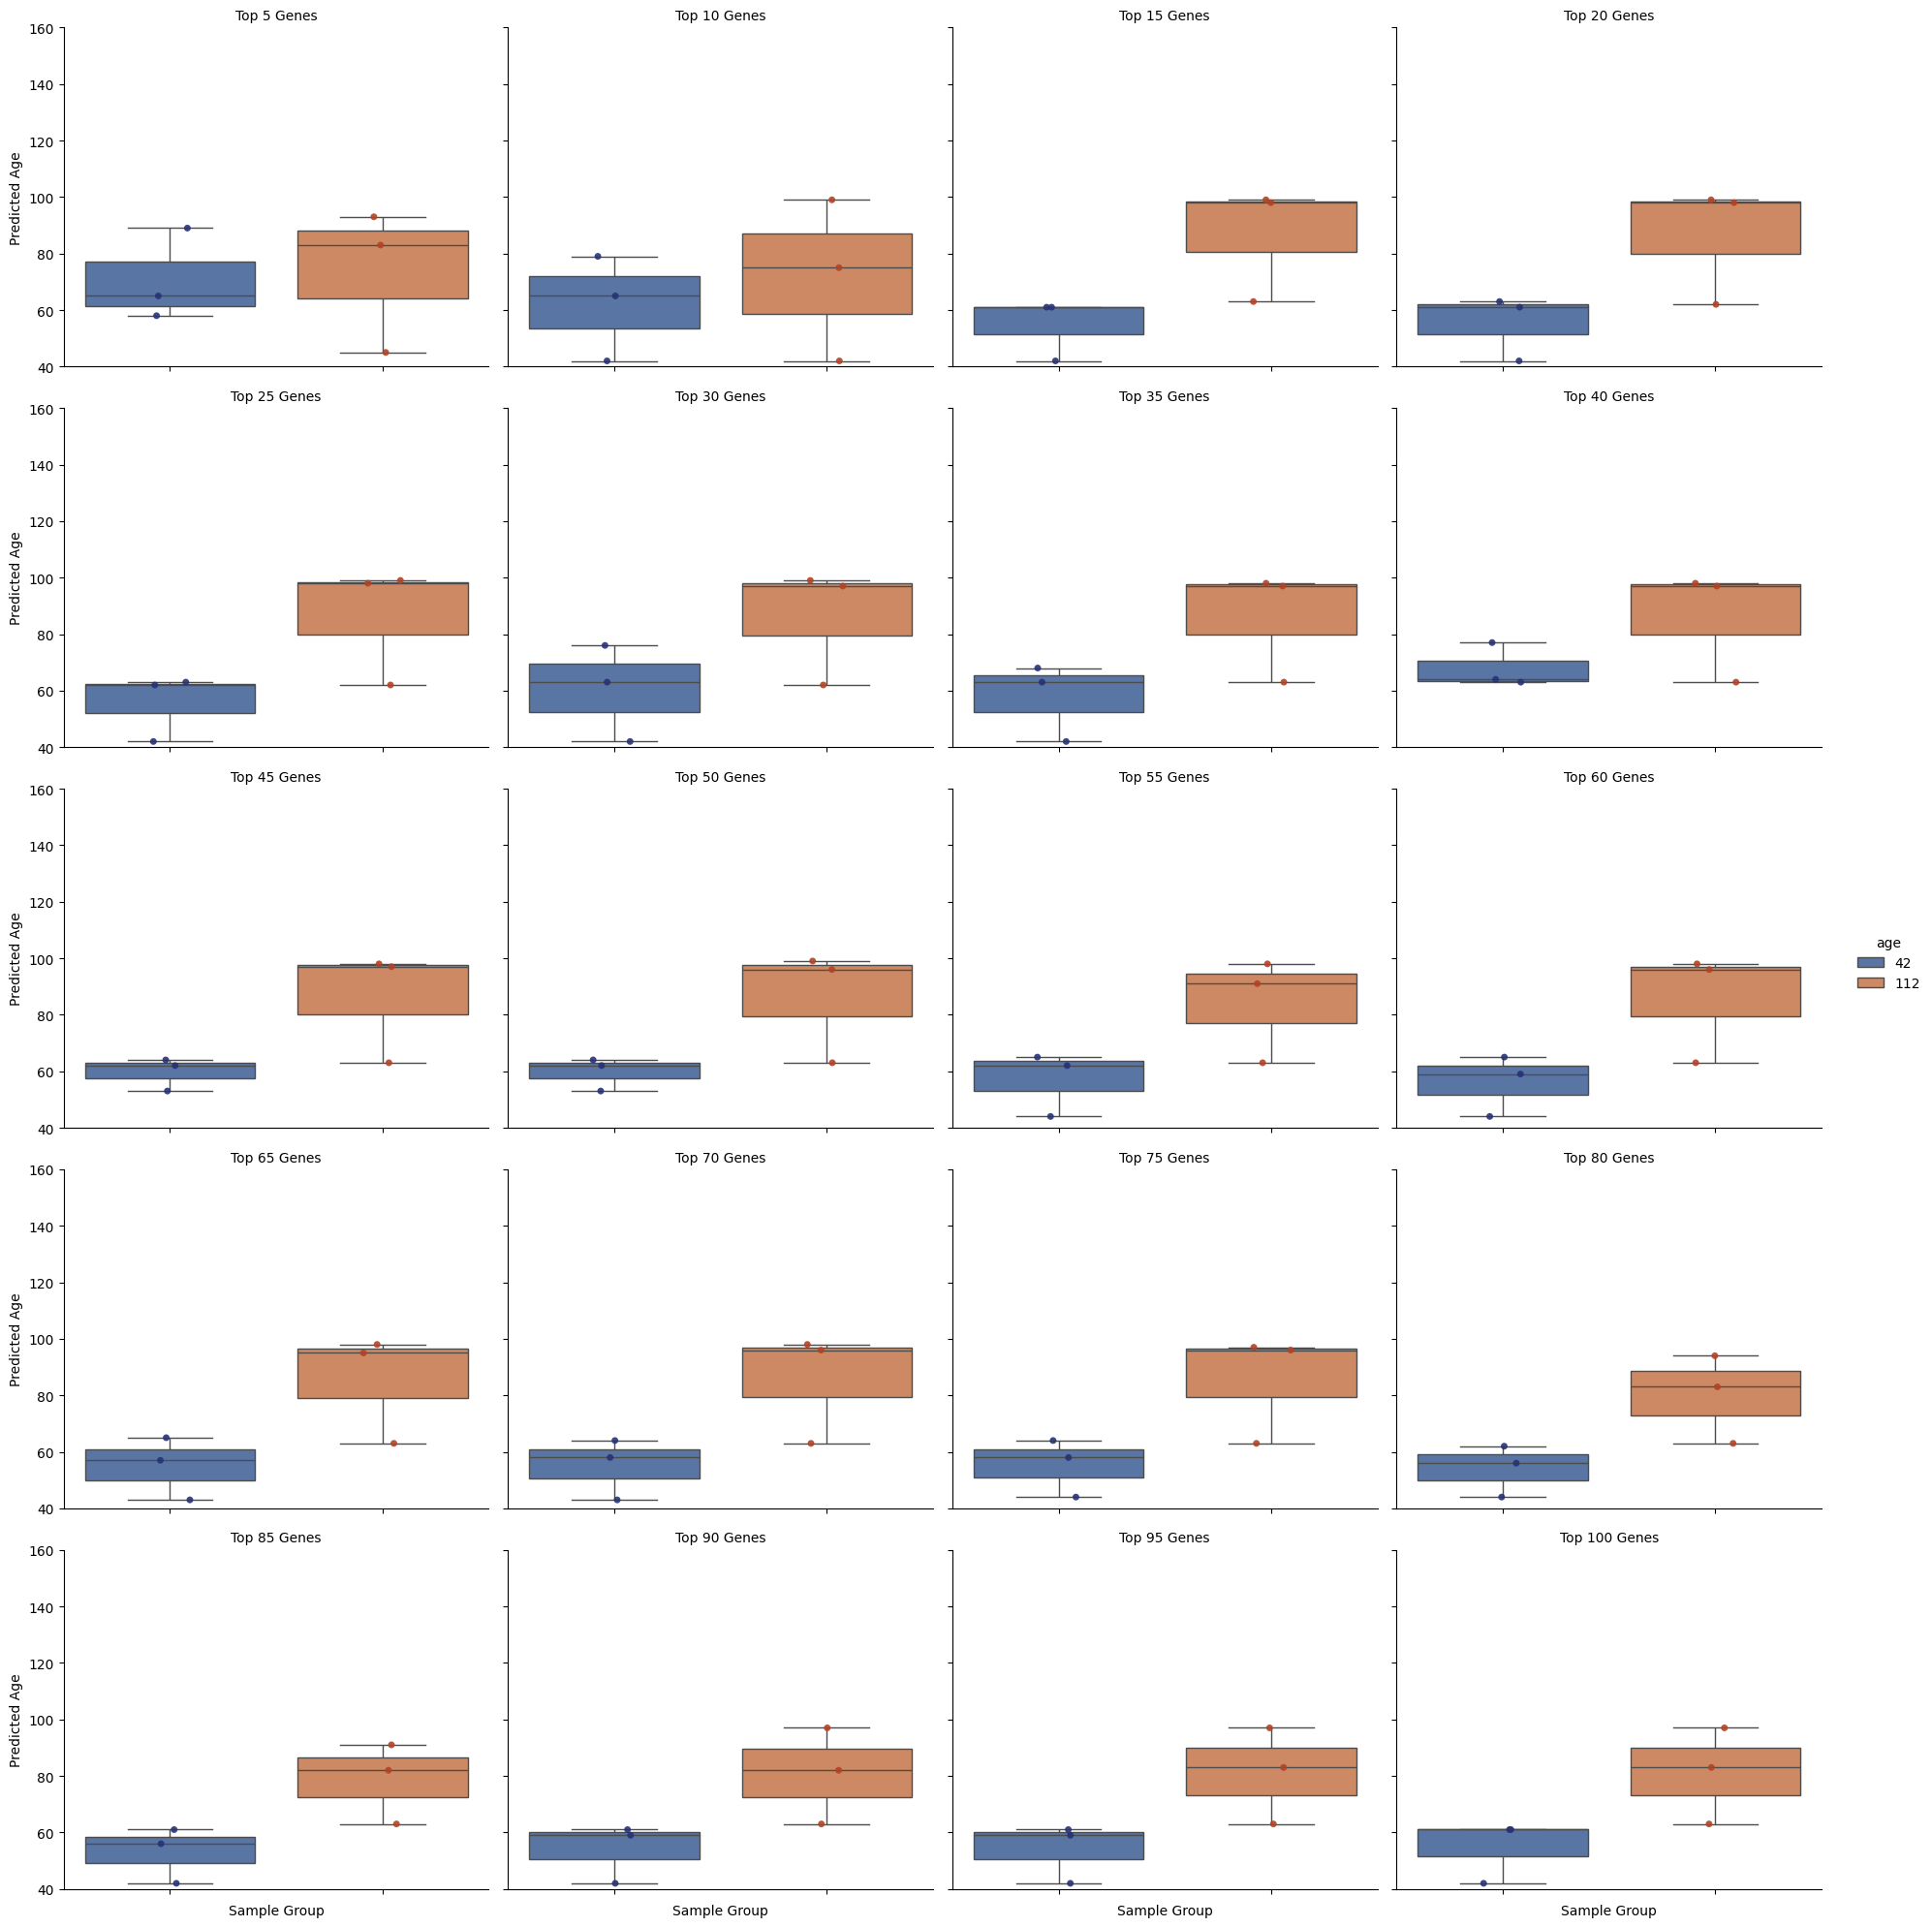

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import os

# Ordered x-axis
ordered_x = [
    '42_M',
    '112_M'
]

# Custom palette
custom_palette = ['#273276', '#B14325']

# Load all prediction files
all_predictions_list = []

for gene_number in range(5, 101, 5):
    file_path = f"./predictions/{select_tissue}_age_maleOnly_preds_top_{gene_number}_genes.tsv"
    if os.path.exists(file_path):
        df = pd.read_csv(file_path, sep="\t", index_col=0)
        df["gene_number"] = str(gene_number)  # for cleaner facet titles
        all_predictions_list.append(df)
    else:
        print(f"Warning: {file_path} not found. Skipping.")

# Concatenate into a single DataFrame
all_predictions_df = pd.concat(all_predictions_list, axis=0)

# Plot with seaborn FacetGrid (catplot)
g = sns.catplot(
    data=all_predictions_df,
    x="age_sex",
    y="prediction",
    hue="age",
    col="gene_number",
    col_wrap=4,
    kind="box",
    palette='deep',
    order=ordered_x,
    height=4,
    aspect=1.2,
    showfliers=False
)

# Overlay stripplot for better visualization
for ax, gene_number in zip(g.axes.flat, all_predictions_df["gene_number"].unique()):
    subset = all_predictions_df[all_predictions_df["gene_number"] == gene_number]
    sns.stripplot(
        x='age_sex',
        y='prediction',
        hue='age',
        data=subset,
        palette=custom_palette,
        dodge=False,
        alpha=0.9,
        jitter=True,
        size=5,
        order=ordered_x,
        ax=ax,
        legend=False
    )
    ax.set_title(f"Top {gene_number} Genes")
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
    ax.set_ylim(40, 160)

g.set_axis_labels("Sample Group", "Predicted Age")
g.set_titles("Top {col_name} Genes")
g.tight_layout()
plt.savefig(f"./plots/{select_tissue}_maleOnly_faceted_predictions_by_gene_number.svg", dpi=300, bbox_inches="tight")
plt.show()


### Female only

In [ ]:
df_intervention_combo.head(2)

,nadsyn1,dnaja3,f2r,LOC107382877,fezf1,srbd1,LOC107373267,LOC107384240,serp1,scarb2,...,umodl1,cryz,LOC107397181,pelo,mrpl35,tissue,AGE,sex,training,age
Heart_20,131,274,111,126,0,79,0,4,156,475,...,4,40,1966,197,60,Heart,16w,F,No,112
Heart_19,201,448,153,158,0,72,2,0,298,470,...,6,38,2149,152,100,Heart,16w,F,No,112


In [ ]:
df_intervention_female = df_intervention_combo.loc[
    (df_intervention_combo.iloc[:, -3] == 'F')
]

In [ ]:
all_samples = df_intervention_female.index
all_samples

random.seed(123)

# Separate the samples
young_samples = [s for s in all_samples if s in df_intervention_female.index and df_intervention_female.loc[s, 'age'] == 42]
old_samples = [s for s in all_samples if s in df_intervention_female.index and df_intervention_female.loc[s, 'age'] ==  112]

# Randomly sample 2 from each
random_young = random.sample(young_samples, 2)
random_old = random.sample(old_samples, 2)

# Combine the result
random_subset = random_young + random_old

#select your training samples
select_train_samples = random_subset

# Select rows in df_intervention_age_counts_female where index is in female_samples
df_intervention_train = df_intervention_female.loc[
    df_intervention_female.index.isin(select_train_samples)
]

df_intervention_train

,nadsyn1,dnaja3,f2r,LOC107382877,fezf1,srbd1,LOC107373267,LOC107384240,serp1,scarb2,...,umodl1,cryz,LOC107397181,pelo,mrpl35,tissue,AGE,sex,training,age
Heart_20,131,274,111,126,0,79,0,4,156,475,...,4,40,1966,197,60,Heart,16w,F,No,112
Heart_17,159,334,86,118,0,90,0,0,340,473,...,6,34,1734,166,88,Heart,16w,F,No,112
Heart_10,212,426,56,126,0,112,0,0,376,591,...,4,54,2582,372,100,Heart,6w,F,No,42
Heart_8,199,516,56,92,4,148,0,0,444,430,...,6,36,2649,290,84,Heart,6w,F,No,42


In [ ]:
# get your testing samples
#all not in select_train_samples
test_samples = [s for s in all_samples if s not in select_train_samples]
test_samples

['Heart_19', 'Heart_18', 'Heart_16', 'Heart_9', 'Heart_7', 'Heart_6']

In [ ]:
# Select rows in df_intervention_age_counts_female where index is in female_samples
df_intervention_test = df_intervention_female.loc[
    df_intervention_female.index.isin(test_samples)
]

df_intervention_test

,nadsyn1,dnaja3,f2r,LOC107382877,fezf1,srbd1,LOC107373267,LOC107384240,serp1,scarb2,...,umodl1,cryz,LOC107397181,pelo,mrpl35,tissue,AGE,sex,training,age
Heart_19,201,448,153,158,0,72,2,0,298,470,...,6,38,2149,152,100,Heart,16w,F,No,112
Heart_18,187,416,193,192,0,96,0,4,187,567,...,16,42,2441,249,85,Heart,16w,F,No,112
Heart_16,147,351,48,84,2,50,0,0,168,376,...,6,38,1872,162,90,Heart,16w,F,No,112
Heart_9,182,438,62,112,2,111,0,0,348,669,...,2,50,3044,378,97,Heart,6w,F,No,42
Heart_7,199,444,32,132,2,76,0,0,260,432,...,0,52,2358,156,94,Heart,6w,F,No,42
Heart_6,159,416,30,102,8,66,0,0,272,406,...,14,46,2068,236,72,Heart,6w,F,No,42


##### transcriptome reference

In [ ]:
# Specify the path for the new directory for the tissue
directory_path = f"./{select_tissue}/female/"

# Create the directory
os.mkdir(directory_path)

In [ ]:
tissue_df_counts.head(1)

,a1cf,aaas,aacs,aadat,aaed1,aagab,aak1,aamdc,aamp,aar2,...,zufsp,zw10,zwilch,zyg11b,zyx,zzef1,zzz3,sex,tissue,age
A13_2,30,591,227,627,749,896,1293,1167,781,617,...,249,1493,10,965,4511,265,630,M,Heart,162


In [ ]:
#select raw counts
tissue_df_counts = combined_df.loc[
    (combined_df.iloc[:, -2] == select_tissue) &
     (combined_df.iloc[:, -3] == 'F')
]
tissue_df_counts.head(5)

,a1cf,aaas,aacs,aadat,aaed1,aagab,aak1,aamdc,aamp,aar2,...,zufsp,zw10,zwilch,zyg11b,zyx,zzef1,zzz3,sex,tissue,age
B15_2,2,1398,460,920,1354,1140,1664,1530,1240,1164,...,262,2611,186,1295,7184,610,647,F,Heart,75
B16_2,0,679,237,684,777,950,1449,2292,780,809,...,164,1379,12,1037,8293,303,609,F,Heart,103
C15_2,0,1174,442,635,1033,1043,1435,1103,741,882,...,253,2687,234,1063,7136,568,553,F,Heart,75
D14_2,30,845,236,684,726,1123,1291,2380,855,693,...,134,1660,4,1034,7294,516,743,F,Heart,133
D16_2,2,544,482,521,638,846,1128,1123,767,585,...,150,1904,57,876,12017,419,581,F,Heart,47


In [ ]:
df_intervention_train = df_intervention_train[tissue_df_counts.columns]
df_intervention_train.head(2)

,a1cf,aaas,aacs,aadat,aaed1,aagab,aak1,aamdc,aamp,aar2,...,zufsp,zw10,zwilch,zyg11b,zyx,zzef1,zzz3,sex,tissue,age
Heart_20,2,88,55,58,28,176,266,140,100,46,...,30,224,16,260,1241,894,437,F,Heart,112
Heart_17,0,76,88,62,86,160,281,200,93,52,...,39,156,14,254,781,534,543,F,Heart,112


In [ ]:
atlas_plus_intervention = pd.concat([tissue_df_counts, df_intervention_train], axis=0)
atlas_plus_intervention.head(3)

,a1cf,aaas,aacs,aadat,aaed1,aagab,aak1,aamdc,aamp,aar2,...,zufsp,zw10,zwilch,zyg11b,zyx,zzef1,zzz3,sex,tissue,age
B15_2,2,1398,460,920,1354,1140,1664,1530,1240,1164,...,262,2611,186,1295,7184,610,647,F,Heart,75
B16_2,0,679,237,684,777,950,1449,2292,780,809,...,164,1379,12,1037,8293,303,609,F,Heart,103
C15_2,0,1174,442,635,1033,1043,1435,1103,741,882,...,253,2687,234,1063,7136,568,553,F,Heart,75


In [ ]:
# #check cols ordered the same
# df_intervention_test = df_intervention_test[tissue_df_counts.columns]
# df_intervention_test.head(2)

In [ ]:
tissue_age_days_value_counts = atlas_plus_intervention["age"].value_counts().index.tolist()

In [ ]:
age_steps = sorted(tissue_age_days_value_counts)

print(age_steps)

[42, 47, 49, 52, 75, 77, 78, 102, 103, 112, 133, 134, 147, 155]


In [ ]:
atlas_plus_intervention_age = atlas_plus_intervention.drop(atlas_plus_intervention.columns[[-2, -3]], axis=1)
atlas_plus_intervention_age.head(2)

,a1cf,aaas,aacs,aadat,aaed1,aagab,aak1,aamdc,aamp,aar2,...,zswim7,zswim8,zufsp,zw10,zwilch,zyg11b,zyx,zzef1,zzz3,age
B15_2,2,1398,460,920,1354,1140,1664,1530,1240,1164,...,150,3050,262,2611,186,1295,7184,610,647,75
B16_2,0,679,237,684,777,950,1449,2292,780,809,...,170,1671,164,1379,12,1037,8293,303,609,103


In [ ]:
#sample generation
for sample in atlas_plus_intervention_age.index.tolist():

    new_df = atlas_plus_intervention_age.drop(sample)

    new_df.to_csv(f"./{select_tissue}/female/{select_tissue}_female_sample_{sample}.csv", sep="\t")

In [ ]:
new_age_steps = np.arange(min(age_steps), max(age_steps)+1, 1)

In [ ]:
# Specify the path for the new directory for the tissue
directory_path = f"./{select_tissue}/female/reference"

# Create the directory
os.mkdir(directory_path)

In [ ]:
transcriptome_reference(training_matrix= atlas_plus_intervention_age,
                            reference_name=f"killifish_{select_tissue}_reference_female",
                            output_path=f"./{select_tissue}/female/reference/",
                            age_prediction="list",
                            age_list=new_age_steps,
                            min_age=1,
                            max_age=24,
                            age_step=1,
                            tau=0.7)

/tmp/ipython-input-10-2002720175.py:41: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho, p = spearmanr(age_training, gene_frequency)



Reference model dataset written to './Heart/female/reference/killifish_Heart_reference_female'
Report file generated at './Heart/female/reference/killifish_Heart_reference_female.report.txt'
-----------------------------------------------------



Time to run construct reference: 100.716 seconds

The reference is constructed and saved!


,42,43,44,45,46,47,48,49,50,51,...,148,149,150,151,152,153,154,155,spearman_rank,p_value
Gene,,,,,,,,,,,,,,,,,,,,,
a1cf,3.551234e-07,3.501712e-07,3.452066e-07,3.402355e-07,3.352644e-07,3.302999e-07,3.253486e-07,3.204160e-07,3.155076e-07,3.106287e-07,...,1.683075e-07,1.673019e-07,1.662436e-07,1.651343e-07,1.639760e-07,1.627704e-07,1.615196e-07,1.602255e-07,-0.132830,0.517718
aaas,2.125750e-05,2.146896e-05,2.167750e-05,2.188329e-05,2.208650e-05,2.228732e-05,2.248597e-05,2.268274e-05,2.287795e-05,2.307184e-05,...,2.288359e-05,2.296217e-05,2.304072e-05,2.311922e-05,2.319768e-05,2.327611e-05,2.335449e-05,2.343284e-05,-0.048989,0.812148
aacs,9.648507e-06,9.628079e-06,9.607461e-06,9.586641e-06,9.565607e-06,9.544345e-06,9.522850e-06,9.501139e-06,9.479234e-06,9.457136e-06,...,6.287693e-06,6.243980e-06,6.200171e-06,6.156262e-06,6.112249e-06,6.068128e-06,6.023895e-06,5.979548e-06,-0.695103,0.000081
aadat,1.679011e-05,1.683628e-05,1.688193e-05,1.692710e-05,1.697186e-05,1.701628e-05,1.706042e-05,1.710436e-05,1.714818e-05,1.719190e-05,...,1.818401e-05,1.816898e-05,1.815360e-05,1.813788e-05,1.812180e-05,1.810537e-05,1.808858e-05,1.807141e-05,0.202810,0.320395
aaed1,2.707821e-05,2.696281e-05,2.684697e-05,2.673065e-05,2.661385e-05,2.649653e-05,2.637869e-05,2.626034e-05,2.614152e-05,2.602228e-05,...,1.942765e-05,1.942720e-05,1.942625e-05,1.942480e-05,1.942286e-05,1.942043e-05,1.941754e-05,1.941418e-05,-0.272354,0.178287
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
zwilch,3.237590e-06,3.233487e-06,3.228682e-06,3.223203e-06,3.217080e-06,3.210345e-06,3.203043e-06,3.195271e-06,3.187134e-06,3.178718e-06,...,9.319363e-07,9.135029e-07,8.951081e-07,8.767727e-07,8.585166e-07,8.403591e-07,8.223189e-07,8.044136e-07,-0.512505,0.007429
zyg11b,2.807925e-05,2.807426e-05,2.807001e-05,2.806643e-05,2.806343e-05,2.806093e-05,2.805884e-05,2.805705e-05,2.805545e-05,2.805397e-05,...,2.638638e-05,2.625767e-05,2.612799e-05,2.599737e-05,2.586580e-05,2.573332e-05,2.559992e-05,2.546563e-05,-0.231587,0.254975
zyx,2.138685e-04,2.133518e-04,2.128542e-04,2.123743e-04,2.119109e-04,2.114623e-04,2.110269e-04,2.106029e-04,2.101885e-04,2.097820e-04,...,2.517074e-04,2.534217e-04,2.551610e-04,2.569254e-04,2.587151e-04,2.605303e-04,2.623711e-04,2.642374e-04,0.121275,0.555087


In [ ]:
df_intervention_test.head(1)

,nadsyn1,dnaja3,f2r,LOC107382877,fezf1,srbd1,LOC107373267,LOC107384240,serp1,scarb2,...,umodl1,cryz,LOC107397181,pelo,mrpl35,tissue,AGE,sex,training,age
Heart_19,201,448,153,158,0,72,2,0,298,470,...,6,38,2149,152,100,Heart,16w,F,No,112


In [ ]:
df_intervention_test_counts = df_intervention_test.drop(df_intervention_test.columns[[-2, -3,-4, -5]], axis=1)
df_intervention_test_counts.head(3)

,nadsyn1,dnaja3,f2r,LOC107382877,fezf1,srbd1,LOC107373267,LOC107384240,serp1,scarb2,...,plekhg1,LOC107373049,LOC107375201,LOC107384697,umodl1,cryz,LOC107397181,pelo,mrpl35,age
Heart_19,201,448,153,158,0,72,2,0,298,470,...,1245,0,4,13,6,38,2149,152,100,112
Heart_18,187,416,193,192,0,96,0,4,187,567,...,1230,0,0,0,16,42,2441,249,85,112
Heart_16,147,351,48,84,2,50,0,0,168,376,...,672,0,2,2,6,38,1872,162,90,112


In [ ]:
gene_number = 15
df_intervention_test_pred = pd.DataFrame(index=df_intervention_test.index, columns=["prediction"])

for sample in df_intervention_test.index.tolist():

    reference_df = pd.read_csv(f"./{select_tissue}/female/reference/killifish_{select_tissue}_reference_female", sep="\t", index_col=0)

    # Get top genes based on spearman correlation
    top_abs_spearman_corr = reference_df["spearman_rank"].abs().nlargest(gene_number)

    #print(top_abs_spearman_corr)

    top_genes = top_abs_spearman_corr.index.tolist()

    # Save the DataFrame to a CSV file
    # df_top_genes = pd.DataFrame(top_genes, columns=["genes"])
    # gene_num = "".join([str(gene_number), "genes"])
    # out_file_prefix = 'Antebi_male_pred'
    # out_file_name = "_".join([out_file_prefix, gene_num])
    # output_path = './fat/gene_sets'
    # df_top_genes.to_csv(os.path.join(output_path, out_file_name), sep="\t")
    # print(f"List has been written to {out_file_name}")

    total_reads_sample = df_intervention_test_counts.loc[sample].sum()

    list_of_profile_probabilities_per_age = []

    for age in new_age_steps:

        probability_list_one_age = []

        genes_not_defined = []

        for gene in top_genes:

            gene_frequency = reference_df.loc[gene, f"{age}"]

            if gene_frequency < 0:
                gene_frequency = 10**-10

            sample_expected_counts = gene_frequency * total_reads_sample
            sample_observed_counts = df_intervention_test_counts.loc[sample, gene]

            poisson_probability = poisson.pmf(k=sample_observed_counts, mu=sample_expected_counts)

            # Replace NaN poisson probability with a small positive value and log it
            if np.isnan(poisson_probability):
                poisson_probability = 0.001
                genes_not_defined.append(gene)

            # Replace zero poisson probability with 0.001
            if poisson_probability == 0:
                poisson_probability = 0.001

            logP = np.log(poisson_probability)

            probability_list_one_age.append(logP)

        list_of_profile_probabilities_per_age.append(np.sum(probability_list_one_age))

    # Transform into dataframe with age steps
    age_probability_df = pd.DataFrame({"Pr": list_of_profile_probabilities_per_age}, index=new_age_steps)

    # Compute highest likelihood age among age steps
    max_probability_age = round(float(age_probability_df.idxmax().iloc[0]), 2)

    # Compute highest maximum probability
    max_probability = float(age_probability_df["Pr"].max())

    df_intervention_test_pred.loc[sample, "prediction"] = max_probability_age



print(df_intervention_test_pred)

         prediction
Heart_19      118.0
Heart_18       69.0
Heart_16       74.0
Heart_9        58.0
Heart_7        42.0
Heart_6        42.0


In [ ]:
df_intervention_test_pred["age"] = df_intervention_test["age"].tolist()
df_intervention_test_pred["sex"] = df_intervention_test["sex"].tolist()


df_intervention_test_pred["age_sex"] = (
    df_intervention_test_pred["age"].astype(str) + "_" +
    df_intervention_test_pred["sex"].astype(str)
)

df_intervention_test_pred

,prediction,age,sex,age_sex
Heart_19,118.0,112,F,112_F
Heart_18,69.0,112,F,112_F
Heart_16,74.0,112,F,112_F
Heart_9,58.0,42,F,42_F
Heart_7,42.0,42,F,42_F
Heart_6,42.0,42,F,42_F


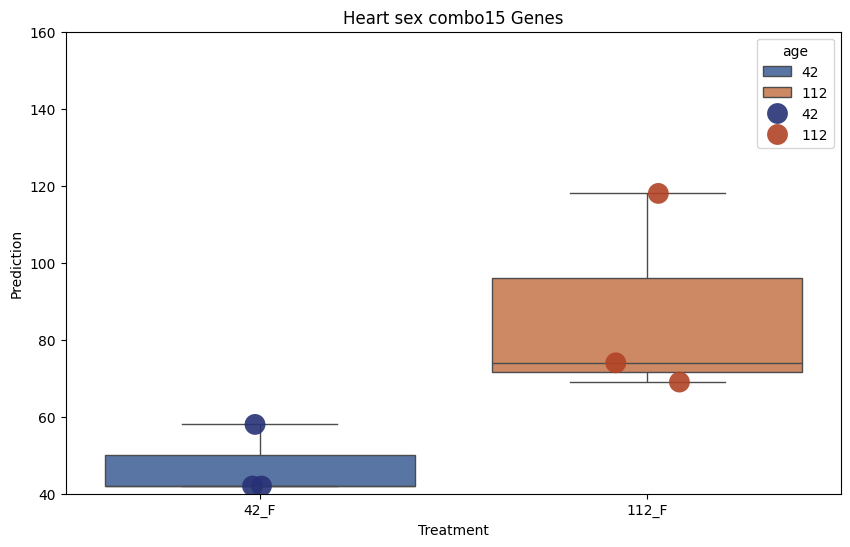

In [ ]:
ordered_x = [
'42_F',
 '112_F'
]


# Create the box plot
plt.figure(figsize=(10, 6))
box = sns.boxplot(x='age_sex', y='prediction', hue='age', data=df_intervention_test_pred, palette='deep', showfliers = False,
    order = ordered_x)

# Add data points

custom_palette = ['#273276', '#B14325']  # Use desired hex color codes

# Add data points with custom colors
strip = sns.stripplot(
    x='age_sex',
    y='prediction',
    hue='age',
    data=df_intervention_test_pred,
    palette=custom_palette,  # Custom color palette
    dodge=False,
    alpha=0.9,
    jitter=True,
    size=15,
    order = ordered_x
)

# Remove the legend if not needed
#strip.legend_.remove()

# Customize the plot
plt.title("".join([f'{select_tissue} sex combo', str(gene_number), ' Genes']))
plt.xlabel('Treatment')
plt.ylabel('Prediction')

# Set y-axis limits
plt.ylim(40, 160)

# Remove the grid
plt.grid(False)


# Show the plot
plt.show()

##### Try several gene set sizes

In [ ]:
# Set up ordered x-axis for plots
ordered_x = [
'42_F',
'112_F'
]

# Custom color palette
custom_palette = ['#273276', '#B14325']

# Directory setup
os.makedirs("./predictions", exist_ok=True)
os.makedirs("./plots", exist_ok=True)

# Dictionary to store prediction DataFrames if needed later
all_predictions = {}

# Loop through gene numbers
for gene_number in range(5, 101, 5):
    print(f"Running prediction for top {gene_number} genes...")

    df_intervention_test_pred = pd.DataFrame(index=df_intervention_test.index, columns=["prediction"])

    for sample in df_intervention_test.index.tolist():
        reference_df = pd.read_csv(f"./{select_tissue}/female/reference/killifish_{select_tissue}_reference_female", sep="\t", index_col=0)
        top_genes = reference_df["spearman_rank"].abs().nlargest(gene_number).index.tolist()

        total_reads_sample = df_intervention_test_counts.loc[sample].sum()
        list_of_profile_probabilities_per_age = []

        for age in new_age_steps:
            log_probs = []
            for gene in top_genes:
                gene_frequency = reference_df.loc[gene, str(age)]
                gene_frequency = max(gene_frequency, 1e-10)  # Ensure >0

                expected = gene_frequency * total_reads_sample
                observed = df_intervention_test_counts.loc[sample, gene]

                poisson_prob = poisson.pmf(k=observed, mu=expected)
                poisson_prob = max(poisson_prob, 0.001)

                log_probs.append(np.log(poisson_prob))

            list_of_profile_probabilities_per_age.append(np.sum(log_probs))

        age_probability_df = pd.DataFrame({"Pr": list_of_profile_probabilities_per_age}, index=new_age_steps)
        max_probability_age = round(float(age_probability_df.idxmax().iloc[0]), 2)
        df_intervention_test_pred.loc[sample, "prediction"] = max_probability_age

    # Add metadata
    df_intervention_test_pred["age"] = df_intervention_test["age"].tolist()
    df_intervention_test_pred["sex"] = df_intervention_test["sex"].tolist()


    df_intervention_test_pred["age_sex"] = (
        df_intervention_test_pred["age"].astype(str) + "_" +
        df_intervention_test_pred["sex"].astype(str)
    )

    # Save predictions
    all_predictions[gene_number] = df_intervention_test_pred.copy()
    df_intervention_test_pred.to_csv(f"./predictions/{select_tissue}_age_femaleOnly_preds_top_{gene_number}_genes.tsv", sep="\t")

    # --- Plot ---
    plt.figure(figsize=(10, 6))

    box = sns.boxplot(
        x='age_sex',
        y='prediction',
        hue='age',
        data=df_intervention_test_pred,
        palette='deep',
        showfliers=False,
        order=ordered_x
    )

    strip = sns.stripplot(
        x='age_sex',
        y='prediction',
        hue='age',
        data=df_intervention_test_pred,
        palette=custom_palette,
        dodge=False,
        alpha=0.9,
        jitter=True,
        size=15,
        order=ordered_x
    )

    # Remove duplicate legend
    strip.legend_.remove()

    plt.title(f"{select_tissue } female {gene_number} Genes")
    plt.xlabel('Treatment')
    plt.ylabel('Prediction')
    plt.xticks(rotation=45, ha='right')
    plt.ylim(40, 160)
    plt.grid(False)

    # Save plot
    plt.savefig(f"./plots/xu_{select_tissue}_female_top_{gene_number}_genes.svg", dpi=300, bbox_inches="tight")
    plt.close()

    print(f"Saved plot and prediction for {gene_number} genes.\n")


Running prediction for top 5 genes...
Saved plot and prediction for 5 genes.

Running prediction for top 10 genes...
Saved plot and prediction for 10 genes.

Running prediction for top 15 genes...
Saved plot and prediction for 15 genes.

Running prediction for top 20 genes...
Saved plot and prediction for 20 genes.

Running prediction for top 25 genes...
Saved plot and prediction for 25 genes.

Running prediction for top 30 genes...
Saved plot and prediction for 30 genes.

Running prediction for top 35 genes...
Saved plot and prediction for 35 genes.

Running prediction for top 40 genes...
Saved plot and prediction for 40 genes.

Running prediction for top 45 genes...
Saved plot and prediction for 45 genes.

Running prediction for top 50 genes...
Saved plot and prediction for 50 genes.

Running prediction for top 55 genes...
Saved plot and prediction for 55 genes.

Running prediction for top 60 genes...
Saved plot and prediction for 60 genes.

Running prediction for top 65 genes...
Sav

##### plot stability of preds

/tmp/ipython-input-401-1805454751.py:64: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
/tmp/ipython-input-401-1805454751.py:64: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
/tmp/ipython-input-401-1805454751.py:64: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
/tmp/ipython-input-401-1805454751.py:64: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


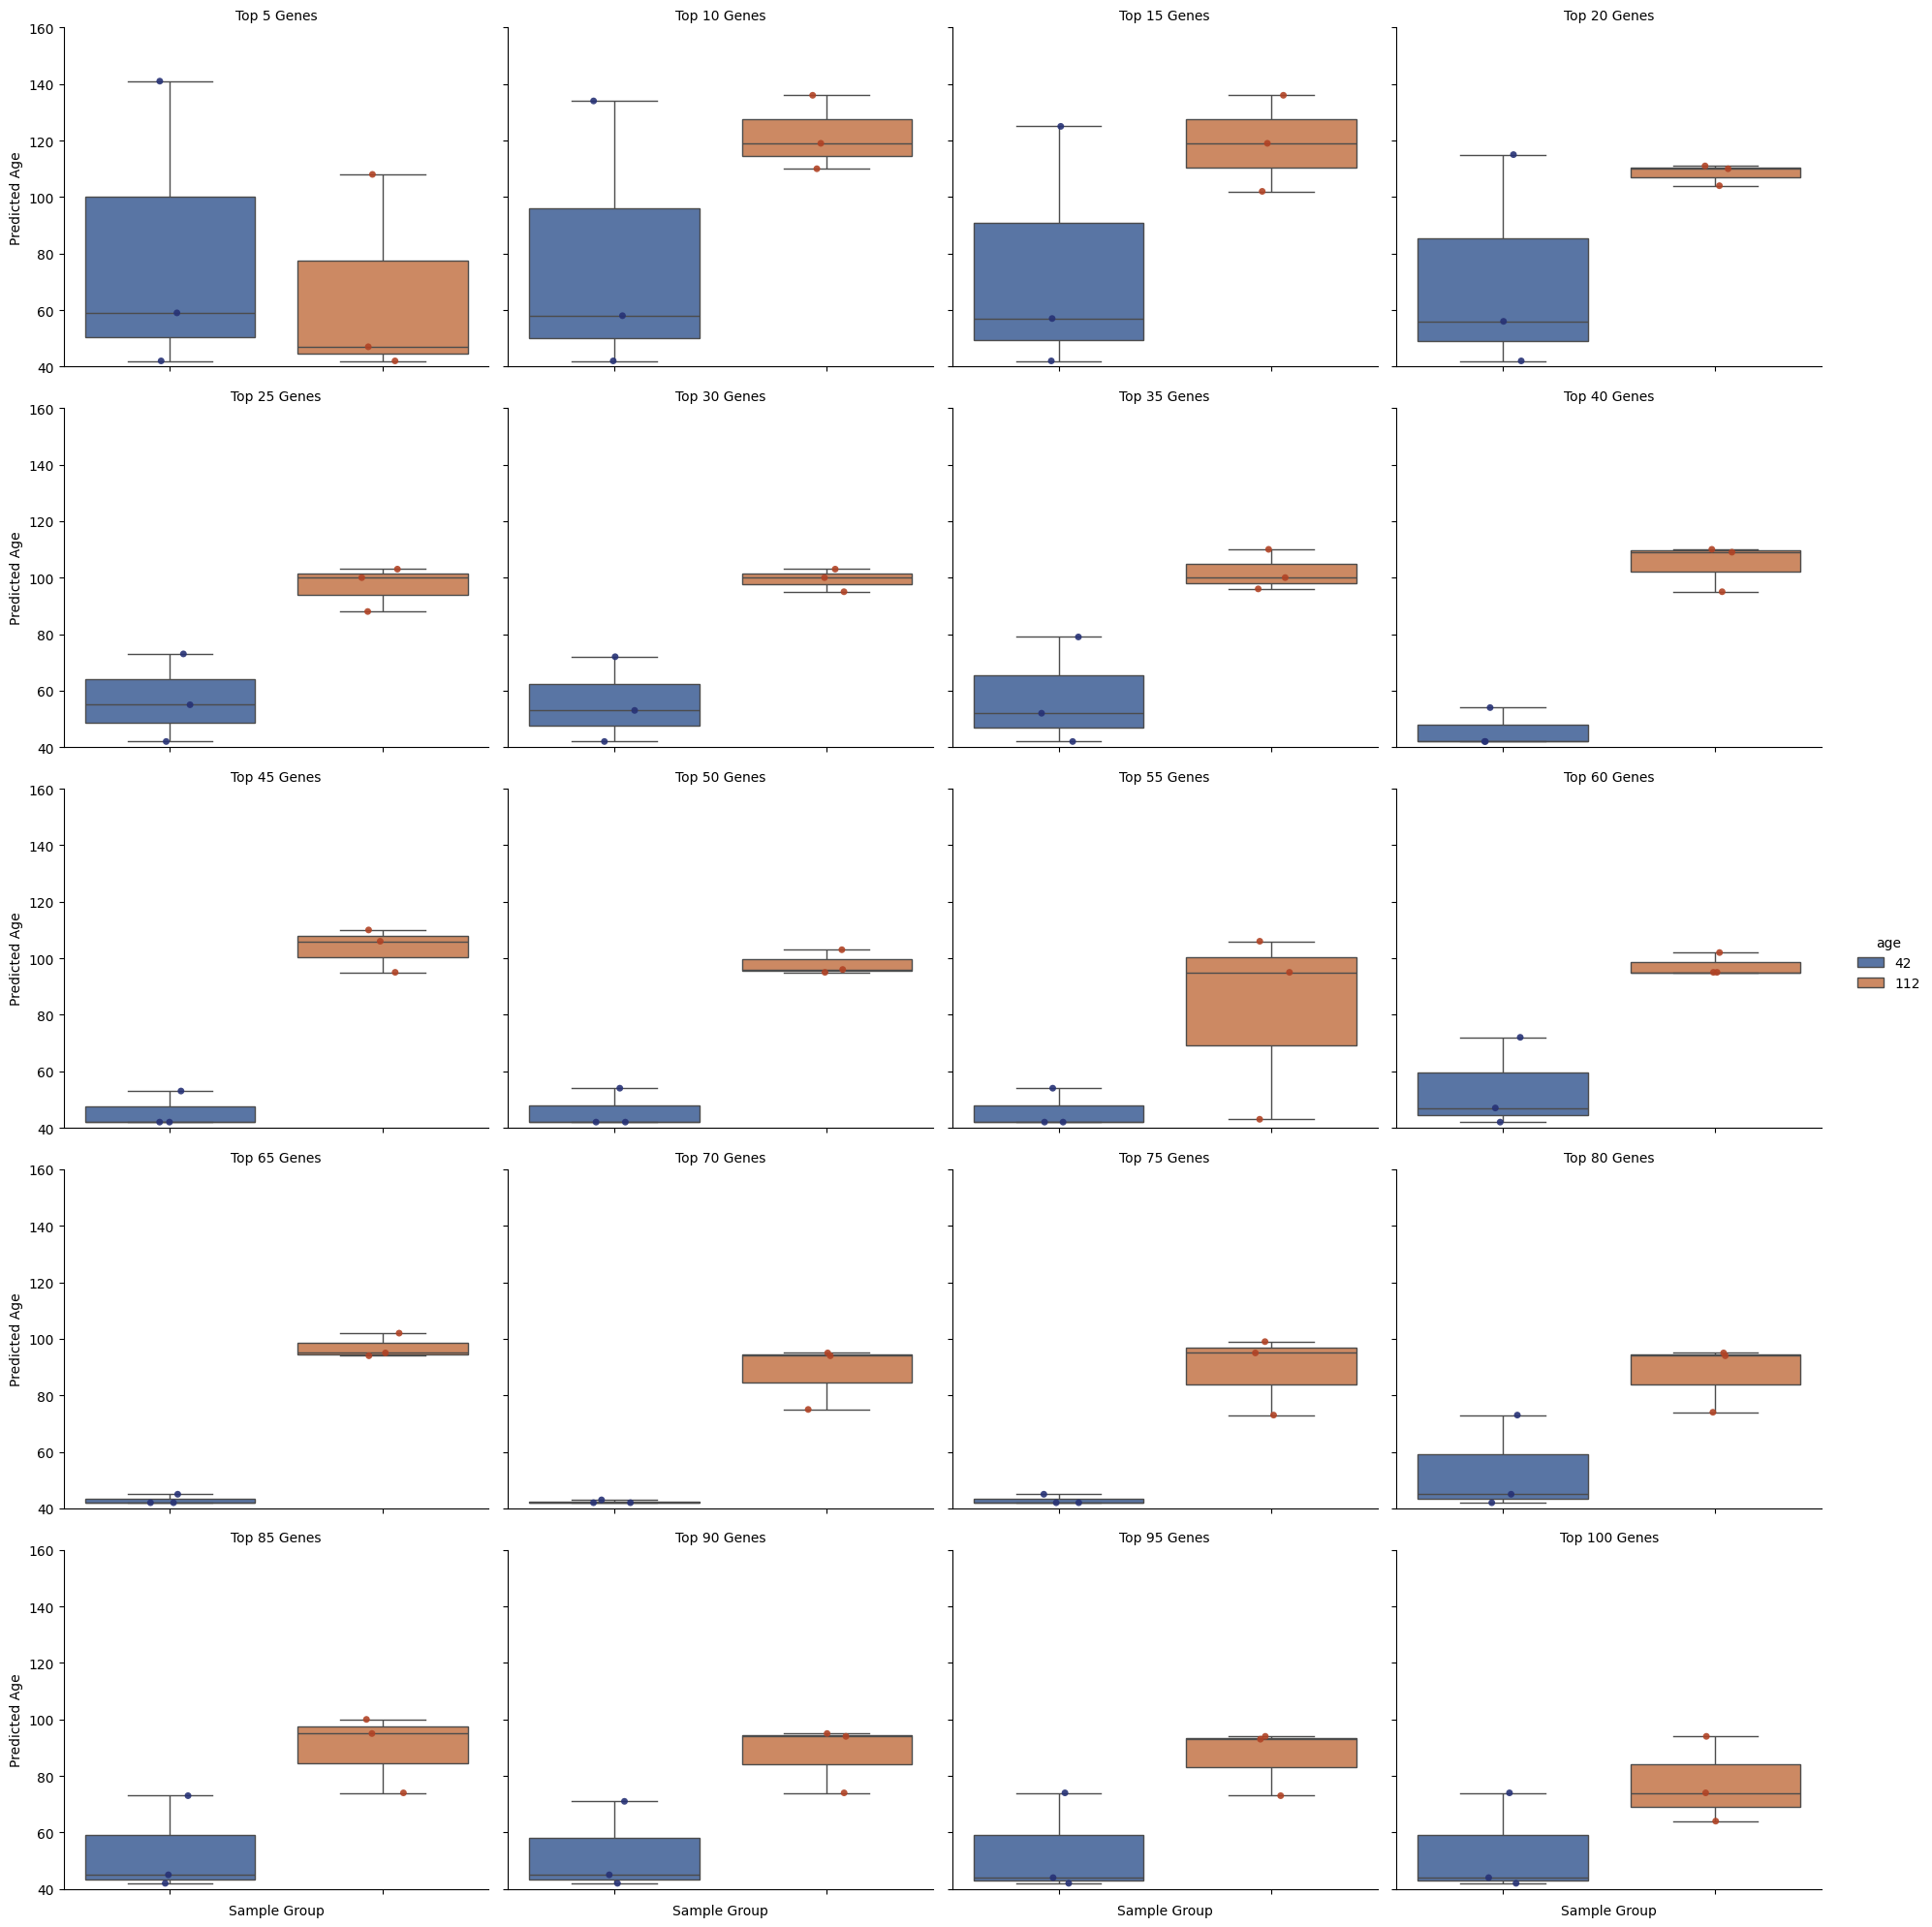

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import os

# Ordered x-axis
ordered_x = [
    '42_F',
'112_F'
]

# Custom palette
custom_palette = ['#273276', '#B14325']

# Load all prediction files
all_predictions_list = []

for gene_number in range(5, 101, 5):
    file_path = f"./predictions/{select_tissue}_age_femaleOnly_preds_top_{gene_number}_genes.tsv"
    if os.path.exists(file_path):
        df = pd.read_csv(file_path, sep="\t", index_col=0)
        df["gene_number"] = str(gene_number)  # for cleaner facet titles
        all_predictions_list.append(df)
    else:
        print(f"Warning: {file_path} not found. Skipping.")

# Concatenate into a single DataFrame
all_predictions_df = pd.concat(all_predictions_list, axis=0)

# Plot with seaborn FacetGrid (catplot)
g = sns.catplot(
    data=all_predictions_df,
    x="age_sex",
    y="prediction",
    hue="age",
    col="gene_number",
    col_wrap=4,
    kind="box",
    palette='deep',
    order=ordered_x,
    height=4,
    aspect=1.2,
    showfliers=False
)

# Overlay stripplot for better visualization
for ax, gene_number in zip(g.axes.flat, all_predictions_df["gene_number"].unique()):
    subset = all_predictions_df[all_predictions_df["gene_number"] == gene_number]
    sns.stripplot(
        x='age_sex',
        y='prediction',
        hue='age',
        data=subset,
        palette=custom_palette,
        dodge=False,
        alpha=0.9,
        jitter=True,
        size=5,
        order=ordered_x,
        ax=ax,
        legend=False
    )
    ax.set_title(f"Top {gene_number} Genes")
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
    ax.set_ylim(40, 160)

g.set_axis_labels("Sample Group", "Predicted Age")
g.set_titles("Top {col_name} Genes")
g.tight_layout()
plt.savefig(f"./plots/{select_tissue}_femaleOnly_faceted_predictions_by_gene_number.svg", dpi=300, bbox_inches="tight")
plt.show()


#Heart - NO Calibration

In [ ]:
select_tissue = 'Heart'

### Sex combo

In [ ]:
df_intervention_combo = df_intervention.loc[
    (df_intervention.iloc[:, -5] == select_tissue)
]

In [ ]:
# all_samples = df_intervention_combo.index
# all_samples

# random.seed(123)

# # Separate the samples
# young_samples = [s for s in all_samples if s in df_intervention_combo.index and df_intervention_combo.loc[s, 'age'] == 42]
# old_samples = [s for s in all_samples if s in df_intervention_combo.index and df_intervention_combo.loc[s, 'age'] ==  112]

# # Randomly sample 2 from each
# random_young = random.sample(young_samples, 2)
# random_old = random.sample(old_samples, 2)

# # Combine the result
# random_subset = random_young + random_old

# #select your training samples
# select_train_samples = random_subset

# # Select rows in df_intervention_age_counts_female where index is in female_samples
# df_intervention_train = df_intervention_combo.loc[
#     df_intervention_combo.index.isin(select_train_samples)
# ]

# df_intervention_train

,nadsyn1,dnaja3,f2r,LOC107382877,fezf1,srbd1,LOC107373267,LOC107384240,serp1,scarb2,...,umodl1,cryz,LOC107397181,pelo,mrpl35,tissue,AGE,sex,training,age
brain_10,59,200,66,148,29,175,0,0,67,388,...,10,30,898,95,37,Brain,6w,F,No,42
brain_6,76,123,26,138,12,137,2,0,126,300,...,4,40,857,171,17,Brain,6w,F,No,42
brain_19,36,38,12,30,4,28,0,0,38,122,...,2,0,220,50,8,Brain,16w,F,No,112
brain_14,100,180,84,148,20,166,2,0,79,494,...,0,12,1137,125,20,Brain,16w,M,No,112


In [ ]:
# get your testing samples
#all not in select_train_samples
all_samples = df_intervention_combo.index

test_samples = all_samples
test_samples

Index(['Heart_20', 'Heart_19', 'Heart_18', 'Heart_17', 'Heart_16', 'Heart_15',
       'Heart_14', 'Heart_13', 'Heart_12', 'Heart_11', 'Heart_10', 'Heart_9',
       'Heart_8', 'Heart_7', 'Heart_6', 'Heart_5', 'Heart_4', 'Heart_3',
       'Heart_2', 'Heart_1'],
      dtype='object')

In [ ]:
# Select rows in df_intervention_age_counts_female where index is in female_samples
df_intervention_test = df_intervention_combo.loc[
    df_intervention_combo.index.isin(test_samples)
]

df_intervention_test.head(2)

,nadsyn1,dnaja3,f2r,LOC107382877,fezf1,srbd1,LOC107373267,LOC107384240,serp1,scarb2,...,umodl1,cryz,LOC107397181,pelo,mrpl35,tissue,AGE,sex,training,age
Heart_20,131,274,111,126,0,79,0,4,156,475,...,4,40,1966,197,60,Heart,16w,F,No,112
Heart_19,201,448,153,158,0,72,2,0,298,470,...,6,38,2149,152,100,Heart,16w,F,No,112


##### transcriptome reference

In [ ]:
# Specify the path for the new directory for the tissue
directory_path = f"./{select_tissue}_nocalib/"

# Create the directory
os.mkdir(directory_path)

In [ ]:
#select raw counts
tissue_df_counts = combined_df.loc[
    (combined_df.iloc[:, -2] == select_tissue)
]
tissue_df_counts.head(5)

,a1cf,aaas,aacs,aadat,aaed1,aagab,aak1,aamdc,aamp,aar2,...,zufsp,zw10,zwilch,zyg11b,zyx,zzef1,zzz3,sex,tissue,age
A13_2,30,591,227,627,749,896,1293,1167,781,617,...,249,1493,10,965,4511,265,630,M,Heart,162
A14_2,2,695,245,613,499,833,1037,1386,706,646,...,100,1299,28,715,5683,219,444,M,Heart,103
A15_2,0,712,268,539,435,754,1479,1006,732,584,...,180,1690,94,1296,7531,334,454,M,Heart,103
B13_2,16,474,176,394,360,562,739,1450,435,524,...,154,1187,42,666,3405,184,367,M,Heart,134
B14_2,118,985,353,692,816,932,1622,1390,863,928,...,262,2512,167,1303,7114,466,630,M,Heart,47


In [ ]:
# df_intervention_train = df_intervention_train[tissue_df_counts.columns]
# df_intervention_train.head(2)

,a1cf,aaas,aacs,aadat,aaed1,aagab,aak1,aamdc,aamp,aar2,...,zufsp,zw10,zwilch,zyg11b,zyx,zzef1,zzz3,sex,tissue,age
brain_10,18,105,209,76,8,170,444,61,127,56,...,55,106,15,416,172,640,514,F,Brain,42
brain_6,78,66,166,58,20,66,391,31,68,50,...,35,116,4,312,203,760,399,F,Brain,42


In [ ]:
atlas_plus_intervention = tissue_df_counts
atlas_plus_intervention.head(3)

,a1cf,aaas,aacs,aadat,aaed1,aagab,aak1,aamdc,aamp,aar2,...,zufsp,zw10,zwilch,zyg11b,zyx,zzef1,zzz3,sex,tissue,age
A13_2,30,591,227,627,749,896,1293,1167,781,617,...,249,1493,10,965,4511,265,630,M,Heart,162
A14_2,2,695,245,613,499,833,1037,1386,706,646,...,100,1299,28,715,5683,219,444,M,Heart,103
A15_2,0,712,268,539,435,754,1479,1006,732,584,...,180,1690,94,1296,7531,334,454,M,Heart,103


In [ ]:
# #check cols ordered the same
# df_intervention_test = df_intervention_test[tissue_df_counts.columns]
# df_intervention_test.head(2)

In [ ]:
tissue_age_days_value_counts = atlas_plus_intervention["age"].value_counts().index.tolist()

In [ ]:
age_steps = sorted(tissue_age_days_value_counts)

print(age_steps)

[47, 49, 52, 75, 77, 78, 102, 103, 133, 134, 147, 152, 155, 161, 162]


In [ ]:
atlas_plus_intervention_age = atlas_plus_intervention.drop(atlas_plus_intervention.columns[[-2,-3]], axis=1)
atlas_plus_intervention_age.head(2)

,a1cf,aaas,aacs,aadat,aaed1,aagab,aak1,aamdc,aamp,aar2,...,zswim7,zswim8,zufsp,zw10,zwilch,zyg11b,zyx,zzef1,zzz3,age
A13_2,30,591,227,627,749,896,1293,1167,781,617,...,79,1736,249,1493,10,965,4511,265,630,162
A14_2,2,695,245,613,499,833,1037,1386,706,646,...,104,1456,100,1299,28,715,5683,219,444,103


In [ ]:
#sample generation
for sample in atlas_plus_intervention_age.index.tolist():

    new_df = atlas_plus_intervention_age.drop(sample)

    new_df.to_csv(f"./{select_tissue}_nocalib/{select_tissue}_sample_{sample}.csv", sep="\t")

In [ ]:
new_age_steps = np.arange(min(age_steps), max(age_steps)+1, 1)

In [ ]:
# Specify the path for the new directory for the tissue
directory_path = f"./{select_tissue}_nocalib/reference"

# Create the directory
os.mkdir(directory_path)

In [ ]:
transcriptome_reference(training_matrix= atlas_plus_intervention_age,
                            reference_name=f"killifish_{select_tissue}_nocalib_reference_sexcombo",
                            output_path=f"./{select_tissue}_nocalib/reference/",
                            age_prediction="list",
                            age_list=new_age_steps,
                            min_age=1,
                            max_age=24,
                            age_step=1,
                            tau=0.7)

/tmp/ipython-input-10-2002720175.py:41: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho, p = spearmanr(age_training, gene_frequency)



Reference model dataset written to './Heart_nocalib/reference/killifish_Heart_nocalib_reference_sexcombo'
Report file generated at './Heart_nocalib/reference/killifish_Heart_nocalib_reference_sexcombo.report.txt'
-----------------------------------------------------



Time to run construct reference: 103.632 seconds

The reference is constructed and saved!


,47,48,49,50,51,52,53,54,55,56,...,155,156,157,158,159,160,161,162,spearman_rank,p_value
Gene,,,,,,,,,,,,,,,,,,,,,
a1cf,4.630937e-07,4.625671e-07,4.619232e-07,4.611548e-07,4.602568e-07,4.592246e-07,4.580543e-07,4.567449e-07,4.552962e-07,4.537082e-07,...,4.243789e-07,4.336151e-07,4.429233e-07,4.523128e-07,4.617925e-07,4.713710e-07,4.810569e-07,4.908590e-07,-0.058831,0.672613
aaas,2.917098e-05,2.903831e-05,2.890576e-05,2.877343e-05,2.864138e-05,2.850966e-05,2.837831e-05,2.824735e-05,2.811678e-05,2.798661e-05,...,2.071697e-05,2.067414e-05,2.063119e-05,2.058810e-05,2.054488e-05,2.050153e-05,2.045804e-05,2.041442e-05,-0.528263,0.000040
aacs,9.823479e-06,9.794619e-06,9.765533e-06,9.736232e-06,9.706726e-06,9.677028e-06,9.647146e-06,9.617085e-06,9.586849e-06,9.556442e-06,...,7.543276e-06,7.560407e-06,7.578043e-06,7.596199e-06,7.614891e-06,7.634132e-06,7.653936e-06,7.674313e-06,-0.439907,0.000873
aadat,1.838188e-05,1.837113e-05,1.836063e-05,1.835040e-05,1.834044e-05,1.833072e-05,1.832125e-05,1.831203e-05,1.830305e-05,1.829431e-05,...,1.810773e-05,1.810756e-05,1.810758e-05,1.810780e-05,1.810824e-05,1.810891e-05,1.810982e-05,1.811098e-05,-0.029274,0.833568
aaed1,2.311957e-05,2.303409e-05,2.294869e-05,2.286341e-05,2.277824e-05,2.269319e-05,2.260825e-05,2.252342e-05,2.243870e-05,2.235409e-05,...,1.851276e-05,1.851326e-05,1.851390e-05,1.851469e-05,1.851564e-05,1.851676e-05,1.851806e-05,1.851955e-05,-0.476289,0.000272
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
zwilch,4.979634e-06,4.909555e-06,4.839635e-06,4.769911e-06,4.700422e-06,4.631203e-06,4.562283e-06,4.493673e-06,4.425372e-06,4.357382e-06,...,1.118932e-06,1.112741e-06,1.106712e-06,1.100852e-06,1.095167e-06,1.089663e-06,1.084345e-06,1.079220e-06,-0.562810,0.000009
zyg11b,2.844786e-05,2.845086e-05,2.845399e-05,2.845724e-05,2.846059e-05,2.846399e-05,2.846743e-05,2.847089e-05,2.847437e-05,2.847787e-05,...,2.774382e-05,2.772653e-05,2.770934e-05,2.769227e-05,2.767539e-05,2.765873e-05,2.764233e-05,2.762623e-05,-0.003936,0.977464
zyx,1.779620e-04,1.786084e-04,1.792620e-04,1.799226e-04,1.805900e-04,1.812638e-04,1.819438e-04,1.826299e-04,1.833220e-04,1.840201e-04,...,1.840507e-04,1.835269e-04,1.830119e-04,1.825048e-04,1.820050e-04,1.815118e-04,1.810245e-04,1.805425e-04,0.085910,0.536787


In [ ]:
df_intervention_test.head(1)

,nadsyn1,dnaja3,f2r,LOC107382877,fezf1,srbd1,LOC107373267,LOC107384240,serp1,scarb2,...,umodl1,cryz,LOC107397181,pelo,mrpl35,tissue,AGE,sex,training,age
Heart_20,131,274,111,126,0,79,0,4,156,475,...,4,40,1966,197,60,Heart,16w,F,No,112


In [ ]:
df_intervention_test_counts = df_intervention_test.drop(df_intervention_test.columns[[-2, -3,-4, -5]], axis=1)
df_intervention_test_counts.head(3)

,nadsyn1,dnaja3,f2r,LOC107382877,fezf1,srbd1,LOC107373267,LOC107384240,serp1,scarb2,...,plekhg1,LOC107373049,LOC107375201,LOC107384697,umodl1,cryz,LOC107397181,pelo,mrpl35,age
Heart_20,131,274,111,126,0,79,0,4,156,475,...,1002,0,2,4,4,40,1966,197,60,112
Heart_19,201,448,153,158,0,72,2,0,298,470,...,1245,0,4,13,6,38,2149,152,100,112
Heart_18,187,416,193,192,0,96,0,4,187,567,...,1230,0,0,0,16,42,2441,249,85,112


In [ ]:
gene_number = 15
df_intervention_test_pred = pd.DataFrame(index=df_intervention_test.index, columns=["prediction"])

for sample in df_intervention_test.index.tolist():

    reference_df = pd.read_csv(f"./{select_tissue}_nocalib/reference/killifish_{select_tissue}_nocalib_reference_sexcombo", sep="\t", index_col=0)

    # Get top genes based on spearman correlation
    top_abs_spearman_corr = reference_df["spearman_rank"].abs().nlargest(gene_number)

    #print(top_abs_spearman_corr)

    top_genes = top_abs_spearman_corr.index.tolist()

    # Save the DataFrame to a CSV file
    # df_top_genes = pd.DataFrame(top_genes, columns=["genes"])
    # gene_num = "".join([str(gene_number), "genes"])
    # out_file_prefix = 'Antebi_male_pred'
    # out_file_name = "_".join([out_file_prefix, gene_num])
    # output_path = './fat/gene_sets'
    # df_top_genes.to_csv(os.path.join(output_path, out_file_name), sep="\t")
    # print(f"List has been written to {out_file_name}")

    total_reads_sample = df_intervention_test_counts.loc[sample].sum()

    list_of_profile_probabilities_per_age = []

    for age in new_age_steps:

        probability_list_one_age = []

        genes_not_defined = []

        for gene in top_genes:

            gene_frequency = reference_df.loc[gene, f"{age}"]

            if gene_frequency < 0:
                gene_frequency = 10**-10

            sample_expected_counts = gene_frequency * total_reads_sample
            sample_observed_counts = df_intervention_test_counts.loc[sample, gene]

            poisson_probability = poisson.pmf(k=sample_observed_counts, mu=sample_expected_counts)

            # Replace NaN poisson probability with a small positive value and log it
            if np.isnan(poisson_probability):
                poisson_probability = 0.001
                genes_not_defined.append(gene)

            # Replace zero poisson probability with 0.001
            if poisson_probability == 0:
                poisson_probability = 0.001

            logP = np.log(poisson_probability)

            probability_list_one_age.append(logP)

        list_of_profile_probabilities_per_age.append(np.sum(probability_list_one_age))

    # Transform into dataframe with age steps
    age_probability_df = pd.DataFrame({"Pr": list_of_profile_probabilities_per_age}, index=new_age_steps)

    # Compute highest likelihood age among age steps
    max_probability_age = round(float(age_probability_df.idxmax().iloc[0]), 2)

    # Compute highest maximum probability
    max_probability = float(age_probability_df["Pr"].max())

    df_intervention_test_pred.loc[sample, "prediction"] = max_probability_age



print(df_intervention_test_pred)

         prediction
Heart_20       81.0
Heart_19       89.0
Heart_18       83.0
Heart_17       64.0
Heart_16      145.0
Heart_15      148.0
Heart_14       55.0
Heart_13       66.0
Heart_12      115.0
Heart_11      131.0
Heart_10       77.0
Heart_9        60.0
Heart_8        73.0
Heart_7       114.0
Heart_6        68.0
Heart_5        76.0
Heart_4        84.0
Heart_3        47.0
Heart_2        64.0
Heart_1        71.0


In [ ]:
df_intervention_test_pred["age"] = df_intervention_test["age"].tolist()
df_intervention_test_pred["sex"] = df_intervention_test["sex"].tolist()


df_intervention_test_pred["age_sex"] = (
    df_intervention_test_pred["age"].astype(str) + "_" +
    df_intervention_test_pred["sex"].astype(str)
)

df_intervention_test_pred

,prediction,age,sex,age_sex
Heart_20,81.0,112,F,112_F
Heart_19,89.0,112,F,112_F
Heart_18,83.0,112,F,112_F
Heart_17,64.0,112,F,112_F
Heart_16,145.0,112,F,112_F
Heart_15,148.0,112,M,112_M
Heart_14,55.0,112,M,112_M
Heart_13,66.0,112,M,112_M
Heart_12,115.0,112,M,112_M
Heart_11,131.0,112,M,112_M


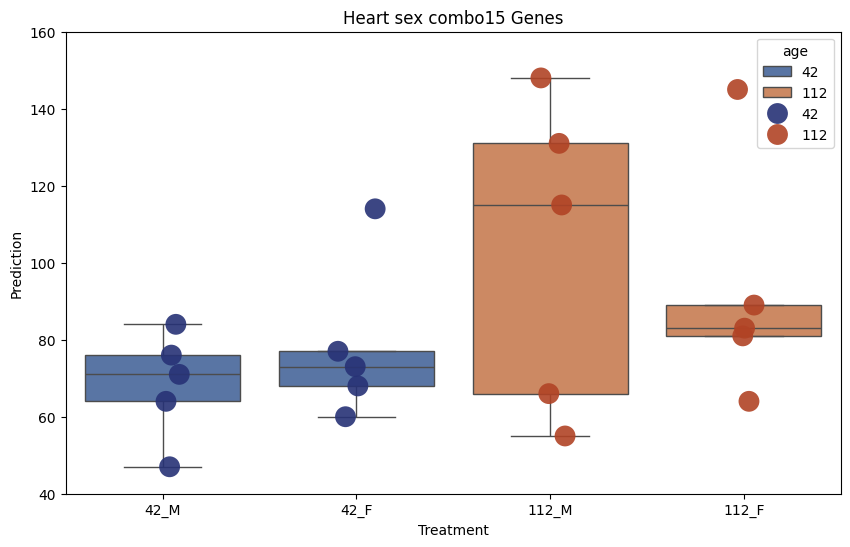

In [ ]:
ordered_x = [
    '42_M', '42_F',
    '112_M', '112_F'
]


# Create the box plot
plt.figure(figsize=(10, 6))
box = sns.boxplot(x='age_sex', y='prediction', hue='age', data=df_intervention_test_pred, palette='deep', showfliers = False,
    order = ordered_x)

# Add data points

custom_palette = ['#273276', '#B14325']  # Use desired hex color codes

# Add data points with custom colors
strip = sns.stripplot(
    x='age_sex',
    y='prediction',
    hue='age',
    data=df_intervention_test_pred,
    palette=custom_palette,  # Custom color palette
    dodge=False,
    alpha=0.9,
    jitter=True,
    size=15,
    order = ordered_x
)

# Remove the legend if not needed
#strip.legend_.remove()

# Customize the plot
plt.title("".join([f'{select_tissue} sex combo', str(gene_number), ' Genes']))
plt.xlabel('Treatment')
plt.ylabel('Prediction')

# Set y-axis limits
plt.ylim(40, 160)

# Remove the grid
plt.grid(False)

# Show the plot
plt.show()

##### Try several gene set sizes

In [ ]:
# Set up ordered x-axis for plots
ordered_x = [
    '42_M', '42_F',
    '112_M', '112_F'
]

# Custom color palette
custom_palette = ['#273276', '#B14325']

# Directory setup
os.makedirs("./predictions", exist_ok=True)
os.makedirs("./plots", exist_ok=True)

# Dictionary to store prediction DataFrames if needed later
all_predictions = {}

# Loop through gene numbers
for gene_number in range(5, 101, 5):
    print(f"Running prediction for top {gene_number} genes...")

    df_intervention_test_pred = pd.DataFrame(index=df_intervention_test.index, columns=["prediction"])

    for sample in df_intervention_test.index.tolist():
        reference_df = pd.read_csv(f"./{select_tissue}_nocalib/reference/killifish_{select_tissue}_nocalib_reference_sexcombo", sep="\t", index_col=0)
        top_genes = reference_df["spearman_rank"].abs().nlargest(gene_number).index.tolist()

        total_reads_sample = df_intervention_test_counts.loc[sample].sum()
        list_of_profile_probabilities_per_age = []

        for age in new_age_steps:
            log_probs = []
            for gene in top_genes:
                gene_frequency = reference_df.loc[gene, str(age)]
                gene_frequency = max(gene_frequency, 1e-10)  # Ensure >0

                expected = gene_frequency * total_reads_sample
                observed = df_intervention_test_counts.loc[sample, gene]

                poisson_prob = poisson.pmf(k=observed, mu=expected)
                poisson_prob = max(poisson_prob, 0.001)

                log_probs.append(np.log(poisson_prob))

            list_of_profile_probabilities_per_age.append(np.sum(log_probs))

        age_probability_df = pd.DataFrame({"Pr": list_of_profile_probabilities_per_age}, index=new_age_steps)
        max_probability_age = round(float(age_probability_df.idxmax().iloc[0]), 2)
        df_intervention_test_pred.loc[sample, "prediction"] = max_probability_age

    # Add metadata
    df_intervention_test_pred["age"] = df_intervention_test["age"].tolist()
    df_intervention_test_pred["sex"] = df_intervention_test["sex"].tolist()


    df_intervention_test_pred["age_sex"] = (
        df_intervention_test_pred["age"].astype(str) + "_" +
        df_intervention_test_pred["sex"].astype(str)
    )

    # Save predictions
    all_predictions[gene_number] = df_intervention_test_pred.copy()
    df_intervention_test_pred.to_csv(f"./predictions/{select_tissue}_nocalib_sexcombo_age_preds_top_{gene_number}_genes.tsv", sep="\t")

    # --- Plot ---
    plt.figure(figsize=(10, 6))

    box = sns.boxplot(
        x='age_sex',
        y='prediction',
        hue='age',
        data=df_intervention_test_pred,
        palette='deep',
        showfliers=False,
        order=ordered_x
    )

    strip = sns.stripplot(
        x='age_sex',
        y='prediction',
        hue='age',
        data=df_intervention_test_pred,
        palette=custom_palette,
        dodge=False,
        alpha=0.9,
        jitter=True,
        size=15,
        order=ordered_x
    )

    # Remove duplicate legend
    strip.legend_.remove()

    plt.title(f"Brain sex combo {gene_number} Genes")
    plt.xlabel('Treatment')
    plt.ylabel('Prediction')
    plt.xticks(rotation=45, ha='right')
    plt.ylim(40, 160)
    plt.grid(False)

    # Save plot
    plt.savefig(f"./plots/xu_{select_tissue}_nocalib_sexcombo_top_{gene_number}_genes.svg", dpi=300, bbox_inches="tight")
    plt.close()

    print(f"Saved plot and prediction for {gene_number} genes.\n")


Running prediction for top 5 genes...
Saved plot and prediction for 5 genes.

Running prediction for top 10 genes...
Saved plot and prediction for 10 genes.

Running prediction for top 15 genes...
Saved plot and prediction for 15 genes.

Running prediction for top 20 genes...
Saved plot and prediction for 20 genes.

Running prediction for top 25 genes...
Saved plot and prediction for 25 genes.

Running prediction for top 30 genes...
Saved plot and prediction for 30 genes.

Running prediction for top 35 genes...
Saved plot and prediction for 35 genes.

Running prediction for top 40 genes...
Saved plot and prediction for 40 genes.

Running prediction for top 45 genes...
Saved plot and prediction for 45 genes.

Running prediction for top 50 genes...
Saved plot and prediction for 50 genes.

Running prediction for top 55 genes...
Saved plot and prediction for 55 genes.

Running prediction for top 60 genes...
Saved plot and prediction for 60 genes.

Running prediction for top 65 genes...
Sav

##### plot stability of preds

/tmp/ipython-input-27-687787612.py:64: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
/tmp/ipython-input-27-687787612.py:64: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
/tmp/ipython-input-27-687787612.py:64: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
/tmp/ipython-input-27-687787612.py:64: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


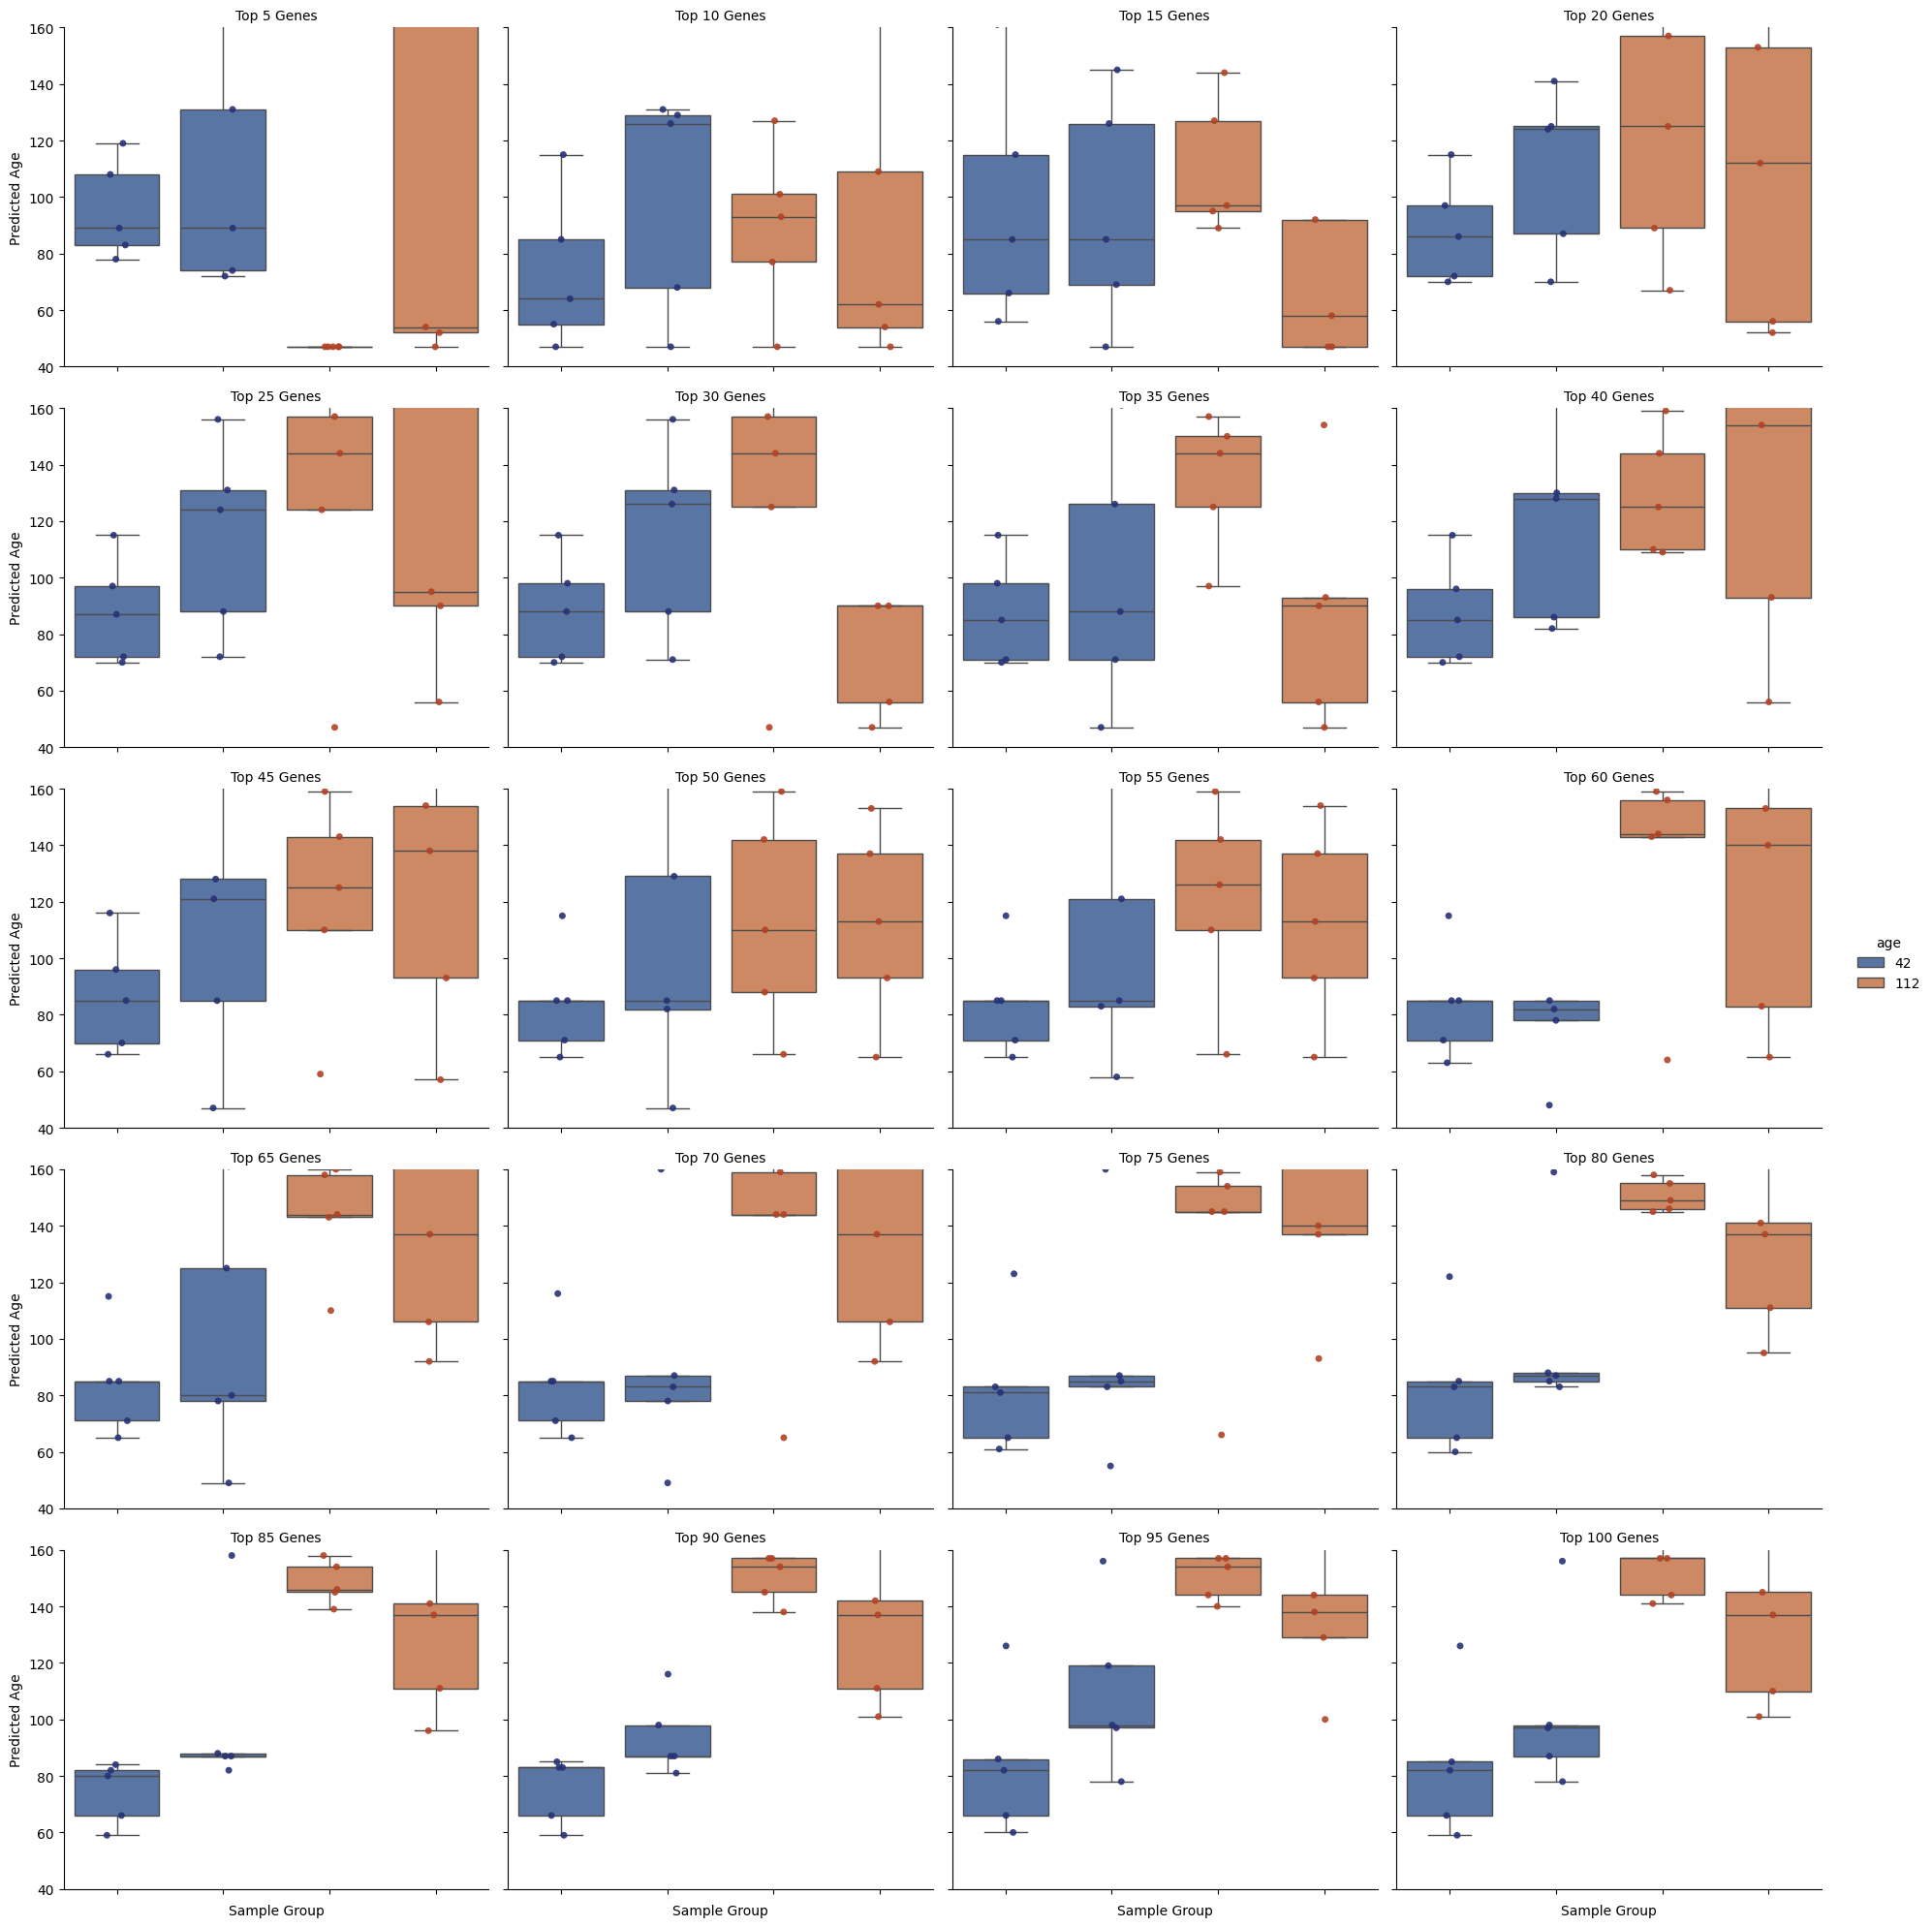

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import os

# Ordered x-axis
ordered_x = [
    '42_M', '42_F',
    '112_M', '112_F'
]

# Custom palette
custom_palette = ['#273276', '#B14325']

# Load all prediction files
all_predictions_list = []

for gene_number in range(5, 101, 5):
    file_path = f"./predictions/{select_tissue}_nocalib_sexcombo_age_preds_top_{gene_number}_genes.tsv"
    if os.path.exists(file_path):
        df = pd.read_csv(file_path, sep="\t", index_col=0)
        df["gene_number"] = str(gene_number)  # for cleaner facet titles
        all_predictions_list.append(df)
    else:
        print(f"Warning: {file_path} not found. Skipping.")

# Concatenate into a single DataFrame
all_predictions_df = pd.concat(all_predictions_list, axis=0)

# Plot with seaborn FacetGrid (catplot)
g = sns.catplot(
    data=all_predictions_df,
    x="age_sex",
    y="prediction",
    hue="age",
    col="gene_number",
    col_wrap=4,
    kind="box",
    palette='deep',
    order=ordered_x,
    height=4,
    aspect=1.2,
    showfliers=False
)

# Overlay stripplot for better visualization
for ax, gene_number in zip(g.axes.flat, all_predictions_df["gene_number"].unique()):
    subset = all_predictions_df[all_predictions_df["gene_number"] == gene_number]
    sns.stripplot(
        x='age_sex',
        y='prediction',
        hue='age',
        data=subset,
        palette=custom_palette,
        dodge=False,
        alpha=0.9,
        jitter=True,
        size=5,
        order=ordered_x,
        ax=ax,
        legend=False
    )
    ax.set_title(f"Top {gene_number} Genes")
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
    ax.set_ylim(40, 160)

g.set_axis_labels("Sample Group", "Predicted Age")
g.set_titles("Top {col_name} Genes")
g.tight_layout()
plt.savefig(f"./plots/{select_tissue}_nocalib_sex_combo_faceted_predictions_by_gene_number.svg", dpi=300, bbox_inches="tight")
plt.show()


### Male only

In [ ]:
df_intervention_combo.head(2)

,nadsyn1,dnaja3,f2r,LOC107382877,fezf1,srbd1,LOC107373267,LOC107384240,serp1,scarb2,...,umodl1,cryz,LOC107397181,pelo,mrpl35,tissue,AGE,sex,training,age
Heart_20,131,274,111,126,0,79,0,4,156,475,...,4,40,1966,197,60,Heart,16w,F,No,112
Heart_19,201,448,153,158,0,72,2,0,298,470,...,6,38,2149,152,100,Heart,16w,F,No,112


In [ ]:
df_intervention_male = df_intervention_combo.loc[
    (df_intervention_combo.iloc[:, -3] == 'M')
]

In [ ]:
# all_samples = df_intervention_male.index
# all_samples

# random.seed(123)

# # Separate the samples
# young_samples = [s for s in all_samples if s in df_intervention_male.index and df_intervention_male.loc[s, 'age'] == 42]
# old_samples = [s for s in all_samples if s in df_intervention_male.index and df_intervention_male.loc[s, 'age'] ==  112]

# # Randomly sample 2 from each
# random_young = random.sample(young_samples, 2)
# random_old = random.sample(old_samples, 2)

# # Combine the result
# random_subset = random_young + random_old

# #select your training samples
# select_train_samples = random_subset

# # Select rows in df_intervention_age_counts_female where index is in female_samples
# df_intervention_train = df_intervention_male.loc[
#     df_intervention_male.index.isin(select_train_samples)
# ]

# df_intervention_train

,nadsyn1,dnaja3,f2r,LOC107382877,fezf1,srbd1,LOC107373267,LOC107384240,serp1,scarb2,...,umodl1,cryz,LOC107397181,pelo,mrpl35,tissue,AGE,sex,training,age
brain_5,66,141,32,111,12,139,0,0,90,307,...,4,34,611,143,20,Brain,6w,M,No,42
brain_3,119,235,100,160,6,139,4,0,152,392,...,6,42,1091,118,50,Brain,6w,M,No,42
brain_15,107,142,64,126,22,134,0,0,92,409,...,10,16,843,125,30,Brain,16w,M,No,112
brain_12,81,144,50,89,23,144,2,0,106,392,...,4,8,852,120,48,Brain,16w,M,No,112


In [ ]:
# get your testing samples
#all not in select_train_samples
all_samples = df_intervention_male.index
test_samples = all_samples
test_samples

Index(['Heart_15', 'Heart_14', 'Heart_13', 'Heart_12', 'Heart_11', 'Heart_5',
       'Heart_4', 'Heart_3', 'Heart_2', 'Heart_1'],
      dtype='object')

In [ ]:
# Select rows in df_intervention_age_counts_female where index is in female_samples
df_intervention_test = df_intervention_male.loc[
    df_intervention_male.index.isin(test_samples)
]

df_intervention_test

,nadsyn1,dnaja3,f2r,LOC107382877,fezf1,srbd1,LOC107373267,LOC107384240,serp1,scarb2,...,umodl1,cryz,LOC107397181,pelo,mrpl35,tissue,AGE,sex,training,age
Heart_15,173,508,142,158,0,112,2,0,516,464,...,14,34,2399,206,111,Heart,16w,M,No,112
Heart_14,185,602,184,136,2,71,0,0,276,574,...,12,46,3706,368,96,Heart,16w,M,No,112
Heart_13,150,388,222,158,2,74,0,0,226,471,...,2,30,2462,134,70,Heart,16w,M,No,112
Heart_12,217,441,77,189,2,113,0,0,284,557,...,12,34,2338,226,130,Heart,16w,M,No,112
Heart_11,174,466,118,110,6,113,4,0,340,495,...,8,44,1534,246,136,Heart,16w,M,No,112
Heart_5,186,383,62,88,2,114,0,0,334,541,...,8,62,2550,254,75,Heart,6w,M,No,42
Heart_4,193,489,54,82,8,86,0,0,552,449,...,4,74,2165,355,138,Heart,6w,M,No,42
Heart_3,136,523,72,88,4,84,0,0,354,378,...,2,56,2278,320,79,Heart,6w,M,No,42
Heart_2,218,524,48,148,6,78,0,0,436,440,...,6,60,2436,282,90,Heart,6w,M,No,42
Heart_1,155,390,42,48,4,51,0,0,288,246,...,8,46,1662,200,60,Heart,6w,M,No,42


##### transcriptome reference

In [ ]:
# Specify the path for the new directory for the tissue
directory_path = f"./{select_tissue}_nocalib/male"

# Create the directory
os.mkdir(directory_path)

In [ ]:
tissue_df_counts.head(1)

,a1cf,aaas,aacs,aadat,aaed1,aagab,aak1,aamdc,aamp,aar2,...,zufsp,zw10,zwilch,zyg11b,zyx,zzef1,zzz3,sex,tissue,age
A13_2,30,591,227,627,749,896,1293,1167,781,617,...,249,1493,10,965,4511,265,630,M,Heart,162


In [ ]:
#select raw counts
tissue_df_counts = combined_df.loc[
    (combined_df.iloc[:, -2] == select_tissue) &
     (combined_df.iloc[:, -3] == 'M')
]
tissue_df_counts.head(5)

,a1cf,aaas,aacs,aadat,aaed1,aagab,aak1,aamdc,aamp,aar2,...,zufsp,zw10,zwilch,zyg11b,zyx,zzef1,zzz3,sex,tissue,age
A13_2,30,591,227,627,749,896,1293,1167,781,617,...,249,1493,10,965,4511,265,630,M,Heart,162
A14_2,2,695,245,613,499,833,1037,1386,706,646,...,100,1299,28,715,5683,219,444,M,Heart,103
A15_2,0,712,268,539,435,754,1479,1006,732,584,...,180,1690,94,1296,7531,334,454,M,Heart,103
B13_2,16,474,176,394,360,562,739,1450,435,524,...,154,1187,42,666,3405,184,367,M,Heart,134
B14_2,118,985,353,692,816,932,1622,1390,863,928,...,262,2512,167,1303,7114,466,630,M,Heart,47


In [ ]:
# df_intervention_train = df_intervention_train[tissue_df_counts.columns]
# df_intervention_train.head(2)

NameError: name 'df_intervention_train' is not defined

In [ ]:
atlas_plus_intervention = tissue_df_counts
atlas_plus_intervention.head(3)

,a1cf,aaas,aacs,aadat,aaed1,aagab,aak1,aamdc,aamp,aar2,...,zufsp,zw10,zwilch,zyg11b,zyx,zzef1,zzz3,sex,tissue,age
A13_2,30,591,227,627,749,896,1293,1167,781,617,...,249,1493,10,965,4511,265,630,M,Heart,162
A14_2,2,695,245,613,499,833,1037,1386,706,646,...,100,1299,28,715,5683,219,444,M,Heart,103
A15_2,0,712,268,539,435,754,1479,1006,732,584,...,180,1690,94,1296,7531,334,454,M,Heart,103


In [ ]:
# #check cols ordered the same
# df_intervention_test = df_intervention_test[tissue_df_counts.columns]
# df_intervention_test.head(2)

In [ ]:
tissue_age_days_value_counts = atlas_plus_intervention["age"].value_counts().index.tolist()

In [ ]:
age_steps = sorted(tissue_age_days_value_counts)

print(age_steps)

[47, 49, 52, 75, 77, 78, 102, 103, 133, 134, 147, 152, 161, 162]


In [ ]:
atlas_plus_intervention_age = atlas_plus_intervention.drop(atlas_plus_intervention.columns[[-2, -3]], axis=1)
atlas_plus_intervention_age.head(2)

,a1cf,aaas,aacs,aadat,aaed1,aagab,aak1,aamdc,aamp,aar2,...,zswim7,zswim8,zufsp,zw10,zwilch,zyg11b,zyx,zzef1,zzz3,age
A13_2,30,591,227,627,749,896,1293,1167,781,617,...,79,1736,249,1493,10,965,4511,265,630,162
A14_2,2,695,245,613,499,833,1037,1386,706,646,...,104,1456,100,1299,28,715,5683,219,444,103


In [ ]:
#sample generation
for sample in atlas_plus_intervention_age.index.tolist():

    new_df = atlas_plus_intervention_age.drop(sample)

    new_df.to_csv(f"./{select_tissue}_nocalib/male/{select_tissue}_nocalib_male_sample_{sample}.csv", sep="\t")

In [ ]:
new_age_steps = np.arange(min(age_steps), max(age_steps)+1, 1)

In [ ]:
# Specify the path for the new directory for the tissue
directory_path = f"./{select_tissue}_nocalib/male/reference"

# Create the directory
os.mkdir(directory_path)

In [ ]:
transcriptome_reference(training_matrix= atlas_plus_intervention_age,
                            reference_name=f"killifish_{select_tissue}_nocalib_reference_male",
                            output_path=f"./{select_tissue}_nocalib/male/reference/",
                            age_prediction="list",
                            age_list=new_age_steps,
                            min_age=1,
                            max_age=24,
                            age_step=1,
                            tau=0.7)

/tmp/ipython-input-6-2002720175.py:41: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho, p = spearmanr(age_training, gene_frequency)



Reference model dataset written to './Heart_nocalib/male/reference/killifish_Heart_nocalib_reference_male'
Report file generated at './Heart_nocalib/male/reference/killifish_Heart_nocalib_reference_male.report.txt'
-----------------------------------------------------



Time to run construct reference: 147.959 seconds

The reference is constructed and saved!


,47,48,49,50,51,52,53,54,55,56,...,155,156,157,158,159,160,161,162,spearman_rank,p_value
Gene,,,,,,,,,,,,,,,,,,,,,
a1cf,3.256156e-07,3.290889e-07,3.323764e-07,3.354706e-07,3.383659e-07,3.410572e-07,3.435407e-07,3.458160e-07,3.478841e-07,3.497463e-07,...,5.353923e-07,5.499168e-07,5.645640e-07,5.793414e-07,5.942560e-07,6.093146e-07,6.245235e-07,6.398902e-07,-0.006282,0.972778
aaas,2.750428e-05,2.737081e-05,2.723799e-05,2.710589e-05,2.697456e-05,2.684408e-05,2.671449e-05,2.658580e-05,2.645802e-05,2.633112e-05,...,1.978739e-05,1.974338e-05,1.969934e-05,1.965530e-05,1.961128e-05,1.956728e-05,1.952332e-05,1.947942e-05,-0.643753,0.000070
aacs,9.961288e-06,9.936910e-06,9.912219e-06,9.887222e-06,9.861934e-06,9.836371e-06,9.810550e-06,9.784475e-06,9.758151e-06,9.731580e-06,...,7.975747e-06,8.000622e-06,8.026053e-06,8.052042e-06,8.078592e-06,8.105705e-06,8.133381e-06,8.161620e-06,-0.305148,0.089455
aadat,1.914884e-05,1.911132e-05,1.907438e-05,1.903804e-05,1.900229e-05,1.896710e-05,1.893245e-05,1.889832e-05,1.886473e-05,1.883166e-05,...,1.807567e-05,1.809109e-05,1.810711e-05,1.812372e-05,1.814092e-05,1.815873e-05,1.817715e-05,1.819617e-05,-0.071324,0.698082
aaed1,2.183064e-05,2.174625e-05,2.166200e-05,2.157792e-05,2.149401e-05,2.141025e-05,2.132664e-05,2.124318e-05,2.115986e-05,2.107668e-05,...,1.809741e-05,1.813315e-05,1.816939e-05,1.820613e-05,1.824338e-05,1.828112e-05,1.831935e-05,1.835807e-05,-0.346693,0.051904
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
zwilch,4.831649e-06,4.764778e-06,4.698134e-06,4.631755e-06,4.565677e-06,4.499940e-06,4.434574e-06,4.369588e-06,4.304980e-06,4.240748e-06,...,1.218414e-06,1.210853e-06,1.203426e-06,1.196139e-06,1.189000e-06,1.182014e-06,1.175189e-06,1.168532e-06,-0.599267,0.000290
zyg11b,2.973256e-05,2.971258e-05,2.969319e-05,2.967442e-05,2.965624e-05,2.963860e-05,2.962149e-05,2.960488e-05,2.958878e-05,2.957318e-05,...,2.914922e-05,2.915130e-05,2.915387e-05,2.915698e-05,2.916063e-05,2.916487e-05,2.916970e-05,2.917516e-05,0.049633,0.787345
zyx,1.824111e-04,1.826066e-04,1.828111e-04,1.830244e-04,1.832464e-04,1.834768e-04,1.837154e-04,1.839620e-04,1.842167e-04,1.844794e-04,...,1.779282e-04,1.776820e-04,1.774448e-04,1.772159e-04,1.769947e-04,1.767803e-04,1.765722e-04,1.763698e-04,-0.034191,0.852622


In [ ]:
df_intervention_test.head(1)

,nadsyn1,dnaja3,f2r,LOC107382877,fezf1,srbd1,LOC107373267,LOC107384240,serp1,scarb2,...,umodl1,cryz,LOC107397181,pelo,mrpl35,tissue,AGE,sex,training,age
Heart_15,173,508,142,158,0,112,2,0,516,464,...,14,34,2399,206,111,Heart,16w,M,No,112


In [ ]:
df_intervention_test_counts = df_intervention_test.drop(df_intervention_test.columns[[-2, -3,-4, -5]], axis=1)
df_intervention_test_counts.head(3)

,nadsyn1,dnaja3,f2r,LOC107382877,fezf1,srbd1,LOC107373267,LOC107384240,serp1,scarb2,...,plekhg1,LOC107373049,LOC107375201,LOC107384697,umodl1,cryz,LOC107397181,pelo,mrpl35,age
Heart_15,173,508,142,158,0,112,2,0,516,464,...,980,0,0,14,14,34,2399,206,111,112
Heart_14,185,602,184,136,2,71,0,0,276,574,...,1018,0,4,4,12,46,3706,368,96,112
Heart_13,150,388,222,158,2,74,0,0,226,471,...,1006,2,12,8,2,30,2462,134,70,112


In [ ]:
gene_number = 15
df_intervention_test_pred = pd.DataFrame(index=df_intervention_test.index, columns=["prediction"])

for sample in df_intervention_test.index.tolist():

    reference_df = pd.read_csv(f"./{select_tissue}_nocalib/male/reference/killifish_{select_tissue}_nocalib_reference_male", sep="\t", index_col=0)

    # Get top genes based on spearman correlation
    top_abs_spearman_corr = reference_df["spearman_rank"].abs().nlargest(gene_number)

    #print(top_abs_spearman_corr)

    top_genes = top_abs_spearman_corr.index.tolist()

    # Save the DataFrame to a CSV file
    # df_top_genes = pd.DataFrame(top_genes, columns=["genes"])
    # gene_num = "".join([str(gene_number), "genes"])
    # out_file_prefix = 'Antebi_male_pred'
    # out_file_name = "_".join([out_file_prefix, gene_num])
    # output_path = './fat/gene_sets'
    # df_top_genes.to_csv(os.path.join(output_path, out_file_name), sep="\t")
    # print(f"List has been written to {out_file_name}")

    total_reads_sample = df_intervention_test_counts.loc[sample].sum()

    list_of_profile_probabilities_per_age = []

    for age in new_age_steps:

        probability_list_one_age = []

        genes_not_defined = []

        for gene in top_genes:

            gene_frequency = reference_df.loc[gene, f"{age}"]

            if gene_frequency < 0:
                gene_frequency = 10**-10

            sample_expected_counts = gene_frequency * total_reads_sample
            sample_observed_counts = df_intervention_test_counts.loc[sample, gene]

            poisson_probability = poisson.pmf(k=sample_observed_counts, mu=sample_expected_counts)

            # Replace NaN poisson probability with a small positive value and log it
            if np.isnan(poisson_probability):
                poisson_probability = 0.001
                genes_not_defined.append(gene)

            # Replace zero poisson probability with 0.001
            if poisson_probability == 0:
                poisson_probability = 0.001

            logP = np.log(poisson_probability)

            probability_list_one_age.append(logP)

        list_of_profile_probabilities_per_age.append(np.sum(probability_list_one_age))

    # Transform into dataframe with age steps
    age_probability_df = pd.DataFrame({"Pr": list_of_profile_probabilities_per_age}, index=new_age_steps)

    # Compute highest likelihood age among age steps
    max_probability_age = round(float(age_probability_df.idxmax().iloc[0]), 2)

    # Compute highest maximum probability
    max_probability = float(age_probability_df["Pr"].max())

    df_intervention_test_pred.loc[sample, "prediction"] = max_probability_age



print(df_intervention_test_pred)

         prediction
Heart_15       48.0
Heart_14       55.0
Heart_13       62.0
Heart_12      118.0
Heart_11      132.0
Heart_5        92.0
Heart_4        92.0
Heart_3        53.0
Heart_2        83.0
Heart_1        92.0


In [ ]:
df_intervention_test_pred["age"] = df_intervention_test["age"].tolist()
df_intervention_test_pred["sex"] = df_intervention_test["sex"].tolist()


df_intervention_test_pred["age_sex"] = (
    df_intervention_test_pred["age"].astype(str) + "_" +
    df_intervention_test_pred["sex"].astype(str)
)

df_intervention_test_pred

,prediction,age,sex,age_sex
Heart_15,48.0,112,M,112_M
Heart_14,55.0,112,M,112_M
Heart_13,62.0,112,M,112_M
Heart_12,118.0,112,M,112_M
Heart_11,132.0,112,M,112_M
Heart_5,92.0,42,M,42_M
Heart_4,92.0,42,M,42_M
Heart_3,53.0,42,M,42_M
Heart_2,83.0,42,M,42_M
Heart_1,92.0,42,M,42_M


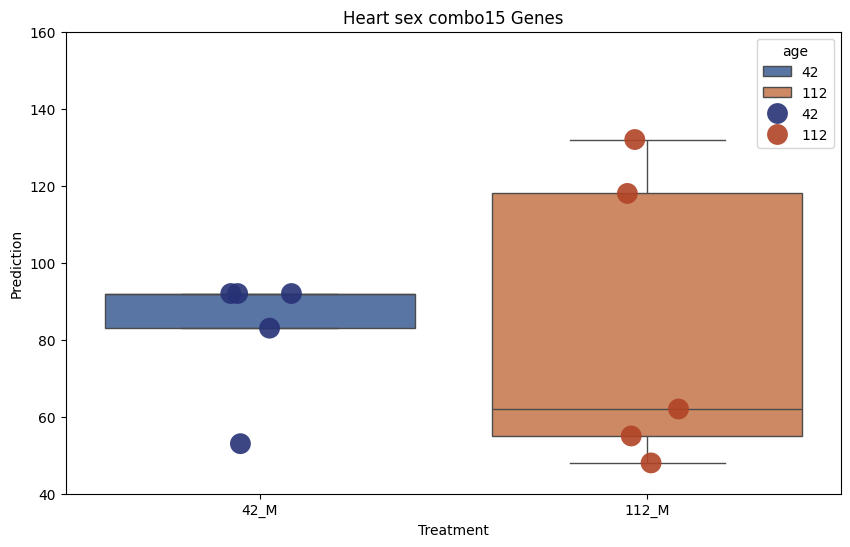

In [ ]:
ordered_x = [
    '42_M','112_M'
]


# Create the box plot
plt.figure(figsize=(10, 6))
box = sns.boxplot(x='age_sex', y='prediction', hue='age', data=df_intervention_test_pred, palette='deep', showfliers = False,
    order = ordered_x)

# Add data points

custom_palette = ['#273276', '#B14325']  # Use desired hex color codes

# Add data points with custom colors
strip = sns.stripplot(
    x='age_sex',
    y='prediction',
    hue='age',
    data=df_intervention_test_pred,
    palette=custom_palette,  # Custom color palette
    dodge=False,
    alpha=0.9,
    jitter=True,
    size=15,
    order = ordered_x
)

# Remove the legend if not needed
#strip.legend_.remove()

# Customize the plot
plt.title("".join([f'{select_tissue} sex combo', str(gene_number), ' Genes']))
plt.xlabel('Treatment')
plt.ylabel('Prediction')

# Set y-axis limits
plt.ylim(40, 160)

# Remove the grid
plt.grid(False)

# Show the plot
plt.show()

##### Try several gene set sizes

In [ ]:
# Set up ordered x-axis for plots
ordered_x = [
    '42_M',
    '112_M'
]

# Custom color palette
custom_palette = ['#273276', '#B14325']

# Directory setup
os.makedirs("./predictions", exist_ok=True)
os.makedirs("./plots", exist_ok=True)

# Dictionary to store prediction DataFrames if needed later
all_predictions = {}

# Loop through gene numbers
for gene_number in range(5, 101, 5):
    print(f"Running prediction for top {gene_number} genes...")

    df_intervention_test_pred = pd.DataFrame(index=df_intervention_test.index, columns=["prediction"])

    for sample in df_intervention_test.index.tolist():
        reference_df = pd.read_csv(f"./{select_tissue}_nocalib/male/reference/killifish_{select_tissue}_nocalib_reference_male", sep="\t", index_col=0)
        top_genes = reference_df["spearman_rank"].abs().nlargest(gene_number).index.tolist()

        total_reads_sample = df_intervention_test_counts.loc[sample].sum()
        list_of_profile_probabilities_per_age = []

        for age in new_age_steps:
            log_probs = []
            for gene in top_genes:
                gene_frequency = reference_df.loc[gene, str(age)]
                gene_frequency = max(gene_frequency, 1e-10)  # Ensure >0

                expected = gene_frequency * total_reads_sample
                observed = df_intervention_test_counts.loc[sample, gene]

                poisson_prob = poisson.pmf(k=observed, mu=expected)
                poisson_prob = max(poisson_prob, 0.001)

                log_probs.append(np.log(poisson_prob))

            list_of_profile_probabilities_per_age.append(np.sum(log_probs))

        age_probability_df = pd.DataFrame({"Pr": list_of_profile_probabilities_per_age}, index=new_age_steps)
        max_probability_age = round(float(age_probability_df.idxmax().iloc[0]), 2)
        df_intervention_test_pred.loc[sample, "prediction"] = max_probability_age

    # Add metadata
    df_intervention_test_pred["age"] = df_intervention_test["age"].tolist()
    df_intervention_test_pred["sex"] = df_intervention_test["sex"].tolist()


    df_intervention_test_pred["age_sex"] = (
        df_intervention_test_pred["age"].astype(str) + "_" +
        df_intervention_test_pred["sex"].astype(str)
    )

    # Save predictions
    all_predictions[gene_number] = df_intervention_test_pred.copy()
    df_intervention_test_pred.to_csv(f"./predictions/{select_tissue}_nocalib_age_maleOnly_preds_top_{gene_number}_genes.tsv", sep="\t")

    # --- Plot ---
    plt.figure(figsize=(10, 6))

    box = sns.boxplot(
        x='age_sex',
        y='prediction',
        hue='age',
        data=df_intervention_test_pred,
        palette='deep',
        showfliers=False,
        order=ordered_x
    )

    strip = sns.stripplot(
        x='age_sex',
        y='prediction',
        hue='age',
        data=df_intervention_test_pred,
        palette=custom_palette,
        dodge=False,
        alpha=0.9,
        jitter=True,
        size=15,
        order=ordered_x
    )

    # Remove duplicate legend
    strip.legend_.remove()

    plt.title(f"{select_tissue}sex combo {gene_number} Genes")
    plt.xlabel('Treatment')
    plt.ylabel('Prediction')
    plt.xticks(rotation=45, ha='right')
    plt.ylim(40, 160)
    plt.grid(False)

    # Save plot
    plt.savefig(f"./plots/xu_{select_tissue}_nocalib_maleOnly_top_{gene_number}_genes.svg", dpi=300, bbox_inches="tight")
    plt.close()

    print(f"Saved plot and prediction for {gene_number} genes.\n")


Running prediction for top 5 genes...
Saved plot and prediction for 5 genes.

Running prediction for top 10 genes...
Saved plot and prediction for 10 genes.

Running prediction for top 15 genes...
Saved plot and prediction for 15 genes.

Running prediction for top 20 genes...
Saved plot and prediction for 20 genes.

Running prediction for top 25 genes...
Saved plot and prediction for 25 genes.

Running prediction for top 30 genes...
Saved plot and prediction for 30 genes.

Running prediction for top 35 genes...
Saved plot and prediction for 35 genes.

Running prediction for top 40 genes...
Saved plot and prediction for 40 genes.

Running prediction for top 45 genes...
Saved plot and prediction for 45 genes.

Running prediction for top 50 genes...
Saved plot and prediction for 50 genes.

Running prediction for top 55 genes...
Saved plot and prediction for 55 genes.

Running prediction for top 60 genes...
Saved plot and prediction for 60 genes.

Running prediction for top 65 genes...
Sav

##### plot stability of preds

/tmp/ipython-input-51-2800599868.py:64: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
/tmp/ipython-input-51-2800599868.py:64: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
/tmp/ipython-input-51-2800599868.py:64: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
/tmp/ipython-input-51-2800599868.py:64: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


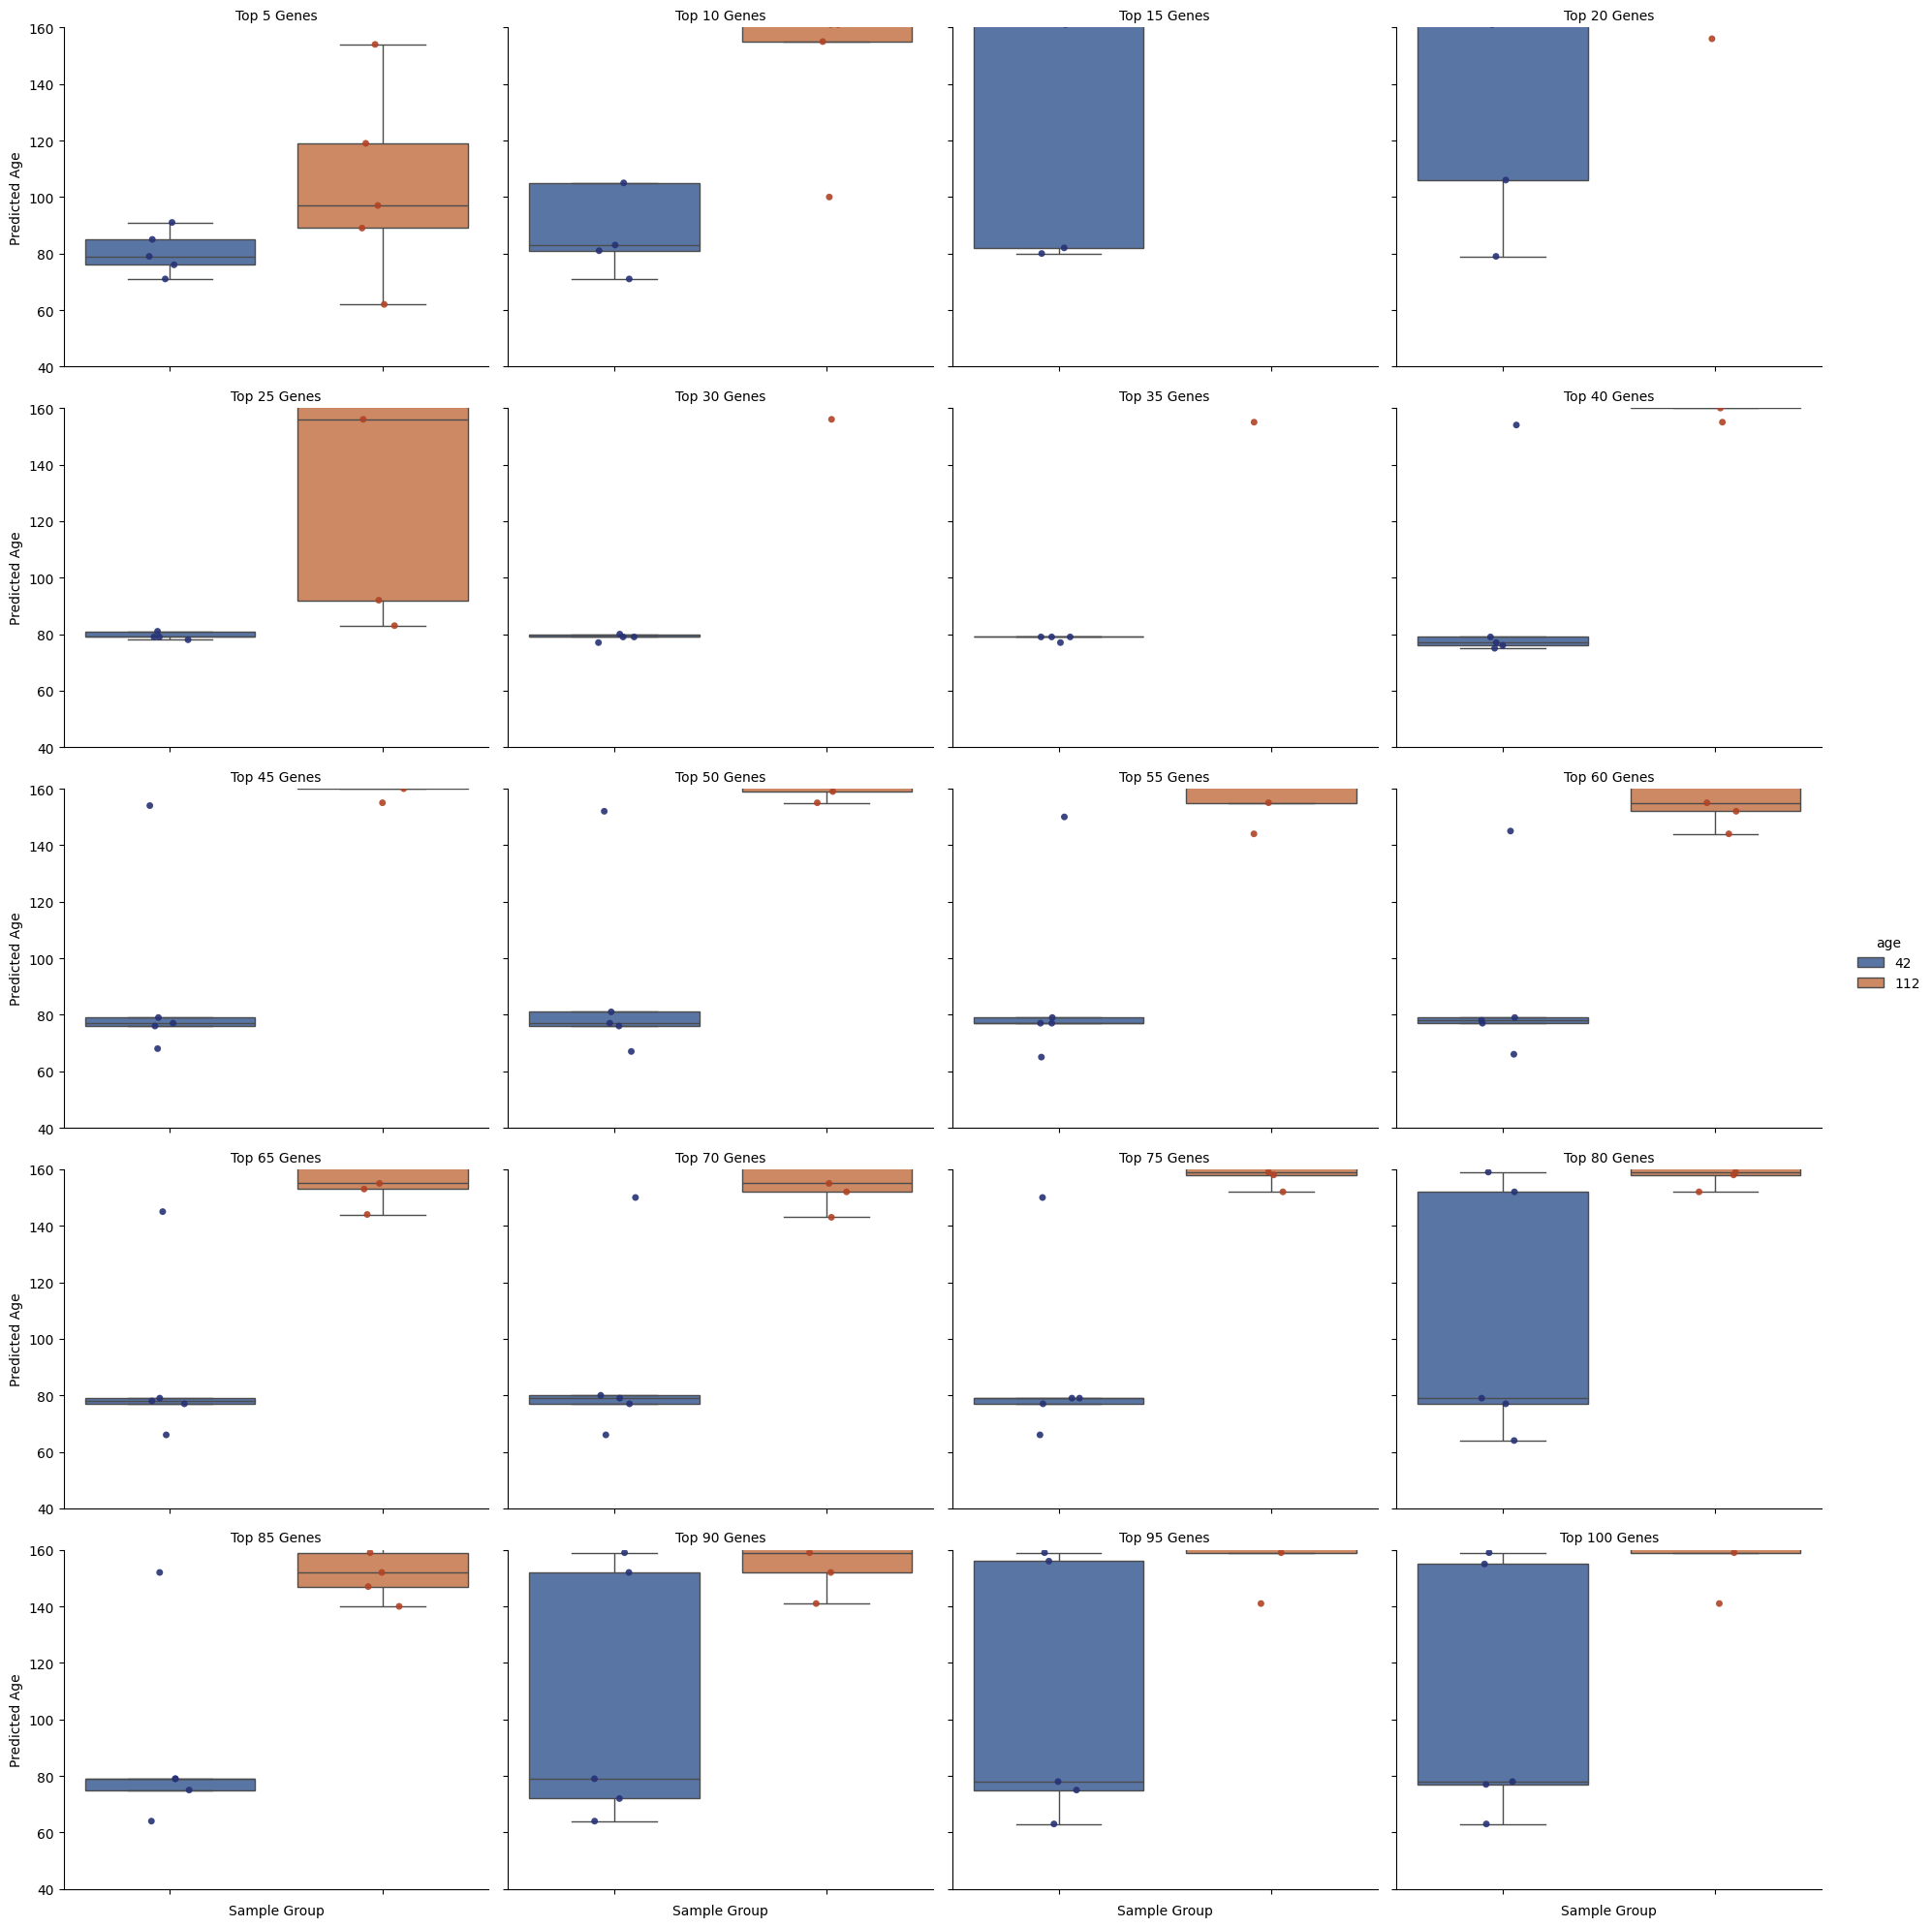

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import os

# Ordered x-axis
ordered_x = [
    '42_M',
    '112_M'
]

# Custom palette
custom_palette = ['#273276', '#B14325']

# Load all prediction files
all_predictions_list = []

for gene_number in range(5, 101, 5):
    file_path = f"./predictions/{select_tissue}_nocalib_age_maleOnly_preds_top_{gene_number}_genes.tsv"
    if os.path.exists(file_path):
        df = pd.read_csv(file_path, sep="\t", index_col=0)
        df["gene_number"] = str(gene_number)  # for cleaner facet titles
        all_predictions_list.append(df)
    else:
        print(f"Warning: {file_path} not found. Skipping.")

# Concatenate into a single DataFrame
all_predictions_df = pd.concat(all_predictions_list, axis=0)

# Plot with seaborn FacetGrid (catplot)
g = sns.catplot(
    data=all_predictions_df,
    x="age_sex",
    y="prediction",
    hue="age",
    col="gene_number",
    col_wrap=4,
    kind="box",
    palette='deep',
    order=ordered_x,
    height=4,
    aspect=1.2,
    showfliers=False
)

# Overlay stripplot for better visualization
for ax, gene_number in zip(g.axes.flat, all_predictions_df["gene_number"].unique()):
    subset = all_predictions_df[all_predictions_df["gene_number"] == gene_number]
    sns.stripplot(
        x='age_sex',
        y='prediction',
        hue='age',
        data=subset,
        palette=custom_palette,
        dodge=False,
        alpha=0.9,
        jitter=True,
        size=5,
        order=ordered_x,
        ax=ax,
        legend=False
    )
    ax.set_title(f"Top {gene_number} Genes")
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
    ax.set_ylim(40, 160)

g.set_axis_labels("Sample Group", "Predicted Age")
g.set_titles("Top {col_name} Genes")
g.tight_layout()
plt.savefig(f"./plots/{select_tissue}_nocalib_maleOnly_faceted_predictions_by_gene_number.svg", dpi=300, bbox_inches="tight")
plt.show()


### Female only

In [ ]:
df_intervention_combo.head(2)

,nadsyn1,dnaja3,f2r,LOC107382877,fezf1,srbd1,LOC107373267,LOC107384240,serp1,scarb2,...,umodl1,cryz,LOC107397181,pelo,mrpl35,tissue,AGE,sex,training,age
Heart_20,131,274,111,126,0,79,0,4,156,475,...,4,40,1966,197,60,Heart,16w,F,No,112
Heart_19,201,448,153,158,0,72,2,0,298,470,...,6,38,2149,152,100,Heart,16w,F,No,112


In [ ]:
df_intervention_female = df_intervention_combo.loc[
    (df_intervention_combo.iloc[:, -3] == 'F')
]

In [ ]:
# all_samples = df_intervention_female.index
# all_samples

# random.seed(123)

# # Separate the samples
# young_samples = [s for s in all_samples if s in df_intervention_female.index and df_intervention_female.loc[s, 'age'] == 42]
# old_samples = [s for s in all_samples if s in df_intervention_female.index and df_intervention_female.loc[s, 'age'] ==  112]

# # Randomly sample 2 from each
# random_young = random.sample(young_samples, 2)
# random_old = random.sample(old_samples, 2)

# # Combine the result
# random_subset = random_young + random_old

# #select your training samples
# select_train_samples = random_subset

# # Select rows in df_intervention_age_counts_female where index is in female_samples
# df_intervention_train = df_intervention_female.loc[
#     df_intervention_female.index.isin(select_train_samples)
# ]

# df_intervention_train

,nadsyn1,dnaja3,f2r,LOC107382877,fezf1,srbd1,LOC107373267,LOC107384240,serp1,scarb2,...,umodl1,cryz,LOC107397181,pelo,mrpl35,tissue,AGE,sex,training,age
brain_10,59,200,66,148,29,175,0,0,67,388,...,10,30,898,95,37,Brain,6w,F,No,42
brain_8,96,208,70,150,24,179,4,0,116,326,...,10,32,1078,142,38,Brain,6w,F,No,42
brain_20,19,43,15,22,2,28,0,0,28,88,...,0,20,210,32,6,Brain,16w,F,No,112
brain_17,100,104,63,146,12,150,0,0,70,386,...,8,18,586,127,24,Brain,16w,F,No,112


In [ ]:
# get your testing samples
#all not in select_train_samples
all_samples = df_intervention_female.index
test_samples = all_samples
test_samples

Index(['Heart_20', 'Heart_19', 'Heart_18', 'Heart_17', 'Heart_16', 'Heart_10',
       'Heart_9', 'Heart_8', 'Heart_7', 'Heart_6'],
      dtype='object')

In [ ]:
# Select rows in df_intervention_age_counts_female where index is in female_samples
df_intervention_test = df_intervention_female.loc[
    df_intervention_female.index.isin(test_samples)
]

df_intervention_test

,nadsyn1,dnaja3,f2r,LOC107382877,fezf1,srbd1,LOC107373267,LOC107384240,serp1,scarb2,...,umodl1,cryz,LOC107397181,pelo,mrpl35,tissue,AGE,sex,training,age
Heart_20,131,274,111,126,0,79,0,4,156,475,...,4,40,1966,197,60,Heart,16w,F,No,112
Heart_19,201,448,153,158,0,72,2,0,298,470,...,6,38,2149,152,100,Heart,16w,F,No,112
Heart_18,187,416,193,192,0,96,0,4,187,567,...,16,42,2441,249,85,Heart,16w,F,No,112
Heart_17,159,334,86,118,0,90,0,0,340,473,...,6,34,1734,166,88,Heart,16w,F,No,112
Heart_16,147,351,48,84,2,50,0,0,168,376,...,6,38,1872,162,90,Heart,16w,F,No,112
Heart_10,212,426,56,126,0,112,0,0,376,591,...,4,54,2582,372,100,Heart,6w,F,No,42
Heart_9,182,438,62,112,2,111,0,0,348,669,...,2,50,3044,378,97,Heart,6w,F,No,42
Heart_8,199,516,56,92,4,148,0,0,444,430,...,6,36,2649,290,84,Heart,6w,F,No,42
Heart_7,199,444,32,132,2,76,0,0,260,432,...,0,52,2358,156,94,Heart,6w,F,No,42
Heart_6,159,416,30,102,8,66,0,0,272,406,...,14,46,2068,236,72,Heart,6w,F,No,42


##### transcriptome reference

In [ ]:
# Specify the path for the new directory for the tissue
directory_path = f"./{select_tissue}_nocalib/female/"

# Create the directory
os.mkdir(directory_path)

In [ ]:
tissue_df_counts.head(1)

,a1cf,aaas,aacs,aadat,aaed1,aagab,aak1,aamdc,aamp,aar2,...,zufsp,zw10,zwilch,zyg11b,zyx,zzef1,zzz3,sex,tissue,age
A13_2,30,591,227,627,749,896,1293,1167,781,617,...,249,1493,10,965,4511,265,630,M,Heart,162


In [ ]:
#select raw counts
tissue_df_counts = combined_df.loc[
    (combined_df.iloc[:, -2] == select_tissue) &
     (combined_df.iloc[:, -3] == 'F')
]
tissue_df_counts.head(5)

,a1cf,aaas,aacs,aadat,aaed1,aagab,aak1,aamdc,aamp,aar2,...,zufsp,zw10,zwilch,zyg11b,zyx,zzef1,zzz3,sex,tissue,age
B15_2,2,1398,460,920,1354,1140,1664,1530,1240,1164,...,262,2611,186,1295,7184,610,647,F,Heart,75
B16_2,0,679,237,684,777,950,1449,2292,780,809,...,164,1379,12,1037,8293,303,609,F,Heart,103
C15_2,0,1174,442,635,1033,1043,1435,1103,741,882,...,253,2687,234,1063,7136,568,553,F,Heart,75
D14_2,30,845,236,684,726,1123,1291,2380,855,693,...,134,1660,4,1034,7294,516,743,F,Heart,133
D16_2,2,544,482,521,638,846,1128,1123,767,585,...,150,1904,57,876,12017,419,581,F,Heart,47


In [ ]:
# df_intervention_train = df_intervention_train[tissue_df_counts.columns]
# df_intervention_train.head(2)

NameError: name 'df_intervention_train' is not defined

In [ ]:
atlas_plus_intervention = tissue_df_counts
atlas_plus_intervention.head(3)

,a1cf,aaas,aacs,aadat,aaed1,aagab,aak1,aamdc,aamp,aar2,...,zufsp,zw10,zwilch,zyg11b,zyx,zzef1,zzz3,sex,tissue,age
B15_2,2,1398,460,920,1354,1140,1664,1530,1240,1164,...,262,2611,186,1295,7184,610,647,F,Heart,75
B16_2,0,679,237,684,777,950,1449,2292,780,809,...,164,1379,12,1037,8293,303,609,F,Heart,103
C15_2,0,1174,442,635,1033,1043,1435,1103,741,882,...,253,2687,234,1063,7136,568,553,F,Heart,75


In [ ]:
# #check cols ordered the same
# df_intervention_test = df_intervention_test[tissue_df_counts.columns]
# df_intervention_test.head(2)

In [ ]:
tissue_age_days_value_counts = atlas_plus_intervention["age"].value_counts().index.tolist()

In [ ]:
age_steps = sorted(tissue_age_days_value_counts)

print(age_steps)

[47, 49, 52, 75, 77, 78, 102, 103, 133, 134, 147, 155]


In [ ]:
atlas_plus_intervention_age = atlas_plus_intervention.drop(atlas_plus_intervention.columns[[-2, -3]], axis=1)
atlas_plus_intervention_age.head(2)

,a1cf,aaas,aacs,aadat,aaed1,aagab,aak1,aamdc,aamp,aar2,...,zswim7,zswim8,zufsp,zw10,zwilch,zyg11b,zyx,zzef1,zzz3,age
B15_2,2,1398,460,920,1354,1140,1664,1530,1240,1164,...,150,3050,262,2611,186,1295,7184,610,647,75
B16_2,0,679,237,684,777,950,1449,2292,780,809,...,170,1671,164,1379,12,1037,8293,303,609,103


In [ ]:
#sample generation
for sample in atlas_plus_intervention_age.index.tolist():

    new_df = atlas_plus_intervention_age.drop(sample)

    new_df.to_csv(f"./{select_tissue}_nocalib/female/{select_tissue}_nocalib_female_sample_{sample}.csv", sep="\t")

In [ ]:
new_age_steps = np.arange(min(age_steps), max(age_steps)+1, 1)

In [ ]:
# Specify the path for the new directory for the tissue
directory_path = f"./{select_tissue}_nocalib/female/reference"

# Create the directory
os.mkdir(directory_path)

In [ ]:
transcriptome_reference(training_matrix= atlas_plus_intervention_age,
                            reference_name=f"killifish_{select_tissue}_nocalib_reference_female",
                            output_path=f"./{select_tissue}_nocalib/female/reference/",
                            age_prediction="list",
                            age_list=new_age_steps,
                            min_age=1,
                            max_age=24,
                            age_step=1,
                            tau=0.7)

/tmp/ipython-input-6-2002720175.py:41: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho, p = spearmanr(age_training, gene_frequency)



Reference model dataset written to './Heart_nocalib/female/reference/killifish_Heart_nocalib_reference_female'
Report file generated at './Heart_nocalib/female/reference/killifish_Heart_nocalib_reference_female.report.txt'
-----------------------------------------------------



Time to run construct reference: 108.528 seconds

The reference is constructed and saved!


,47,48,49,50,51,52,53,54,55,56,...,148,149,150,151,152,153,154,155,spearman_rank,p_value
Gene,,,,,,,,,,,,,,,,,,,,,
a1cf,5.310102e-07,5.219698e-07,5.129880e-07,5.040638e-07,4.951960e-07,4.863834e-07,4.776250e-07,4.689197e-07,4.602666e-07,4.516646e-07,...,1.734513e-07,1.714379e-07,1.693372e-07,1.671523e-07,1.648863e-07,1.625422e-07,1.601234e-07,1.576330e-07,-0.178247,0.427407
aaas,2.849034e-05,2.844029e-05,2.838919e-05,2.833716e-05,2.828427e-05,2.823058e-05,2.817614e-05,2.812098e-05,2.806510e-05,2.800851e-05,...,2.288957e-05,2.287867e-05,2.286763e-05,2.285651e-05,2.284537e-05,2.283426e-05,2.282323e-05,2.281234e-05,-0.248585,0.264622
aacs,9.654343e-06,9.623901e-06,9.593269e-06,9.562464e-06,9.531489e-06,9.500348e-06,9.469043e-06,9.437576e-06,9.405951e-06,9.374174e-06,...,6.295542e-06,6.263888e-06,6.232131e-06,6.200262e-06,6.168268e-06,6.136141e-06,6.103868e-06,6.071441e-06,-0.762177,0.000037
aadat,1.788335e-05,1.789271e-05,1.790204e-05,1.791135e-05,1.792067e-05,1.792998e-05,1.793931e-05,1.794864e-05,1.795799e-05,1.796736e-05,...,1.822817e-05,1.821396e-05,1.819939e-05,1.818447e-05,1.816917e-05,1.815349e-05,1.813743e-05,1.812097e-05,0.144961,0.519801
aaed1,2.721001e-05,2.707069e-05,2.693147e-05,2.679235e-05,2.665337e-05,2.651455e-05,2.637593e-05,2.623751e-05,2.609932e-05,2.596136e-05,...,1.942132e-05,1.938316e-05,1.934430e-05,1.930478e-05,1.926462e-05,1.922388e-05,1.918258e-05,1.914076e-05,-0.620048,0.002083
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
zwilch,4.294402e-06,4.246497e-06,4.198431e-06,4.150262e-06,4.102033e-06,4.053787e-06,4.005561e-06,3.957367e-06,3.909209e-06,3.861092e-06,...,9.373481e-07,9.273855e-07,9.175172e-07,9.077603e-07,8.981318e-07,8.886480e-07,8.793251e-07,8.701786e-07,-0.550399,0.007949
zyg11b,2.700401e-05,2.704151e-05,2.707916e-05,2.711694e-05,2.715482e-05,2.719279e-05,2.723083e-05,2.726893e-05,2.730710e-05,2.734533e-05,...,2.619849e-05,2.610027e-05,2.600117e-05,2.590116e-05,2.580025e-05,2.569845e-05,2.559575e-05,2.549216e-05,-0.142696,0.526414
zyx,1.731308e-04,1.742360e-04,1.753450e-04,1.764576e-04,1.775735e-04,1.786923e-04,1.798137e-04,1.809377e-04,1.820640e-04,1.831927e-04,...,2.455051e-04,2.464576e-04,2.474404e-04,2.484543e-04,2.494995e-04,2.505764e-04,2.516854e-04,2.528267e-04,0.352776,0.107322


In [ ]:
df_intervention_test.head(1)

,nadsyn1,dnaja3,f2r,LOC107382877,fezf1,srbd1,LOC107373267,LOC107384240,serp1,scarb2,...,umodl1,cryz,LOC107397181,pelo,mrpl35,tissue,AGE,sex,training,age
Heart_20,131,274,111,126,0,79,0,4,156,475,...,4,40,1966,197,60,Heart,16w,F,No,112


In [ ]:
df_intervention_test_counts = df_intervention_test.drop(df_intervention_test.columns[[-2, -3,-4, -5]], axis=1)
df_intervention_test_counts.head(3)

,nadsyn1,dnaja3,f2r,LOC107382877,fezf1,srbd1,LOC107373267,LOC107384240,serp1,scarb2,...,plekhg1,LOC107373049,LOC107375201,LOC107384697,umodl1,cryz,LOC107397181,pelo,mrpl35,age
Heart_20,131,274,111,126,0,79,0,4,156,475,...,1002,0,2,4,4,40,1966,197,60,112
Heart_19,201,448,153,158,0,72,2,0,298,470,...,1245,0,4,13,6,38,2149,152,100,112
Heart_18,187,416,193,192,0,96,0,4,187,567,...,1230,0,0,0,16,42,2441,249,85,112


In [ ]:
gene_number = 15
df_intervention_test_pred = pd.DataFrame(index=df_intervention_test.index, columns=["prediction"])

for sample in df_intervention_test.index.tolist():

    reference_df = pd.read_csv(f"./{select_tissue}_nocalib/female/reference/killifish_{select_tissue}_nocalib_reference_female", sep="\t", index_col=0)

    # Get top genes based on spearman correlation
    top_abs_spearman_corr = reference_df["spearman_rank"].abs().nlargest(gene_number)

    #print(top_abs_spearman_corr)

    top_genes = top_abs_spearman_corr.index.tolist()

    # Save the DataFrame to a CSV file
    # df_top_genes = pd.DataFrame(top_genes, columns=["genes"])
    # gene_num = "".join([str(gene_number), "genes"])
    # out_file_prefix = 'Antebi_male_pred'
    # out_file_name = "_".join([out_file_prefix, gene_num])
    # output_path = './fat/gene_sets'
    # df_top_genes.to_csv(os.path.join(output_path, out_file_name), sep="\t")
    # print(f"List has been written to {out_file_name}")

    total_reads_sample = df_intervention_test_counts.loc[sample].sum()

    list_of_profile_probabilities_per_age = []

    for age in new_age_steps:

        probability_list_one_age = []

        genes_not_defined = []

        for gene in top_genes:

            gene_frequency = reference_df.loc[gene, f"{age}"]

            if gene_frequency < 0:
                gene_frequency = 10**-10

            sample_expected_counts = gene_frequency * total_reads_sample
            sample_observed_counts = df_intervention_test_counts.loc[sample, gene]

            poisson_probability = poisson.pmf(k=sample_observed_counts, mu=sample_expected_counts)

            # Replace NaN poisson probability with a small positive value and log it
            if np.isnan(poisson_probability):
                poisson_probability = 0.001
                genes_not_defined.append(gene)

            # Replace zero poisson probability with 0.001
            if poisson_probability == 0:
                poisson_probability = 0.001

            logP = np.log(poisson_probability)

            probability_list_one_age.append(logP)

        list_of_profile_probabilities_per_age.append(np.sum(probability_list_one_age))

    # Transform into dataframe with age steps
    age_probability_df = pd.DataFrame({"Pr": list_of_profile_probabilities_per_age}, index=new_age_steps)

    # Compute highest likelihood age among age steps
    max_probability_age = round(float(age_probability_df.idxmax().iloc[0]), 2)

    # Compute highest maximum probability
    max_probability = float(age_probability_df["Pr"].max())

    df_intervention_test_pred.loc[sample, "prediction"] = max_probability_age



print(df_intervention_test_pred)

         prediction
Heart_20       68.0
Heart_19       94.0
Heart_18       69.0
Heart_17       81.0
Heart_16       66.0
Heart_10       56.0
Heart_9        47.0
Heart_8        47.0
Heart_7        47.0
Heart_6        47.0


In [ ]:
df_intervention_test_pred["age"] = df_intervention_test["age"].tolist()
df_intervention_test_pred["sex"] = df_intervention_test["sex"].tolist()


df_intervention_test_pred["age_sex"] = (
    df_intervention_test_pred["age"].astype(str) + "_" +
    df_intervention_test_pred["sex"].astype(str)
)

df_intervention_test_pred

,prediction,age,sex,age_sex
Heart_20,68.0,112,F,112_F
Heart_19,94.0,112,F,112_F
Heart_18,69.0,112,F,112_F
Heart_17,81.0,112,F,112_F
Heart_16,66.0,112,F,112_F
Heart_10,56.0,42,F,42_F
Heart_9,47.0,42,F,42_F
Heart_8,47.0,42,F,42_F
Heart_7,47.0,42,F,42_F
Heart_6,47.0,42,F,42_F


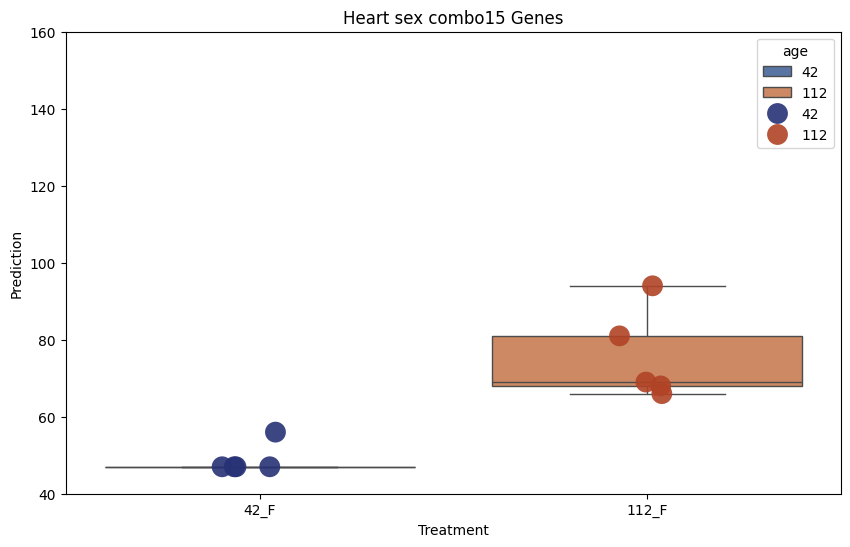

In [ ]:
ordered_x = [
'42_F',
 '112_F'
]


# Create the box plot
plt.figure(figsize=(10, 6))
box = sns.boxplot(x='age_sex', y='prediction', hue='age', data=df_intervention_test_pred, palette='deep', showfliers = False,
    order = ordered_x)

# Add data points

custom_palette = ['#273276', '#B14325']  # Use desired hex color codes

# Add data points with custom colors
strip = sns.stripplot(
    x='age_sex',
    y='prediction',
    hue='age',
    data=df_intervention_test_pred,
    palette=custom_palette,  # Custom color palette
    dodge=False,
    alpha=0.9,
    jitter=True,
    size=15,
    order = ordered_x
)

# Remove the legend if not needed
#strip.legend_.remove()

# Customize the plot
plt.title("".join([f'{select_tissue} sex combo', str(gene_number), ' Genes']))
plt.xlabel('Treatment')
plt.ylabel('Prediction')

# Set y-axis limits
plt.ylim(40, 160)

# Remove the grid
plt.grid(False)


# Show the plot
plt.show()

##### Try several gene set sizes

In [ ]:
# Set up ordered x-axis for plots
ordered_x = [
'42_F',
'112_F'
]

# Custom color palette
custom_palette = ['#273276', '#B14325']

# Directory setup
os.makedirs("./predictions", exist_ok=True)
os.makedirs("./plots", exist_ok=True)

# Dictionary to store prediction DataFrames if needed later
all_predictions = {}

# Loop through gene numbers
for gene_number in range(5, 101, 5):
    print(f"Running prediction for top {gene_number} genes...")

    df_intervention_test_pred = pd.DataFrame(index=df_intervention_test.index, columns=["prediction"])

    for sample in df_intervention_test.index.tolist():
        reference_df = pd.read_csv(f"./{select_tissue}_nocalib/female/reference/killifish_{select_tissue}_nocalib_reference_female", sep="\t", index_col=0)
        top_genes = reference_df["spearman_rank"].abs().nlargest(gene_number).index.tolist()

        total_reads_sample = df_intervention_test_counts.loc[sample].sum()
        list_of_profile_probabilities_per_age = []

        for age in new_age_steps:
            log_probs = []
            for gene in top_genes:
                gene_frequency = reference_df.loc[gene, str(age)]
                gene_frequency = max(gene_frequency, 1e-10)  # Ensure >0

                expected = gene_frequency * total_reads_sample
                observed = df_intervention_test_counts.loc[sample, gene]

                poisson_prob = poisson.pmf(k=observed, mu=expected)
                poisson_prob = max(poisson_prob, 0.001)

                log_probs.append(np.log(poisson_prob))

            list_of_profile_probabilities_per_age.append(np.sum(log_probs))

        age_probability_df = pd.DataFrame({"Pr": list_of_profile_probabilities_per_age}, index=new_age_steps)
        max_probability_age = round(float(age_probability_df.idxmax().iloc[0]), 2)
        df_intervention_test_pred.loc[sample, "prediction"] = max_probability_age

    # Add metadata
    df_intervention_test_pred["age"] = df_intervention_test["age"].tolist()
    df_intervention_test_pred["sex"] = df_intervention_test["sex"].tolist()


    df_intervention_test_pred["age_sex"] = (
        df_intervention_test_pred["age"].astype(str) + "_" +
        df_intervention_test_pred["sex"].astype(str)
    )

    # Save predictions
    all_predictions[gene_number] = df_intervention_test_pred.copy()
    df_intervention_test_pred.to_csv(f"./predictions/{select_tissue}_nocalib_age_femaleOnly_preds_top_{gene_number}_genes.tsv", sep="\t")

    # --- Plot ---
    plt.figure(figsize=(10, 6))

    box = sns.boxplot(
        x='age_sex',
        y='prediction',
        hue='age',
        data=df_intervention_test_pred,
        palette='deep',
        showfliers=False,
        order=ordered_x
    )

    strip = sns.stripplot(
        x='age_sex',
        y='prediction',
        hue='age',
        data=df_intervention_test_pred,
        palette=custom_palette,
        dodge=False,
        alpha=0.9,
        jitter=True,
        size=15,
        order=ordered_x
    )

    # Remove duplicate legend
    strip.legend_.remove()

    plt.title(f"{select_tissue } female {gene_number} Genes")
    plt.xlabel('Treatment')
    plt.ylabel('Prediction')
    plt.xticks(rotation=45, ha='right')
    plt.ylim(40, 160)
    plt.grid(False)

    # Save plot
    plt.savefig(f"./plots/xu_{select_tissue}_nocalib_female_top_{gene_number}_genes.svg", dpi=300, bbox_inches="tight")
    plt.close()

    print(f"Saved plot and prediction for {gene_number} genes.\n")


Running prediction for top 5 genes...
Saved plot and prediction for 5 genes.

Running prediction for top 10 genes...
Saved plot and prediction for 10 genes.

Running prediction for top 15 genes...
Saved plot and prediction for 15 genes.

Running prediction for top 20 genes...
Saved plot and prediction for 20 genes.

Running prediction for top 25 genes...
Saved plot and prediction for 25 genes.

Running prediction for top 30 genes...
Saved plot and prediction for 30 genes.

Running prediction for top 35 genes...
Saved plot and prediction for 35 genes.

Running prediction for top 40 genes...
Saved plot and prediction for 40 genes.

Running prediction for top 45 genes...
Saved plot and prediction for 45 genes.

Running prediction for top 50 genes...
Saved plot and prediction for 50 genes.

Running prediction for top 55 genes...
Saved plot and prediction for 55 genes.

Running prediction for top 60 genes...
Saved plot and prediction for 60 genes.

Running prediction for top 65 genes...
Sav

##### plot stability of preds

/tmp/ipython-input-57-1779776107.py:64: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
/tmp/ipython-input-57-1779776107.py:64: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
/tmp/ipython-input-57-1779776107.py:64: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
/tmp/ipython-input-57-1779776107.py:64: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


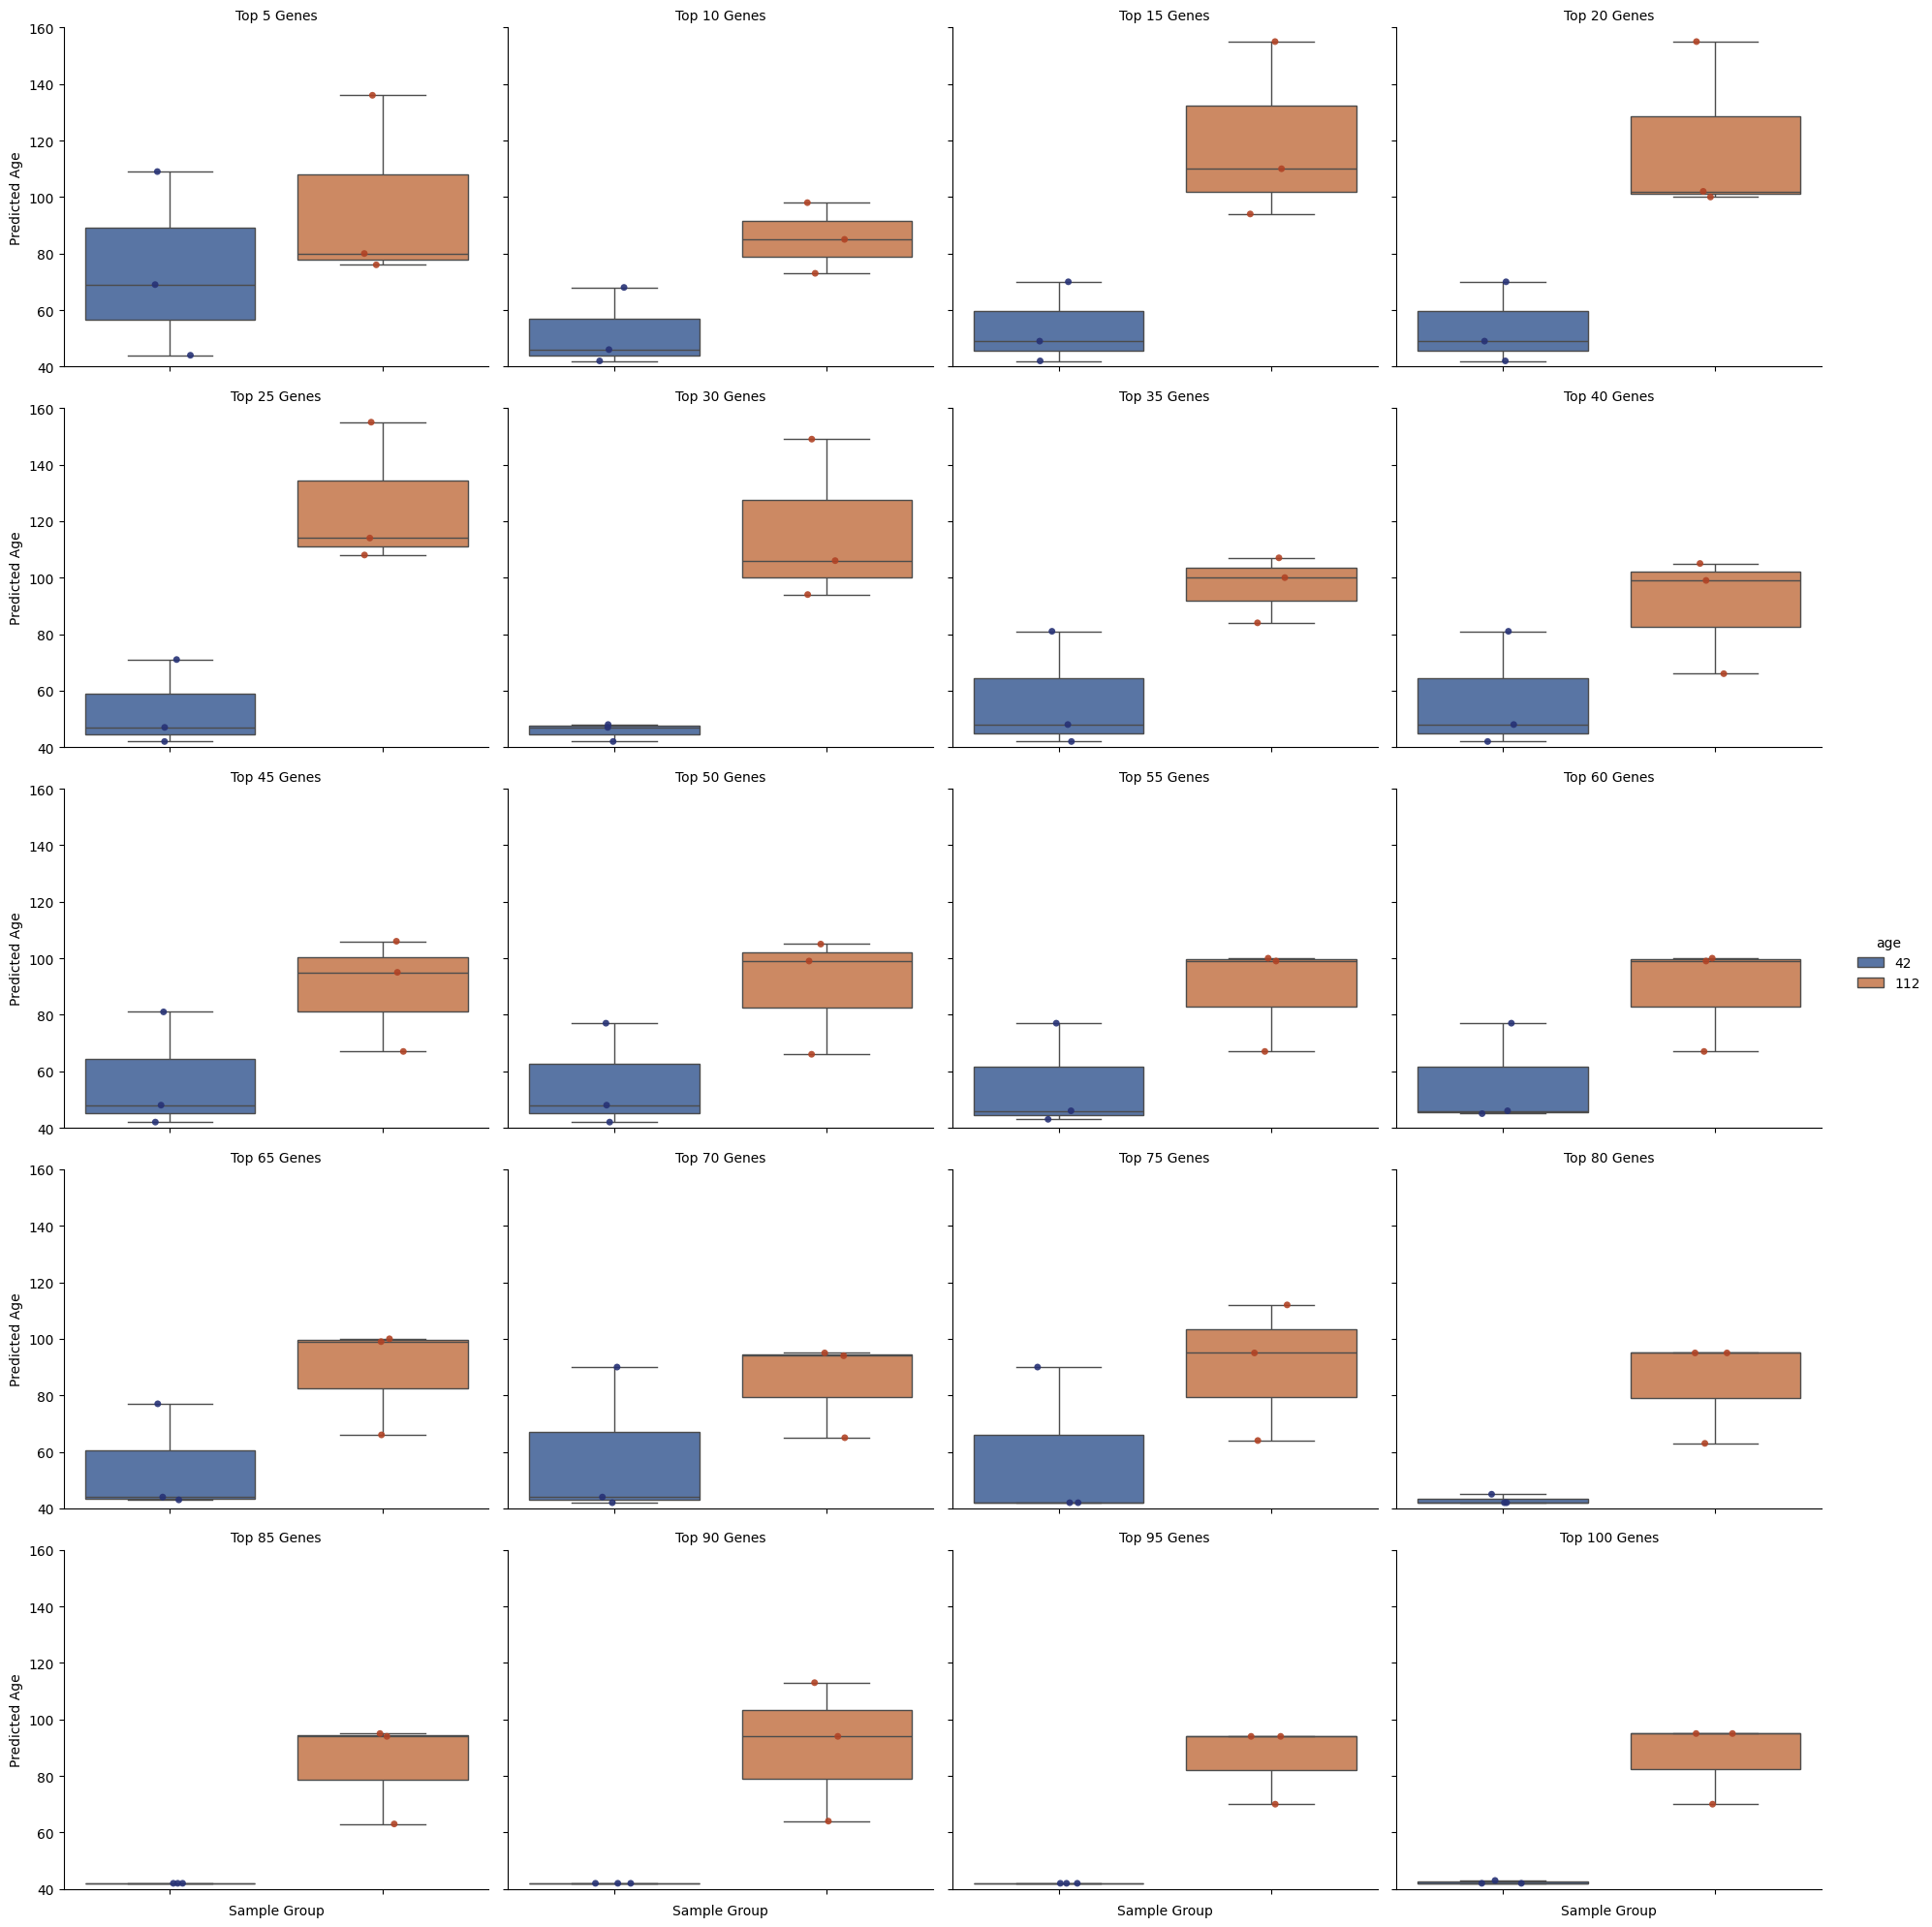

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import os

# Ordered x-axis
ordered_x = [
    '42_F',
'112_F'
]

# Custom palette
custom_palette = ['#273276', '#B14325']

# Load all prediction files
all_predictions_list = []

for gene_number in range(5, 101, 5):
    file_path = f"./predictions/{select_tissue}_nocalib_age_femaleOnly_preds_top_{gene_number}_genes.tsv"
    if os.path.exists(file_path):
        df = pd.read_csv(file_path, sep="\t", index_col=0)
        df["gene_number"] = str(gene_number)  # for cleaner facet titles
        all_predictions_list.append(df)
    else:
        print(f"Warning: {file_path} not found. Skipping.")

# Concatenate into a single DataFrame
all_predictions_df = pd.concat(all_predictions_list, axis=0)

# Plot with seaborn FacetGrid (catplot)
g = sns.catplot(
    data=all_predictions_df,
    x="age_sex",
    y="prediction",
    hue="age",
    col="gene_number",
    col_wrap=4,
    kind="box",
    palette='deep',
    order=ordered_x,
    height=4,
    aspect=1.2,
    showfliers=False
)

# Overlay stripplot for better visualization
for ax, gene_number in zip(g.axes.flat, all_predictions_df["gene_number"].unique()):
    subset = all_predictions_df[all_predictions_df["gene_number"] == gene_number]
    sns.stripplot(
        x='age_sex',
        y='prediction',
        hue='age',
        data=subset,
        palette=custom_palette,
        dodge=False,
        alpha=0.9,
        jitter=True,
        size=5,
        order=ordered_x,
        ax=ax,
        legend=False
    )
    ax.set_title(f"Top {gene_number} Genes")
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
    ax.set_ylim(40, 160)

g.set_axis_labels("Sample Group", "Predicted Age")
g.set_titles("Top {col_name} Genes")
g.tight_layout()
plt.savefig(f"./plots/{select_tissue}_nocalib_femaleOnly_faceted_predictions_by_gene_number.svg", dpi=300, bbox_inches="tight")
plt.show()
